# DIMER Notebook: AI for Earth Observation and Climate Applications

**Profile:** `MULTI-CAPABILITY`
**Mode:** `WORKSHOP`
**Notebook specification:** `2.1`
**Status:** Candidate notebook carrier (clean-runtime execution evidence pending)
**Recommended runtime:** NVIDIA Tesla T4 or equivalent

This standalone notebook demonstrates how Earth-observation foundation models and task-specialized models can be used to **represent satellite observations**, **map floods**, **map burn scars**, and **classify crops/land cover through time**.

The canonical path executes locally in this notebook runtime. It does **not** clone a Git repository, import or download DIMER repository source, call a DIMER worker or API, require a user token or login, or require a file upload.

### Run all

The default path:

1. installs the pinned runtime into an isolated Python environment and runs the rest of the notebook there (see §1), so a single **Run all** completes without a restart;
2. downloads the four pinned model checkpoints, three unseen demonstration scenes, and small **labelled** test samples for flood, burn-scar and crop mapping, each verified by SHA-256;
3. validates every input against its data contract before any model runs;
4. runs four live DIMER model capabilities locally, one model on the GPU at a time;
5. **evaluates** flood, burn-scar and crop maps against reference labels and against naive baselines;
6. runs each task model on a new scene that no evaluation step used;
7. writes machine-readable predictions, metrics and provenance under `outputs/`, and creates a report bundle.

### Bring Your Own Data

After the automatic sample workflow, an optional BYOD section accepts compatible GeoTIFF input using the same local validation and inference semantics. BYOD is disabled by default and never interrupts **Run all**.

### Learning goals

By the end of this notebook you should be able to:

- distinguish RGB imagery from multispectral and multi-temporal Earth-observation data;
- explain what an EO foundation-model embedding represents;
- inspect masked reconstruction as a self-supervised learning objective;
- run local flood, burn-scar, and crop/land-cover mapping;
- evaluate a segmentation map with IoU, F1, precision and recall against a naive baseline, and explain why pixel accuracy alone misleads;
- interpret pixel maps without confusing them with calibrated probabilities or operational products;
- identify sensor, geographic, seasonal, and spatial-resolution sources of domain shift;
- export machine-readable predictions and reproducibility metadata; and
- repeat an applicable inference workflow on your own compatible scene.

### Important scope boundary

This is an **Earth-observation and climate-impact applications** notebook. It does not perform meteorological forecasting or climate simulation. Flood segmentation does not forecast when floods will occur; burn-scar segmentation does not predict wildfire ignition; crop mapping does not predict yield. Earth-system forecasting with **Aurora** belongs in a separate notebook.

All results produced here are **tutorial/sanity evidence** measured on small samples, not benchmark or operational-validation evidence.

**AI Use Disclosure:** Generative AI assisted with this notebook’s code and instructional content under maintainer direction. The maintainer remains responsible for review, validation, and release decisions. AI-generated material may contain errors; validation claims are limited to documented runs and configurations. AI use does not imply independent verification, provider endorsement, or release approval.

## How to use this notebook

**Who it is for.** Learners who can run Python cells in Colab/Jupyter and are new to Earth-observation machine learning. Basic familiarity with arrays and plots is sufficient; remote-sensing expertise is not required.

**Runtime.** Use a fresh NVIDIA Tesla T4-class GPU runtime or the documented equivalent. The pinned stack is installed into an isolated environment, so a single **Run all** completes without a runtime restart.

**How to run it.**
1. Select the documented GPU runtime.
2. Choose **Run all** and keep the canonical defaults on your first pass.
3. Read the explanatory markdown while the notebook executes.
4. Sections marked **Infrastructure** handle installation, asset verification, model loading, or provenance. Run those cells as written; their implementation is not a learning objective.

### Task at a glance

`multispectral / multi-temporal Earth-observation data → foundation representation or task model → embedding / pixel map → evaluation and interpretation`

### Roadmap

1. Understand the spectral, spatial, and temporal input contracts.
2. Inspect the built-in scenes and labelled evaluation chips.
3. Establish naive task baselines.
4. Run the foundation representation and the flood, burn-scar, and crop/land-cover capabilities.
5. Compare maps with labels and inspect domain-shift mechanisms.
6. Try one controlled reconstruction change.
7. Write an evidence-based conclusion; optionally continue with BYOD.

### What successful execution looks like

You should finish with verified model/data identities, a foundation-model representation/reconstruction result, task metrics against naive baselines for the labelled samples, unseen-scene outputs, and exported predictions/provenance. These are tutorial sample measures, not operational or Philippines-specific validation results.

## 0. Prerequisites and resource envelope

Use a fresh GPU runtime. The reference release target is **Google Colab with a Tesla T4**. A GPU is required for the supported path; CPU execution works for the smaller stages but is slow and unsupported.

The default path downloads (sizes are the pinned byte counts of the upstream files):

- 1.33 GB — Prithvi-EO-2.0-300M foundation checkpoint;
- 1.28 GB — Prithvi flood-mapping checkpoint;
- 1.30 GB — Prithvi burn-scar checkpoint;
- 1.68 GB — Prithvi-EO-1.0 crop-classification checkpoint;
- about 27 MB — 12 labelled Sen1Floods11 test chips, fetched one object at a time;
- 2.65 GB — the HLS Burn Scars archive, **streamed**: only the 12 pinned test chips and masks (about 80 MB) are kept, the archive itself is never written to disk;
- 1.18 GB — the multi-temporal crop validation archive, streamed the same way (12 pinned chips and masks kept); and
- about 19 MB — the four foundation scenes and three unseen demonstration scenes.

Expect roughly 9–10 GB of network transfer and about 8 GB of disk. Streaming the two archives takes several minutes. Only one large model is resident on the GPU at a time. These are estimates from the pinned file sizes, not measurements of a particular runtime.

Why the archives are streamed in full: the labelled burn-scar and crop chips are only published inside those two archives, and the pinned test members are spread through them (a probe on 2026-09-25 found the last crop member in the final 2 MB of its archive), so they cannot be fetched individually. Every kept member is checked against its pinned size and SHA-256, and the whole archive is checked against its pinned digest once the stream ends.

## 1. Install and verify the pinned runtime (isolated environment)

Hosted runtimes (Colab, Kaggle) import some packages, such as NumPy, before the first cell runs. The pinned stack needs newer versions (TerraTorch 1.2.13 requires `numpy>=2.2`; PyTorch 2.14 requires `cuda-bindings>=13`), and Python cannot swap a module that is already loaded, so installing the pins into the notebook's own Python would leave mixed versions or need a restart.

This notebook therefore leaves the kernel's packages untouched:

1. the first cell downloads a pinned `uv` wheel (checked by size and SHA-256), creates a separate environment (`dimer_eo_env/`) on a uv-managed CPython 3.12.12, and installs a hash-locked set of wheels into it (`--require-hashes --only-binary :all:`; the lock is carried in the cell and was compiled from the pins for manylinux x86_64), so the same package versions are installed on every runtime;
2. the second cell starts one Python process in that environment and routes **every later code cell** to it. Printed output, tables and figures come back to the notebook as usual, variables persist from cell to cell, and an error stops **Run all** exactly as it would in the kernel;
3. the third cell, the first to run in the isolated environment, records the versions it actually imported.

These first two cells are marked `# dimer: kernel cell` and are the only cells that run in the kernel. If you re-run a single cell later, it still runs in the isolated environment with the variables created so far. To start over, restart the session and choose **Run all**.

**Platform.** The locked environment is built for **Linux x86_64** only (Google Colab, Kaggle or a Linux Jupyter server). On macOS, Windows or ARM the first cell stops with a message instead of installing.

The environment variable `DIMER_NOTEBOOK_CI_PREINSTALLED=1` lets an executor that has already installed exactly these pins run every cell in its own kernel instead. It never selects data or models.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [21]:
# @title Install the tested notebook runtime into an isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import hashlib
import io
import os
import platform
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

PINS = [
    "torch==2.14.0",
    "torchvision==0.29.0",
    "terratorch==1.2.13",
    "tifffile==2026.9.15",
    "numpy==2.5.3",
    "safetensors==0.8.0",
    "huggingface-hub==1.32.0",
    "matplotlib>=3.9,<3.11",
    "pandas>=2.2,<3.0",
]
MANAGED_PYTHON = "3.12.12"
UV_URL = "https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl"
UV_BYTES = 20081404
UV_SHA256 = "aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60"
LOCK_NAME = "requirements-eo-workshop.lock.txt"
LOCK_SHA256 = "829e53dbe5ba2e248d03709946473653e3f268d2fe0d35b49e694886c9c7aa97"
LOCKED_PACKAGES = 133
# The hash-locked requirements, compiled from the PINS above with `uv pip compile --generate-hashes` for manylinux x86_64.
LOCK_TEXT = r"""# This file was autogenerated by uv via the following command:
#    uv pip compile tools/eo_workshop/requirements-eo-workshop.in --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: --exclude-newer 2026-09-26T00:00:00Z -o tutorials/requirements-eo-workshop.lock.txt
absl-py==2.5.0 \
    --hash=sha256:0c996f25c0490700fadabe6351630f6111534fa0ae252cc6d2014ea3b141135f \
    --hash=sha256:0f17b89f2a4eaaedc4f28c622998aa690564b3012a396a4ffad0821007fe03ba
    # via tensorboard
aenum==3.1.17 \
    --hash=sha256:0dad0421b2fbe30e3fb623b2a0a23eff823407df53829d6a72595e7f76f3d872 \
    --hash=sha256:8b883a37a04e74cc838ac442bdd28c266eae5bbf13e1342c7ef123ed25230139 \
    --hash=sha256:a969a4516b194895de72c875ece355f17c0d272146f7fda346ef74f93cf4d5ba
    # via lightly
affine==3.0.1 \
    --hash=sha256:cda3b303325e7bf2bf34817e68753a0d1c4cacbdd451fe67c4878dc2ecbaa540 \
    --hash=sha256:e1b3c38c5d4d3ef5024a182a6d1bf1e0c51ab221825781c741aeb4d0c079a7e2
    # via rasterio
aiohappyeyeballs==2.7.1 \
    --hash=sha256:065665c041c42a5938ed220bdcd7230f22527fbec085e1853d2402c8a3615d9d \
    --hash=sha256:9243213661e29250eb41368e5daa826fc017156c3b8a11440826b2e3ed376472
    # via aiohttp
aiohttp==3.14.3 \
    --hash=sha256:03cd2bde3d7f085b64e549c985f4bb928cad7e8ecf5323bfca320db548d81b39 \
    --hash=sha256:041badb8f84396357c4d3ad26de6afd7a32b112f43d3c63045c0c8278cfd2043 \
    --hash=sha256:0a5ff2dfbb9ce645fa5b8ef3e02c6c0b9cc3f6030ff863d0c51fffc50cb5541b \
    --hash=sha256:0fdea2281997af69da84c77ffa6f5938a0285f21fb3887c249d67419ca865b3d \
    --hash=sha256:11fb37ef075669eee52ab1928fbf6e1741fada40409fa309ebde9607a962aebf \
    --hash=sha256:134ac5ddcf61c6fad984b9a5727d83492ada43d63471db20fb73042c13fca62f \
    --hash=sha256:152516815ef926786a0b6ae2b8f1fd2e0c71582dee0b435636865316fd4891b7 \
    --hash=sha256:1576145bdceeb92382d899751e12743a3a5b8e460a841e3e50543859e54864dc \
    --hash=sha256:16100ad3ab8d649fdfbee87602d9d2dcdca9df0b9eda8a1b5fdc0d41f96da559 \
    --hash=sha256:16ea7e24c309fb7c0bbd505d149abe4fe4dccfb8db911db7dbec0921bc889a6f \
    --hash=sha256:18c441d0a8fca6de8d1f546849b9f0ab20d435993e2c5b59562b2fae6be2f929 \
    --hash=sha256:18cb43369747b2ae007bd2655fb8e63a099c2ff1d207962943636dac989b3147 \
    --hash=sha256:1b59533861b70a2185c8f4f350f791f39d64358ef6944ce71c5240c9ec0982c9 \
    --hash=sha256:1c5281acc88b92396f88c7e1e2748f8466689df22b80170e4f51efa712fb47a8 \
    --hash=sha256:1c5ec8fb1bcc31a8466f74aaf26c345d5c386fa4bd08a3f0eb9c7a4a3fe8b5bf \
    --hash=sha256:1caa7b0d05f3e3a36f87788c59e970a7ee1cefcfcbb924a9f138c4a6551c9cb7 \
    --hash=sha256:21c016079415ed3fd676963e9793700a566d85dbbd6bfc564b9b2d209147dcc8 \
    --hash=sha256:2498f0fe69ead802f9675beca44a7c21c62fdaa4ec5145ea1c3ad6edbee29f85 \
    --hash=sha256:25bd2708db6bdf6a6630dd37bdcdfcb47c4434d22ac69c64665b802910140b30 \
    --hash=sha256:270d3dace9ca2f10f0da5d8ebe519b7a310fc6112ed916e32df5866df0888553 \
    --hash=sha256:2e1161602f45a54de2ce0905243a95f58cb42dcd378402f3697f5e0b21e9d2e7 \
    --hash=sha256:2e9878ae68e4a5f1c0abe4dd497dbc3d51946f5837b56759e2a02e78fa90ef86 \
    --hash=sha256:30402d03a7c0ff52bce290b57e564e9079fd9d0cb545c8aba73f86a103162d2e \
    --hash=sha256:33a2d7c28d33797a2e99923dffa63f83d908a19b6bf26cfe80fa790aa5e1a75a \
    --hash=sha256:362a3fd481769cac1a824514bcd86fda51c65e8fe6e051099e008fddde6db17c \
    --hash=sha256:38901a84da3ce22249f6e860bf8f90d141bcab7da090cc398f8bb58c0e44b7da \
    --hash=sha256:39aded8c7f3b935b54aab1d8d73c70ec0ee2d3ec3b943e0e86611bc150ba47f5 \
    --hash=sha256:3a26434dafe408229ff3403458ca58de24fb51936504decac49ce6755f77e59d \
    --hash=sha256:3ae5b3a59436d089b5395d910121a390feed4d00578eb95a0fd1a329fe963100 \
    --hash=sha256:3d4f72af88ac2474bb5bca640030320e3d38a0163a1d7533500e87be458eef71 \
    --hash=sha256:3f42e9b78301f11c8f861746175d8b9c1ccef713fcad9eab396e2f6db8ed4a22 \
    --hash=sha256:42a67efc36300d052fb4508a53e8b6901b9284b599ae63945c377569c5fcc1e1 \
    --hash=sha256:48d67b87db6279c044760787eb01f6413032c2e6f3ba1cafaa492b1c8e578479 \
    --hash=sha256:498c6c623134f8e09a3c4e60bcd607a0b4590dd7dbf08dd40851b27cbb520ccb \
    --hash=sha256:49f7325beb0f85ef4aef5f48f490269575f83e6e2acad00a1d80b807eb027062 \
    --hash=sha256:4e3ac92d90e92773b2362d506068e9a948192bd553e743c5b2429e28527c8661 \
    --hash=sha256:530125ee1163c4219af35dc3aa1206e541e7b31b6efc1a3f93b70a136f65d427 \
    --hash=sha256:5373dc80ad1aa2fb9ad95c83f24eef418bbda3a61375f128e5b0192e4f3f9b32 \
    --hash=sha256:53e5179d8abb5710f8e83ba207c41c8d1261fcffd4616500e15ca2b7a33be10a \
    --hash=sha256:53e7b4ce82b54a8bcc71b3b67a5cbd177ca1d7f592cbc92cd38b7349f73482db \
    --hash=sha256:543906c127fb1d929b95076db19b83fa2d46751006ff1e23b093aa5ac4d8db42 \
    --hash=sha256:54cfcdee2770dac994417cbb0ee1f3eb0e7cb6b30c79bf44f2c02ff79ec5124a \
    --hash=sha256:55bdcc472aafe2de4a253045cc128007a64f1e0264fb675791e132ea5edaa3bd \
    --hash=sha256:56f355e79f71aef2a85c80305cc915f894b170dba76de5fe84f6351939b83c06 \
    --hash=sha256:5895ef58c4620afe02fa16044f023dc4dafec08158f9d08874a46a7dbc0341b8 \
    --hash=sha256:5bcb6ff3fdab1258a192679ff1a05d44f59626430aa05cd1a9d2447423599228 \
    --hash=sha256:5f08ec777f35ee70720233b8b9811d3bb5d728137f30ac91b7457709c3261ac0 \
    --hash=sha256:614c61d478b83953e261d02bb2df750f17227cd33ef8002945bf5aebbde21919 \
    --hash=sha256:617105e2c3018ee38d0c8ce5ee3c84f621a6d8b9f723202aacaff28449ca91ee \
    --hash=sha256:6debfa7312ff9d4c124dc71d72e9a0a4b9e0879e48ba6fcb42bef5c3300289e2 \
    --hash=sha256:7041d52c3a7fa20c9e8c182b534704abb19502c8bdcbde7ab23bfda6f642394f \
    --hash=sha256:70c987b27534f9ae1a723f47ae921571d616da21d3208282bf4c52af5164ac43 \
    --hash=sha256:74ab5b6a9fb13e873e5a90946588baecaf488745e1db1a4a5c433f971f035098 \
    --hash=sha256:78253b573e6ffab5028924fc98bc281aae05445969982a10864bc360dea2016c \
    --hash=sha256:7a75aa63cbf9b21cfaf60dc2657e19df2c2867d91707d653fee171ffeedd1371 \
    --hash=sha256:8800c996b01c2772a783e3e46f3e1abd5823029adca0df54231960de9bfefa5b \
    --hash=sha256:89176250f686cb9853c0fb7ead90e639e915b84a6f43eedc2a4e7ec21f1037f0 \
    --hash=sha256:8a5fd34f7f7410d1730d5c2ba873cacb2eed3fede366feb268a70ba22581ed8f \
    --hash=sha256:8b3b60de05f3dcb6f6a00f818bb2ec781cee4de0645f59ccaf99b1d1823b6100 \
    --hash=sha256:8f2f1c4c032c7cedd7d8da6f54c97b70266c6570c3108d3fdffee7188bb70529 \
    --hash=sha256:9491196535a88924a60afd5b5f434b5b203b6cc616250878dbdb223a8f7844bc \
    --hash=sha256:9aa6e61fdf20105c4144e755bd586008ff450791d67b1c8146fdc15959c4d51c \
    --hash=sha256:9d9edccfe496b476db5f398d97b865e9a6752bcf8aec4eef8390ce20fb64bb41 \
    --hash=sha256:9fc7b5bfec6573f3ae844f457fdde5adeb713f8b8e4a81ad64fc207b49383716 \
    --hash=sha256:a0dc483c00da8b673abbb367eb6f8d8f4bcec30eb58529ea13cb42e7fd2dfa33 \
    --hash=sha256:a3a8296e7ab5c295f53f1041487cb088e1480775aafbf7fe545d93b770a0f96f \
    --hash=sha256:a3e22975f905b89a55a488c2a08f2fdb2186175349e917d48985cc468a3d4c6e \
    --hash=sha256:a4af35c443e0b1a1bd6a8af3f3485d7fda15c142751a00f3ff8090f0b93346fa \
    --hash=sha256:a94dbaae5ae27bd849c93570669bff91e0510f33a80805738e3de72a7be0447b \
    --hash=sha256:ac74facc01463f138b0da5580329cfcc82818dea5656e83ddcd11268fc12ff80 \
    --hash=sha256:ad4c8b7488d745d2ca4838ebd8ae5ba9b56341d30b1da43640e4ce87f9f49646 \
    --hash=sha256:b014a6ed7cf912e787149fdc529166d3ceabac23f26efeea3158c9aba2354e7e \
    --hash=sha256:b20032766aedf6261c7a566585a40867d092ac03a0d81592d5370ef9b054f99b \
    --hash=sha256:b2466434105a4e03113c36ec775cc2ebe6676b62eae326fa670bb607ef788c1c \
    --hash=sha256:b304db572b4368edd8dda8a2274f73156fe15558fca4a917cb8a09fc47af5963 \
    --hash=sha256:ba59d59aba08ac02fc03b0c8983ccd5ee39a199d0552ce9e6d2b4845b34d59ae \
    --hash=sha256:bd52f811e65f6fb634b1047159657c98f52b407f8efec907bcfc09da9a4c0a25 \
    --hash=sha256:bdd0e2834dce1a26c1bbe26464861e16bbe217042cbff619247c11594472518c \
    --hash=sha256:c23ec8ee9d5ab2f5421f9c7fffce208435607af27fd46d4a44e031954352838f \
    --hash=sha256:c39846c3aad97a8530c89d7a3869a8f8e9e3762c6ac0504481e5c80948f7e807 \
    --hash=sha256:c3c200cf9757edd785051dc699c7ecbec22110dbfcb3fefc7a9f9695eda8ea7a \
    --hash=sha256:c7d3a97c678d34fc5b59da671ee9cd630096ddc643e7b5a30d54a2a6f3574d3f \
    --hash=sha256:c8653fd547c93a61aadc612007790f5555cdd18946fa48cf45e26d8ea4ea473d \
    --hash=sha256:cc7cb243a68167172f48c1fd43cee91ec4b1d40cefd190edd43369d1a6bc9c82 \
    --hash=sha256:ccd4893707b3e2a13e39c90d43cf80edf2e4d0457935bcc103bf2346214c3f15 \
    --hash=sha256:cd817772b2fcf2b8c0905795318485f9ec16eae60b29feb7f4c77085311637f0 \
    --hash=sha256:cda5fd5c95ad7a125a2e8464acc78b98b94c475a3780d6aa0aa157c93f470f4d \
    --hash=sha256:cef89a58e628c4efcac3275c2d68083f82426dcdc89c1492a6f654f9f7ea6ab9 \
    --hash=sha256:d1558173930a5a8d3069cee5c92fc91c87c4dbcb099debbb3622053717145a19 \
    --hash=sha256:d6088ec9894113802bddb3c09e974929aed2c7b3a8c456219b8aab4481f1a239 \
    --hash=sha256:d6218d92e450824e9b4881f44e8c09f1853b490f9a64130801024a4793b1b3b0 \
    --hash=sha256:d77640cc618c1d99fc4f8589c0f24a730adfa54eb1e57ef7bf0c8dfb78da898c \
    --hash=sha256:d7d2deec16eeedf55f2c7cf75b521ea3856a5177e123844f8fd0f114ce252cb5 \
    --hash=sha256:db332af25642007330fca8be5c4d194caf2bea7a7fc84415aff3497af5dfee6b \
    --hash=sha256:dd54d0e8717de95939766febac482ac0474d8ac3b048115f9f2b1d23a16e7db4 \
    --hash=sha256:ddcac3c6b382e81f1dd0499199d4136b877beb4cb5ef770bbbfba56c4b8f55d2 \
    --hash=sha256:df82f3787c940c94986b34222d59c9e38843fba85139f36e85255a82ad5355a9 \
    --hash=sha256:dfa68deb2a443bdaa3ea5297b0699c1464f08aef3812b486d1348eee61b07dc0 \
    --hash=sha256:dff9461ec275f22135650d5ba4b4931a11f3958df7dfbb8db630000d4dee0883 \
    --hash=sha256:e1e74298bab6ee0d6e749ed4fd1901c7e604bdda32c03d787a2cc71c46d0433d \
    --hash=sha256:e2667f0bbe7eb6c74eae5e9691441ad186e5845ca3cff63230fc09c4e7514f5d \
    --hash=sha256:e3be98a7c30b8c25d573dafba7171d66dfb05ee6a9070fc46535464ff97700a6 \
    --hash=sha256:e568e14940c09955aa51f4e645b6daa18a581c5dcfcd73744dcc86a856e3ced3 \
    --hash=sha256:e72ee89e28d907a18f46959b4eb0bb06701cc7f8cf4366e00029e2ccfaaf5924 \
    --hash=sha256:e92eb8acc45eb6a9f4935071a77edf5b85cc6f8dfad5cd99e97653c26593cdde \
    --hash=sha256:ea05e1f97ceea523942d9b2a7d7c0359d781d683d6b043f5943a602b14da4787 \
    --hash=sha256:eac645b09bcfdf73df7536331f0678c1086ea250981118ddb5199e17ccef72bb \
    --hash=sha256:eb0495d778817619273c108784292be161a924b9f5ae5cbbc70a2caa6838250b \
    --hash=sha256:ebe8e504f058fe91223351cecd2d9d6946c9d241bb0250d898ffbdf584cc72b0 \
    --hash=sha256:ed099d105449c4f9e84f24af203cd131349d4761d8813fa7e02c32e7128cd910 \
    --hash=sha256:f0f177d1b195b9e06376cfd7d308d8a1b920909a609d03ac82a8c73bbb16d3b9 \
    --hash=sha256:f3d2669fe7dec7fc359ecdb5984b29b50d85d5d00f8c1cb61de4f4a24ee42627 \
    --hash=sha256:f4e05329faa0ea1a404b37de4f034fd2c2defcca06a68dc6745e4e56c88e8a48 \
    --hash=sha256:f53bcd52f585e1ac3e590d61434eb61f9a88c38df041b4ea126d97144344a77b \
    --hash=sha256:f55119f7bf25f49ed210f6096090715da24f2943c62102448915fde3c62877ce \
    --hash=sha256:f631fe87a6f30df5fbe6d79640b25e4cffb38c31c7fb6f10871517b84b0f8c1a \
    --hash=sha256:f8fb78a83c9e5f741ca3a68cfb455c1f5bb83b4e7249a3848b3cd78d0a8563b0 \
    --hash=sha256:fa9467a8113aa69d3d7c55a70ef0b7c636010a40993f3df9d9d0d73b3eb7ef24 \
    --hash=sha256:fd51ebf9d3a00c074df4ede271023f4d2dba289bcc740b88191872716014e3c5
    # via fsspec
aiosignal==1.4.0 \
    --hash=sha256:053243f8b92b990551949e63930a839ff0cf0b0ebbe0597b0f3fb19e1a0fe82e \
    --hash=sha256:f47eecd9468083c2029cc99945502cb7708b082c232f9aca65da147157b251c7
    # via aiohttp
albucore==0.0.24 \
    --hash=sha256:adef6e434e50e22c2ee127b7a3e71f2e35fa088bcf54431e18970b62d97d0005 \
    --hash=sha256:f2cab5431fadf94abf87fd0c89d9f59046e49fe5de34afea8f89bc8390253746
    # via
    #   albumentations
    #   terratorch
albumentations==2.0.8 \
    --hash=sha256:4da95e658e490de3c34af8fcdffed09e36aa8a4edd06ca9f9e7e3ea0b0b16856 \
    --hash=sha256:c4c4259aaf04a7386ad85c7fdcb73c6c7146ca3057446b745cc035805acb1017
    # via terratorch
annotated-types==0.8.0 \
    --hash=sha256:13b2beaad985e05e2d6407ee4c4f35590b11f8d693a258a561055cac8f64cab7 \
    --hash=sha256:f072f4d804ea359e4eaf198b1af7a8b0943881a87f31bb764f8bf219bb9419e0
    # via pydantic
anyio==4.15.1 \
    --hash=sha256:6152fdbbf9a77fdec97731721bebf7c4c44f7c29b424b0065826173efc7ed101 \
    --hash=sha256:9f28306018cbd6d329e64a36d58256edff76dd996fe423bc957326e578b82a94
    # via httpx
attrs==26.1.0 \
    --hash=sha256:c647aa4a12dfbad9333ca4e71fe62ddc36f4e63b2d260a37a8b83d2f043ac309 \
    --hash=sha256:d03ceb89cb322a8fd706d4fb91940737b6642aa36998fe130a9bc96c985eff32
    # via
    #   affine
    #   aiohttp
    #   rasterio
certifi==2026.7.22 \
    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \
    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55
    # via
    #   httpcore
    #   httpx
    #   lightly
    #   pyogrio
    #   pyproj
    #   rasterio
    #   requests
charset-normalizer==3.5.1 \
    --hash=sha256:00668ebb0609751758682eb0b5857e7c35b9f00e84dfdef062e103244ec94d45 \
    --hash=sha256:012a22b88a77ca2e59b98ac5889b0deb604147666032f45e6d6e217634d2550d \
    --hash=sha256:01e93745f7f219b703b60ba7afead36cfc4242782be5af484673fc500df12da5 \
    --hash=sha256:04368edf83514385ffc3e1cfd4546e595f4f1272dd23ba437a93a9cc3741d47b \
    --hash=sha256:0722590aabf9dc6a6c0343d523c05458fa2b5047dbe6302fd526bb570600753f \
    --hash=sha256:07ffd07412fc5d5e84cd8952acf9ff7e4ed7a708e69d1bada19d8ba91711353f \
    --hash=sha256:09a7bba9f739468c8e78c36a75c33768e53cb1959fc638f510454c14683f00d5 \
    --hash=sha256:0b2b1b3fa5670c127b246df1d0c059defd41f689a868a3b9d79df9b1cac42d22 \
    --hash=sha256:0c6dfb5ca6723eeed15aa8e564a014d69fcb8812f94eef11fe3631e0508199f5 \
    --hash=sha256:0d929fc574b4d6fd9e7c0f5c2ede8716a41911923aa7fa5fce38e0818aa4a1ac \
    --hash=sha256:13e3afe97712e8887cd516e960c63f0b93122971e5b5e4b2622fe7701771e838 \
    --hash=sha256:15f024313246a4ed976c60f440bb8d257815513a681d212ff74fd46f7d715a90 \
    --hash=sha256:195ce897c6153c0700078142cf8efe3e6454ca4cf4357499e4078dfd83396626 \
    --hash=sha256:19a3dd5aa73cef1c99687c4fc57db016a9c17104ae1185da88ba566a5d3bebe4 \
    --hash=sha256:1d1c7a53a6c2103925cdd6d7229f8c567379f211c869793df679f2e9f738c369 \
    --hash=sha256:1f5883d77fd409a261abb5dc8ccbe335720d798b1de4abb3b1d47ccbbc76b53b \
    --hash=sha256:21b82d8082f6f5e7f456ef0bd16323d08de1266efbfeb476e64b2a91d1471a4e \
    --hash=sha256:252d099029bcbea642f2a06c4ed5046bdf8b5a8150b64afa5e027e88b106e5ee \
    --hash=sha256:256dd4d85d9e4dc595e2bc983c980e73f62ddeb3165c58b4c3dfe78c5c8548c1 \
    --hash=sha256:26422d45fd13551cf564c58932f7d72b4f58b93b0fcf18c35ba6be12b46bb102 \
    --hash=sha256:2679de311c7946dde5d3b6f44941844133ff5c7cb86099c0061ab1e8901c20a8 \
    --hash=sha256:29880d17a8eb0b5cfdfd8944b468322928059aa35f1f5fa8ff22b149ec0b42f8 \
    --hash=sha256:2bced4061f000f7187254a02ad3433ae17eaf991747ceea2f478422590a5bba9 \
    --hash=sha256:2e9cf9253119d8e5d111f05d71626786fd3d6193817316eab1ca088cdb8593cf \
    --hash=sha256:2f06b7eae9dbe77fe1d644ca244dad508de8d302870a43f3c559b521270938a0 \
    --hash=sha256:2f293479cce755c75f1697e87c409b7ae4c555c7dfecb6e988ad13abba943031 \
    --hash=sha256:329fc3ccb63ad22d867d84c2adea759a64079a37ba4a343433b02c7a2816871e \
    --hash=sha256:343fb4f2821043bd87095f7b08a1a181febc8e36ac64212143bbfd0a0e1bc235 \
    --hash=sha256:3588e376b3ea2eea84976f67273d679f229e24c66dce7b82ae45aef04ff6e072 \
    --hash=sha256:35aea775dc2bd5f54cd84a1cd2696cc3207c479cb9cf0bd346f0d343e4300ddb \
    --hash=sha256:35fe081843b35aad20ffeccec3eeffbe637b15d14f3fb22cc1b59cd8ec17e93c \
    --hash=sha256:36047af20e17097c3bb9476c2b7655f2f7aa51322c0ba58c07695bedf755a950 \
    --hash=sha256:3617ac3cfd8b9888f145ad89dd6e692285834b0201c6074a5eeaad3fd4d668c2 \
    --hash=sha256:366ec70f5547c640d3ce1985722490f23faf4eb5216a7eeba78277490e78dacb \
    --hash=sha256:394fea06235c8543390050ed5f529187074b029fb027213f6c46ac11ab5d950e \
    --hash=sha256:3d27167433c0d5f18dc850f07d0b3816221984fecdc405d6c157a6f0b8f8e9e6 \
    --hash=sha256:3e5e1224c0a6a90e05843e07adfec669edebec17801c67072f51e59561d63c0b \
    --hash=sha256:41876ee62a3dddf48ff1121ad8f0798032aa03f2fd35f21f34a4cab14f18d8d2 \
    --hash=sha256:433c5a81eade63b47e522303bad236f59dba55ea6951746f5558355eeed8c75d \
    --hash=sha256:4582c27e8c889d64811987b5967fbd3ae0c823fe1fd933b543d55ac20bb475fa \
    --hash=sha256:485a0d363cafefcd2538a73c7c838daa2035f09b2c9f9b5e3133f80c6aeb84c2 \
    --hash=sha256:494b70049a4d69aec6e8137c13af4cf8db8c9f9820a1392ac293b0dd2987a818 \
    --hash=sha256:496846868fea80e479324862fa877f02411f2fd0f83b79ccee2607aa68b2a032 \
    --hash=sha256:4abdc5f9ad448c1ecbfae2974b820535d6bc6e7eef63babbab3d81cf46968c71 \
    --hash=sha256:4b599739b93b2cbeded49645ae3c8d1405c29ddfbceac1545c87a3f9580a9e96 \
    --hash=sha256:4bea7f8ebe90bbd7f0e4a2de42ca6924ba23e3e76418c408ff82f1d46fabd687 \
    --hash=sha256:4c4fb141a727957c93edfe5c32a26ceb6b5f6461d67146e2d39f51e16170bea8 \
    --hash=sha256:4c9548dc78002099910abaebc0a72ac58b7d30931869e0351c09b507dff4ece3 \
    --hash=sha256:4d26f14f041e83dd8edfd61f4cd4fa7285d31798b5bf1f28e70c367ba6c41d61 \
    --hash=sha256:4f298bdadb8f0b9e5672877f647d1be9373ef5320c9e2f049795e26cad28b6a9 \
    --hash=sha256:52ec005752a56ae79547a05c0139ca2501a0c866390b6115008456b9f0e7cde1 \
    --hash=sha256:55261ac0d2941c42f196dd576f543d87a8ee03cd6f5e30dfb4d807b2e3b9121a \
    --hash=sha256:56490c595a28b1bb27dfc583e816152a9767721ef58b2c03b13f954d2f707420 \
    --hash=sha256:58d3e12c88e0950bca850ae1f7c256055c097639c2edb9eb123af9807d8b15e4 \
    --hash=sha256:58d4aa13a59c969dbfdf9e6a9560e242cbfd9e8a8f50c2747714df1a423adf65 \
    --hash=sha256:59171c6e45bf07d0d5cab3b0bf81d945035530f6873398b3b531c31184d46663 \
    --hash=sha256:5b6d1386bf0096d26d3a863dc0a487a5b4eb9aa93cf5ba69683d29dde6b9d60f \
    --hash=sha256:5c0ea61a470e070686aa30892fed79e297d2c8d0ab46b8bcdf027d38c51da591 \
    --hash=sha256:5c84bec0ab5ae0c64bfe73a7d2adcb5ce73b467523fc27fd6a28ab2aa6cbe35a \
    --hash=sha256:5ca0555312ae2fe82715cada7fac375530c2f3349e1eaa1bcb33d0283ac79a18 \
    --hash=sha256:5d8531a6569d025f68e2321e7638fb7978f23db58e5f69f56913837aae03816e \
    --hash=sha256:5e2d0e146dcb57034f8b97dc58d2d512cb90aba253960ce449f695fec6a82c6f \
    --hash=sha256:5fc45d653ea8c9a20479167e11d4a0f8cb2fa3470737ab6f9c827532313187b7 \
    --hash=sha256:6117b84ea48435e5356dc737f5121485c30920ba43375fa7b434fd753df0eac3 \
    --hash=sha256:6199d5606e2bbf2b096cf64d03f8b6790c91081d5ac866b8e7bb6422738cc60c \
    --hash=sha256:62b55f6722735a6c472f88361cde6640608773d9443cebdbb51abf436a1fcdd3 \
    --hash=sha256:687c9ca3035544b113bea2055e180af96fb63c0c476e22a9180f51925186e7b7 \
    --hash=sha256:6b7430cf5728e68f6c462254009a6ef4086e1bea43cf2f57aa9c55fb4f50ff96 \
    --hash=sha256:6ba32c4d2abf1d2fe7cf27d280f4cca5664233b0f885549c7761719eb977f486 \
    --hash=sha256:6c9cdde8becb25a7fde49924511aa2644d6f8081cc8df8e9452724303348d8e3 \
    --hash=sha256:6df0ec430f9a831772c23ca5a224cba36517a58a84bb32c32bb59a9fa67c47f6 \
    --hash=sha256:6e2912d4babbc65196ac13c2f53468dc57fb8b9c25ef913e8c59ddf7c6dc0e1b \
    --hash=sha256:6e5e4d73d588ca5ed09df1b7dcd1b203d1df3c542e3f50d126c947d432b10731 \
    --hash=sha256:70055ff39b97c99e7ae40ea3e393fb62aa2e44dbd9b29f8d14f42fb0025c3959 \
    --hash=sha256:706bfd38730a5ac7a365793269a00f4e988178cec121391f4248d84ad8c972e9 \
    --hash=sha256:7235dc28fc6dd9d832ac7c7bce95367dedb85929f17368a0c2bee1e080b9acbf \
    --hash=sha256:774d157f112367ff4abd29019f38f023c24e00e56edc7829c20e358a5a913ad8 \
    --hash=sha256:77efcff2b23071c349402ac1066667a3d011f62398d81408c9b88ad991747c9e \
    --hash=sha256:789b8982559ae28dad2356519f841655756cdcd96616410590ae0b17454ee64f \
    --hash=sha256:7ac76cf9afd34929d76eb7fcb63be476a4853d8a96f0dcf2d0db68a0cbdf9885 \
    --hash=sha256:7c0c10730342b0c9b35dd1d619beb8214e520bd96a1f870f452680b238aab3e0 \
    --hash=sha256:823f82903d189af463d7df250ef1f7f696f3cee08cc8d91deb565e8d425f6506 \
    --hash=sha256:838648accb3a7fd9803fd45c87bce8509648eb0c11bc34e216141300977244f2 \
    --hash=sha256:854066be00447fa8de2ccbbe893e2ffc4b123ef16d897af794c1e18bd4a714b0 \
    --hash=sha256:85d5855daafc240cc045c026d7a15fd198a09b0fc8ff6f5ecbb5297b509cb11e \
    --hash=sha256:85de3134b5379856e323ba37c19c9256d39425f7b76a63af52b09fb4664c2e8f \
    --hash=sha256:87e4f41d375c0b9be2fb5251aee4b8a689169e134535aed81bf085c3b647451e \
    --hash=sha256:88ca277405c2d3b71c4e1c2ee0e7966e807bcba86a69d11e19ba199d18ae4491 \
    --hash=sha256:88e85ab89cb822c1e635f51d6d32e488f94e002e70e2f492bdb8b945543f345a \
    --hash=sha256:8ac8c94b6539074e0f40899301273ac8402b9b3e01c7b7ba269ff30340aaaf20 \
    --hash=sha256:8fe532b3c966d1fb794e0698e4589d0444017ae77fc0b31edea13c0e35bcc449 \
    --hash=sha256:9085f87b0e38a2b92b8923059b4e8789fe40d9279712d15dcc670048d77079af \
    --hash=sha256:90b7481fb62fbe172c558bc6fd1c4c98d82004a54a7551f20e11ac9bf0b8708c \
    --hash=sha256:92caef967d287a407085d61176fce4012b1dd62daed4eb6d5ceb26d3d2538712 \
    --hash=sha256:9362dd90aa7dab48c0054a21187791ccf05473f7dba5d92b8033ae62164675e7 \
    --hash=sha256:94d78ecec2605a8d0398b0f365d5f12a63248438516f5dac536a5eff7337df4a \
    --hash=sha256:94fbf1c0c6cc0d3d5e50f9a9313a8cdca90dd696d34b381cd1704f8c9e939f20 \
    --hash=sha256:950f23cb393f85543777b0433f082cddd25b51ab398eac7971146495679efe5f \
    --hash=sha256:96eefc178f8636b9c760c5829345307fd81cfae9ab1e80997dbddeb0f54ee9a3 \
    --hash=sha256:96fef3e886d6a9874b14f27fc193fbdc69d5d8035783d86aa4e1cea594e695f9 \
    --hash=sha256:977cdbd483a9cff38179bea4fd754289a6f2195c7abd414aba85410b3e66cc5e \
    --hash=sha256:978eab16f55b4ab2c2a745be9a0a840bf8f09a7f227d9c76eb30214d078865a5 \
    --hash=sha256:994e883d17c559cdfd38c84003c8b27d25424a1077272a17e7cd27bfe0bf57b2 \
    --hash=sha256:9ac4444d8d4fd4c4bd08bf451ed3167aa9e7ec6cdb41b648794f1d1103652e36 \
    --hash=sha256:9b5db6052055d34d41230fb78d7c439c23dc536a9896f6cb039e8dd92cfc1263 \
    --hash=sha256:9d9a0dc7cbe9bec24c3f767c9122c41fe5a1bc43f47cd099d00d393e09769de4 \
    --hash=sha256:9dbdd9205662134957cf0c324f639bdc5031c0ca056e2369e238db75187c0f11 \
    --hash=sha256:9eea3ab2597a5e65fe65296e2d6a84570845a6b55532d90333d740d48bbc850a \
    --hash=sha256:a2028475ba855475b8b4d3cfeb4994269c967aea8b9892dfba907f4263a863a3 \
    --hash=sha256:a3a370082ce34d0612f421e15fe011c53bb1feff21a26d06ad4fb244dab5a375 \
    --hash=sha256:a545775cfe815855ea32d7c27731d79da358ef2055b4a25830231b1622dd18aa \
    --hash=sha256:a5cbd90ecf0fc62e64726917ad083b73001f0563657a87ec3c0b504e277dc90d \
    --hash=sha256:a6d095662e73e74f0a49988e0593373e243e3a52e27bfeea0a859e88acf4a0f5 \
    --hash=sha256:a6dac12ff6b846103483683f60c5f8fee205121adc58ffd87e90a90a3af69e99 \
    --hash=sha256:a951ad59cad9145664a730d3036b40b844e74d2d3683da40111463cd3a83845d \
    --hash=sha256:aa1099b956fb795e686d073568f6dc002a0bb89765ea6d5b055dd7d9bf1b116c \
    --hash=sha256:aa2bb0b37202dca27175591f761108b5d34096ade1191ffe4808bdf6b1571488 \
    --hash=sha256:aae2ee51122d3ae968a3837d97dc24a0aeebb0dea23694422cd172bd30017cd6 \
    --hash=sha256:ab743e9bc90c1f73552ec33e10e3331315acd2c397b36065b591b0181de533cc \
    --hash=sha256:ac00177c4831ffa650f8609e4bdddd5fe09c03b1c0c47acece7e6ea20421598b \
    --hash=sha256:ac13b004224fb341e1e25a1ed5e19d32f57cdb2a403e01f003b46f051a550f6f \
    --hash=sha256:acaf604462bf330b0d07e7a07c1d6e4adac79e5fb13e9c5140590542cafacc00 \
    --hash=sha256:ae31a1a1db2ee6cc2942fccaf695c934bc7f3db9f2133a3fef1f367cf1a4ab10 \
    --hash=sha256:ae4a097991662cd4fff0ddc74e0fe7874f82e00042fa0ea00855645ed0c79598 \
    --hash=sha256:aea996a6aba25260827c9ea511d1addfde2da9eb686ac961838509086188b7e6 \
    --hash=sha256:b39b69b347e5e47a3b5b8cfc005c68c1ba347474e3960236c4944a8ecd174962 \
    --hash=sha256:b54e7e13267d49ffbfe68e25b3cbd774dab38fa37238f71265e91b36146eb21c \
    --hash=sha256:b9af956078716df40d985fb0dfeb2c2120c5ca92ba4ff4b388acfd01cdc14d08 \
    --hash=sha256:ba2f37ee79e6338845261a3c5b1784e5d1acdff2c0785b284f1b633033d136ab \
    --hash=sha256:ba501e667c17d8411f98e67a022d9604ef179aff0e459b7e292c796837c13573 \
    --hash=sha256:baf3775a2635e5a11fbd5e4e64ee69c7e86875d224a5c72aca4c141064589a90 \
    --hash=sha256:bb57753e36e4855b8ca375069482250a6246372331a3e4f3407eaebb007443f5 \
    --hash=sha256:bd6c173f04743d483881bffa1478d5a4624475b8cd1d2194956a75548e191c18 \
    --hash=sha256:be47f99644b208bff7766314013f9acf57b056b04191d570d68ad14022cf5b1d \
    --hash=sha256:c010f5581d9c612804cc59fcf7b524b707fbcb72828551237ab545bb5c7034af \
    --hash=sha256:c1dcc36dcb96abc02236e182d17e0f71430152a6c2c7447421da2d2dc144edea \
    --hash=sha256:c428c6c31eb5f4277d7f8eccaf767fbd548ddd5ce3c8b4f4cbbfab3d96b5904c \
    --hash=sha256:c658c50ac0c98cd755a2dd50b7977d3bca7df401dcc47fbdfa87db53ef7d4e8b \
    --hash=sha256:c71fb0d56c920c269cd3e2e3fe7c610e3f1fdb21a6ce60efa6430ff63676cea6 \
    --hash=sha256:c7b742bf31c88566b4bb6335a7f393bb322e580b6bb98df7bd0c25e6e3519ce8 \
    --hash=sha256:cc0329df4caaceb950d2f580b5ac716a377f7059624a0bafaeaf8a218c6ed774 \
    --hash=sha256:cc5d36d96478aa9c60654bd932525bf32964c62a7281eafdf16d85003a8d6004 \
    --hash=sha256:ce854f5f478050ade5a238731c4ca985a7d3b3cb53ff600a9b5c3b689b5f0a7a \
    --hash=sha256:ced3fdd71aaa83ce593746c2edb42b7a59cb4c19c8b5c407781c72e493aae55a \
    --hash=sha256:cee5dd7c6fb5dd52a0fe2a740f9bc6e3593f5f8b1788bde49de02086f30182b2 \
    --hash=sha256:cfa1c0cc3a8f9f53f1243a5a99ac36fd003880199383b37672e86ddda9cb07e2 \
    --hash=sha256:d1ee1e296209fdce05b81b663250eefa02213a2da7b41bf26f7829b8ba3545aa \
    --hash=sha256:d59b75732e9b6f27388e10c14b0259cc5f2e48c78627d185e6a177b58ad3cffe \
    --hash=sha256:d63600d620ad0064c3a748b950ac5ea38a80190e5498532efefa4b7b3f1da1f3 \
    --hash=sha256:dd732602a7009217f658d5863d12d79d373a4de0eebc111094bcdd3bb8e0a6cc \
    --hash=sha256:e06efa066f7dbadbc84ebc126a97c452a6451dfcf589d89d788484949e1cf795 \
    --hash=sha256:e199fb99720074809a7720f1c0b4d919eea8b87e88713e0f8f602f7bef543d9d \
    --hash=sha256:e4b018dc5a0eee4676e38fe84a47a427816c590b93b55d9025274ec4d6ffc2dc \
    --hash=sha256:e6621fb2a4988d6e53eedc455e5903e2679f3967b8acb3d639f1b63c14a2e893 \
    --hash=sha256:e71c909f353863b2b89c83de2ebed71ea6d0df8a6ef65a128193c5e650766bef \
    --hash=sha256:e90251c0c7bdd54a100a0dce3c07b7e637278c93af29dbf78ebb89a58c4bac7d \
    --hash=sha256:e9fbdce1e47394b09bc9f26ab117dfc8d6491977a11d86f592bb42c779db2fda \
    --hash=sha256:eb12fb2ba69ffa05f8695f61c69e591dc4b4a12ac3757ac8af8adb259bf56d17 \
    --hash=sha256:eda059b6bc8bc0812d626fd91a7ce01bf583df0a61296eff390fd94141a34e30 \
    --hash=sha256:f03ac127268b43ef4fe9e6ab6794a6794b49485a0cc0c1db79876d2f33f75bc7 \
    --hash=sha256:f298e218441525d3794428b4c8b8fb8662c6d3ea79925d4807ee6b9a96a3bca5 \
    --hash=sha256:f5542f9b941279d82d41eb0aa9f98eba36fe4df5c7086c651df7944935b37182 \
    --hash=sha256:f6f7deae3feb4edfa2efaf7c574fe88cbf055038a6abdb40188e4fff66d5699f \
    --hash=sha256:f9b1e28d0e8dbfa858abdba91d6b547beaf2df1a59bec6da6faae7b96a4991a9 \
    --hash=sha256:f9f8405c2c758532c74fed975dbee57be1f31a6e865c031870c79a6ed3212ada \
    --hash=sha256:fa48b1b63d639f9483e0633e092f5851e2348c352f1f9bb6c8182f87884ef876 \
    --hash=sha256:fb78f6e7fcd8ad785d28cd577168bc1aaee827b25bb8755638f694794ea98f0a \
    --hash=sha256:fbc597639158fd7c14d55e808718848319540f51b0e6746e3eefa59723a4a348 \
    --hash=sha256:fce8cbd4997efeb450bd298b54f755dcdff18d496f7a5ddbb4867c6d7c88fdc3 \
    --hash=sha256:fd0350afdc3aabd5576f60ea109228bd5538139713c7b094c5cd27c73a98bc6f \
    --hash=sha256:fd0a274c0e5f9a21565cd9d3dd749b61f96b7aa1e20a93aa1ba4029518f2e5c0 \
    --hash=sha256:fdb8a068947befafba9952162645dc2fecaeb400e64584829ed5e9b2fbe21a7f
    # via requests
click==8.5.0 \
    --hash=sha256:255bc9599cf7748b4b1a446ccc735421bd08a2ae529a8b88597d3de5664ee360 \
    --hash=sha256:ba0d2089de75ea0310e2dde03160e6ca10009947fb95a182f9b54021bb272e34
    # via
    #   huggingface-hub
    #   rasterio
cloudpickle==3.1.2 \
    --hash=sha256:7fda9eb655c9c230dab534f1983763de5835249750e85fbcef43aaa30a9a2414 \
    --hash=sha256:9acb47f6afd73f60dc1df93bb801b472f05ff42fa6c84167d25cb206be1fbf4a
    # via joblib
contourpy==1.4.0 \
    --hash=sha256:018227e134b73090b06f911e773a526c77c9af426be29065500ce096a5accd4c \
    --hash=sha256:072a702e2e178f4fcf96f04775d0c059e4c917925abf0d3208ebb6865df3c23d \
    --hash=sha256:0c7a4c2716a4e98342221954416a836cca77c996c14ddbf22b5f01d5d93ca09c \
    --hash=sha256:107ec46f7aa1664266d69b1181aadc953d58d39f7d8d648fa5b795d4a060b0de \
    --hash=sha256:181bea01bc742734ae672fa00c717d855dd35e1f029536406538c52e7b0cd73d \
    --hash=sha256:186ba929df36d61b6127da2e89cd1357e4cb79aca647381ab1a6feb0b152877b \
    --hash=sha256:196759a3e4db60e1546167e361090ebb6d199aa3aafc9e34ea17a5ac3b23e814 \
    --hash=sha256:20156f5a1ac4f8ce02656e39a61e82164a3d359796dc8026f75b062783d500e1 \
    --hash=sha256:20da2f86bfaed60dbba729fe738c8241b1dd22b6cf7e8cbbf30df290bd04ba28 \
    --hash=sha256:2deb580178ca19437a84bd77e4bc2cd91a8ccad212413a83c273900868b5978c \
    --hash=sha256:2e741a39dfc96babe1722561e81351aeec104526c57dbe91c167c1db606c2d55 \
    --hash=sha256:3863ef2e2b13fe93f8c0ebb08ee400cb07153b8b0e91c5acb26e4537f283634f \
    --hash=sha256:3e0a2392533e5e2abdf277c951047516acc8d2f3c42b2dd9dc34c907c9ebabf2 \
    --hash=sha256:404dbcd9233513dfd1323b66ea593fef90e899f658f6b8a9ed8e93bd0ca669db \
    --hash=sha256:417be048f7e122cefbe2a34c51a1f2b0410f8eb35796f794d45475ddb7872d9d \
    --hash=sha256:423bd5f4b3f11d54a8c597234e513382e3454bb106b8ec7ae32ba4ed63f8d99b \
    --hash=sha256:432e89f835cf01f8d2123a130a3126b17ee6e0348e4d62c0973872b30aa873bf \
    --hash=sha256:43c3ccbb32c6294b183dcc8e8c46dacf5ecef809497e3d48a5be298eef185ad0 \
    --hash=sha256:43d80072a32299bf945de0a6dd4e034ea0162e832261de2e07a274a5adbba9c9 \
    --hash=sha256:4bffcb2e8cc5c0e837631acab59dd04265fdac376550e7c3e310523877c68cb7 \
    --hash=sha256:510f7d93d94cf6ebf4e2cd0640bea16ab8affac7547230175b6745b596ce0599 \
    --hash=sha256:5450f091ac1be0be3ad3a2a3b3f23b5e443e78c670ced4fd347d626f92a28fd2 \
    --hash=sha256:5545ff38229c15d11d822fc6f7415b932da9f4975f53e305b7b96ebfb01f889c \
    --hash=sha256:5a4c89c7f38a0d7a94356d74e3391073c4325c4d47ad2fd065c3fe7dbae16c0c \
    --hash=sha256:61624f6722480aa7e168fd746164e7bfdf48f8ccb6542f1613741200dc37e2b1 \
    --hash=sha256:618137ec5778fb76d494c9ec854b104a377fddba0d128bef7136cce2c3bf0df8 \
    --hash=sha256:630d32f06cedf37b7f1dd2b6a12e4492826bd477a4c9c7b2e2fee6ce3a2cea76 \
    --hash=sha256:64039341e2d8804f1a13bda8c69083eab935167bbd7e856cf096241f17d5bd45 \
    --hash=sha256:6507a016976a75a15aee47809a34605de6244ccc056e6164bf9fb14b27eecad4 \
    --hash=sha256:6ced1670fafee703b8277ab1645072a226e74f167166eae146fb743916119b67 \
    --hash=sha256:6e697d94e69f499ff6bebb899cae97a58d5d14f0e1fe9568b43a0248d2f9af8c \
    --hash=sha256:6f963ea9f0d68d2b6a02d861e3c0aae09ae25ba21f243fcf281e9fed468b078d \
    --hash=sha256:738c44fa71735a617f36da58e32810512407d283d5d1bb5b1cecb00d7eeba7cf \
    --hash=sha256:758e7496cec3195fc28a28945eab3ceef348c47fb95c7afc2eca2f3901209c8c \
    --hash=sha256:78ed5c5f962b3e156109f0531b174a65ba80d13cc681a70227b12524c162e184 \
    --hash=sha256:79b06c60d5e569ce12c5da8f0c51217cdc484386e2349fa717c30fafb56d2871 \
    --hash=sha256:7f861af508fca2384eef392bc1d8377cfa349b2b854cb11b45d89c75780e2561 \
    --hash=sha256:80c7fc8e7ac217777ce7ba2db3cf8478652b5a4b335283111012ff9eaac9d842 \
    --hash=sha256:86d05cec773c9507a3950122e0e40ce77c23c75ceeb2fc189514e71893cbb34b \
    --hash=sha256:875f42444c9cf48d56f724f2637e60d0f73b3b12c9041e1484580a233edf9591 \
    --hash=sha256:90feb8da006803a95ba573fddc9536357d0c3faddc3a4c9e22816ca49af52878 \
    --hash=sha256:912c6afaa106e2f74ba22b30416b77ef7eb94e3bdc5a4df51ab147845dba9b6d \
    --hash=sha256:96019f059bcb3774acc0104be3360a57b36d33eaaa2e1d7f77c800ca8e07618b \
    --hash=sha256:9c0e07c691f3b3321913ed9b8161c50ea5f77fadd006f52f5e755359b0dcbfc5 \
    --hash=sha256:a03b32c2e7eda8b17757c022162c13c86f5c3d6f937dddf9ba3c3ff7b513953b \
    --hash=sha256:a1c8a74744fa746eeaa12f0f9ed7f8b4add9d8f1b14d95e3b5e133675eac888f \
    --hash=sha256:a3e67bc1a6a4618a1dac7c3053a9ffece5ddfa2046b2670b342cf430bb0b87d1 \
    --hash=sha256:a58b5f130afec61a093d743cdda435cc4047748b6791627e34a68f41ec3a9b07 \
    --hash=sha256:a5e2bb871b90cd7a52bdee63bf80ef7acb46398d27efc66d7679240016efc5aa \
    --hash=sha256:abd0f7e51ecc52bf8c95713bd80b1c17c516a71fa391c54475308a4377903c2b \
    --hash=sha256:b7794ea07cab575633daad8d6e963b662053391022294d3aacc1d9ba9ef54114 \
    --hash=sha256:b9dc493e7924e5aa32d89d0b8e50986280f3d4b284968a792787bd7bcffd3cad \
    --hash=sha256:be85d160e7c795113c2a93254dde2fc7e86b375322570eee78b420969426973c \
    --hash=sha256:bee6ff96653e0807cd0f8eaef00174a031e3a2effa5c20f49a5a8d574b05af23 \
    --hash=sha256:c76f3a5318164db7d9401132fc1b5364b784c613c93fa506e3b5e6d1bf353ec8 \
    --hash=sha256:c8be3392b84cf43373a488874dc1ebf46f60784a70977f92586e18019d71c7ed \
    --hash=sha256:c927ec747633e68c9920bcaad48b0bcefe648812b822f18c34e2d0e2270a3d2a \
    --hash=sha256:cc87f2ffa84a49a77d76cb792f28a48ff3b05a222aa0b2bddbd839ba78e1d5ca \
    --hash=sha256:dd59df9e2fb0aff8bd7fd1adb9f349b7c835245a9d0f18c2f2deeb537190f2b1 \
    --hash=sha256:ddf5a2596d716fd3793434844caf31abc7a40b1e8718431420c89858268fb909 \
    --hash=sha256:de503609fdb71f597634ca64fb4bd2f13d27c97f140e912b1e8ed93544840df0 \
    --hash=sha256:e21d1d4a9db5b3a793649c7ab0ddb4697f2818929eec871a7b9c45fce7b2a1ea \
    --hash=sha256:e439ab450c93455feb0218532ded3e946ec7a9b5f459069f122cfa44b89229f6 \
    --hash=sha256:ea09dc704029930cbd097f75cb0cc1db9852adbcf1a151fac7e9559f7bcbfd19 \
    --hash=sha256:ef47fef9a912c77e3d84b014f701e5a9340f25703e9ed3bcebe37f91fb69dc49 \
    --hash=sha256:ef9440f6f8506246269a82734f5ff9e2e4c5e775b3996fc883cc491c5257eca6 \
    --hash=sha256:f1219a8898523cba821085f2da8a1b962cc696325763f09d7f93538ba43b2d70 \
    --hash=sha256:f863c6100bf926cf47d13f3cd75f9bb8ebd98aaab230eeb4468b91f98f39a6b3 \
    --hash=sha256:fa1b787362a3856e63dd2b89449f6c384d55ee1beb8f94f4bcc871b40f02462c \
    --hash=sha256:fc9feef8f1f001c5b87decadc67c4a5d1eebb62ca39c4763d1237ff62cf2b707
    # via matplotlib
cuda-bindings==13.4.3 \
    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \
    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \
    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \
    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \
    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \
    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \
    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \
    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \
    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \
    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \
    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \
    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \
    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \
    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \
    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \
    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \
    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \
    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \
    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \
    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \
    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \
    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \
    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368
    # via torch
cuda-pathfinder==1.8.2 \
    --hash=sha256:4e65059febdb4d19d5cbc4798677e19db2b582f2f702f457b609e571690d357e
    # via cuda-bindings
cuda-toolkit==13.0.3.0 \
    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f
    # via torch
cycler==0.12.1 \
    --hash=sha256:85cef7cff222d8644161529808465972e51340599459b8ac3ccbac5a854e0d30 \
    --hash=sha256:88bb128f02ba341da8ef447245a9e138fae777f6a23943da4540077d3601eb1c
    # via matplotlib
diffusers==0.40.0 \
    --hash=sha256:49f112ce52ff6d332ab68afec01f79a53e6489b42cb69104444c98b4a2f64af8 \
    --hash=sha256:5b5da7c3ddb62152fa4afc577f02e050af688c797375c34fb2d01006da3f3541
    # via terratorch
docstring-parser==0.18.0 \
    --hash=sha256:292510982205c12b1248696f44959db3cdd1740237a968ea1e2e7a900eeb2015 \
    --hash=sha256:b3fcbed555c47d8479be0796ef7e19c2670d428d72e96da63f3a40122860374b
    # via jsonargparse
einops==0.8.2 \
    --hash=sha256:54058201ac7087911181bfec4af6091bb59380360f069276601256a76af08193 \
    --hash=sha256:609da665570e5e265e27283aab09e7f279ade90c4f01bcfca111f3d3e13f2827
    # via
    #   terratorch
    #   torchgeo
filelock==4.0.3 \
    --hash=sha256:30cd166e2aee2c7534ce2c33c6367c4cd051b8368e20e2c4eb0c34f699bacfab \
    --hash=sha256:87296d60478e14204fd9406e79831400fef76693bae2895deec236c98e87a8aa
    # via
    #   diffusers
    #   huggingface-hub
    #   torch
fonttools==4.66.0 \
    --hash=sha256:02117d05dddb51e39b5c5a6eed0702ed8e0e1c341cb138101b2446eb479858f8 \
    --hash=sha256:03922992966a1830b94a750961d1ccfe1a7375d792ca61077a5afb719811788a \
    --hash=sha256:056641fcedeaad24b92e343e35e9fd1337200c102450678894b17928482d010d \
    --hash=sha256:0640e69b00e089d6b82e0a54e3a03af84b775f1f0b2cbecc1b0d7fe3980a194a \
    --hash=sha256:0cf33d1041364ebb7a9958db757e213c6d2a238eb41755fbf935db028c2db20f \
    --hash=sha256:107aae7c38f05561fef5103baa98a44400b5f4c69d87839c9a5f8125405e7d9a \
    --hash=sha256:135ce8738a6341fbefeedc061e20c2889350e84405abea7e61b1c9d87e1a1f2f \
    --hash=sha256:15315302c620e6ce8582934e07932dcf442fc3f59ab208d30564200b9a2f7ea4 \
    --hash=sha256:1d120ea0f5260b04e9b5ac0d9239efde4c23d990347d5d5889cdd37221726fec \
    --hash=sha256:221defad3b1949c1fdde2558d1fe780d42f926b683a71a46a4495a0e6a6614bd \
    --hash=sha256:2b278e2abe596872b3c9fe611f956ded85588537974e48e2adbe2d6ee159e099 \
    --hash=sha256:35684b562df7154d7a0ebfa512db9199c7fb0a93b5abfb59dac9d022dbee7aaa \
    --hash=sha256:379b94fe10651d26caf398eb646b3ecde886a9c504d3cce5e46164d58a78e32d \
    --hash=sha256:3889fdbe63e85dbf2a0d9d7c9d90746827ce60af2cdd24f0bb4738380a9540eb \
    --hash=sha256:398bfc5ce9055e0b91a6189f8cf462d4230b38f522b2ceaecb4f34cbf4fb5480 \
    --hash=sha256:3ea59aaec135c96c4cff20d79fdf1d10623993712a77990585a42cfd6a42bc5c \
    --hash=sha256:4513753259f06316bdc2039c9bf3129e74923c1cfad0722b4728a9ce19beeeb2 \
    --hash=sha256:4bdaf80590fcccb1b9d8e3b8ca72225defb14d03b79788f59781ce1bb66049b9 \
    --hash=sha256:5dda4087a7f8f0b985995489b3c0115bd117f18c0fc236013a0e78e837bb9ac2 \
    --hash=sha256:6371e7ed43cc9e23550fe4a1b72af3205275f28dcecac8c09b80a4582e326802 \
    --hash=sha256:6627f48130cdbe04c7e1189bff4192886ecda757f575626ee8468f6580eaecf3 \
    --hash=sha256:67ea5af3ca60e1e5c9b2841b1f6dba5ef16aab581bf463abb68515447154ab61 \
    --hash=sha256:6b11180c4166a4fc353bb02b147322b7c454927bba4f5040ccdef109a73f9051 \
    --hash=sha256:700c448f190cc7bbd9f059bd96131f4770e90938c9692550b142153bea73b14c \
    --hash=sha256:8009e736e1491c569392b2e9782c30dcb6ac879def102c8c2e06add8d2adc10f \
    --hash=sha256:850d50b347f31667d3a277a6e66a4219236db9d98afadb2993b8addf9bd4f593 \
    --hash=sha256:85e2960a29e6882567b981ba408b5a5ca2d8865b8f67240e1b420348997a13be \
    --hash=sha256:8739d77810aeb6d2ecd55cc2e4864d98a00c317fb6131a6d22ca58b3f50cf22a \
    --hash=sha256:886f3029ea10362c592d2e1a5326a44645b85a2a0be6fdb7c9edbdb60cedb0ab \
    --hash=sha256:8af85dfc2ad564f95b3e650024578bb2268bc4d827d418aab9650bbde4b6926a \
    --hash=sha256:8ea6265535b25f8254868f5a212a1c9dbd88c2c4050f3df18d9174949df0d6d9 \
    --hash=sha256:9b0198962bbba64a88bf15dc5d95e4bab8c5208dede22a10fb06280406ed9874 \
    --hash=sha256:a5a0624aaefb0a29e4ed7500a98732a1b0ec2d3040fe86cc8837f82e3fe4f446 \
    --hash=sha256:a9a45a23b020e667499fb2dbce0f1373b1b1b8cf88e47f3031e69ef3ea21f3ee \
    --hash=sha256:ada87643b20a8fa5763e6dd4fa0f5e2901cbdbe0833deb6d5c5a9c3186782b94 \
    --hash=sha256:aea0cc5609a5f2a2500f91bd6e1989fdd22da0f225be00dc1c4cec775838a7d0 \
    --hash=sha256:b02686b2e47115b2378ab6156abd984c776c6faa4f56898fbcc1c30ee387937d \
    --hash=sha256:b432b6b54a0f3be118c6243312c826aa086aa9bcb150160be4f0bc8a21ea3aaa \
    --hash=sha256:b46500e4d6f5708a9127ea12902ba54cb0ec594fc6bec649afc53154a1125b2b \
    --hash=sha256:ba65eb3e2c46ad0922d84ef78e287c2f48b7a8cae4420728bf3b8e583282d6d7 \
    --hash=sha256:bc7b7ddc1a1f46c363354304e9a8dd93722e4a6a24f785015650898dacf40df9 \
    --hash=sha256:c144e68572af1dfcb05fe065827d0920d4118b265504928e1d2262e3701a25a1 \
    --hash=sha256:c3a66c749b69e9abd92e519ccbdea7210522b0fffdba3f6492a8fab461d4708a \
    --hash=sha256:c519433e8632284dbe64ee4c81b609a17e205bc1afff285553723964880d1c89 \
    --hash=sha256:ce818581070527883e3678b92b1ac7ed3569e48c80f51b89b264f97d84be2608 \
    --hash=sha256:cf0033f343cb1592fb24ae3eaf8b58156f208884ac16991094293ee94c585654 \
    --hash=sha256:cffa168522a0e057d3a5628c8ebd43ddf66a34613f42e116bffb85b0b32ce5a0 \
    --hash=sha256:d2d10f89c4bf7cd42b84695da617f9130fa594647ee74673bf8c8d001fa04ef9 \
    --hash=sha256:dbee639a23c4e067aedfbcf84d2e466a71a1a1156ad04d6d09023791ed167495 \
    --hash=sha256:e4677025ee40b3b1420387ca85f55545b8095f7596c3d5d59552dbee19c91f07 \
    --hash=sha256:ee4f85d1341af630d787514eef1a0e1ad883f9d6c11a4c1465faeb9cd0bb5ced \
    --hash=sha256:ee7b9f6c835ea1a9beb5a35c8eb0c62b6a3290f8105d3d0c29a0a18c90f9b8ba \
    --hash=sha256:ef0610dfe7bb5bf574d9bdad6f597403ebc9807d124ac6f148d7604b2609be98 \
    --hash=sha256:f014bbf05f30731bf8b9f5c7d2b4c0e4f28f375926f95b187f85e0bbceb16029 \
    --hash=sha256:f2032ac005e14c56e774fd19f2bc1c22c796c0c3b39d91741c0e3f9575944d38 \
    --hash=sha256:fa995d96ced196388d8ed7a67ee001b181459d230e24bb68b193ae859f5609da \
    --hash=sha256:fd3dcb69d65c05a2fffa5d9b743b77e0cdc13832665ba435065493dad2b57f83 \
    --hash=sha256:fd9297a5f670f3e59ae697289ddad5902d3c4a86188e83e7823bde06334a560c
    # via matplotlib
frozenlist==1.8.0 \
    --hash=sha256:0325024fe97f94c41c08872db482cf8ac4800d80e79222c6b0b7b162d5b13686 \
    --hash=sha256:032efa2674356903cd0261c4317a561a6850f3ac864a63fc1583147fb05a79b0 \
    --hash=sha256:03ae967b4e297f58f8c774c7eabcce57fe3c2434817d4385c50661845a058121 \
    --hash=sha256:06be8f67f39c8b1dc671f5d83aaefd3358ae5cdcf8314552c57e7ed3e6475bdd \
    --hash=sha256:073f8bf8becba60aa931eb3bc420b217bb7d5b8f4750e6f8b3be7f3da85d38b7 \
    --hash=sha256:07cdca25a91a4386d2e76ad992916a85038a9b97561bf7a3fd12d5d9ce31870c \
    --hash=sha256:09474e9831bc2b2199fad6da3c14c7b0fbdd377cce9d3d77131be28906cb7d84 \
    --hash=sha256:0c18a16eab41e82c295618a77502e17b195883241c563b00f0aa5106fc4eaa0d \
    --hash=sha256:0f96534f8bfebc1a394209427d0f8a63d343c9779cda6fc25e8e121b5fd8555b \
    --hash=sha256:102e6314ca4da683dca92e3b1355490fed5f313b768500084fbe6371fddfdb79 \
    --hash=sha256:11847b53d722050808926e785df837353bd4d75f1d494377e59b23594d834967 \
    --hash=sha256:119fb2a1bd47307e899c2fac7f28e85b9a543864df47aa7ec9d3c1b4545f096f \
    --hash=sha256:13d23a45c4cebade99340c4165bd90eeb4a56c6d8a9d8aa49568cac19a6d0dc4 \
    --hash=sha256:154e55ec0655291b5dd1b8731c637ecdb50975a2ae70c606d100750a540082f7 \
    --hash=sha256:168c0969a329b416119507ba30b9ea13688fafffac1b7822802537569a1cb0ef \
    --hash=sha256:17c883ab0ab67200b5f964d2b9ed6b00971917d5d8a92df149dc2c9779208ee9 \
    --hash=sha256:1a7607e17ad33361677adcd1443edf6f5da0ce5e5377b798fba20fae194825f3 \
    --hash=sha256:1a7fa382a4a223773ed64242dbe1c9c326ec09457e6b8428efb4118c685c3dfd \
    --hash=sha256:1aa77cb5697069af47472e39612976ed05343ff2e84a3dcf15437b232cbfd087 \
    --hash=sha256:1b9290cf81e95e93fdf90548ce9d3c1211cf574b8e3f4b3b7cb0537cf2227068 \
    --hash=sha256:20e63c9493d33ee48536600d1a5c95eefc870cd71e7ab037763d1fbb89cc51e7 \
    --hash=sha256:21900c48ae04d13d416f0e1e0c4d81f7931f73a9dfa0b7a8746fb2fe7dd970ed \
    --hash=sha256:229bf37d2e4acdaf808fd3f06e854a4a7a3661e871b10dc1f8f1896a3b05f18b \
    --hash=sha256:2552f44204b744fba866e573be4c1f9048d6a324dfe14475103fd51613eb1d1f \
    --hash=sha256:27c6e8077956cf73eadd514be8fb04d77fc946a7fe9f7fe167648b0b9085cc25 \
    --hash=sha256:28bd570e8e189d7f7b001966435f9dac6718324b5be2990ac496cf1ea9ddb7fe \
    --hash=sha256:294e487f9ec720bd8ffcebc99d575f7eff3568a08a253d1ee1a0378754b74143 \
    --hash=sha256:29548f9b5b5e3460ce7378144c3010363d8035cea44bc0bf02d57f5a685e084e \
    --hash=sha256:2c5dcbbc55383e5883246d11fd179782a9d07a986c40f49abe89ddf865913930 \
    --hash=sha256:2dc43a022e555de94c3b68a4ef0b11c4f747d12c024a520c7101709a2144fb37 \
    --hash=sha256:2f05983daecab868a31e1da44462873306d3cbfd76d1f0b5b69c473d21dbb128 \
    --hash=sha256:33139dc858c580ea50e7e60a1b0ea003efa1fd42e6ec7fdbad78fff65fad2fd2 \
    --hash=sha256:332db6b2563333c5671fecacd085141b5800cb866be16d5e3eb15a2086476675 \
    --hash=sha256:33f48f51a446114bc5d251fb2954ab0164d5be02ad3382abcbfe07e2531d650f \
    --hash=sha256:34187385b08f866104f0c0617404c8eb08165ab1272e884abc89c112e9c00746 \
    --hash=sha256:342c97bf697ac5480c0a7ec73cd700ecfa5a8a40ac923bd035484616efecc2df \
    --hash=sha256:3462dd9475af2025c31cc61be6652dfa25cbfb56cbbf52f4ccfe029f38decaf8 \
    --hash=sha256:39ecbc32f1390387d2aa4f5a995e465e9e2f79ba3adcac92d68e3e0afae6657c \
    --hash=sha256:3e0761f4d1a44f1d1a47996511752cf3dcec5bbdd9cc2b4fe595caf97754b7a0 \
    --hash=sha256:3ede829ed8d842f6cd48fc7081d7a41001a56f1f38603f9d49bf3020d59a31ad \
    --hash=sha256:3ef2d026f16a2b1866e1d86fc4e1291e1ed8a387b2c333809419a2f8b3a77b82 \
    --hash=sha256:405e8fe955c2280ce66428b3ca55e12b3c4e9c336fb2103a4937e891c69a4a29 \
    --hash=sha256:42145cd2748ca39f32801dad54aeea10039da6f86e303659db90db1c4b614c8c \
    --hash=sha256:4314debad13beb564b708b4a496020e5306c7333fa9a3ab90374169a20ffab30 \
    --hash=sha256:433403ae80709741ce34038da08511d4a77062aa924baf411ef73d1146e74faf \
    --hash=sha256:44389d135b3ff43ba8cc89ff7f51f5a0bb6b63d829c8300f79a2fe4fe61bcc62 \
    --hash=sha256:48e6d3f4ec5c7273dfe83ff27c91083c6c9065af655dc2684d2c200c94308bb5 \
    --hash=sha256:494a5952b1c597ba44e0e78113a7266e656b9794eec897b19ead706bd7074383 \
    --hash=sha256:4970ece02dbc8c3a92fcc5228e36a3e933a01a999f7094ff7c23fbd2beeaa67c \
    --hash=sha256:4e0c11f2cc6717e0a741f84a527c52616140741cd812a50422f83dc31749fb52 \
    --hash=sha256:50066c3997d0091c411a66e710f4e11752251e6d2d73d70d8d5d4c76442a199d \
    --hash=sha256:517279f58009d0b1f2e7c1b130b377a349405da3f7621ed6bfae50b10adf20c1 \
    --hash=sha256:54b2077180eb7f83dd52c40b2750d0a9f175e06a42e3213ce047219de902717a \
    --hash=sha256:5500ef82073f599ac84d888e3a8c1f77ac831183244bfd7f11eaa0289fb30714 \
    --hash=sha256:581ef5194c48035a7de2aefc72ac6539823bb71508189e5de01d60c9dcd5fa65 \
    --hash=sha256:59a6a5876ca59d1b63af8cd5e7ffffb024c3dc1e9cf9301b21a2e76286505c95 \
    --hash=sha256:5a3a935c3a4e89c733303a2d5a7c257ea44af3a56c8202df486b7f5de40f37e1 \
    --hash=sha256:5c1c8e78426e59b3f8005e9b19f6ff46e5845895adbde20ece9218319eca6506 \
    --hash=sha256:5d63a068f978fc69421fb0e6eb91a9603187527c86b7cd3f534a5b77a592b888 \
    --hash=sha256:667c3777ca571e5dbeb76f331562ff98b957431df140b54c85fd4d52eea8d8f6 \
    --hash=sha256:6da155091429aeba16851ecb10a9104a108bcd32f6c1642867eadaee401c1c41 \
    --hash=sha256:6dc4126390929823e2d2d9dc79ab4046ed74680360fc5f38b585c12c66cdf459 \
    --hash=sha256:7398c222d1d405e796970320036b1b563892b65809d9e5261487bb2c7f7b5c6a \
    --hash=sha256:74c51543498289c0c43656701be6b077f4b265868fa7f8a8859c197006efb608 \
    --hash=sha256:776f352e8329135506a1d6bf16ac3f87bc25b28e765949282dcc627af36123aa \
    --hash=sha256:778a11b15673f6f1df23d9586f83c4846c471a8af693a22e066508b77d201ec8 \
    --hash=sha256:78f7b9e5d6f2fdb88cdde9440dc147259b62b9d3b019924def9f6478be254ac1 \
    --hash=sha256:799345ab092bee59f01a915620b5d014698547afd011e691a208637312db9186 \
    --hash=sha256:7bf6cdf8e07c8151fba6fe85735441240ec7f619f935a5205953d58009aef8c6 \
    --hash=sha256:8009897cdef112072f93a0efdce29cd819e717fd2f649ee3016efd3cd885a7ed \
    --hash=sha256:80f85f0a7cc86e7a54c46d99c9e1318ff01f4687c172ede30fd52d19d1da1c8e \
    --hash=sha256:8585e3bb2cdea02fc88ffa245069c36555557ad3609e83be0ec71f54fd4abb52 \
    --hash=sha256:878be833caa6a3821caf85eb39c5ba92d28e85df26d57afb06b35b2efd937231 \
    --hash=sha256:8a76ea0f0b9dfa06f254ee06053d93a600865b3274358ca48a352ce4f0798450 \
    --hash=sha256:8b7b94a067d1c504ee0b16def57ad5738701e4ba10cec90529f13fa03c833496 \
    --hash=sha256:8d92f1a84bb12d9e56f818b3a746f3efba93c1b63c8387a73dde655e1e42282a \
    --hash=sha256:908bd3f6439f2fef9e85031b59fd4f1297af54415fb60e4254a95f75b3cab3f3 \
    --hash=sha256:92db2bf818d5cc8d9c1f1fc56b897662e24ea5adb36ad1f1d82875bd64e03c24 \
    --hash=sha256:940d4a017dbfed9daf46a3b086e1d2167e7012ee297fef9e1c545c4d022f5178 \
    --hash=sha256:957e7c38f250991e48a9a73e6423db1bb9dd14e722a10f6b8bb8e16a0f55f695 \
    --hash=sha256:96153e77a591c8adc2ee805756c61f59fef4cf4073a9275ee86fe8cba41241f7 \
    --hash=sha256:96f423a119f4777a4a056b66ce11527366a8bb92f54e541ade21f2374433f6d4 \
    --hash=sha256:97260ff46b207a82a7567b581ab4190bd4dfa09f4db8a8b49d1a958f6aa4940e \
    --hash=sha256:974b28cf63cc99dfb2188d8d222bc6843656188164848c4f679e63dae4b0708e \
    --hash=sha256:9ff15928d62a0b80bb875655c39bf517938c7d589554cbd2669be42d97c2cb61 \
    --hash=sha256:a6483e309ca809f1efd154b4d37dc6d9f61037d6c6a81c2dc7a15cb22c8c5dca \
    --hash=sha256:a88f062f072d1589b7b46e951698950e7da00442fc1cacbe17e19e025dc327ad \
    --hash=sha256:ac913f8403b36a2c8610bbfd25b8013488533e71e62b4b4adce9c86c8cea905b \
    --hash=sha256:adbeebaebae3526afc3c96fad434367cafbfd1b25d72369a9e5858453b1bb71a \
    --hash=sha256:b2a095d45c5d46e5e79ba1e5b9cb787f541a8dee0433836cea4b96a2c439dcd8 \
    --hash=sha256:b3210649ee28062ea6099cfda39e147fa1bc039583c8ee4481cb7811e2448c51 \
    --hash=sha256:b37f6d31b3dcea7deb5e9696e529a6aa4a898adc33db82da12e4c60a7c4d2011 \
    --hash=sha256:b4dec9482a65c54a5044486847b8a66bf10c9cb4926d42927ec4e8fd5db7fed8 \
    --hash=sha256:b4f3b365f31c6cd4af24545ca0a244a53688cad8834e32f56831c4923b50a103 \
    --hash=sha256:b6db2185db9be0a04fecf2f241c70b63b1a242e2805be291855078f2b404dd6b \
    --hash=sha256:b9be22a69a014bc47e78072d0ecae716f5eb56c15238acca0f43d6eb8e4a5bda \
    --hash=sha256:bac9c42ba2ac65ddc115d930c78d24ab8d4f465fd3fc473cdedfccadb9429806 \
    --hash=sha256:bf0a7e10b077bf5fb9380ad3ae8ce20ef919a6ad93b4552896419ac7e1d8e042 \
    --hash=sha256:c23c3ff005322a6e16f71bf8692fcf4d5a304aaafe1e262c98c6d4adc7be863e \
    --hash=sha256:c4c800524c9cd9bac5166cd6f55285957fcfc907db323e193f2afcd4d9abd69b \
    --hash=sha256:c7366fe1418a6133d5aa824ee53d406550110984de7637d65a178010f759c6ef \
    --hash=sha256:c8d1634419f39ea6f5c427ea2f90ca85126b54b50837f31497f3bf38266e853d \
    --hash=sha256:c9a63152fe95756b85f31186bddf42e4c02c6321207fd6601a1c89ebac4fe567 \
    --hash=sha256:cb89a7f2de3602cfed448095bab3f178399646ab7c61454315089787df07733a \
    --hash=sha256:cba69cb73723c3f329622e34bdbf5ce1f80c21c290ff04256cff1cd3c2036ed2 \
    --hash=sha256:cee686f1f4cadeb2136007ddedd0aaf928ab95216e7691c63e50a8ec066336d0 \
    --hash=sha256:cf253e0e1c3ceb4aaff6df637ce033ff6535fb8c70a764a8f46aafd3d6ab798e \
    --hash=sha256:d1eaff1d00c7751b7c6662e9c5ba6eb2c17a2306ba5e2a37f24ddf3cc953402b \
    --hash=sha256:d3bb933317c52d7ea5004a1c442eef86f426886fba134ef8cf4226ea6ee1821d \
    --hash=sha256:d4d3214a0f8394edfa3e303136d0575eece0745ff2b47bd2cb2e66dd92d4351a \
    --hash=sha256:d6a5df73acd3399d893dafc71663ad22534b5aa4f94e8a2fabfe856c3c1b6a52 \
    --hash=sha256:d8b7138e5cd0647e4523d6685b0eac5d4be9a184ae9634492f25c6eb38c12a47 \
    --hash=sha256:db1e72ede2d0d7ccb213f218df6a078a9c09a7de257c2fe8fcef16d5925230b1 \
    --hash=sha256:e25ac20a2ef37e91c1b39938b591457666a0fa835c7783c3a8f33ea42870db94 \
    --hash=sha256:e2de870d16a7a53901e41b64ffdf26f2fbb8917b3e6ebf398098d72c5b20bd7f \
    --hash=sha256:e4a3408834f65da56c83528fb52ce7911484f0d1eaf7b761fc66001db1646eff \
    --hash=sha256:eaa352d7047a31d87dafcacbabe89df0aa506abb5b1b85a2fb91bc3faa02d822 \
    --hash=sha256:eab8145831a0d56ec9c4139b6c3e594c7a83c2c8be25d5bcf2d86136a532287a \
    --hash=sha256:ec3cc8c5d4084591b4237c0a272cc4f50a5b03396a47d9caaf76f5d7b38a4f11 \
    --hash=sha256:edee74874ce20a373d62dc28b0b18b93f645633c2943fd90ee9d898550770581 \
    --hash=sha256:eefdba20de0d938cec6a89bd4d70f346a03108a19b9df4248d3cf0d88f1b0f51 \
    --hash=sha256:ef2b7b394f208233e471abc541cc6991f907ffd47dc72584acee3147899d6565 \
    --hash=sha256:f21f00a91358803399890ab167098c131ec2ddd5f8f5fd5fe9c9f2c6fcd91e40 \
    --hash=sha256:f4be2e3d8bc8aabd566f8d5b8ba7ecc09249d74ba3c9ed52e54dc23a293f0b92 \
    --hash=sha256:f57fb59d9f385710aa7060e89410aeb5058b99e62f4d16b08b91986b9a2140c2 \
    --hash=sha256:f6292f1de555ffcc675941d65fffffb0a5bcd992905015f85d0592201793e0e5 \
    --hash=sha256:f833670942247a14eafbb675458b4e61c82e002a148f49e68257b79296e865c4 \
    --hash=sha256:fa47e444b8ba08fffd1c18e8cdb9a75db1b6a27f17507522834ad13ed5922b93 \
    --hash=sha256:fb30f9626572a76dfe4293c7194a09fb1fe93ba94c7d4f720dfae3b646b45027 \
    --hash=sha256:fe3c58d2f5db5fbd18c2987cba06d51b0529f52bc3a6cdc33d3f4eab725104bd
    # via
    #   aiohttp
    #   aiosignal
fsspec==2026.9.0 \
    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \
    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f
    # via
    #   huggingface-hub
    #   lightning
    #   pytorch-lightning
    #   torch
geopandas==1.1.4 \
    --hash=sha256:06f2890a07e1a239047daa14b486a7c6ae5ce82dcf7405e13c46bf31f5d0dd66 \
    --hash=sha256:1a0c459cbdb1537cd154dafe6174be20d1760844b7f1c967dc8520b180f2e773
    # via
    #   terratorch
    #   torchgeo
grpcio==1.84.0 \
    --hash=sha256:026d757df86c5b7a41de8200b9a2cda454aaa5004cb0c7e3374c66eb82f61499 \
    --hash=sha256:06619ba1515e5ee69fb2a514e95dd8be05ce74cb3928d5b34f87f87c86fe3c27 \
    --hash=sha256:08735e3d08d24ab3132cf87e2e5dea8746cabcc7d676c2b0b7362f195feef9d9 \
    --hash=sha256:0d532ade4486dad9b302ffa4d4683d67561051c26d17c4023322845e9fa10140 \
    --hash=sha256:158c1c11cfb61b4849c3caf4d52de6f5ecd376e14446feb4a90dc95a90d616f5 \
    --hash=sha256:15bb76489e337fc492685c9758e2fd4d4ab516b901ad830dc5a91987decf00be \
    --hash=sha256:19aaf172fc2edbefccce3f6e92c5150975dbe56c45744e9e87cf72ebdf85bfbe \
    --hash=sha256:209414080da8c20af94df1395b635da52dd57b5edc9e917e1deca0dc1c4bb55e \
    --hash=sha256:210e4c32f907045eb8158273e60c6ab69a3947697df6245dbda381f26c59485b \
    --hash=sha256:23e6e8e8a75cff88e0a793bfd3becea03a13e2763ae90c1ff573bc19ca5b429a \
    --hash=sha256:27b8b36200a9fbee6e120246f4a8a41657549107ef19fb2c819c4b2fd524f39a \
    --hash=sha256:28d2609691da93051e998495108bbddd2a9f7a561253bae94828d81290f30c15 \
    --hash=sha256:2c024da73b296f040b8360e60bd73a659b230093684a438da0e1260f34cc724e \
    --hash=sha256:393d8a78bff6731ecc5ad2151a821f8fbc1709b137ebb9c25a4ef399fbdcc914 \
    --hash=sha256:3d6a82c4fc6c85f2fb7572c86bdb86f84c97b6580e5f6599f711800bac48a5d8 \
    --hash=sha256:3de427b05f244ba2c2a9bdc67e7a6731c8340811524ecc4435466549f8af1d17 \
    --hash=sha256:406583b4e8fb2282ebd392e12b963e601c1f82e07125a8c2cb5b144e7e024796 \
    --hash=sha256:4119efa6519871719ad81f33bc95ab87857dcb1c5801f30a6e592f2c41164169 \
    --hash=sha256:42959bd50dd660ffc3f2a9bec15a6da4f9aaa0dda555d59ff2d2e80b908456a8 \
    --hash=sha256:455ed6083353b8e938f1d58c765eab2fbb165731e5b507be30fee344915a2a11 \
    --hash=sha256:465eef3d17e59ad22a556fc0138f7c7c799df426734344daec42c797d49fda99 \
    --hash=sha256:47ecf0d9b81d981f07b61bd89eced9d2582f5eaacc3aaa36ad27f81aef70a27f \
    --hash=sha256:49717e857899f4136d7657bf5aded61ac479110a075438290923a4d86af7cd02 \
    --hash=sha256:4aaeceeb7fa7d824c322d1ec3208c8495c88478a927295553235435fc49043ad \
    --hash=sha256:57dc36a5ab0e676f5f6e171de2917fd0aef73f32a9aaf23956bfe19997a30bd1 \
    --hash=sha256:5933a052946873d01a42119a05420d669bdca436aeba2d1851988ccb12b421c0 \
    --hash=sha256:5deda5b4bf62769eb98c119cca43d40e1231e34846b19db5cdea821d446a2253 \
    --hash=sha256:61386101ecaa096b694d0dd278caf99a56aeec78440cc17e918eef0b50f2d567 \
    --hash=sha256:659728f20fc7a0933ed7b1945435e31014b97ab8a5a7edcbaa70da4794aeb191 \
    --hash=sha256:70bb4ce8be0c5606bec259cbd7152374470396413b7863a658a08c849e6b29ff \
    --hash=sha256:71fd60e6e426d293d0a2f685115ad0a0845117602cf13605a4be7524fb5f7bba \
    --hash=sha256:756ea5c2da00fa65c930284892d2a9706828704ca3ba40b4c51c4834eb39fcfd \
    --hash=sha256:800b7e00d92553313c0463c200087930aa78678ec1d528193aeb50906f55989b \
    --hash=sha256:82da34ae4f639c73ac46e521e00c0a49bf86f717b9fb1f405f133e98731e38dc \
    --hash=sha256:8e1a45d174b6b8589f51dce1cea804aa6c1f72c9c80cba91ae2caabeb6d90540 \
    --hash=sha256:8e3f508d0e9e6236ba2f08d56e33355e434e785e813149a1b8477d3edf69779d \
    --hash=sha256:986e9751d416d7a6eaa2fecdac38da63153d63a4b340ba7d624889c490451500 \
    --hash=sha256:9b73836ba0e16fcbb57c31cf6cbc2907c8d8c790b83679df454b74bd15e0be04 \
    --hash=sha256:9bab4cf571653a8afffb83ce21aa27b51dfe629b526b7b6adec35491fe1fc2ea \
    --hash=sha256:a71d24f40b0cc6798feaa978c7411dc1135b7018e9fc0442db611c139bf58344 \
    --hash=sha256:a9383401d9f116f98cacd4eba6c505a6edb80ba65badfc8e8ed8ae64983bcc44 \
    --hash=sha256:b44f0a0fc7bc6677d38cc80bca1a32814ce6c8f200fb8b3c1a61c9d77eaefbf3 \
    --hash=sha256:b5c6f20d657ae09ae4e30d9d3a21edd13f1219d58cc6f999b9d1bb63be9c1baa \
    --hash=sha256:b61692f0069b3eee2fc8a3a1b7f6c044df9e03fede6ce69b3ca832e1c39f26c5 \
    --hash=sha256:b8c62888c3e49debf37ad9773e3c02f77b0c1e811f8fb0962f2b6c3bbab5b97a \
    --hash=sha256:bd8ea8eb3817b226057cc1c0e7ec4b378dcda52043b972b6ff12b1152178967d \
    --hash=sha256:c5559b492007dc09b4de9b95dab05f0b5e53547aad230cf07e46c7dd017a3be5 \
    --hash=sha256:d0fdd25faece8a1f95e8a3a8006e29701b5cf8dadb4a8132e68f3134637004a5 \
    --hash=sha256:e094dd21f077af8194923fc263cad872eaa1802bb0156fd7e5ae18e99cd86715 \
    --hash=sha256:e41c3993eee896c617dbd8a505085d28b6e84a0445ed9a1f40f95808473cf678 \
    --hash=sha256:e88d304f094f4937bc27ec6a435e218a084168f11ec630c8d5d39b431d08d81d \
    --hash=sha256:e90e3bdf7b5eac005fef631adae9cafde16f922def207b80a7c46b253c18ad20 \
    --hash=sha256:ed2c1493c44d0932f1e55fdb5d1ead658c68288ec5d51b8c4928422d98633ef9 \
    --hash=sha256:edb6f87fc60ff438557291501b3e16c7a77c3b01a52d782cf276dccc7c5dd89c \
    --hash=sha256:efb29f8633bf6630dc89de4fe0353ac3d7e4b70ef7b6e29fb40f00e68c127fa5 \
    --hash=sha256:f6c972474ce691aca74e58d17625450cef153dc4760364cadeb167983ea6d589 \
    --hash=sha256:f6d178ba6dc8e82976c184b65fddde172d054c17237993a3e083efe4f134d55b \
    --hash=sha256:f9a456bdbed52a01c9ab8423bdebab04a5363c78676edc55ab9b58bd13bdf9e1 \
    --hash=sha256:fbdbcd06986ede3ce584083b1dc2afe6808e8943e5cf50ad11183c03aceda25a \
    --hash=sha256:fc66cb50c93554b86db0b6625ab5c6e9051dbf8847c08d93c84918e02e413fb7 \
    --hash=sha256:fff5ef3fe1bba7d6147e5f19e01e5e122ac2c076486887ddcb8d42e663400fbe
    # via tensorboard
h11==0.16.0 \
    --hash=sha256:4e35b956cf45792e4caa5885e69fba00bdbc6ffafbfa020300e549b208ee5ff1 \
    --hash=sha256:63cf8bbe7522de3bf65932fda1d9c2772064ffb3dae62d55932da54b31cb6c86
    # via httpcore
h5py==3.16.0 \
    --hash=sha256:099f2525c9dcf28de366970a5fb34879aab20491589fa89ce2863a84218bb524 \
    --hash=sha256:0f456f556e4e2cebeebd9d66adf8dc321770a42593494a0b6f0af54a7567b242 \
    --hash=sha256:15922e485844f77c0b9d275396d435db3baa58292a9c2176a386e072e0cf2491 \
    --hash=sha256:1677ad48b703f44efc9ea0c3ab284527f81bc4f318386aaaebc5fede6bbae56f \
    --hash=sha256:171038f23bccddfc23f344cadabdfc9917ff554db6a0d417180d2747fe4c75a7 \
    --hash=sha256:17d1f1630f92ad74494a9a7392ab25982ce2b469fc62da6074c0ce48366a2999 \
    --hash=sha256:1897a771a7f40d05c262fc8f37376ec37873218544b70216872876c627640f63 \
    --hash=sha256:18f2bbcd545e6991412253b98727374c356d67caa920e68dc79eab36bf5fedad \
    --hash=sha256:2b2c02b0a160faed5fb33f1ba8a264a37ee240b22e049ecc827345d0d9043074 \
    --hash=sha256:314b6054fe0b1051c2b0cb2df5cbdab15622fb05e80f202e3b6a5eee0d6fe365 \
    --hash=sha256:346df559a0f7dcb31cf8e44805319e2ab24b8957c45e7708ce503b2ec79ba725 \
    --hash=sha256:370a845f432c2c9619db8eed334d1e610c6015796122b0e57aa46312c22617d9 \
    --hash=sha256:39c2838fb1e8d97bcf1755e60ad1f3dd76a7b2a475928dc321672752678b96db \
    --hash=sha256:3e6cb3387c756de6a9492d601553dffea3fe11b5f22b443aac708c69f3f55e16 \
    --hash=sha256:3fae9197390c325e62e0a1aa977f2f62d994aa87aab182abbea85479b791197c \
    --hash=sha256:42108e93326c50c2810025aade9eac9d6827524cdccc7d4b75a546e5ab308edb \
    --hash=sha256:42b012933a83e1a558c673176676a10ce2fd3759976a0fedee1e672d1e04fc9d \
    --hash=sha256:43259303989ac8adacc9986695b31e35dba6fd1e297ff9c6a04b7da5542139cc \
    --hash=sha256:4c6ab014ab704b4feaa719ae783b86522ed0bf1f82184704ed3c9e4e3228796e \
    --hash=sha256:656f00e4d903199a1d58df06b711cf3ca632b874b4207b7dbec86185b5c8c7d4 \
    --hash=sha256:698dd69291272642ffda44a0ecd6cd3bda5faf9621452d255f57ce91487b9794 \
    --hash=sha256:719439d14b83f74eeb080e9650a6c7aa6d0d9ea0ca7f804347b05fac6fbf18af \
    --hash=sha256:7c4dd4cf5f0a4e36083f73172f6cfc25a5710789269547f132a20975bfe2434c \
    --hash=sha256:7e420b539fb6023a259a1b14d4c9f6df8cf50d7268f48e161169987a57b737ff \
    --hash=sha256:8389e13a1fd745ad2856873e8187fd10268b2d9677877bb667b41aebd771d8b7 \
    --hash=sha256:85b9c49dd58dc44cf70af944784e2c2038b6f799665d0dcbbc812a26e0faa859 \
    --hash=sha256:86385ea895508220b8a7e45efa428aeafaa586bd737c7af9ee04661d8d84a10d \
    --hash=sha256:8975273c2c5921c25700193b408e28d6bdd0111c37468b2d4e25dcec4cd1d84d \
    --hash=sha256:8c1eff849cdd53cbc73c214c30ebdb6f1bb8b64790b4b4fc36acdb5e43570210 \
    --hash=sha256:9300ad32dea9dfc5171f94d5f6948e159ed93e4701280b0f508773b3f582f402 \
    --hash=sha256:96b422019a1c8975c2d5dadcf61d4ba6f01c31f92bbde6e4649607885fe502d6 \
    --hash=sha256:9c9d307c0ef862d1cd5714f72ecfafe0a5d7529c44845afa8de9f46e5ba8bd65 \
    --hash=sha256:a0dbaad796840ccaa67a4c144a0d0c8080073c34c76d5a6941d6818678ef2738 \
    --hash=sha256:a6fbc5367d4046801f9b7db9191b31895f22f1c6df1f9987d667854cac493538 \
    --hash=sha256:bdef06507725b455fccba9c16529121a5e1fbf56aa375f7d9713d9e8ff42454d \
    --hash=sha256:c3f0a0e136f2e95dd0b67146abb6668af4f1a69c81ef8651a2d316e8e01de447 \
    --hash=sha256:c5313566f4643121a78503a473f0fb1e6dcc541d5115c44f05e037609c565c4d \
    --hash=sha256:df02dd29bd247f98674634dfe41f89fd7c16ba3d7de8695ec958f58404a4e618 \
    --hash=sha256:dfc21898ff025f1e8e67e194965a95a8d4754f452f83454538f98f8a3fcb207e \
    --hash=sha256:e06f864bedb2c8e7c1358e6c73af48519e317457c444d6f3d332bb4e8fa6d7d9 \
    --hash=sha256:e2c04d129f180019e216ee5f9c40b78a418634091c8782e1f723a6ca3658b965 \
    --hash=sha256:e4360f15875a532bc7b98196c7592ed4fc92672a57c0a621355961cafb17a6dd \
    --hash=sha256:ec86d4fffd87a0f4cb3d5796ceb5a50123a2a6d99b43e616e5504e66a953eca3 \
    --hash=sha256:fa48993a0b799737ba7fd21e2350fa0a60701e58180fae9f2de834bc39a147ab \
    --hash=sha256:faca8fb4e4319c09d83337adc80b2ca7d5c5a343c2d6f1b6388f32cfecca13c1 \
    --hash=sha256:fb1720028d99040792bb2fb31facb8da44a6f29df7697e0b84f0d79aff2e9bd3 \
    --hash=sha256:ff24039e2573297787c3063df64b60aab0591980ac898329a08b0320e0cf2527 \
    --hash=sha256:ffbab2fedd6581f6aa31cf1639ca2cb86e02779de525667892ebf4cc9fd26434
    # via terratorch
hf-xet==1.6.0 \
    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \
    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \
    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \
    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \
    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \
    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \
    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \
    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \
    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \
    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \
    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \
    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \
    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \
    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \
    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \
    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \
    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b
    # via huggingface-hub
httpcore==1.0.9 \
    --hash=sha256:2d400746a40668fc9dec9810239072b40b4484b640a8c38fd654a024c7a1bf55 \
    --hash=sha256:6e34463af53fd2ab5d807f399a9b45ea31c3dfa2276f15a2c3f00afff6e176e8
    # via httpx
httpx==0.28.1 \
    --hash=sha256:75e98c5f16b0f35b567856f597f06ff2270a374470a5c2392242528e3e3e42fc \
    --hash=sha256:d909fcccc110f8c7faf814ca82a9a4d816bc5a6dbfea25d6591d6985b8ba59ad
    # via
    #   diffusers
    #   huggingface-hub
huggingface-hub==1.32.0 \
    --hash=sha256:b0c7c80561969d9cdacdd55fce67ba9584cca0b9d4ea80957a3a5c1445fac5c8 \
    --hash=sha256:ed70a45498abe86039df7c2f4e5f7575de524be908d3840e8f828d5525eafd6a
    # via
    #   -r tools/eo_workshop/requirements-eo-workshop.in
    #   diffusers
    #   segmentation-models-pytorch
    #   terratorch
    #   timm
hydra-core==1.4.0.dev10 \
    --hash=sha256:433345fc2d9ecea6e60bed9b5587e9799614a3711993dc41476f21efc7f4ee2d \
    --hash=sha256:f129bd90459043f7f188ad5b4ea950a93c3bac4ef46280a71c6b412545bae8d7
    # via lightly
idna==3.20 \
    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \
    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c
    # via
    #   anyio
    #   httpx
    #   requests
    #   yarl
imageio==2.37.4 \
    --hash=sha256:1ab2e22c8debf700f24c3ac43e8f95f3b3a8110c83b93411e97b4b0b2cd1c7e6 \
    --hash=sha256:e45cbc5e83502047fb138f7f585f7f105a136a57eea5f4b3cfc6ce1b52720bd3
    # via scikit-image
importlib-metadata==9.0.1 \
    --hash=sha256:ab830580bc0ef3db61ce8fae716389e5462b67e033018bab6d8f80ef17172f99 \
    --hash=sha256:bba5600596a7e21f3eef53281cf28d6a5195634d2f2b78ff9501a3272c6eaab0
    # via diffusers
jinja2==3.1.6 \
    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \
    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67
    # via torch
joblib==1.6.0 \
    --hash=sha256:2ccc96785b12046c08fd6d55839c12857831b54a3c1673ffadd2f04bfc4eda03 \
    --hash=sha256:3dbbf9f6e4b592a2357b854608e980fe6390d131d7a82f011a377ef2ebef7aba
    # via scikit-learn
jsonargparse==4.52.0 \
    --hash=sha256:103168510fab9d45a980fe7560dcbf20d1cce38320a43904583d23869af3bee1 \
    --hash=sha256:1878b16b6be90c3e838aac569784a110fe1eb1806c28e56175cdc7f2e563d78c
    # via
    #   terratorch
    #   torchgeo
kiwisolver==1.5.1 \
    --hash=sha256:007a5553dfc4f4e8d184f588a0200e2cd4b63a59cc8796df3c39909e679dc7a0 \
    --hash=sha256:0324cd2567259b7a095f6cf18a52b0ffc6f3de9e69528ff1bc0e7a37bd43ff1a \
    --hash=sha256:0627b9bceb9c3cdcf12b8a18655eedfed2692b038df27423383c120d0b7dc2d6 \
    --hash=sha256:06a6917674de9e0fe3f66f5430787f59a9f2ddb64af9b714eaec547e29ef5c19 \
    --hash=sha256:072bdb15a3c19a5b5dbc8f8fb1f4e1884bf4f3507eeb4cc6334401274d37a5c0 \
    --hash=sha256:0a4faea5c6db201c6a21391d2ac926ea97acf7dacdbc3c417189e1adb1a00837 \
    --hash=sha256:0ba9527afc80ae3d7814ed98b6572d02bf85eaf48065678342c5f0c6dab7a8c7 \
    --hash=sha256:0d8924877ce22e17326a99a418c3c82037da078df3c6a260b13eca677444e6e7 \
    --hash=sha256:0ebdef3eae5336568147c39a55be6a2036ffde53faa9ca2d978989ae7c2da12c \
    --hash=sha256:1209042a623ddfda5497e4066c7b77651dde8e1d3a9dd97599dc7e97f3b9b78c \
    --hash=sha256:16895f553ee6620a827d2da56b871f835fb70b9216cca5d188e885caf6e3bd23 \
    --hash=sha256:17851e5dad4484be0cbccbde3b15331deae036de9aebd45eed964487802b172f \
    --hash=sha256:1798e83840c3f627246104c4d8a9639c60fa068adf9ce92b61791781fa8a68c1 \
    --hash=sha256:18170a77ddfecf40ec60d0928268dc95880c881864e015a8f34094ed18b9b9ad \
    --hash=sha256:186884a58486651e3c217b6acea0a53eaa9498fdd472057c46f2f0fb5c25aad5 \
    --hash=sha256:18a0cfb124546a4c2e6087c5f3029c7f44b37c85b142e0ced71f73a7599ac208 \
    --hash=sha256:1983f0974a750a6f6556f368ba11105d1d8369c735b944747c9f12ae5aea7aae \
    --hash=sha256:1a7587dc335f2c0f5bd577fd0540bd16c66006bdb60f759a1059f025e6c4f071 \
    --hash=sha256:1acc7e5b7ef05e9da8bb70cd6c7c4513090213d2e1ad9720f599f0bf6c52aec5 \
    --hash=sha256:1d852545c4d0e35a72728d072cbaa59e2fa7dd84bdf01e068d670dd0ceb58eb6 \
    --hash=sha256:1ed0f5e49d0ceff8b72190824d9e59c062fbbc02c231b853112c78474b3f5ec2 \
    --hash=sha256:1fff05e239575b1481b6ed1a782f6fad616efbf1f0b1f44e6e85c4dfe426e483 \
    --hash=sha256:21e46b23a2da695c364124817bc01d970effd5483147f8d66a6a7167e3f6b851 \
    --hash=sha256:22d5e5aaad6be121f2515765e3b1c444352cb8eb4c86510801db8f2e50757316 \
    --hash=sha256:2551cf9917af48ee7c4b29cc82320489508cf96fd26a51f6fc124de661cd44c7 \
    --hash=sha256:255605693a483db7bd5c79f60437f7bf658f7f520d61aa42722e32257c941951 \
    --hash=sha256:26e8268480be5061d509e29669d59103c067a26377a56491630ece11762e3858 \
    --hash=sha256:27add358abe374ebaa3b8763ef380bc99051b5a4b18d94878366a9e4f59efef0 \
    --hash=sha256:2ae70bc59790d2af72a3f76f24b272403e135070340281108b447cb77ea70819 \
    --hash=sha256:2e10ae1bba1899188b33557c10d73affcc12033edd18adddb57d209039976a4c \
    --hash=sha256:3221f78211074f561c44ca42eac0619828171bec15a2c4cf6f7747d07df76e8e \
    --hash=sha256:34633ecf50d16187ab8e5528b7a2530f2feb4e23f300db4672538b51cfc5cd38 \
    --hash=sha256:34ec467940442c9943016fb2d4c81d1ba84351eeca2f1a78f8bc87f1ba0d414c \
    --hash=sha256:37f801b5d7cc0e5a548921308e059fd2b057bb42972b591cfa3049f95423c4ed \
    --hash=sha256:38f6e0deb4d0a4615efe0c4efc5990b06ae450ab50a0b321c0b078b6d238c083 \
    --hash=sha256:3c24cd69455e1b00ddf770c13b6e2c33e07d6dc3f2d34add0bf9277c5c6bbd46 \
    --hash=sha256:3cc210010fd2f438a3ed430b45f1b501fd13a8618bf984dc2c5ce5b69b78752e \
    --hash=sha256:3fa5855898f6d3d01b72ccd48a2d65cbdee301251603fefe34e2025bddba219c \
    --hash=sha256:416ba7ff9f233b7036689bb5a3783537e838ad483f63558d2a800f75afe738b1 \
    --hash=sha256:431dc224a1a92a5c8f582d96e505196a3b5997a7271076678da2dfde67b77e9a \
    --hash=sha256:43844c1a7ad6d723d5b5b4c4fc7f5bd399c40e288120d16257c7c9e8765c6e85 \
    --hash=sha256:44b8faef94f1857e77fa0238f3390ff1ac51d2ea20a487e2e452a59fd2b5f5ca \
    --hash=sha256:470d420f98d368d6f010633a20659b544c5fdfa5329e6b70219f2ef08fd4a7ef \
    --hash=sha256:482676e5bd48d70ac99d9fc78863469845421e01184fa83f1f9366dc49f7e974 \
    --hash=sha256:4d4ca09bf13cff792b1884f64b98ee6c2467930d632233be25c56b442d99f10e \
    --hash=sha256:5025e36fb4fb275cef0a4e30dbb11cb4ae61d1c83deb90189cb5d7e4cafd6b55 \
    --hash=sha256:509735237ae0d849e8a843551d423d2500d2e0a9ac1611a145658b29c0fb9f85 \
    --hash=sha256:534f02c1abb31ed6dbd3515545285c330b2f12d00fdb1fdb71658b9ca5a13a6a \
    --hash=sha256:5978c3340f16a35c30f8ab2fa7bcf559973c55f1a5ef6970e1f621acf3c4db13 \
    --hash=sha256:5b973887ff782cfd6b67c9904ad8ca542e0bc5e4961503408b423b5a688b4d38 \
    --hash=sha256:5c490db2168a508088f59140dd392556a54b8bd1048fc6383c8baff13c359673 \
    --hash=sha256:5d142e352eb13facc7dd047489aebdff6ba78576c239f1ea04931979caaf0567 \
    --hash=sha256:5daa1f19e097050b9c4d9a78fcc9263cb96c9dfae08037ddc1b7c4ad1889f2a2 \
    --hash=sha256:61e9a64c7635095a6bfe483e2ff055d437c59bd45f3617a228b37277f0185d62 \
    --hash=sha256:63fb7294b768f444eb4b068965f2662f28c2fd4161e23bd60fcf3ff27b74c046 \
    --hash=sha256:685929988b208a911f1285e2f8ed54210b0d681a3dc0f03e00d599d291986e7e \
    --hash=sha256:6a797a1cefc8b9c93170db580337e1fe3d011ad18b1299943231279406342048 \
    --hash=sha256:6b92f60017dda7d877fdc546438b5e28f31c523264f49cf5a48c1d0ce1a0dfbc \
    --hash=sha256:70ed9a45c7484d2b30cdacf60d220f494a1763b9fec1ad03285c6553fa0889f2 \
    --hash=sha256:719a35fa1156db3640555f95ebb94f60a444e64d1c69626b0edef5df78eba225 \
    --hash=sha256:74ad5c3dad54a4641b4c28cd15ded70899d04459c6c7aeacafea716be97cce6d \
    --hash=sha256:74ea337e0ec3f6f342a36a4f1b5cd94dd9affddcd28ba9aae2905af932ee8c6b \
    --hash=sha256:75d9b1cf8258462dbdc1eeda718c96ea7f079324c09067f6daabfcf37712b7fe \
    --hash=sha256:77a4c8187a5948d7f8795adb765a3c7b553d07d86d88e43038fc32fc1fb9a3f3 \
    --hash=sha256:7824b5e8bdbf0bccb4ccd37bbb115849a1dc45437fb4de8351385ed07c437ee0 \
    --hash=sha256:7d38b0c279c3032e8c9cc013b405c6df8e1668dbf15465779aa7f15f61201812 \
    --hash=sha256:7e9c01d3dd7ceba4d1d436cc021d40d592466e40b9bc7f5d83dc4e98a5c9cd8c \
    --hash=sha256:7fd82debf43c6acd0a94359d232f6bb516ee13f269a7993736a9ac9f988bb5d9 \
    --hash=sha256:824c3d763a05ea9e9003610145186b0e9848c7584a5575c79bac5a8e7cd80bad \
    --hash=sha256:828f75af2b0080c8a972e75f649ab46af008e92c6104a57a759157200b835b75 \
    --hash=sha256:83f78128fa28705fa85d01c59771c72fe81c11bd0e6155edbb9f818983a7d761 \
    --hash=sha256:876bbfd276473d3daffe30e8c975df4ed9429967b41a6cb362dbb5155b6f13ad \
    --hash=sha256:886fc26012f0e8b5f69d1cfe6d711f6b11f194621539bf8e6bb1c25c5dc82724 \
    --hash=sha256:8a34616dc2521cc8dc1d7d081734da63539f021ac0450ce950908340c6e7aa2f \
    --hash=sha256:8a708a47ade1fe19e8371d5da076bac0dd4b0a5a7985ad6c637f7f7e361b6baa \
    --hash=sha256:8af9b142ad719ae3a911ebf616bc4b78b32bbab84d6a40d3ad2f129670509957 \
    --hash=sha256:8bf4df63592c2a66b4f8edc5df2544998c288aa02f96ce0acd880cd1de8c8127 \
    --hash=sha256:8de6f2a4ce7e7bd27d23dd94abf0ccafe0e0e5cc9c764b0577191f2c25f08f26 \
    --hash=sha256:8f8fddb8e323bd6eee4e54e69a39243beab22689070f4c66b472c4cc88bb89d8 \
    --hash=sha256:8fca690b00c4c48f6c2a547b0160ed511357093a4e4c9b47e0fadf3128066d89 \
    --hash=sha256:9506e892bcc3b409831d363c6f53e5985e1c8d1f6f6b0256d00358684ff85378 \
    --hash=sha256:958254518717542d02d0688d0d20cbf771da5e415e6f49543f92481c850a4540 \
    --hash=sha256:95a02752aa032eef4aed01cda6d9b687c669bd0396bf4519eef8bba22a286720 \
    --hash=sha256:96c30002424670b5e1e46495c2b8cbffef39cf77c1d79e76462029d50339785b \
    --hash=sha256:98b208a7cc42c803445ef551d6753cc42a5ea13e9cab1ee66cd8b9cb70195330 \
    --hash=sha256:9b3092d8992a1d69b7a59c3e39f35e1b9be327a17f68a7c35fc17329e337d6f2 \
    --hash=sha256:9e51c119992ea8820706871c30a4642ec76de20ae82f9b50b9a45517d8e9f810 \
    --hash=sha256:a5716a33bfabb2c6ce27b6cf03253467b3804f83e215f4d202685cf93c6c9874 \
    --hash=sha256:a5a00665d1a0e26763a7338d7e911d4598fbc1d50dd0d6b7919b7dc6c5d6569f \
    --hash=sha256:a5ca5aebae78a0bc13c1943af4af615d4966c5b650b05d5aa83b50e427196fee \
    --hash=sha256:a7b85b2cc6ea45e5f7e8c9a30bc9fabd47cda09106cbb4b967335c3e6c43b69d \
    --hash=sha256:a83ee7107df13abe42a54a6654670eef9bb39425cf2e27f65e0007465e1286ab \
    --hash=sha256:aa7d00b1700966d2917e54d278aba86897890ca9276dd8b76cf6446b6c181b92 \
    --hash=sha256:ab620eb663952455271ac37f9aaad86b73c969c02f11f53cea405b38e96a4300 \
    --hash=sha256:ad8b9671348d7c8716715652ae11f85ed0eb99e265a2df2ca490577d69860b2c \
    --hash=sha256:aefe930d113798330e9462f7874542977869c0613cba3262e2de3a8d5dee8f3a \
    --hash=sha256:b03af77d77e50edba2030fd5f7c352ff209314b09030a3cba7c14edf9a09a444 \
    --hash=sha256:b390aec180a7c054919c04898835e1c77bced23ea8383eb2c570213bf25d1a86 \
    --hash=sha256:b3d78f7bb2b9d9a30345be1474b9aaa8685430b54afb51ba3639b5c6c11e9ed6 \
    --hash=sha256:b5664603a253efd3a75716d793d1d3a6a82723b61dc6db767b2460bbbeec4c0f \
    --hash=sha256:b69602970994a2ed8bbfa78c2f0394a7435226c6040489702d9f0a0ad0c07052 \
    --hash=sha256:b6ae6a0328f0bc035741820fdeecdcd67bf4694eee03972e843663107122f450 \
    --hash=sha256:bad20d4c69c851c982a1e3606f4c293edfd5a87885786c50082412240c4b1ffd \
    --hash=sha256:bb7c99f0673c03017a3ee01e54a5c2617a05468b11eabe513b0080e063ed95b1 \
    --hash=sha256:bebb89489b279b2f5661bbbb2abcc87bcd4a46607bb4a5c966f04f1db6b8df9a \
    --hash=sha256:bfd1de989b3330420e29de39352f5c049905c9e3ee67233a50d550e3d652c148 \
    --hash=sha256:c2306e8bb53601979fcb3fa09cc65e031876d9ae01eff2fcbcd7a84ef94d5bc1 \
    --hash=sha256:c3a4e41e3096bf1f0f1b76e2ffd6d828d6547f574f702d59bdbef7acfa59db9c \
    --hash=sha256:c6834b92dd2428e2dd85ef3d85f723d3c12f20aaf43a2ddd4f944ca25d833408 \
    --hash=sha256:c90d3022d8a94778939cda8638c6c8da8fa757b8958dad7ec868ce29c87681b8 \
    --hash=sha256:ca307d6c259e5c98d3cb9ade55342b47a6839762caf2536f3d7b46ee660cc82e \
    --hash=sha256:ca7f6fe0f37ca978a1e5eb7a3a68e6413f417e78e838324947ffd420202b198b \
    --hash=sha256:cb6fae641357ed2f6e533c0d3c6504a4a5703621a50c89459e46051d56b61140 \
    --hash=sha256:cdaeeb6c350106df6bf9d873395973e5f066a9713200b72cd64f55d0a3eafab6 \
    --hash=sha256:cea20da04494e662b83c872683bf4ff2345206043d036315ed0e924b652e7294 \
    --hash=sha256:cea90547bfd93807e0013a004dc76552be44fad3bc1cc2b38610a9e889ed098f \
    --hash=sha256:d09037ca068d784ebc4aec290ef952ca27ac15dd9c0b5801a88c6e1096b83e6b \
    --hash=sha256:d27c2123977cb9269c30a49ba45f03a4323017ef693e19db4ec9dbe1299a3002 \
    --hash=sha256:d50de98e8d807dc31822fff96f50293163a62418eb65487a21b42713d72ed0b7 \
    --hash=sha256:d66a64dd5dec136040ec2ae94aa026a912ee60fdd45bc28d3db30037fd809e88 \
    --hash=sha256:d79308fa689fac89cbcfbd4dbfc80b5f95c54c5a7fd4d194be221f9d33d026e6 \
    --hash=sha256:da3275833be0edbaf4830fae08bae3dc7219f40ce0c37eaa6c25825957e06612 \
    --hash=sha256:dc1a26b8e53395a01c2c611e58602fa47461f136fba7cd5542e6db6d64be1839 \
    --hash=sha256:dc23390afe9f4ef9ac3bcc72a03a56eebbde03f4c571a32cb38f859cff9a6524 \
    --hash=sha256:e05c2f7925f1d88778e53cb44f14e0223204a3bdd09a41664750363acfb1f2ef \
    --hash=sha256:e12dfea7f5fc2a34a9080efbf79c4c44eb380ec5b9c6fea09407e08f0d1e941d \
    --hash=sha256:e4e4523d6f336708d732516e6cfca7796cf3d96c9474eb5aecf6165f2f1fefc3 \
    --hash=sha256:e4e49f7e1a4e7191bdf9dc67a974db714501b1fc52c24324103d06a86abd5c08 \
    --hash=sha256:e68e151428b5384f766cd25739bf77c7e4a3dc93b5ded7a12118d9fbfdf78ab6 \
    --hash=sha256:e8e4d953faaded9ec7ede36824e9814082d22d4c7b1eafbfa079ecba8cd0d076 \
    --hash=sha256:ee9df1f0d77b9c6e94f4ac0fec533fbddd5ea3a327807f18d7b069ae019ded80 \
    --hash=sha256:f0a887b6565bbfe80efde2b7f6e8890d7d9bbdb11bdb17028a3690c32fe0621f \
    --hash=sha256:f0f4a42db92d6ec7677ab9d12830a2a8ec145a9c6d15db2b593466bc875c78d7 \
    --hash=sha256:f1303ef2eec81262a4b708c3e858afe58d7c75ad91c1c05266eda7673369859a \
    --hash=sha256:f1d56ec54d257d05e0b50f5780d967540cd07beeaf9e5f645b26d50cce79f4d8 \
    --hash=sha256:f4167e87b397f273dc2356fcf1eaf50a6bac51e6105f45103ef7129c8efb0255 \
    --hash=sha256:f76fc85bd054c806960f917ec0f329e24e436f1712267d90588e4c39890caa63 \
    --hash=sha256:f942903fde7363d1d879057ec5de01310efda2597161784d752fa9953a01a71a \
    --hash=sha256:f9b1c4900736e489a812c529100de4b8fb617d4db075e931e213c57424b83d9b \
    --hash=sha256:fc271a6f0a2126958f4090e5507b9da5848927dae331f8f763bd4aa642b3d2cd \
    --hash=sha256:febcce10f2bcdbb80b4ea919238a6a4ac13dbc4c7cadbe8d5d75c3682f8b5404
    # via matplotlib
kornia==0.8.3 \
    --hash=sha256:0b15f5d359aeafd7ff54ea631ed1943a3eb295c4a6dae3f745ddeada25e33289 \
    --hash=sha256:c06887374eaf39fb614a77ca054383e6cc2092cb7225e45437111b4984d0f866
    # via torchgeo
kornia-rs==0.1.14 \
    --hash=sha256:0025db9854f3a34c66123c2646d52e71a534678d9343f3c897192136b2c3ddaf \
    --hash=sha256:132330ca0766a6393c7b0553074765c731774903c43d193a32d995896fe7128d \
    --hash=sha256:1d11232a54a3fab5f9a738c27a8dcc28c6a57dc4447e7c35f6f8c98c4715b365 \
    --hash=sha256:26b13fbf0a22c133a1957defca8460faceeb22c7ce1ab37a6f4a658944682c58 \
    --hash=sha256:27b23edda1f847ee4532ae2f008b16da535b947e2cb261be1865f7faff6c9fe7 \
    --hash=sha256:29cfb7b179ba0b98772bd459f6e74da67f93b290491a5c03deb9197955dfa684 \
    --hash=sha256:2b329376d01a03e5a76a381efaaafa6fe1e54a5932eace1de95760564643ca4d \
    --hash=sha256:2dc1942acd2e6cbf28f1e056518db751264550f9aaa61760ce01ede266e42b61 \
    --hash=sha256:34f56c024b9216b6c407a3352491c3fe6608ee3ff49bc811f9ac5f75b0dd0e6d \
    --hash=sha256:371ba151de638150554af9fad53a351d5c41ed80f50a73ae376b58622e0a3430 \
    --hash=sha256:378ea4dd5aa82a8d754d48713da4f6794ceacc6fe6e429aead9095a75faff01c \
    --hash=sha256:396f84661fcf260885c3f9db717caf6904eafd44857dca17be09a835bd7da8d9 \
    --hash=sha256:45866a0691ecb491a6af3c779b25fd76dc65792710070d0673181a7f9dc38a08 \
    --hash=sha256:46796827b4bd428956d172e0915f45a3efb71aa8dd5655e6609acee4576c562b \
    --hash=sha256:496301c800afea6867220d0f02344f44a90b50c1da22d5511c25df0c0c2b4d75 \
    --hash=sha256:4cb1a72ea7ce13a2971af16f28409c080560aa332431b3552c633197316e0869 \
    --hash=sha256:4d3312002012fd0189e762b62b24d882e97e4ea9fe3a3834f01d7e17e911201c \
    --hash=sha256:4f08d54aefabb096cdd3c75659e4598c1c3c6e9633aa58089f51f2b87f138d6f \
    --hash=sha256:5de2ce1415472e2447a1fab7012d89a03682d13b63b138628d656cfaf815ef7b \
    --hash=sha256:603f56ffa0ffe2de50e5c3c4c606e5a37c98c0277a2ad752feac0e25920880f4 \
    --hash=sha256:65ba9214fc10cca816b7f6653f59a2bb74f343dce163adceba10926480d7a2b6 \
    --hash=sha256:747b26a3ce0cad76aa1047ed65f95dcd649286a2d5417d8ad93f03bb1909238d \
    --hash=sha256:7584f654a9db2b41bee05c9aaf865608b665e2f7195096372e001b6f220de1d2 \
    --hash=sha256:76faf5389b1ea53452fc08561622ccad8ce81c8ff1857c4742be6ae4e82bf078 \
    --hash=sha256:7726f27690cf471e8df967d71ee6c937adce764a0de0fea02aeac216b71770fc \
    --hash=sha256:7835328d5bf1565c42ce405db125811653a207c6e5dc16e937cf4527a04d8710 \
    --hash=sha256:7ecf81b642e6f770e2212a888935c18dfcc8cf00e65474262e77b5acf5409648 \
    --hash=sha256:816dd1d1713b13f3b39831d20097cb2aa69c2863c9a98555b1b32df0e5b9e309 \
    --hash=sha256:83ab6270fdac7a2c8d6a14763cce70b0c05194d17441bbd4ff255d7ecf37482d \
    --hash=sha256:8a9d946555a0df9558b4c1535b19e21f2c38b37c7bd2eb1c6371b22726ca40bc \
    --hash=sha256:9175b704be9d2de5f1aefc6516eefa46835f71bb93605db67936996d2be42684 \
    --hash=sha256:9f0312afdaf27fb4579d07fdf6b457b2c75e1323a4d3b1d5812a86fef0a2316e \
    --hash=sha256:a703ec79a33b76115386dfef02fd36bed17715a1209fed858dd0c1adf7482421 \
    --hash=sha256:ac4bbd0a8fd73b5058a39707c790fecec4c5204a42d1f5af17f1fa57cc83d406 \
    --hash=sha256:b7faddb0f7077a208917ba7c245bf7f87e663b62bd1236bde83beba72dc99dc5 \
    --hash=sha256:b93a70df2ce65269de1f1e9c1fbe14e1fb2cdda6c3a39a31621b68a09cdba01d \
    --hash=sha256:bdd3a557f11fdf0fd7d7b3a6dd0871664255176bbb5ee96a19b3c34c68188c5a \
    --hash=sha256:d40d2dfc86b1446e6d4b6b03a65eb5f2d5d40261929fdf0ac0482037935eab04 \
    --hash=sha256:d65f4746fc63339696fb8ee0def95c9f8c13ce7687d1e8df8174d03a1bc3a364 \
    --hash=sha256:de924f73f9df9bed21d527f57bb4250e3b946c873ec2869b7bf2eb9e60631dba \
    --hash=sha256:e8bd44b1c7a8c3082dad46f2d0c6c5b411a5998b3c1e3e36bf6e5a4532d5b9a1 \
    --hash=sha256:e9d694526266252418084dca90814753eec43ff0194557b7824334c1e49bb9eb \
    --hash=sha256:ea26534e04f937f2f4d445e12dcbf0c291c4afbb91b3d659b03c1841b0a445d7 \
    --hash=sha256:f1f5798b209c5e0cd6ec2629aac5b70c2b7c6c628a432a1b6a7414aca5805f9d \
    --hash=sha256:f7b48a83638a37f0a01e8a27f6b326c000cdadee86e6c3b4f3c43409dc1fd202 \
    --hash=sha256:ff5ab2ede8eee7c05c6b55318ca96118785c40e9320e30c3fbb7f2b68b6fbe2b
    # via kornia
lazy-loader==0.6 \
    --hash=sha256:2f4b7824d6401958639008a0cae20c776b61dff619accd6890693e2de8260167 \
    --hash=sha256:77253be3391b06124a0e16105bd663b6c54470af1a9ca8e1cf026f38d58ed056
    # via scikit-image
lightly==1.5.22 \
    --hash=sha256:58694433dd85ec371cb532dba3fea9465009d36e4afac67e53dbf464dba69e2a \
    --hash=sha256:7bb8939976ea5e8fabb20d049812700d51e44f6461f15510a784afd1252a3dbd
    # via
    #   terratorch
    #   torchgeo
lightly-utils==0.0.2 \
    --hash=sha256:57eaa99044bbdab428cc67cd336491096cd406c21b50f15ce51150c1a10843e9 \
    --hash=sha256:a351f3d600f0ab08d12f294725c6457ae000645cb0a1083d0845cb196ccfe698
    # via lightly
lightning==2.6.6 \
    --hash=sha256:1c6329e241f8a85f29fedead89c1ee138b36caa08de60c260c6a7eaee81c8295 \
    --hash=sha256:2bcbd6ee840071cd076c7dc9953d7ac1040df92f1c5fa76583aae644f037ab85
    # via
    #   terratorch
    #   torchgeo
lightning-utilities==0.15.3 \
    --hash=sha256:6c55f1bee70084a1cbeaa41ada96e4b3a0fea5909e844dd335bd80f5a73c5f91 \
    --hash=sha256:792ae0204c79f6859721ac7f386c237a33b0ed06ba775009cb894e010a842033
    # via
    #   lightning
    #   pytorch-lightning
    #   torchmetrics
markdown==3.11 \
    --hash=sha256:180224db6aed87ba9ce1f2781ebcd5826253de8ff637112090e24b84502bbf9f \
    --hash=sha256:cd6c89e7eb308c8b332ed673215a52d208a43f8bacc030b1419376129408719e
    # via tensorboard
markdown-it-py==4.2.0 \
    --hash=sha256:04a21681d6fbb623de53f6f364d352309d4094dd4194040a10fd51833e418d49 \
    --hash=sha256:9f7ebbcd14fe59494226453aed97c1070d83f8d24b6fc3a3bcf9a38092641c4a
    # via rich
markupsafe==3.0.3 \
    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \
    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \
    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \
    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \
    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \
    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \
    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \
    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \
    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \
    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \
    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \
    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \
    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \
    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \
    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \
    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \
    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \
    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \
    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \
    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \
    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \
    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \
    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \
    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \
    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \
    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \
    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \
    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \
    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \
    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \
    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \
    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \
    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \
    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \
    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \
    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \
    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \
    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \
    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \
    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \
    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \
    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \
    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \
    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \
    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \
    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \
    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \
    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \
    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \
    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \
    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \
    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \
    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \
    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \
    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \
    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \
    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \
    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \
    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \
    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \
    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \
    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \
    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \
    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \
    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \
    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \
    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \
    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \
    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \
    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \
    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \
    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \
    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \
    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \
    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \
    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \
    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \
    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \
    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \
    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \
    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \
    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \
    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \
    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \
    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \
    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \
    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \
    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \
    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50
    # via
    #   jinja2
    #   werkzeug
matplotlib==3.10.9 \
    --hash=sha256:09218df8a93712bd6ea133e83a153c755448cf7868316c531cffcc43f69d1cc9 \
    --hash=sha256:10cc5ce06d10231c36f40e875f3c7e8050362a4ee8f0ee5d29a6b3277d57bb42 \
    --hash=sha256:172db52c9e683f5d12eaf57f0f54834190e12581fe1cc2a19595a8f5acb4e77d \
    --hash=sha256:1872fb212a05b729e649754a72d5da61d03e0554d76e80303b6f83d1d2c0552b \
    --hash=sha256:1aa972116abb4c9d201bf245620b433726cb6856f3bef6a78f776a00f5c92d37 \
    --hash=sha256:1e7698ac9868428e84d2c967424803b2472ff7167d9d6590d4204ed775343c3b \
    --hash=sha256:2dc9477819ffd78ad12a20df1d9d6a6bd4fec6aaa9072681465fddca052f1456 \
    --hash=sha256:3225f4e1edcb8c86c884ddf79ebe20ecd0a67d30188f279897554ccd8fded4dc \
    --hash=sha256:336b9acc64d309063126edcdaca00db9373af3c476bb94388fe9c5a53ad13e6f \
    --hash=sha256:345f6f68ecc8da0ca56fad2ea08fde1a115eda530079eca185d50a7bc3e146c6 \
    --hash=sha256:34cf8167e023ad956c15f36302911d5406bd99a9862c1a8499ea6f7c0e015dc2 \
    --hash=sha256:3fc0364dfbe1d07f6d15c5ebd0c5bf89e126916e5a8667dd4a7a6e84c36653d4 \
    --hash=sha256:41cb28c2bd769aa3e98322c6ab09854cbcc52ab69d2759d681bba3e327b2b320 \
    --hash=sha256:42fb814efabe95c06c1994d8ab5a8385f43a249e23badd3ba931d4308e5bca20 \
    --hash=sha256:4e42042d54db34fda4e95a7bd3e5789c2a995d2dad3eb8850232ee534092fbbf \
    --hash=sha256:4edcfbd8565339aa62f1cd4012f7180926fdbe71850f7b0d3c379c175cd6b66c \
    --hash=sha256:51bf0ddbdc598e060d46c16b5590708f81a1624cefbaaf62f6a81bf9285b8c80 \
    --hash=sha256:56fc0bd271b00025c6edfdc7c2dcd247372c8e1544971d62e1dc7c17367e8bf9 \
    --hash=sha256:59476c6d29d612b8e9bb6ce8c5b631be6ba8f9e3a2421f22a02b192c7dd28716 \
    --hash=sha256:6640f75af2c6148293caa0a2b39dd806a492dd66c8a8b04035813e33d0fd2585 \
    --hash=sha256:68cfdcede415f7c8f5577b03303dd94526cdb6d11036cecdc205e08733b2d2bb \
    --hash=sha256:6b63d9c7c769b88ab81e10dc86e4e0607cf56817b9f9e6cf24b2a5f1693b8e38 \
    --hash=sha256:6be157fe17fc37cb95ac1d7374cf717ce9259616edec911a78d9d26dae8522d4 \
    --hash=sha256:6c63ebcd8b4b169eb2f5c200552ae6b8be8999a005b6b507ed76fb8d7d674fe2 \
    --hash=sha256:77210dce9cb8153dffc967efaae990543392563d5a376d4dd8539bebcb0ed217 \
    --hash=sha256:7a8d66a55def891c33147ba3ba9bfcabf0b526a43764c818acbb4525e5ed0838 \
    --hash=sha256:82368699727bfb7b0182e1aa13082e3c08e092fa1a25d3e1fd92405bff96f6d4 \
    --hash=sha256:82834c3c292d24d3a8aae77cd2d20019de69d692a34a970e4fdb8d33e2ea3dda \
    --hash=sha256:8e436d155fa8a3399dc62683f8f5d0e2e50d25d0144a73edd73f82eec8f4abfb \
    --hash=sha256:8f3bcac1ca5ed000a6f4337d47ba67dfddf37ed6a46c15fd7f014997f7bf865f \
    --hash=sha256:97e35e8d39ccc85859095e01a53847432ba9a53ddf7986f7a54a11b73d0e143f \
    --hash=sha256:985f2238880e2e69093f588f5fe2e46771747febf0649f3cf7f7b7480875317f \
    --hash=sha256:a49f1eadc84ca85fd72fa4e89e70e61bf86452df6f971af04b12c60761a0772c \
    --hash=sha256:a5a6104ed666402ba5106d7f36e0e0cdca4e8d7fa4d39708ca88019e2835a2eb \
    --hash=sha256:aba1615dabe83188e19d4f75a253c6a08423e04c1425e64039f800050a69de6b \
    --hash=sha256:ae20801130378b82d647ff5047c07316295b68dc054ca6b3c13519d0ea624285 \
    --hash=sha256:ae2f11957b27ce53497dd4d7b235c4d4f1faf383dfb39d0c5beb833bff883294 \
    --hash=sha256:b049278ddce116aaa1c1377ebf58adea909132dfce0281cf7e3a1ea9fc2e2c65 \
    --hash=sha256:b1b745c489cd1a77a0dc1120a05dc87af9798faebc913601feb8c73d89bf2d1e \
    --hash=sha256:b2b9516251cb89ff618d757daec0e2ed1bf21248013844a853d87ef85ab3081d \
    --hash=sha256:b580440f1ff81a0e34122051a3dfabb7e4b7f9e380629929bde0eff9af72165f \
    --hash=sha256:ba7b3b8ef09eab7df0e86e9ae086faa433efbfbdb46afcb3aa16aabf779469a8 \
    --hash=sha256:c27df8b3848f32a83d1767566595e43cfaa4460380974da06f4279a7ec143c39 \
    --hash=sha256:d091f9d758b34aaaaa6331d13574bf01891d903b3dec59bfff458ef7551de5d6 \
    --hash=sha256:d730e984eddf56974c3e72b6129c7ca462ac38dc624338f4b0b23eb23ecba00f \
    --hash=sha256:d75d11c949914165976c621b2324f9ef162af7ebf4b057ddf95dd1dba7e5edcf \
    --hash=sha256:d843374407c4017a6403b59c6c81606773d136f3259d5b6da3131bc814542cc2 \
    --hash=sha256:da4e09638420548f31c354032a6250e473c68e5a4e96899b4844cf39ddea23fe \
    --hash=sha256:de2445a0c6690d21b7eb6ce071cebad6d40a2e9bdf10d039074a96ba19797b99 \
    --hash=sha256:dfca0129678bd56379db26c52b5d77ed7de314c047492fbdc763aa7501710cfb \
    --hash=sha256:e9fae004b941b23ff2edcf1567a857ed77bafc8086ffa258190462328434faf8 \
    --hash=sha256:f0c3c28d9fbcc1fe7a03be236d73430cf6409c41fb2383a7ac52fe932b072cb1 \
    --hash=sha256:f4399f64b3e94cd500195490972ae1ee81170df1636fa15364d157d5bdd7b921 \
    --hash=sha256:f76e640a5268850bfda54b5131b1b1941cc685e42c5fa98ed9f2d64038308cba \
    --hash=sha256:fd66508e8c6877d98e586654b608a0456db8d7e8a546eb1e2600efd957302358
    # via
    #   -r tools/eo_workshop/requirements-eo-workshop.in
    #   torchgeo
mdurl==0.1.2 \
    --hash=sha256:84008a41e51615a49fc9966191ff91509e3c40b939176e643fd50a5c2196b8f8 \
    --hash=sha256:bb413d29f5eea38f31dd4754dd7377d4465116fb207585f97bf925588687c1ba
    # via markdown-it-py
mpmath==1.3.0 \
    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \
    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c
    # via sympy
multidict==6.9.1 \
    --hash=sha256:006c4478de0a1876f4834e14255776286f09b9846b505fe63f67f9d173a9487c \
    --hash=sha256:024123f0ab402ab33828e24eb80fa8f25167d0d3783ba5f287e39ed741e6abf9 \
    --hash=sha256:02f6d0c4b70f783305e73f9944d8efe6be1022550f0974ba0ae9d8893c0350fa \
    --hash=sha256:02fe09dc197b8ae7e355371e51e5dce2f39060cd5a8badf94904527e23a3f188 \
    --hash=sha256:03731f6fc036180700c9dc2308205a48e5ca6f3ff03087739ab746f294022201 \
    --hash=sha256:03d47df72f084f757c1cb771188d5f4e3a805e4abc4d67e32509272343ae9382 \
    --hash=sha256:03fac50ddfd8302175b77863a015eccfae76767cda5506eef86df559ba861e1f \
    --hash=sha256:042fb0196047e786936a730bd302de83143950da45f2c16078da8f35e1cf7919 \
    --hash=sha256:083735b7f395894e43adb278d5dae901448883a835ff8f1977e285fefdb10418 \
    --hash=sha256:095d900c242e00fbe5f321ee072e7278b4153e78c5ce9c1efde167d62c1e4771 \
    --hash=sha256:0a5769559e3312dd96731fbe15b4abb6033368ac1cad5a98dadd21946a4c7d6c \
    --hash=sha256:0b2fb8c349d1103863750b5d8cb5ace766917f4b35f3d883c8f778853eaa9f76 \
    --hash=sha256:0dd655518f136febd96c05131a76a863e32fc2a1d7acd4e3c959e3ceb77d8345 \
    --hash=sha256:0f06e60fa190aa7abd0914c2a766736fdc8e9f34878c4346338534b73d1b20e2 \
    --hash=sha256:0f2ce963299d42fa3f22a90adc0fdf174792ffef5ff4c7ffb68260548fb05580 \
    --hash=sha256:0f3bd290711c6e9486173a6ee7cd4e7f00c3971c7908c1ec1b6e5437c5e4c6f9 \
    --hash=sha256:10083a8a0f4e1b26b599889e90b9802504ce5d3f7722f925bbb7ca47dd22a7c1 \
    --hash=sha256:13849a1d4f54c3809ae721e9e83ab28f5ea602f33660cb84eb6ef261eac706c1 \
    --hash=sha256:14c56f73e78faa1f68bbb826197cd5871994e70e841b8590829c35912ece5c64 \
    --hash=sha256:15db6a102cbaf1949cf028ecf080aac76d20bcd29ad4e092574db6c6b7af78a5 \
    --hash=sha256:19e31815d41cefc365489e591d105d2baceb2f65aa75d29471fbdbda8651e006 \
    --hash=sha256:1a53de2772cfb74559df2eb4456ec4eeb908435ec55a84b69370d9d745d62aa8 \
    --hash=sha256:1a8adfcaf96f587ab138476eaddef95f29b8a2a8a9afbfea8d2fd62180995d02 \
    --hash=sha256:1a938761c77e0e6edb0c93d02f4e988d44a69e5195e5a3b893e5553311347132 \
    --hash=sha256:1c9f3c25df6c9d3bbae4f6fd3f514b1c5c740a2110f56ccf36069c85417e289c \
    --hash=sha256:1ca5ebe6d454f1e5496cf052386a559f1080bf2de75bf327ebca0a6003b79f19 \
    --hash=sha256:1d804e4caf5d5da37d6dac1325da5629ebef1e27a294c2b568b295814aa36c7b \
    --hash=sha256:1fee9a16d88a1c4865610de31ef5c666671020d7a81d1f510eaf3c97d00ebeba \
    --hash=sha256:23136f5a564654eb61061ec6d5620a4c1ea32c8f552b65e9982a12b72bff601b \
    --hash=sha256:2784090c30a586d5b45197bd9c32f87fb927216cde302f6cfd76d76577e90f08 \
    --hash=sha256:29138fef49828542e859828107e42e50d0e587c513b7eb4b2d92bade2b0860fe \
    --hash=sha256:2c1aeb92eea59d824f004341b26d5e4b47a8a441cf9726769b9a90abf9d0e08f \
    --hash=sha256:2c5d675da8f1cb5650271c8ad5e95c0a3e5a183c105e72d953b12877b1c8d0fd \
    --hash=sha256:3100d169ceb7bc8f05f89a6db11d1b21f119975fc26f29dc45a472e3569f0879 \
    --hash=sha256:31199204b3ced121ff5407a2c342326a5d27e3870abbf94bd80dbd2451b7bc8f \
    --hash=sha256:32217133dddc58c927805cf6c0731d8144584176b768042ee886d51e71860bc9 \
    --hash=sha256:33fa55b990f81c2927e01399ace0d18926c69d69baa8cdaa819424132fb97987 \
    --hash=sha256:35ba0263bae5dd3ad5aad767cc9afc01a8598c7dae30f1b3b2de98b1b32c28bd \
    --hash=sha256:35fc236507fb1b3138f0af5ecd5f94ed752d4d6d826248eae425f86204013eea \
    --hash=sha256:361f7206cf341ba94fb015688f5c8b480f8e63bd58a4c14a48aeca7851a241cc \
    --hash=sha256:369b5aa01b241cd3fea6890bdbb11a1425d87bf1515831500d518f4223e9d72c \
    --hash=sha256:37245ca4105386194dd1d292a6f2aae09bfe1bd7ac6f9ec25093e3cf8e9b143b \
    --hash=sha256:372c063f37480f62c1ae32dc3a1a0a5942b180c883f99789075a8a8ec3c4e709 \
    --hash=sha256:37a9ebe00c698279213d56e6c64e1962ab1e092918270649b397cac3dc196ca4 \
    --hash=sha256:38c9986f9ce50c459b10de216a05f4bd7ed5ac63887d56e500a52bb464b861ce \
    --hash=sha256:3adf06c66041aa21eeb8a71e82379b74773298c8e6d3d839b151aae441a99b94 \
    --hash=sha256:3c95601ed98fad3f6e2f8fe809c3b526b0fab31ef525e00a155e227f3d17f58a \
    --hash=sha256:40aec5299e1ed71fbb988389059da381c3c1a60e0c649acceb2a35d9b128848e \
    --hash=sha256:43124fe172ada86d03ac3c8dc8179091341f6724d5e5d5b160e1587e4cd3761b \
    --hash=sha256:4736d350371337825cac1793c9f7c40701c32a03912548c2a7608e51679cbb96 \
    --hash=sha256:475d04d5192eba487a3e2f935976340baa24529046e9c1c9c7a3b7bf80445ae1 \
    --hash=sha256:4a409ccc42aefec904038695d5d7fd6d8f3af2721b7b6401d55135ec7d6d298e \
    --hash=sha256:4d718fa1b5f0d0dd75e86fbbc5b0c93ea3a5d65216c85c61cd5d7cdddfe08455 \
    --hash=sha256:501ed8b02a5990c67a91c732843609d43a6be1f7576fcdfc867331239f37fbd3 \
    --hash=sha256:539c2cd5fed0947c135cd7eabaaac55f48300dfa1de0f3ca4edb5efa6606f471 \
    --hash=sha256:557a4e1708df428ebe6c3081c83a273d275dad2446ce0d81fc648ac71afdb18d \
    --hash=sha256:56d834b74c993a7d7cb2b8ab33a0d55c3e0d4a3d2f2da2808a4ad3d79189711b \
    --hash=sha256:5800368526647146978389dfaa46da3356291e9f0fff9a4ef12e8c2bef964a0d \
    --hash=sha256:59c123d0e948d760a5f930f316cfefa07e8d632ab84327c0693ee6a88171154f \
    --hash=sha256:5b30ddf7234e611ca877575b62840e6af5977f92f1f9d532eedbb05a44ff8004 \
    --hash=sha256:5ecace251ccfa705bf3d7d35c5032cf750f5c629809740405697bce5c118c4a4 \
    --hash=sha256:5f89dad732280e7a10b74d40b91364f88e13c3f2c08c2ef83a8cd42f7a61af2e \
    --hash=sha256:637f4ae36264bd7b8d9a60193acddc1d735ad52e8ed53a19931ea6d921fea8e5 \
    --hash=sha256:63ada7ee2e9345695f9e9bc4c65d72222253f07b1ac94fd0e37555cc6f3c7f60 \
    --hash=sha256:6441cc837aea58be7d9baef1b2383eb8311ab9303f500f99ac90b584cd78bb14 \
    --hash=sha256:658f90f49cf5af2441cad0a2b801c3ef520471989a1ec55bcb25b255b2ca8d2f \
    --hash=sha256:66987aa68b0f7c2a1cc5f388ca962b8ed92b10f79de38d6d0d8c716154f519d9 \
    --hash=sha256:696477ad71385c4795e3b8e4cf10b0d2c28c2a1ca6a955e031cb1e62993e9ee3 \
    --hash=sha256:6b7e54fd883671d1a8810704851c044b7173287c552b9f5c3d9e0eb9f00ae194 \
    --hash=sha256:6bc94fe17c3c56e5418f79515b786b101845f70609b0d19d0c1ba13448e5633a \
    --hash=sha256:6e6b7e3a1520c39a2772f414cd9ddf5995f77e4e823dfa1522af383addd465a3 \
    --hash=sha256:6ed30be8918e18c8bed0a2e8b70639ecf02feb61ed00ca2e41cfcb2a50fa3f42 \
    --hash=sha256:73533644e1f69ea1164d56cc6505f564c6c44072b646b66d67df2d31fed0348c \
    --hash=sha256:73bcafa21a78d0776b3ee7cd2a63c66f968eb7db8e8d594e32d7329950f6e828 \
    --hash=sha256:7814bbee202acd3bd240204c17d8b87a4c48c81064fd8674dbe527d94d5a4290 \
    --hash=sha256:783ba7d845d79ce976afd9c1e91a4e5714671defa198ee789e8b23316083a485 \
    --hash=sha256:79da2491348b30810728050b4a8ec0416f85884125c2fd44655b3d01150d9c3e \
    --hash=sha256:7a0c98f6a636adf0d7edd60c61589eaf52d149239af754d0bfeb0effedba53a8 \
    --hash=sha256:7ab379f95caee071a37cbd8be86d4c65accc651d391f9f97748fef006f38769c \
    --hash=sha256:7bf6478188f4e47bf5686e8a33da4ae28bf43b1b2528d9ee144d28492bfac60b \
    --hash=sha256:7c6eecfab7ce4cd9487ff8ba936fe38cdfd68c04faf3d5c710363c6a8e695659 \
    --hash=sha256:7c708566da8014b120a64b1eb6d200c6c0c8cb36296383723cdb6fc82038270b \
    --hash=sha256:7c8d5882ba25ac0282258be435d8a05aa0cbcacfce15799154a338f847f159b9 \
    --hash=sha256:7fc59e9ba821b220944ccfe0f89c9dc4745f6d097569992356eb03869f21e953 \
    --hash=sha256:7fd79c521f6290c69125fa2b85fa65d9e657e6a8ffaf722dc881b926bef4aa5c \
    --hash=sha256:803f8b575a71b1b299d677c28db0653459c79b5308874efec813f17b7457c7f1 \
    --hash=sha256:8050e75af7e4c6e2d5260b84eeedb618f3e452e66473432e085b5d1b81429299 \
    --hash=sha256:81cdc537e0a42e3c0170752fcadbe450246d5c3b4b7231d6eb9672456605ac94 \
    --hash=sha256:827c92145b3b976b39430129c89d213b250dacbe5fce678e9a03940e6e848983 \
    --hash=sha256:854fd2f1bc6e8a56b89910b5cd7261a8b40f13ebb31572da985ce59c7da0886d \
    --hash=sha256:877ca17fdcfdf5c397493a71e5ff97a87bb181417fe717fdadc77c08c09301ac \
    --hash=sha256:87cc632c88ee5dc80e12681047839304d98ee5c9a708d686505767001c9b8b9a \
    --hash=sha256:8879510a76940670517ea1cb589978da44b86e286ec3e50d664ef330817afce7 \
    --hash=sha256:8885e3808aedbd6725b921fb67dacaae0678933561ddd47c2b01315198c70e2e \
    --hash=sha256:8b193bf7a443c97d81c47052f60c486071a4bdef4a573fa2514f920089414d45 \
    --hash=sha256:8ed78ccad4c7b421804f5d524b7740946a7ef75d89dc0dac52e9d7c24c472410 \
    --hash=sha256:8f2973bbd2bebd9d2e0cd6394c1292a1a19ccd56bdcbe1e174059f1a39be5b40 \
    --hash=sha256:910d4260512660484c0dc1588a316fbb35a40c081c36fc51d1225351af17cfe4 \
    --hash=sha256:95052e8777a86bae87c0bd0b5ab22d809e3d1d02bf69e3e66ddda5ba75a05805 \
    --hash=sha256:95f273bea318a194f656527ee2ed19494327bc500b8e87d9358e3222579aa28d \
    --hash=sha256:963a8d8f97057082679523d0fd4c53a38f86bc58cabe4556faef682ae53fa2fa \
    --hash=sha256:976fd7689d69ec78d67d31d38d396d8adb562f7e8368279f76aed4aa451fa06d \
    --hash=sha256:989261c5f1735a165f2e4e87cf6d5f17ab734fa18f9ad0383d5adfcdaefce701 \
    --hash=sha256:9ae9614c317c50836689ce2dfde07c05fe0b16378562e2221746c3913ede3c80 \
    --hash=sha256:9b0124b9c17e9890f0819b2e7a5f65ec9a2f5aabd6c8e7ad090c1675cf70dee6 \
    --hash=sha256:9c4880d017555d70dea367dd49271830842d48e3891c2da97da7ce8c4abcee40 \
    --hash=sha256:9c62e71e6289d78c0108d8aeb495f8bd3cad4bc1632fedddc9297ddf287ecc20 \
    --hash=sha256:9d0a21cf76153de8f2d96a877991d6bc59b9ab5180b949e50db73cc193b4a694 \
    --hash=sha256:9e14d17773b1b3c758ff153659a1824608a0cb562c45f484b5ed8a433428444a \
    --hash=sha256:a16a1dc8529f9e734a41c3b856f3eae7ebacdc061dde3f8a844e0c7889c97203 \
    --hash=sha256:a2212a0c842c723d919ea4a22a9296cb6b244b386e4e6ea92adfc7fbf3095519 \
    --hash=sha256:a313bad717dde740959d50850c315b75fd4eb0c5e6b4dc8535db0f1c369be125 \
    --hash=sha256:a32b78c1e52ebd8e247bb68300b90b233300d8816faa008ed0713bc539fb6af0 \
    --hash=sha256:a3ffe881246d28a862f1985824f484cb7361f44d6b99c4c620436ef56462f38d \
    --hash=sha256:a49ff5cdb33654cb7d6a3c377aa2a83ddefaa1db31eb10bcf3c180aa84f9af8a \
    --hash=sha256:a8b75dd3d3638d9a19f23e84af4ffab3b8940422c0df2da2a77005ef5aa3d7ea \
    --hash=sha256:ab64ace1a68682d191d9bedd9d4c939406ad86b1d9f628180410644249ad46c2 \
    --hash=sha256:abc7c2e4b47bfe6a9aea434d3fdebb9597ee636e914e92ba352f2068b9142f4c \
    --hash=sha256:ac348379cf4de5538a0a213be1532d289aa801ec5d267c5909446b9ea2f8e2c3 \
    --hash=sha256:ac51cd64bae51c462ea58ad2492c9b8209667a4ef60c45c4a304518b67598d5d \
    --hash=sha256:acddcac38adc8342ba48aba98896faa7928854bebb62542362138655b5367ee3 \
    --hash=sha256:ad4528cdce058b684f75fad1faf4a6a6c992fe2f08376370ca66e4ce5916a84a \
    --hash=sha256:aec65b53a07f580606593f877eefbb29a45939bfc0d3fe6e6d9f42b41b749f68 \
    --hash=sha256:aef74e9beabbd6c4aafc091dabff86d046ccf013ce1e4396c0fbb01b4cad9de8 \
    --hash=sha256:af1b5a92315048c3e36bbebfa7d4760a9c3e910bc4166f11b20d77d20d6bcfca \
    --hash=sha256:b22ff30006a2f28f8bff878fb93413cbe3a4d1fd517c28081d848c90e9cfd2c8 \
    --hash=sha256:b2483da477932ad1983d1d33c18bc3771c6fb00cfbaaed70a875fd547ef8e840 \
    --hash=sha256:b2f0adc22a4eb31e545221d93fc73a0f6a8cc2379d0f4309f71d1d17ba938b82 \
    --hash=sha256:b4c9e5d05b126b267ac048a89a0e2d9b48b1b648add62d4872906304a8590610 \
    --hash=sha256:b4da208a63434d21a3df64d29758e650fc4aa8cb05848554b76949c296539cca \
    --hash=sha256:b5f8771aaaed7f80e84a4e471d2f29ab6721e4595075e54d03ae1ed951b2000a \
    --hash=sha256:b65121091567847a8cb520d364ab22ba90e00d3cc55fa9eb34bb439f0684bcd1 \
    --hash=sha256:b66ccc5c2cdd26e74fa5d4c29ffae424cc6148bf93ce574821783fb3b6d452c5 \
    --hash=sha256:b69651732c64afb691e50cdc3387cae305e0eeff8804fe3e3ce203876494932a \
    --hash=sha256:b828cf64d62dc09ac183f03c1aeedd164ade96a2ce4934109452edf29de1dd13 \
    --hash=sha256:b8a65621b98984a62e59403009591b8a5a7736273aefe1cab64cfb85b365cc07 \
    --hash=sha256:bb0d664505f4b112f384cffeee82e91e3f6448d8e574989479db4439b68cba05 \
    --hash=sha256:bb58ba73a3f96f9a3e46b1fab69929d7edbbddb3133ee74b5c3c54074a53c4f1 \
    --hash=sha256:bc94a68ea5e18f8e85dc6b522bcb53093f692c8eb62b4837ac047da73956cbe4 \
    --hash=sha256:bd82c4977196681a499bb6ca9e462afbc5c91c1c15b6a991dfbd72733fea4dd2 \
    --hash=sha256:c0c88085affd35c33e124e36930c5ad96aff9294ce195eaa0fd9cec962b64a82 \
    --hash=sha256:c148e8b596000dd3e4bfe206e70f3e666be18d72032e0012555f2373c52e35d6 \
    --hash=sha256:c57541034d12b215ab0a2bfa371d1a8a198da18176d0426c27105b9161a6862d \
    --hash=sha256:c9648ed33dc8179e4ec04bbc73bd7f0038e1e81217a69467f61f02a78bf07e88 \
    --hash=sha256:ca65cced0d67a9039e93bcd98a369920e499bf98296844ff56ead01c9085321f \
    --hash=sha256:cf22b43f35b7dbb9f71e8ee2041b5c00029cdfc28ede3a2f31cf8906f9a6c126 \
    --hash=sha256:d35a4f1c63f07fbb8c8f9946dea98b21eddf6c57421585f71d91864be3ba2a24 \
    --hash=sha256:d3b6e6840421c83ccb60398e333b44f910b0907bb409597685ab2eedd1e22eab \
    --hash=sha256:d73fed4e37158ff00cd271871170b79e40138db51e625fd352fa17c6acb34f67 \
    --hash=sha256:d7bf9e43282d69561618e8a0ea33368d532ebef42f15c096f427090521dd74f3 \
    --hash=sha256:d9d6544790ba50438a9c1a903c3c4afb1ec8a7832db5518549275b40ef0dd4b1 \
    --hash=sha256:db4d697b18b6ef5528b1f36bfa25072cd2a421869f5963bc0e92c8a34b9e2800 \
    --hash=sha256:dd9a137a4a9becda3094f3831cd026380f75f6855e051eefe4c73ade524f1cc3 \
    --hash=sha256:de7738b8c0bb74c4cc16bbd7fb49fc2bcf6430dba11b3432cd52768ae40933e8 \
    --hash=sha256:e3b1aa25f01238886a6baed9e13b9a9240ed344346c79ae280ae65e8603b21d5 \
    --hash=sha256:e58952f04772f59f11c6e007471449809a30165188669bca8fdb19dde40a8f24 \
    --hash=sha256:e5ccad4b7bac125722f48d6f862bed3b514d8526deea06316bb72f152cd30a7c \
    --hash=sha256:e7386aa18d98d6b8af44b92173654ec469237fda35f8e8523e43b581a86f476a \
    --hash=sha256:e81ae656b9935ac4528a71f96bb7a14d949778ed1897c573d3e7ebb9187f8841 \
    --hash=sha256:e8f1e362c9352b50ed120f001046fdbb80810c9d56580f4c3fc13bbe30823387 \
    --hash=sha256:e96ca64383efa107262ee3949f047af5ee4f1845ba09463466c04d35a83bd3ec \
    --hash=sha256:ea999ae6e80e66ad5eea287860951b033d0104ca34d6d87c7b5125ebe0e12721 \
    --hash=sha256:ecc89dbd4155b2f8a47f4bbd89242a35ed15e8e0ec581cab5ac65fa38407329d \
    --hash=sha256:ef01d29fca550ab871fd99154f82c6472aacf8e7def272dfb07b460123850390 \
    --hash=sha256:f04551dce5a7db8c9659f2e4245494c182d0663b83661803e08d46bfcae5eda1 \
    --hash=sha256:f0700527dd5bfa8b7204b08330542f4f388899d3c14d885d8a368992e0eb562d \
    --hash=sha256:f2524ec55b3e65cbe235a8b3c36e2af3b635be02ed05e20c94e70c5c943c009e \
    --hash=sha256:f5844e7befc707367807586f550fa97e23dcfef0728f02b98c7bc498a961a5df \
    --hash=sha256:f9dad513626a33670f17cddc6078e30e311f444c957e8dbfc5b2b4603c8b4edb \
    --hash=sha256:fc0dcb22fa9aeabfe3fa4e0430099acff985ec5d77a851382f76cc6146e780e5 \
    --hash=sha256:fd882aa29bf402b62bf1fd7c19fd5df4b6528cf468a908864b39368572b662a9
    # via
    #   aiohttp
    #   yarl
narwhals==2.26.0 \
    --hash=sha256:29326d74f107c347fd1009bd58e38d9f7c7c5b51e6de97bc93dbc325d9038b54 \
    --hash=sha256:6b9cadca82f375c7e4cf584fdc86ca25da54827307a9c58f94547ee6104b82dd
    # via scikit-learn
networkx==3.7 \
    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \
    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a
    # via
    #   scikit-image
    #   torch
numpy==2.5.3 \
    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \
    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \
    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \
    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \
    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \
    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \
    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \
    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \
    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \
    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \
    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \
    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \
    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \
    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \
    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \
    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \
    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \
    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \
    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \
    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \
    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \
    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \
    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \
    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \
    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \
    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \
    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \
    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \
    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \
    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \
    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \
    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \
    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \
    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \
    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \
    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \
    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \
    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \
    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \
    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \
    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \
    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \
    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \
    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \
    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \
    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \
    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \
    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \
    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \
    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \
    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \
    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \
    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \
    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \
    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \
    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \
    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \
    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \
    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \
    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \
    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \
    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \
    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \
    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \
    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \
    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab
    # via
    #   -r tools/eo_workshop/requirements-eo-workshop.in
    #   albucore
    #   albumentations
    #   contourpy
    #   diffusers
    #   geopandas
    #   h5py
    #   imageio
    #   lightly
    #   lightly-utils
    #   matplotlib
    #   opencv-python-headless
    #   pandas
    #   pycocotools
    #   pyogrio
    #   rasterio
    #   rioxarray
    #   scikit-image
    #   scikit-learn
    #   scipy
    #   segmentation-models-pytorch
    #   shapely
    #   tensorboard
    #   terratorch
    #   tifffile
    #   torchgeo
    #   torchmetrics
    #   torchvision
    #   xarray
nvidia-cublas==13.1.1.3 \
    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \
    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \
    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5
    # via
    #   cuda-toolkit
    #   nvidia-cudnn-cu13
    #   nvidia-cusolver
nvidia-cuda-cupti==13.0.85 \
    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \
    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \
    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151
    # via cuda-toolkit
nvidia-cuda-nvrtc==13.0.88 \
    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \
    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \
    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b
    # via
    #   cuda-toolkit
    #   nvidia-cublas
nvidia-cuda-runtime==13.0.96 \
    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \
    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \
    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492
    # via cuda-toolkit
nvidia-cudnn-cu13==9.24.0.43 \
    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \
    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \
    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f
    # via torch
nvidia-cufft==12.0.0.61 \
    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \
    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \
    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3
    # via cuda-toolkit
nvidia-cufile==1.15.1.6 \
    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \
    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1
    # via cuda-toolkit
nvidia-curand==10.4.0.35 \
    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \
    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \
    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f
    # via cuda-toolkit
nvidia-cusolver==12.0.4.66 \
    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \
    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \
    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65
    # via cuda-toolkit
nvidia-cusparse==12.6.3.3 \
    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \
    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \
    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79
    # via
    #   cuda-toolkit
    #   nvidia-cusolver
nvidia-cusparselt-cu13==0.8.1 \
    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \
    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \
    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215
    # via torch
nvidia-nccl-cu13==2.30.7 \
    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \
    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50
    # via torch
nvidia-nvjitlink==13.4.92 \
    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \
    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \
    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \
    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323
    # via
    #   cuda-toolkit
    #   nvidia-cufft
    #   nvidia-cusolver
    #   nvidia-cusparse
nvidia-nvshmem-cu13==3.4.5 \
    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \
    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9
    # via torch
nvidia-nvtx==13.0.85 \
    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \
    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \
    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519
    # via cuda-toolkit
omegaconf==2.4.0.dev15 \
    --hash=sha256:2f2c12201d15230888d6e82ad0f3540bdf889d011c35f7f472b0e9286ce737af \
    --hash=sha256:36b707ea4f0dd4289d004dee804dbd7c66c07fe7217cbcf039500e5cc9316a0a
    # via hydra-core
opencv-python-headless==5.0.0.93 \
    --hash=sha256:030ca5e0837a2963ab36ef896baa9767eb8d2b83353fb28af5a521e40dd8756f \
    --hash=sha256:09a872a157c1376ab922a69bbf22f9a95bcc7b658a9d8b436a60212b02b2eeb4 \
    --hash=sha256:10818d91510e05c04568ae12b5cd120779c70c01bf897b001a6221fe430df80f \
    --hash=sha256:1e55af3abfb462eeeabe5c775f12bdb36216d8a93a3583d69e6bd6e1d6ba7d00 \
    --hash=sha256:829717b6a95554f273e49e357cee3b3a2a26b6f4842fbc1bed2b45bdd8f87e0e \
    --hash=sha256:840bd717c21e5c11cadadc022a823315ea417f961213d06b4df010e019eb16f4 \
    --hash=sha256:b82f9831daab90b725c7c1ee1b36cb5732c367096ac76d119e64e14eb70d5f3c \
    --hash=sha256:c6bcd96b185975ea240d22cfdb15a1f6d080cc95264cfbe2621f21bb144d89b9 \
    --hash=sha256:ed709fdf9aa0bd1f2ed8549e71d19449b03a675bb581eb292285f6861953be37
    # via
    #   albucore
    #   albumentations
packaging==26.3 \
    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \
    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c
    # via
    #   geopandas
    #   huggingface-hub
    #   kornia
    #   lazy-loader
    #   lightning
    #   lightning-utilities
    #   matplotlib
    #   pyogrio
    #   pytorch-lightning
    #   rioxarray
    #   scikit-image
    #   tensorboard
    #   torchmetrics
    #   xarray
pandas==2.3.3 \
    --hash=sha256:0242fe9a49aa8b4d78a4fa03acb397a58833ef6199e9aa40a95f027bb3a1b6e7 \
    --hash=sha256:1611aedd912e1ff81ff41c745822980c49ce4a7907537be8692c8dbc31924593 \
    --hash=sha256:1b07204a219b3b7350abaae088f451860223a52cfb8a6c53358e7948735158e5 \
    --hash=sha256:1d37b5848ba49824e5c30bedb9c830ab9b7751fd049bc7914533e01c65f79791 \
    --hash=sha256:23ebd657a4d38268c7dfbdf089fbc31ea709d82e4923c5ffd4fbd5747133ce73 \
    --hash=sha256:2462b1a365b6109d275250baaae7b760fd25c726aaca0054649286bcfbb3e8ec \
    --hash=sha256:28083c648d9a99a5dd035ec125d42439c6c1c525098c58af0fc38dd1a7a1b3d4 \
    --hash=sha256:2e3ebdb170b5ef78f19bfb71b0dc5dc58775032361fa188e814959b74d726dd5 \
    --hash=sha256:318d77e0e42a628c04dc56bcef4b40de67918f7041c2b061af1da41dcff670ac \
    --hash=sha256:371a4ab48e950033bcf52b6527eccb564f52dc826c02afd9a1bc0ab731bba084 \
    --hash=sha256:376c6446ae31770764215a6c937f72d917f214b43560603cd60da6408f183b6c \
    --hash=sha256:3869faf4bd07b3b66a9f462417d0ca3a9df29a9f6abd5d0d0dbab15dac7abe87 \
    --hash=sha256:3fd2f887589c7aa868e02632612ba39acb0b8948faf5cc58f0850e165bd46f35 \
    --hash=sha256:4793891684806ae50d1288c9bae9330293ab4e083ccd1c5e383c34549c6e4250 \
    --hash=sha256:4e0a175408804d566144e170d0476b15d78458795bb18f1304fb94160cabf40c \
    --hash=sha256:503cf027cf9940d2ceaa1a93cfb5f8c8c7e6e90720a2850378f0b3f3b1e06826 \
    --hash=sha256:5554c929ccc317d41a5e3d1234f3be588248e61f08a74dd17c9eabb535777dc9 \
    --hash=sha256:56851a737e3470de7fa88e6131f41281ed440d29a9268dcbf0002da5ac366713 \
    --hash=sha256:5caf26f64126b6c7aec964f74266f435afef1c1b13da3b0636c7518a1fa3e2b1 \
    --hash=sha256:602b8615ebcc4a0c1751e71840428ddebeb142ec02c786e8ad6b1ce3c8dec523 \
    --hash=sha256:6253c72c6a1d990a410bc7de641d34053364ef8bcd3126f7e7450125887dffe3 \
    --hash=sha256:6435cb949cb34ec11cc9860246ccb2fdc9ecd742c12d3304989017d53f039a78 \
    --hash=sha256:6d21f6d74eb1725c2efaa71a2bfc661a0689579b58e9c0ca58a739ff0b002b53 \
    --hash=sha256:6d2cefc361461662ac48810cb14365a365ce864afe85ef1f447ff5a1e99ea81c \
    --hash=sha256:74ecdf1d301e812db96a465a525952f4dde225fdb6d8e5a521d47e1f42041e21 \
    --hash=sha256:75ea25f9529fdec2d2e93a42c523962261e567d250b0013b16210e1d40d7c2e5 \
    --hash=sha256:854d00d556406bffe66a4c0802f334c9ad5a96b4f1f868adf036a21b11ef13ff \
    --hash=sha256:8fe25fc7b623b0ef6b5009149627e34d2a4657e880948ec3c840e9402e5c1b45 \
    --hash=sha256:900f47d8f20860de523a1ac881c4c36d65efcb2eb850e6948140fa781736e110 \
    --hash=sha256:93c2d9ab0fc11822b5eece72ec9587e172f63cff87c00b062f6e37448ced4493 \
    --hash=sha256:a16dcec078a01eeef8ee61bf64074b4e524a2a3f4b3be9326420cabe59c4778b \
    --hash=sha256:a21d830e78df0a515db2b3d2f5570610f5e6bd2e27749770e8bb7b524b89b450 \
    --hash=sha256:a45c765238e2ed7d7c608fc5bc4a6f88b642f2f01e70c0c23d2224dd21829d86 \
    --hash=sha256:a637c5cdfa04b6d6e2ecedcb81fc52ffb0fd78ce2ebccc9ea964df9f658de8c8 \
    --hash=sha256:a68e15f780eddf2b07d242e17a04aa187a7ee12b40b930bfdd78070556550e98 \
    --hash=sha256:b3d11d2fda7eb164ef27ffc14b4fcab16a80e1ce67e9f57e19ec0afaf715ba89 \
    --hash=sha256:b468d3dad6ff947df92dcb32ede5b7bd41a9b3cceef0a30ed925f6d01fb8fa66 \
    --hash=sha256:b98560e98cb334799c0b07ca7967ac361a47326e9b4e5a7dfb5ab2b1c9d35a1b \
    --hash=sha256:bdcd9d1167f4885211e401b3036c0c8d9e274eee67ea8d0758a256d60704cfe8 \
    --hash=sha256:bf1f8a81d04ca90e32a0aceb819d34dbd378a98bf923b6398b9a3ec0bf44de29 \
    --hash=sha256:c46467899aaa4da076d5abc11084634e2d197e9460643dd455ac3db5856b24d6 \
    --hash=sha256:c4fc4c21971a1a9f4bdb4c73978c7f7256caa3e62b323f70d6cb80db583350bc \
    --hash=sha256:c503ba5216814e295f40711470446bc3fd00f0faea8a086cbc688808e26f92a2 \
    --hash=sha256:d051c0e065b94b7a3cea50eb1ec32e912cd96dba41647eb24104b6c6c14c5788 \
    --hash=sha256:d3e28b3e83862ccf4d85ff19cf8c20b2ae7e503881711ff2d534dc8f761131aa \
    --hash=sha256:db4301b2d1f926ae677a751eb2bd0e8c5f5319c9cb3f88b0becbbb0b07b34151 \
    --hash=sha256:dd7478f1463441ae4ca7308a70e90b33470fa593429f9d4c578dd00d1fa78838 \
    --hash=sha256:e05e1af93b977f7eafa636d043f9f94c7ee3ac81af99c13508215942e64c993b \
    --hash=sha256:e19d192383eab2f4ceb30b412b22ea30690c9e618f78870357ae1d682912015a \
    --hash=sha256:e32e7cc9af0f1cc15548288a51a3b681cc2a219faa838e995f7dc53dbab1062d \
    --hash=sha256:ecaf1e12bdc03c86ad4a7ea848d66c685cb6851d807a26aa245ca3d2017a1908 \
    --hash=sha256:ee15f284898e7b246df8087fc82b87b01686f98ee67d85a17b7ab44143a3a9a0 \
    --hash=sha256:ee67acbbf05014ea6c763beb097e03cd629961c8a632075eeb34247120abcb4b \
    --hash=sha256:f086f6fe114e19d92014a1966f43a3e62285109afe874f067f5abbdcbb10e59c \
    --hash=sha256:f8bfc0e12dc78f777f323f55c58649591b2cd0c43534e8355c51d3fede5f4dee
    # via
    #   -r tools/eo_workshop/requirements-eo-workshop.in
    #   geopandas
    #   torchgeo
    #   xarray
pillow==12.3.0 \
    --hash=sha256:00808c5e14ef63ac5161091d242999076604ff74b883423a11e5d7bbb38bf756 \
    --hash=sha256:04f01d28a6aaff387bf842a13be313df23ba0597a44f1a976c9feb3c6ff4711a \
    --hash=sha256:06ff022112bc9cbf83b60f8e028d94ad87b60621706487e65f673de61610ab59 \
    --hash=sha256:0740a512dc522224c77d9aa5a8d70d8b7d73fb91f2c21125d8d025d3b8990e45 \
    --hash=sha256:0847a763afefb695bc912d7c131e7e0632d4edc1d8698f58ddabec8e46b8b6d3 \
    --hash=sha256:0dd2064cbc55aaec028ef5fbb60fa47bb6c3e7918e07ff17935284b227a9d2df \
    --hash=sha256:0feb2e9d6ad6c9e3c06effe9d00f3f1e618a6643273576b016f591e9315a7139 \
    --hash=sha256:10e41f0fbf1eec8cfd234b8fe17a4caac7c9d0db4c204d3c173a8f9f6ef3232b \
    --hash=sha256:1182d52bc2d5e5d7d0949503aa7e36d12f42205dc287e4883f407b1988820d39 \
    --hash=sha256:164b31cd1a0490ab6efae01aa5df49da7061be0af1b30e035b6e9a1bfe34ee6e \
    --hash=sha256:1657923d2d45afb66526e5b933e5b3052e6bdea196c90d3abb2424e18c77dae8 \
    --hash=sha256:186941b6aef820ad110fb01fb06eb925374dc3a21b17e37ec9a53b250c6fe2d1 \
    --hash=sha256:1cca606cd25738df4ed873d5ad46bbdb3d83b5cbca291f6b4ff13a4df6b0bbe8 \
    --hash=sha256:21900ce7ba264168cd50defae43cd75d25c833ad4ad6e73ffc5596d12e25ac89 \
    --hash=sha256:236ff70b9312fb68943c703aa842ca6a758abfa45ac187a5e7c1452e96ef72b5 \
    --hash=sha256:23aceaa007d6172b02c277f0cd359c79492bbb14f7072b4ede9fbcaf20648130 \
    --hash=sha256:23d27a3e0307ec2244cc51e7287b919aa68d097504ebe19df4e76a98a3eea5bd \
    --hash=sha256:24870b09b224f7ae3c39ed07d10e819d06f8720bc551847b1d623832b5b0e28d \
    --hash=sha256:251bf95b67017e27b13d82f5b326234ca62d70f9cf4c2b9032de2358a3b12c7b \
    --hash=sha256:25b9b82bb22e6e2b3cd07b39c68b7b862001226cb3dff7130d1cb914121b39ed \
    --hash=sha256:28ce87c5ab450a9dd970b52e5aca5fe63ed432d18a2eaddd1979a00a1ba24ace \
    --hash=sha256:300557495eb45ebb8aec96c2da9c4be642fbf7cd937278b4013ba894ea8eb0eb \
    --hash=sha256:30f2aa603c41533cc25c05acd0da21636e84a315768feb631c937177db558931 \
    --hash=sha256:331b624368d4f1d069149002f25f44bc61c8919ce8ddb3c45bdad8f6e2d89510 \
    --hash=sha256:37d6d0a00072fd2948eb22bce7e1475f34569d90c87c59f7a2ec59541b77f7a6 \
    --hash=sha256:37dc8f7bbb66efe481bb60defacef820c950c24713fb44962ed6aa2a50966de1 \
    --hash=sha256:3b8182a766685eaa002637e28b4ec8d6b18819a0c71f579bf0dbaa5830297cce \
    --hash=sha256:3edce1d53195db527e0191f84b71d02022de0540bf43a16ed734ed7537b07385 \
    --hash=sha256:446c34dcc4324b084a53b705127dc15717b22c5e140ae0a3c38349d4efec071e \
    --hash=sha256:4998562bf62a445225f22e07c896bb04b35b1b1f2eb6d760584c9c51d7a5f78c \
    --hash=sha256:4b0a7fe987b14c31ebda6083f74f22b561fd3739bc0ac51e019622e3d72668c7 \
    --hash=sha256:4e8c2a84d977f50b9daed6eeaf3baef67d00d5d74d932288f02cb94518ee3ace \
    --hash=sha256:4f883547d4b7f0495ebe7056b0cc2aea76094e7a4abc8e933540f3271df27d9c \
    --hash=sha256:514435a37670e3e5e08f3945b68718b6ed329bb84367777e16f9f4dfe1e61a0f \
    --hash=sha256:53aa02d20d10c3d814d536aa4e5ac9b84ca0ff5a88377963b085ad6822f93e64 \
    --hash=sha256:5594fc43d548a7ed94949d139aa1341b270f1863f11cfd37f5a6c8b778a6b67f \
    --hash=sha256:571b9fcb07b97ef3a492028fb3d2dc0993ca23a06138b0315286566d29ef718a \
    --hash=sha256:57b3d78c95ba9059768b10e28b813002261d3f3dfc55cc48b0c988f625175827 \
    --hash=sha256:5afb51d599ea772b8365ae807ae557f18bccfe46ab261fd1c2a9ed700fc6eb17 \
    --hash=sha256:6b02afb9b97f65fbca5f31db6a2a3ba21aa93030225f150fa3f249717e938fb4 \
    --hash=sha256:6c0016e7b354317c4e9e525b937ac8596c38d2d232b419529b9cd7a1cd46e39a \
    --hash=sha256:71d6097b330eea8fd15097780c8e89cb1a8ce7838669f48c5bacd6f663dd4701 \
    --hash=sha256:756c768d0c9c2955feb7a56c37ea24aea2e369f8d36a88da270b6a9f19e62b5e \
    --hash=sha256:78cb2c6865a35ab8ff8b75fd122f6033b92a62c82801110e48ddd6c936a45d91 \
    --hash=sha256:7a743ff716f746fc19a9557f60dab1600d4613255f8a7aeb3cdde4db7eb15a66 \
    --hash=sha256:85f998ea1848bc6757289e739cfbdda3a04adfd58b02fc018ce54d754a5ce468 \
    --hash=sha256:8728f216dcdb6e6d555cf971cb34076139ad74b31fc2c14da4fafc741c5f6217 \
    --hash=sha256:877c3f311ff35410f690861c4409e7ccbf0cd2f878e50628a28e5a0bb689e658 \
    --hash=sha256:8cd2f7bdda092d99c9fc2fb7391354f306d01443d22785d0cbfafa2e2c8bb418 \
    --hash=sha256:8e95e1385e4998ae9694eeaa4730ba5457ff61185b3a55e2e7bea0880aef452a \
    --hash=sha256:962864dc93511324d51ddbb5b9f8731bf71675b93ca612a07441896f4688fb8c \
    --hash=sha256:9cf95fe4d0f84c82d282745d9bb08ad9f926efa00be4697e767b814ce40d4330 \
    --hash=sha256:9e881fca225083806662a5c43d627d215f258ff43c890f831966c7d7ba9c7402 \
    --hash=sha256:a2b55dd6b2a4c4b7d87ffa56bdb33fdc5fdb9a462173861a7bc097f17d91cb09 \
    --hash=sha256:a45650e8ce7fafffd731db8550230db6b0d306d181a90b67d3e6bca2f1990930 \
    --hash=sha256:a876864214e136f0eb367788dbd7df045f4806801518e2cfe9e13229cfe06d8f \
    --hash=sha256:ae26d61dfa7a47befdc7572b521024e8745f3d809bd95ca9505a7bba9ef849ec \
    --hash=sha256:af8d94b0db561cf68b88a267c5c44b49e134f525d0dc2cb7ed413a66bc23559a \
    --hash=sha256:b343699e8308bdc51978310e1c959c584e7869cc8c40780058c87da7781a1e94 \
    --hash=sha256:b3c777e849237620b022f7f297dd67705f9f5cf1685f09f02e46f93e92725468 \
    --hash=sha256:b629de27fda84b42cde7edef0d85f13b958b47f6e9bbcbba9b673c562a89bd8b \
    --hash=sha256:ba09209fbe443b4acccebe845d8a138b89a8f4fbaeedd44953490b5315d5e965 \
    --hash=sha256:ba54cfebe86920a559a7c4d6b9050791c20513650a1952ebe3368c7dc70306f8 \
    --hash=sha256:bcb46e2f9feff8d06323983bd83ed00c201fdcab3d74973e7072a889b3979fcd \
    --hash=sha256:bcc33feacfaefce60c12fd500a277533bdc02b10a19f7f6d348763d8140bbba7 \
    --hash=sha256:bf16ba1b4d0b6b7c8e534936632270cf70eb00dbe09005bc345b2677b726855c \
    --hash=sha256:cf1845d02ad822a369a49f2bb9345b1614744267682e7a03527dc3bf6eea1777 \
    --hash=sha256:d69141514cc30b774ceea5e3ed3a6635c8d8a96edf664689b890f4089111fb35 \
    --hash=sha256:d9c7f76c0673154f044e9d78c8655fb4213f6ca31a836df48b40fe5d187717b9 \
    --hash=sha256:dbce0b29841537a2fa4a214c2bbf14de3587c9680caa9b4e217568472490b28f \
    --hash=sha256:dc624f6bc473dacdf7ef7eb8678d0d08edf15cd94fad6ae5c7d6cc67a4e4902f \
    --hash=sha256:e158cb00350dc278f3b91551101aa7d12415a66ebf2c91d8d5ac14e56ddd3ad0 \
    --hash=sha256:e491916b378fba47242221bb9ead245211b70d504f495d105d17b14a24b4907c \
    --hash=sha256:e795b7eb908249c4e43c7c99fac7c2c75dab0c43566e37db472a355f63693d71 \
    --hash=sha256:e7e480451b9fa137494bccd3a7d69adbe8ac65a87d97be61e11f1b1050a5bac3 \
    --hash=sha256:e91206ee562682b51b98ef4b26a6ef48fd84e15fd4c4bc5ec768eb641d206838 \
    --hash=sha256:e9871b1ffbfa9656b60aeee92ed5136a5742696006fa322b29ea3d8da0ecc9cf \
    --hash=sha256:e9aeb04d6aef139de265b29683e119b638208f88cf73cdd1658aa07221165321 \
    --hash=sha256:ebaea975e03d3141d9d3a507df75c9b3ec90fa9d2ffd07567b3a978d9d790b26 \
    --hash=sha256:f0606c8bf2cdefea14a43530f7657cbbb7ecf1c4222512492ef4a4434a9501ec \
    --hash=sha256:f13c32a3abd6079a66d9526e18dad9b6d280384d49d7c54040cd57b6424041d9 \
    --hash=sha256:f7401aebd7f581d7f83a439d87d474999317ee099218e5ad25d125290990ba65 \
    --hash=sha256:fa4ecea169a355be7a3ade2c783e2ed12f0e40d2c5621cda8b3297faf7fbb9f5 \
    --hash=sha256:fbd139c8447d25dd750ab79ee274cc5e1fe80fc56340ab10b18a195e1b6eca3e \
    --hash=sha256:fdafc9cce40277e0f7a0feabce0ee50dd2fa1800f3b38015e51296b5e814048d \
    --hash=sha256:fe3cca2e4e8a592be0f269a1ca4835c25199d9f3ce815c8491048f785b0a0198 \
    --hash=sha256:ffd0c5368496f41b0944be820fcb7a838aa6e623d250b01acf2643939c3f99d7
    # via
    #   diffusers
    #   imageio
    #   lightly-utils
    #   matplotlib
    #   scikit-image
    #   segmentation-models-pytorch
    #   tensorboard
    #   torchgeo
    #   torchvision
propcache==0.5.4 \
    --hash=sha256:004e685b315646c410771836e72a44f143bbe624f29653a42687815069a303d5 \
    --hash=sha256:02c0a34f16889cf800f10f0247a564d8ce6eeab6ffcd7c87198f769067eb8432 \
    --hash=sha256:03969626faf0783a592dfa17e28eac06018bd0b44dafae6943d53b92421a7f72 \
    --hash=sha256:03b229037d25b801e7af53fd52b9fc49d9439b036fca1e087e02780631adfa97 \
    --hash=sha256:0951315a6b3142ee2167404d707743f0157c110091342b1aa0accac5cf0e4acf \
    --hash=sha256:0a095db8e15a6020db149ecbed6461939fe74f6acaa3ae8b702a1fe8c38cd983 \
    --hash=sha256:0c889f6fa84957bc7e8b4eab71fd16a0455068d5045e3aa40c733071d2b2fd77 \
    --hash=sha256:0d21d0d2c82bbfeb1677a9711f38df968f9837576102bb4add1bd449d28d88f1 \
    --hash=sha256:10ef33a68a61ce317e095fd2e202a592ea92392b90944a78c993f0d9a73ab06c \
    --hash=sha256:12682126712ddc19b70ff819debbd279e58adf1f0c8f8f8138c18ade2044b284 \
    --hash=sha256:135036c5cfc93864affb0f9af9a27e5d7a71cb7bd745e7b6dbfc2d56cc30e827 \
    --hash=sha256:13e52b6e0bde97dee98ab66552dbff2931649c96f1ac432eac299fe689ec373b \
    --hash=sha256:141fdbd73748db0cf7636035030aaac383d2efde8f34e7bc24594cc776d225b8 \
    --hash=sha256:146f48a9e4812611a7581003b1a39de56c34967046310c4171a68ef908c9a745 \
    --hash=sha256:174507f82d3594622acb1dd2dafecf2d899d6d506335494e7107767bf05f3aae \
    --hash=sha256:1783582065a1f07f9d9ee1e992e13f15d7dc8fb1eb3a7476d43eb3f2e69d26bb \
    --hash=sha256:17a7400cec0256f0a71ae71f9da398f9894c956ff6668a1c9d317b3367316320 \
    --hash=sha256:1b2f3bec4261a94019575481c726c29850f72e27907773c75b1de421e20e9f9d \
    --hash=sha256:1d759d05634f1b038fb625a66662a8c85e5a8fec912da381b5149ddac107482b \
    --hash=sha256:1df8d8561b21465c5dd56110a01caf897e026d065b4b84e98a488209094272ec \
    --hash=sha256:213bb68d9ced5cf2bf717b1071bf2b09b4b04c426256f9fe6d054c60318424c4 \
    --hash=sha256:23278f808cd81d5ada7184a76606b925fb3389c60e1077b2cd7da7b1fcf0553c \
    --hash=sha256:251c63dd46a0659bb875cb254dc4c1e79ee91a847c737cd62373295afc2235dc \
    --hash=sha256:279655a16973f1ee2bd2fe79973137681642fd9ae0d89215bba263726eb0dc3a \
    --hash=sha256:2814ecd8e818f487bee4b0f921bc4d1c176cc5fc71ac0f072d0fa67eda4ac14b \
    --hash=sha256:286867fb156488c251a3721766e380ac4495e4fd6b51aaa1403d89ce7f4359d9 \
    --hash=sha256:2dba2f02d2d5c09ef8a0e6c1a42aeaa451f4be9898cb00b04fe98717da2eb23b \
    --hash=sha256:30cc1cebaf9aef49db06357a50398323ae04d70460c0491837d026ab7d6452ea \
    --hash=sha256:31eb43ba2edc704ab2ec27815315dd8a19def0fb16215be4cfe8d32fe78ffd51 \
    --hash=sha256:350b272b2279f4135a64fc0c304a5d08e28a137c9573442c606152446638a831 \
    --hash=sha256:36c0d9db44b523ef93d03341b1c42d69ff01d673c053d1b1c6c3a363bcaa39ba \
    --hash=sha256:3af0c8642b2da4815d86e631232ac8286e17644fad907c19508aa8e7cb4ba8ad \
    --hash=sha256:3cd3a7edb6b95b9b33998135ebfa18d709da82290fb8f27c858970b5a12c8b56 \
    --hash=sha256:3d605bb239b796e82a81c6709548b2bd460ab73b4590cb0c83de8a2dd9694d0f \
    --hash=sha256:3e413d7a4a9b4866b7a761d6060d434b64d23cd35122eda3b026a0bbe8196b25 \
    --hash=sha256:3eb2e820e8e2101407da93f17c57cbb7d225461955fc60105daaba14cd421ee2 \
    --hash=sha256:3fa15757fea1dfcd5b7745cad9f4638929605531bd4018ab2adff7955f1a403d \
    --hash=sha256:3fc24f209c1b7f7f688b66b98293954f5504279760999b58920ee12dd8471c1d \
    --hash=sha256:4054acf80d40456a0537f2913b349718649d8d6458a14ab7f48d0ce28c30869d \
    --hash=sha256:40e94adb1e7d39ff28a8bd8d8b8fbd1df6b9f40976dbe379134f1ce058e532dd \
    --hash=sha256:420162a77f94eb1cf5ef7893f500016dabd548e73de956785a1dd899cc73006a \
    --hash=sha256:425f8cc86ab5018b4b8d4a23bc8e74d964bd3d757c3702e301aa79be76c53f6c \
    --hash=sha256:44149f46500a0a41b95b4d99c2e586a77319539730607b9892974a092788b111 \
    --hash=sha256:445ee3bfb46e85838387fb3c536a73cc0b994dc192b004e40e170adc54aa2a7e \
    --hash=sha256:45488d1a5f9ab5bd90aaa1ca20f50fe1922b8ffad71a2009d2adf41355897aac \
    --hash=sha256:45bebbe252550fec975ba3b62bc6f931643cfd3b5464ef47619cf3fef154e01c \
    --hash=sha256:45bf2e730ab8905d0527fe05a86500f406e64305c34cc81ebe64b4617cab9760 \
    --hash=sha256:48cb48c5346a97de792254af77715aa2529c2a1ebc5f586aa0aae44a02f1fe57 \
    --hash=sha256:4a1f4f5ffa55dce6307631f3cb2948e117e665966ea512e0d502b16c24f567e7 \
    --hash=sha256:4cfe0a92ae30151869e67a4b5f5e105e4e03ad30b3f38e5211b5bf77d0881993 \
    --hash=sha256:4d86476a935c88963d9b8e1a9a0d38188790e9622169bfbafa173046846709d3 \
    --hash=sha256:4e985382be6d15da8d0c2710a6fa7b9070fc9ecdeefb7f580e88373984ec8be3 \
    --hash=sha256:4f2d880ff60f45898f4acfa152aac8d04e3ee627d90ff4003491bf92239d5757 \
    --hash=sha256:4fbc1a15dc8cd1689508758d626b372b1f09d28d9577667feaf9e6bfcd8efcbc \
    --hash=sha256:50e337653721d20ead710da33bf44487fbe8a0db8782714b60306481e9f95b51 \
    --hash=sha256:53eaa697c4d0422ff4cb714d00231b43352064d97b944033b30c1d57cc506ec0 \
    --hash=sha256:56fc3f7599528db40b1efa0889a620116e2704144495273d66066e8164e45838 \
    --hash=sha256:58134228927cee6c047d626c08e60a81be604a20578a12ce752cc5c9a84d4826 \
    --hash=sha256:594eb4c6ec35e7179b058481f4e9f02521b56de16fa577c4b85c76fb1bf8a9f8 \
    --hash=sha256:5cacf3c9efd09df409dc33654dd077e1c245ba8fb747b0f0236ef41b7c49b589 \
    --hash=sha256:60a64cbccaa11b7760ce705a14ada17ba459e7ca9f23ba587eb013821032d7ef \
    --hash=sha256:62530ca89187827e4a4fe733f971abe81a7542eeea48ff61995f19b64d7199c8 \
    --hash=sha256:62c60aec739ed00124573cce1178138fd690c7676352d67a37328c1cf51d7468 \
    --hash=sha256:69fc35c0779522da366c563e5faf203ffc1f8ff0021d5b1337fa4efa5be73177 \
    --hash=sha256:6af4693716bfb03f1752ef1b30faa593db2c01d5272e9b8564a1549452a979ab \
    --hash=sha256:6c7599df2b57ebeea8de011b5f2f7b85de95e76037d43d34b95e328430275487 \
    --hash=sha256:6e9368e87a3efc285e559131092c5db643eb8e56de4ee42064d5baec22ef2bb5 \
    --hash=sha256:6f0093ac3e9daada202c2082439d414a625c57184727a46e112a3fb2a81cb788 \
    --hash=sha256:7177c43eddf10a0893c4fec52ebb408fdcd7f7d63962caace9180d8f81b14ece \
    --hash=sha256:720cf832eb2d0b0dfee129cb3335a26f6ce3cc45ee1187e8f0731758caa16792 \
    --hash=sha256:770e8209d018175fc0063936fa9583b6d27e88c5ad31543f3383d66080efdd62 \
    --hash=sha256:7a8d5ff04eb1f85698a78d20c62a14676e7b960dcafde09a388d60ad377d355d \
    --hash=sha256:7b9100a93b372418d8688f3f2a3e5b45c64d70ca4d6176e121aca1e3bfc1e32f \
    --hash=sha256:7cc528e760a8af06f2b13e9b9f362cd90c7c718ea61228a96dbd31ba16ed7f47 \
    --hash=sha256:7ffafcbfc7b549ab940047e505c831eabac5e67de53e1bc174adbc5285c55944 \
    --hash=sha256:87a3caecf8095e48dc72f84bfa42e23a848cf410cc9cc13031fba4869b706a21 \
    --hash=sha256:886b59c4d28ca97dd23b025fdfc50a0356be934efbbbca89ad26230067f86fe5 \
    --hash=sha256:8876b39961e33d912afe3c1bee18ee564fdad0206f873cc15d522756b7f50737 \
    --hash=sha256:897d1ddf6716e8f47200f7aad9a0efa6cc7586df66c6defa572f9eab379c078e \
    --hash=sha256:8a1fc236528c457cd739c88abe823da851b7ab645d72792f88658114cc340c12 \
    --hash=sha256:8a235f73d6e020855dc29dff012d920c02ee0feab8d73a24185a7569f4be1161 \
    --hash=sha256:8f911c395cef73c510bac566da9507bb6a43e7763d0c79138dc60ee53f11207e \
    --hash=sha256:96f7c5c15656040ddcbc51e56dc59b58aa25999d743c126abd425b9766ab43e9 \
    --hash=sha256:978f28401afbc76cdc3df9e1717b4229a06b626a1dcc75db4e1f2beb3884c3e9 \
    --hash=sha256:98914de2c4d7f0f9f4a8c6ea4bf05841f4175796941e3ef7d47eb718f22311fb \
    --hash=sha256:9a2a8a50a93dee0268a860a07fa3b4bd968f8ce4dbd794957da772f395368526 \
    --hash=sha256:9cbfff4423eef4cc6cafc021469641a2b835f610b2647a6c5281903e21b8670d \
    --hash=sha256:9e9ab13760aa8b6d0881ae7cb04fd891d8d490cd2554ea8e79bb278399169bcc \
    --hash=sha256:9f3551b8a35c1df3e7ea4d2d86edee15f0dde1bddd434a71744048683544d0ef \
    --hash=sha256:9f86f7259efe2c951f43e57d471c9b41daa5bfc7db9f67189059cf1ae6d77fd9 \
    --hash=sha256:9fb0a5be8d9aa213150e8d8148a42aca4984b285bcad1e69587dc4298edd929b \
    --hash=sha256:a219f0ac59817a9114dd2aa57c13180f993e819ba658c7ddab4b66ed1ee0d370 \
    --hash=sha256:a419ee85e654927baabda3929c03c0cc1112bf472ff0dfd6142f4e3a81ca4162 \
    --hash=sha256:a4d7a54719b67338a305dca2ce6aafe366817df94ddfd4b5514374356f5ca546 \
    --hash=sha256:a5793c7698a53f56f4a1889a4737c7eeb1b7ad0842fa6b1abca22913ff79c8c1 \
    --hash=sha256:a5e8ef588c109725dc713ba69aadcac00a1ef90c2ce9c0a8c7075128f569f47f \
    --hash=sha256:a74bfa37147cc08fb29df10bd9c16f40fa7f860cd3a6d2fff853323a94f6e17f \
    --hash=sha256:ada748108a43d29b7c328ba7db3755327cd94f028bcc1a7ee3f0addcfacd9c38 \
    --hash=sha256:ae58f361bd5dae942717c65d3413b478c70aea9c462599e7b9adad3731db3894 \
    --hash=sha256:b28f41fa3b8c6900457f858ec5b03998f3a6d535fbc1bb2edec5961ea05ec429 \
    --hash=sha256:b3083bfe87f95c756e610bd8025f26cbd1cd4aaa03a422f2d65efb7a97cd53d8 \
    --hash=sha256:b61805357d966680acf68b3b6d49772631ed9df44ebece10ff1460e117a7da8a \
    --hash=sha256:b77c313314524ca9c38fbd70f73515d04597ac58c40c939bc0e71eeb4abff680 \
    --hash=sha256:bee7d3aed13d56f54e681df38c3a23031bc9e3863f687d9d598825c9146acd7d \
    --hash=sha256:c02c0e570c5c7e077b0181a9f3cdb7d4c3617d1cda6b5c95bd5d34022923d82c \
    --hash=sha256:c174bfd1c48a1b51a3078e95586dde718374bac79719ab3541ec9e74aec40574 \
    --hash=sha256:c2ba30a89035b57b73e00475de948521602f543d79ce01db10b04b36c4c76fc8 \
    --hash=sha256:c3e98c55bde2bcf7db3c70d1aed7ae9aa8aebbf19a250c66645cde44cdb8b867 \
    --hash=sha256:c3ef2818d63bc86071e9d2989ae75a1bc32b8f7059cfd9f5abbbee70c32e2ed6 \
    --hash=sha256:c83acbce9f2b5e3f5f5eda9e53d2001fed22fcdfef81274a9e02d8fd53b70a30 \
    --hash=sha256:c9281e922c072158c91974d4589f1dbe0fee6d467f284c28e463f9f5a4d933f4 \
    --hash=sha256:cc07876cfb079b6f6f36d21ce75784ad6c2c6b563eeac0ed26c2fa2669b85df9 \
    --hash=sha256:ccf4f7a79e26bb7efb06ecd50c177833b71df05cbc748701372325e6bcc17f6f \
    --hash=sha256:cdee8205a44d0be91bbac4c41b95d86641b72dfc7aef1279400e4fda3f26a937 \
    --hash=sha256:ceb3e879afac028f93d272c957814695dc5569e4904262dbee92f6c41bd5e4a3 \
    --hash=sha256:d1f5a500bfcbb2c0ab85e98a0dcd70f5899d34efe365a0187700369a79603031 \
    --hash=sha256:d42a9a856a4a6e2f6c10f1318c07e7daa498d6593abe745c71dae4521a26ca39 \
    --hash=sha256:d83b12902eb8bce151259c86c03ba746600b2d994543de46e370cecf96c452f2 \
    --hash=sha256:d8e017eeb7482bed34cdb0d61cf2bcfc88d104bbab296a17cd16a6af8aabc70e \
    --hash=sha256:db3ae52ccc150dbc84704e9d642743897f3e1c54742ff34cacb661e52e3818a9 \
    --hash=sha256:dbab5f5ff6897c81f355d079010cdae85b02e5a0b518b5251523b8ad8ae9ac3c \
    --hash=sha256:dc4242ca653c9b30ab51c5f8193323e7bc0928f897ee9103201e59a43abcb72e \
    --hash=sha256:dcbf346a318a5e30063f547630b02bb787ce2f45b6368d5da143660b6a3835d8 \
    --hash=sha256:dd2ac8f5b643454c2cc6b6118b13da16e88f4a6434fc3ba61aca384029f04f36 \
    --hash=sha256:e1d52a05dc417279f7e5c7618c5dfbbc29923aaf9bc0a5c1802ddcebf54c61a0 \
    --hash=sha256:e6720ba44ad7e72174314d0e1fb0172494cff5c73a3a8a2159c3d2402ff15565 \
    --hash=sha256:e738ab81179510ce79b2eac9a6ecf47feffd9e76d1c72e403005dddb6e36c06c \
    --hash=sha256:e904d4d01f36bd6e197590be1533c44e06058771e0746dd073a8ebb3ef880858 \
    --hash=sha256:e9f165403b81fea7e89c932d89046a1e3d9a3a60e8d7ef2f249dccdcb0982bf5 \
    --hash=sha256:ec6a85f424afa8d23e0d9a094e5dbb6eda01da91c92b9183cd433768247ffc97 \
    --hash=sha256:ee19113bce2f3acd46432050688b70f61acd6857d75abb9ec96341b7e9ced123 \
    --hash=sha256:ef3b928d9c984322b5c44e6964d8dbc653da87d2d8ee1647fa6da43072e650a9 \
    --hash=sha256:f273dcf7149a50527c4fd1f55cfe9eac0f60753f5af544b4c9352578e20c0874 \
    --hash=sha256:f5470694918830da62fac9e69133b53d23b736d7070e587b27a4a2be37e08e68 \
    --hash=sha256:f574e460d1c8a08384a016fdb09ccf3543433263ed6b2f97104f979e64ea57c2 \
    --hash=sha256:f85915e00dcb1cd9f2f890ead064ed40a27df06f0db65be427b29482ae357572 \
    --hash=sha256:fc2461ecc45f17893f8207e73b46ea8ba93e33630e51cf4af3fbc21d47462b1a \
    --hash=sha256:ff6b113f50bc066a698db5d944d2c6dc7507168dd3341e255a8892fd0715a558
    # via
    #   aiohttp
    #   yarl
protobuf==7.36.2 \
    --hash=sha256:497d0463ff3316681da6c0b9e8d06cb465d61abce00b613ab42226175644d1bb \
    --hash=sha256:89f23aa53c24553a2416fd4fd1ec06f74fa42b14b546d8883128813f775bbfd2 \
    --hash=sha256:912c1221170e16c08d1f086762f563dd61ff83c18b5fa6652952dfaded66f728 \
    --hash=sha256:a300819d441e078a5608c0d3c709796bb548136058fda017ae51d425b44fd353 \
    --hash=sha256:bdb3a345d48db958e6ce1f18e508beb0cc981d64f24088427549c866cd039f1e \
    --hash=sha256:cbc70b17ee27e28894c7fee8bb04be1abead49e936bc70eb60052531eee2079e \
    --hash=sha256:e11e1f0180583a2af89db6a2ecd9e8dc40aa6d2988ca175bfd0e6d12ea72d74e \
    --hash=sha256:f4fee11ec330d238b34a05c9b675f693c20415d1c5bd7d5320cc2f8a798eb9cf
    # via tensorboard
pyarrow==25.0.1 \
    --hash=sha256:0b1edbb2f385a6a65e9711b62ba86ac54a7816a3f8d17bb3e8a5929d65fb2485 \
    --hash=sha256:0b726ad7e7b669be982b0c71c07fe4b037d654354130da79a7902a669e93a66b \
    --hash=sha256:0befcf816e45a1af33ac775a9970b749e4868a230c7372f0ae5e932bee27039f \
    --hash=sha256:0fe7c8b6c03969b49c8c66182e4a18e3819ab92d07cfab5d8370c531b9369ef0 \
    --hash=sha256:119297a6dc197e45d9c6d4415f7814a67ffa36c180d26f68c154c58067ae782d \
    --hash=sha256:169d3429d5be7c752125890620f75a60776d38b0035eddae939651640822332e \
    --hash=sha256:25f8720bf6387d5dc2ebd2622112de630760419e4b66134405dd24110d15f37e \
    --hash=sha256:31e49a7888fcdf3a835da33ae777f6bb9a866334e5a789282fc26dcf426f7f15 \
    --hash=sha256:35935cd5de130aa5cf4dea052a63e6bf2e17006c35c3a468194242b9b2bf5956 \
    --hash=sha256:38a9a4b4b9613380e200641891495a56c3d5a98a092db4a870af9975e220471d \
    --hash=sha256:3f89685964f46e4216103c75483aac0c0692a5f72212d7ca835adba5ede56ce3 \
    --hash=sha256:4288f27577352d608ca08553b0865e4a9b3aa14820c5d95b53337218d609835b \
    --hash=sha256:4340f0ba6c1d2e13f21658de1d7c662ca2545018568d0030a1e9afca159d87e3 \
    --hash=sha256:44a9120ce5bd81936b8ab9a88076e3fd47c2c6838e0e43630fed83626aca81d9 \
    --hash=sha256:4facd65742a024a4a366328a1d2292062d72d6e023c1b7dda8d4c37544933a25 \
    --hash=sha256:51093dd9e10325fbdb3c10a2ae7c4806e5c822d94e74ae4938b26524a3323fee \
    --hash=sha256:514ddb60285631af068875550c90eddc181db3e8e63a032b1559be189e82f056 \
    --hash=sha256:5389cdf79447ed1515c9e31620e6e1e2302249564d603f2ad727d4f6d313e4c3 \
    --hash=sha256:59a2de54c0cbd954da861eee4d1d330f8e909c45b53455baef696380f2c55033 \
    --hash=sha256:60e89d8f13861a1f7f8d950fa54aebb8023b30734d0ac51ffa80beabe2df4bba \
    --hash=sha256:6109c94d8b9f3b17a041daca16cacb2f651ad8f1ef70a4232c2c0f37a23da2a8 \
    --hash=sha256:62cd0d785b8aa6675ee355f9fc02252a340f4441257c42674937826fd7594325 \
    --hash=sha256:6943e2fe7954d29d84de45d29d34c8dc36ce96570e67d89aa9976e650a4a9138 \
    --hash=sha256:6a1fdfc6659b6b19022f2e50627fb5cf7156a66c46bf4299379955cbe742382a \
    --hash=sha256:880523be3d29efcf83d3998835d206118ccf35e3871dbd2fb60408cf6b007a80 \
    --hash=sha256:8858d7bfc22e3f51529aeaa4077225029724623e4595dc9eff8c793935c34140 \
    --hash=sha256:9150a83248bfed9813ea3c3af74c3856c1984d444aa28e58bf7733b9750ddf6a \
    --hash=sha256:9171748cdf796972d85a4b60157c279913e242992e350c90c7450182a9838b2a \
    --hash=sha256:a4d6d5e9a3d1879a97c08ded0c797579b7965eafd0f0c26c30b45ccc06db939b \
    --hash=sha256:a4dd8bf99a8fac133efc0ed6a92f5fddbe2adba0d0f6dd720e39ba9855cea85c \
    --hash=sha256:aa0559502e1cd6254d6814614085dd9c5a3dd0419362978a936a3f68a9e5c3df \
    --hash=sha256:b7a296aac7a71fa0886c08e155ddb6c636a50013f801f6178daafa0f9e726188 \
    --hash=sha256:bddd0c4f7630c2a3ddf6347c1bdaa79d97bcf6bd445f9e60c816b7d77c85a5ae \
    --hash=sha256:bf0b672390cdcb640d7288f96b826d71ff4e9abb254a86c89890baf51a29cee6 \
    --hash=sha256:c7c534ec03c358a76ea3e505e74c1b6aef290af90c444dfd092dbfe23e755b85 \
    --hash=sha256:cab40b1edfef0262e0e5251aa2c58d75630f24d06dd7794480243acc001a1d7d \
    --hash=sha256:cc4aa407fde9fc660be3939e49ea31f50f3e9fec17c0ec63159f7711edd3efc9 \
    --hash=sha256:d51592cb7561e87877c506113e7adbf1342ab579e6c21f0ef44b8ba41cb74c80 \
    --hash=sha256:dda9470024204d7bbf2042b47c6e8a0e47a3eeb8e34405882dfaea6577e0c153 \
    --hash=sha256:df961f2e7ae9cf496459259d798652c70625f6c080650d6952f8c04053c58ee9 \
    --hash=sha256:eb6203482ff3746a5632303a7279ae0b5a304c46985b49ed1378cb350ea6728d \
    --hash=sha256:f3831aaa25c67a99f99dc8b05873cb9d64560390372e2aa197ce9dd4a3f06a44 \
    --hash=sha256:f729cfdbd36fd99d543b67a914d2de044c84ebe45be8b34902b299b608c15c8f
    # via terratorch
pycocotools==2.0.11 \
    --hash=sha256:04480330df5013f6edd94891a0ee8294274185f1b5093d1b0f23d51778f0c0e9 \
    --hash=sha256:08c79789fd79e801ae4ecfcfeec32b31e36254e7a2b4019af28c104975d5e730 \
    --hash=sha256:1192de413a23b4b94199197e8f8dbe1277cc24e6e9847bee6a71be3d8e543963 \
    --hash=sha256:18ba75ff58cedb33a85ce2c18f1452f1fe20c9dd59925eec5300b2bf6205dbe1 \
    --hash=sha256:34254d76da85576fcaf5c1f3aa9aae16b8cb15418334ba4283b800796bd1993d \
    --hash=sha256:368244f30eb8d6cae7003aa2c0831fbdf0153664a32859ec7fbceea52bfb6878 \
    --hash=sha256:484d33515353186aadba9e2a290d81b107275cdb9565084e31a5568a52a0b120 \
    --hash=sha256:4fc9889e819452b9c142036e1eabac8a13a8bd552d8beba299a57e0da6bfa1ec \
    --hash=sha256:63026e11a56211058d0e84e8263f74cbccd5e786fac18d83fd221ecb9819fcc7 \
    --hash=sha256:693417797f0377fd094eb815c0a1e7d1c3c0251b71e3b3779fce3b3cf24793c5 \
    --hash=sha256:6a2f4f036f5bfdaf8c9625279051e921721fc9d27f92c97a3f3355a07ba38513 \
    --hash=sha256:78bae4a9de9d34c4759754a848dfb3306f9ef1c2fcb12164ffbd3d013d008321 \
    --hash=sha256:7cd4cdfd2c676f30838aa0b1047441892fb4f97d70bf3df480bcc7a18a64d7d4 \
    --hash=sha256:7fd4121766cc057133534679c0ec3f9023dbd96e9b31cf95c86a069ebdac2b65 \
    --hash=sha256:81bdceebb4c64e9265213e2d733808a12f9c18dfb14457323cc6b9af07fa0e61 \
    --hash=sha256:83d896f4310379849dfcfa7893afb0ff21f4f3cdb04ab3f61b05dd98953dd0ad \
    --hash=sha256:87af87b8d06d5b852a885a319d9362dca3bed9f8bbcc3feb6513acb1f88ea242 \
    --hash=sha256:89e853425018e2c2920ee0f2112cf7c140a1dcf5f4f49abd9c2da112c3e0f4b3 \
    --hash=sha256:8cedb8ccb97ffe9ed2c8c259234fa69f4f1e8665afe3a02caf93f6ef2952c07f \
    --hash=sha256:8e159232adae3aef6b4e2d37b008bff107b26e9ed3b48e70ea6482302834bd34 \
    --hash=sha256:9dc8b388984c72aa84b1a68933f196ce71ab114c59232d0eab20c97cc1300875 \
    --hash=sha256:a1c05f91ccc658dfe01325267209c4b435da1722c93eeb5749fabc1d087b6882 \
    --hash=sha256:a2b018497ec198ffc737dd7e6306a2e69999779ca619a9e12950e4506e410c3e \
    --hash=sha256:a2e9634bc7cadfb01c88e0b98589aaf0bd12983c7927bde93f19c0103e5441f4 \
    --hash=sha256:a6b13baf6bfcf881b6d6ac6e23c776f87a68304cd86e53d1d6b9afa31e363c4e \
    --hash=sha256:a82d1c9ed83f75da0b3f244f2a3cf559351a283307bd9b79a4ee2b93ab3231dd \
    --hash=sha256:ac8aa17263e6489aa521f9fa91e959dfe0ea3a5519fde2cbf547312cdce7559e \
    --hash=sha256:b6a07071c441d0f5e480a8f287106191582e40289d4e242dfe684e0c8a751088 \
    --hash=sha256:bd7a1e19ef56a828a94bace673372071d334a9232cd32ae3cd48845a04d45c4f \
    --hash=sha256:c230f5e7b14bd19085217b4f40bba81bf14a182b150b8e9fab1c15d504ade343 \
    --hash=sha256:c3546b93b39943347c4f5b0694b5824105cbe2174098a416bcad4acd9c21e957 \
    --hash=sha256:ca9f120f719ec405ad0c74ccfdb8402b0c37bd5f88ab5b6482a0de2efd5a36f4 \
    --hash=sha256:d6b88557166794a24acd03f50296f2b95adf3e4206b4b8995e6bdca925c9cb72 \
    --hash=sha256:e21311ea71f85591680d8992858e2d44a2a156dc3b2bf1c5c901c4a19348177b \
    --hash=sha256:e40a3a898c6e5340b8d70cf7984868b9bff8c3d80187de9a3b661d504d665978 \
    --hash=sha256:e72527fdc00985d29dbe31d17b19cd2d16fbad7b01e974c567b593d5844de710 \
    --hash=sha256:eba35d6e06caaea28ce65a4b92e4343ecbb9abf4915f7ef7fca989b80839111c \
    --hash=sha256:eebd723503a2eb2c8b285f56ea3be1d9f3875cd7c40d945358a428db94f14015 \
    --hash=sha256:efd1694b2075f2f10c5828f10f6e6c4e44368841fd07dae385c3aa015c8e25f9 \
    --hash=sha256:f78cbb1a32d061fcad4bdba083de70a39a21c1c3d9235a3f77d8f007541ec5ef \
    --hash=sha256:f7eb43b79448476b094240450420b7425d06e297880144b8ea6f01e9b4340e43 \
    --hash=sha256:fd72b9734e6084b217c1fc3945bfd4ec05bdc75a44e4f0c461a91442bb804973 \
    --hash=sha256:ffe806ce535f5996445188f9a35643791dc54beabc61bd81e2b03367356d604f
    # via terratorch
pydantic==2.13.5 \
    --hash=sha256:346a034f080da3755d8e9cb5e00e8b07de1d39e4f6e2c87d8ab7cafa0b269a73 \
    --hash=sha256:51a9c5f7b2f8e636f04c6cada605d9b6a3bf1348fdf945a3d8869b19bba0ee08
    # via
    #   albumentations
    #   lightly
pydantic-core==2.46.5 \
    --hash=sha256:013d6f3483d81e02e7c328831808f336c8596ee33b4bd4026b9ffb1e960b8942 \
    --hash=sha256:03b9666e41e35d8909852ba191a0607520f81b74eaf12ccf8737005dbb313821 \
    --hash=sha256:045ab3b6d308439e32b81cc173bba5b9018bc6ed896afd0c65b3b009b1699af5 \
    --hash=sha256:0bddb4020d8f04175865ccd17eff3040874fc11fb593f424edb452653b4b947c \
    --hash=sha256:0cdbada856a1c69a7624a64d3d9aefe79300bd6ef827b43a4f265010b9b55184 \
    --hash=sha256:0fc5be0abd4a407e200d844b404e33639a554e7bd0d448e7b9ae181be4789ac2 \
    --hash=sha256:10416c15b8839ecc4ef4d0885da76da6fd0f67333a0eb8aff6d93c4b8f2910fc \
    --hash=sha256:15f4a94963c95accac15b7b657bb177d3ad82bb90b0d0526d9a9b85079925db5 \
    --hash=sha256:18a09e1e1011b462f2e32774f25859ef1223d5c2b0546a633cf56654710721e0 \
    --hash=sha256:193375f3548919d3f0b60936ca113ada3e38f264f91b9b8e0508efaad57be931 \
    --hash=sha256:1a353f84de772f423b5ffb11d7ae352fbbef0f446f3c0b0af0f8236d7233606e \
    --hash=sha256:1e449def1945a462c464331254e5a44fca7c3b4f9aedf59ec2f50f8066dd8e25 \
    --hash=sha256:1e5aad1220a1192c42341c8fd4a8686657e73ab2a920c970bdc4de334fe3193d \
    --hash=sha256:200aa3dc9f8d54f0754f43247c0bad0999fdcfbfd2488384dd44f37279271fe6 \
    --hash=sha256:2471fd51c61c610e1dcf7de44d7299283661654d11264ab4802b303368d69c47 \
    --hash=sha256:24922243639cbdac66c75fcb6fd6495a9cb52b213d62f9a0d16f0310b1ff8038 \
    --hash=sha256:28a6a556cd3b6066bea827857f9d9cce027c96f776e512f544a581f9e42161f8 \
    --hash=sha256:2bc9419666990c06d7397831f2126a1ecc3594aaa3ff7de5bf2d066802f4e07b \
    --hash=sha256:2cbd9a5eff05e51c447c34dfa4632145b26b09120cf04bd0c871e44c1a5e1c9a \
    --hash=sha256:2d330aaba8621b1edcec8ae2c4050f63b84ccf6d98723a8f212e9684713abf0e \
    --hash=sha256:2d5d76654becf5efd62c9e51c3756c67b49498b0c9a40884934c40807adbd074 \
    --hash=sha256:337639ba62a11acde6ef3aeb08c8ea755f8ef1fe5e513356c0f36a2b0d7568b0 \
    --hash=sha256:347ec774390c87326a2e4929d58d3f7e8763a104d5d35f4cd595a4c952366433 \
    --hash=sha256:356c8368cbc321050b169595683a2e1d63413b1e0e2868b330af9fc14c616d3f \
    --hash=sha256:37ae34309d7bd8c0d61ab839668058f2a7962ea1fc51d105d2db228fe0618034 \
    --hash=sha256:37ea7b83c935e5b0d68c9449b82651accf78a10828b2c02b2f2d9e9496446c21 \
    --hash=sha256:3a3e26b6a8274211bddee2d0e4d0d42778f17a34510f49d2ec44b58abfc41736 \
    --hash=sha256:3aa166e99c4f2985407fb8714aebede877ecb5455cf321b606adca926d30d5a0 \
    --hash=sha256:3d2652072b2d774947ba5cf78a9e59644ac62ee572daf6dd2e1dfe905e15b2b7 \
    --hash=sha256:40375c2d05acec10323e45dfe2077ac44bc74659008614af5069034e2cfc781c \
    --hash=sha256:413a717a410d0c817ef5b786a059415550b3794e1d0c2abffd9efb93a3d9f7b4 \
    --hash=sha256:46c25dda9d092a06c08db76ffe0a197107904d0dfac653f7d5306bbcd6d6119c \
    --hash=sha256:49776eab08766a08dfff7012f8b422dcd7e25e43b316eedf0477c24fcfa84b7c \
    --hash=sha256:4d44cf99ddebf875f9b68cc267aa684c99b7b44fe63ee1cac4ec163807290069 \
    --hash=sha256:4dedce55295becb61921e386b99d4f2706045306e7fa52249a33004c837379fb \
    --hash=sha256:4f8507560a9284e1370bb048ed4282012fbef4e8d109875b95e884d228552061 \
    --hash=sha256:4fdc8b93a41521988916eeaa271173fcca7fa0803d62f87675aac8dcec1c8e29 \
    --hash=sha256:5086029a57366b8cf81b130a43908738095c270c21a8d7f0e8bdfdb89718e2f3 \
    --hash=sha256:52e24eacdb536cade636aa90fb851835222becff8484b7001fdc78cb0290f2aa \
    --hash=sha256:53feb344243bb9510a9dec7bf3cf1b64d88a98af5dc7872a5160465f8b198c8e \
    --hash=sha256:545f26c504b27c3758439a5e6d9349931f0a04f855668d5fe323c89e82300a38 \
    --hash=sha256:54d510bac3ee52247af28ed4bb18a1e799f040ac60fd2bf5ccd4c92f1fbe786f \
    --hash=sha256:5cb482e9e84c851f4e623fe4acc1ced89168cf1fe18f7089db4548c8f5bbb65b \
    --hash=sha256:5e81740c09e310f5aa5cbd3e434a01c154d4bef93241c7877b39f211d2b78ba8 \
    --hash=sha256:5ee239d575f80b08eca11f6e20f90c4c695de7825c67eefe6091fbf20dda648e \
    --hash=sha256:5f194189415698233dd1114a093a9b56e61e2c57e11b469be3b0506f46f0771c \
    --hash=sha256:5f93c5fe914d75fbec9a49209b00da5f08e9e467d69da2b1510c81940cfd10be \
    --hash=sha256:657b40d6240c0a7b6a64b30f22d1e3aa631c7e846c621b0c0f6d1d75e2e15ea6 \
    --hash=sha256:6d30e1a4f138b8951063e9a394752a9179b51da288ffa507b1e659222f4c1793 \
    --hash=sha256:6f7b393a8b3da82f5c1fc0751e6d01ac6c55b93c18226a60bdfba4a724efafd1 \
    --hash=sha256:701b2e04b560eeb4bddf7a25ab8ca476176e34fdbd9a0e18196f0d12d4685f0b \
    --hash=sha256:771cf63ae0b1b50dd22e5f3e3549fab5f3f4ff1635d352a9e1a97fe01c7b2e64 \
    --hash=sha256:79bdfa52f843137045b2d081cc05c120ba6665d29b7559c2c47690906f39279f \
    --hash=sha256:7ac031912d54f3d83ef3b3eb98dfabc1608802e2202263d25957eeed40b94761 \
    --hash=sha256:7b0fc826b16c55e561e5d2a0c5c77b051ba1d92808118c4e4b5390f5e0cf191d \
    --hash=sha256:7c6be839a5a8312626b32029a415644a0846b420bc8b52b95b28cd92da162168 \
    --hash=sha256:816ff0a6550ffc06c098ccd2e0698600f9aa7da192a79eaa6f9af504a35db869 \
    --hash=sha256:82a36973cf8a2ef5406f4fe2edbf8ed0c99629535d959e0b100c76a32535a111 \
    --hash=sha256:837b396ca3d7b74091ca623f6cbd8351bd42d670a79c2683e79fb089f06a2de5 \
    --hash=sha256:850a08d167dde16db8702c274f320c7be9d7da6f6dff2b58b18f9e815bd94f5b \
    --hash=sha256:8816f3d218beb4b787de5c9759c259b8fa61f9dec42dc7811f320a33771778b7 \
    --hash=sha256:892a881d5f68c2b9ea304b7a6c2c60d9343df578a311b0f86b94bc8f1ffe8129 \
    --hash=sha256:895395f8918627b04efb1ad2a4cf605387143300ba03304cd1dfa6d03f5e095e \
    --hash=sha256:8b10e3e8fd7ddc2bd915848a2768e44c15b22936f1cc54c462ad1164deb02655 \
    --hash=sha256:8e24d8f05fa2d28513d94e877e9c75ad66175376209b3977f916e240e623193c \
    --hash=sha256:8feeac04b5794e513e710af2f9c87d49f31a6dc47967bb264a1fed61a8989bec \
    --hash=sha256:9432f3598db432cb51c5b37fdbf29a60fcccc79e30d37a05022776a6bc4ab689 \
    --hash=sha256:976e1128455aa595ea04c79ccfedff1aaeab96ee013fcc916bed120c4f0ad94f \
    --hash=sha256:978e7b97d4824b5be09c69fb70507cbde3b0323fc147332ca40a94d9a6a0ebbf \
    --hash=sha256:97bf8de4d541598c94a59344eeb988a94c08ff76b5723c41f6567ec18c7892ea \
    --hash=sha256:97cf3eb53a8cccacf9d46686a0926186c9bfb5574f2ed66d3639d5fe117cd3a9 \
    --hash=sha256:9b68938dd5b0c783d88ff8e2dcc69451b5eb936fe212d516b21b9d5567f6d464 \
    --hash=sha256:9c4b71f10dd532fb7a5cbc8f58707779e64f03a258c2bf8bfbaecfcd9970b519 \
    --hash=sha256:9f47b8a949e60f027f0aa0a6f6c7b7e9c55cbf4380d10b344e282fa4e7ab1e1b \
    --hash=sha256:a1dee1b804ff4d11c663636cf15d2ea47e9f79cd56c033fb1cbf08924842a48f \
    --hash=sha256:a2468d93d181667a7abd66e1b64bb9f76f361b0fef8faddf687456453576f5ee \
    --hash=sha256:a2a5e1d0ff29adddc9f6d6821a66302e4493f8ca898b715b6b1182c2c201ea0a \
    --hash=sha256:a39ac25a9a2fa4072efdb429833c4a4c8009a51ff9eea3eeae131713cd27991e \
    --hash=sha256:a445486499897b88a7d6c310c88ed64dd37b1b59bfd7ae9107490bbb362f47d6 \
    --hash=sha256:a91c17edf6eea2402cb5457b4c89e99bc5ed1004aa34c4adf1d4258c1a5c22c2 \
    --hash=sha256:ab4b66edffb32d9e951efb3814bd104b8367a7501b81b955cacb5726d897389f \
    --hash=sha256:aca6c767f552b21b10f774aeac128e828eafb796adfa1b666a18bf6321453c3a \
    --hash=sha256:acf8a67ba51f4ca9ddbd0e6b3000a65ac51ab734661778b3e7ba64d99a710f2f \
    --hash=sha256:b10ec717381bdbfafef34607824db4c91de69ff085e4fca3b2af91b4fa17e68a \
    --hash=sha256:b49924c73a235e969511bf2aabdff3beebf9820931f646c80274d5d780010c47 \
    --hash=sha256:b6acfb46a814762367fb7ba0828b0a17d441b92ce249a0e007474c9072662dda \
    --hash=sha256:b7ca9034437b6022f941f4857459562ee00a560b97e7cce8a0ec5a74fc6766e0 \
    --hash=sha256:b98134087d9de723658d17a42c7d0da8d6e2ef08015dee7dc93889047315f5e4 \
    --hash=sha256:b9fe6fb92520e3fd61f2e49000b6911b188824f089b75973ea06d6267f0b476d \
    --hash=sha256:bce57638e08ac148e5778cce7feb968307a727d66f8e2274a543d0cf0c9ad6a3 \
    --hash=sha256:c14ad3bdc85ee7f318742c457ca3968a92126d144b15721c759033bfb06296c2 \
    --hash=sha256:c1c43ad4339643d70ebb8124e1305a7dab423001eff58bb41a0f731adbc98355 \
    --hash=sha256:c3471e5c4a949c26ec00a77f01df59096aa9495877de76fd60a980f8ee6be461 \
    --hash=sha256:c583b927a8838dab890706a6fa7573fbb8b70e24000ef9f7238e2d6f6435a5ed \
    --hash=sha256:c76fe65e607be28c7fd4d56fc3c42b1583aa058ce3408b7ad0fd540171d31f9f \
    --hash=sha256:c7ea57fc63aa7da93a1bd2d644e6577befae10c52c4e36377635eea1056a74f5 \
    --hash=sha256:cd5214352ae68f3b5e9af7768bdc5253695ee069675db3480518420b3be881f2 \
    --hash=sha256:cdbb78909f52b981d3b2d56b97328d71eb0b974c36bd77c920123a7ebb192829 \
    --hash=sha256:cdc8b74ecc48c0cb1e9607a05ec4e9e88db60a19ffcc9a1d5f9088ede40c8dc0 \
    --hash=sha256:d0a24b40877af2de4950252be9d21eaf7fb07660f3c2cae1f56c6b599ada5266 \
    --hash=sha256:d22a945598fb91236b4dd793a6e42e4f3dd7740bb5aace5ebd7d4c08d13bb575 \
    --hash=sha256:d2f9fc07a8042a8f95925b35c4f04f469707c981fc33245b6ca187cf5d2dd290 \
    --hash=sha256:d625a186a65201c23a9e3b8ed9c47e90a026e03256608cc91851c6709096844f \
    --hash=sha256:d925f3d9afd05a8c0fb3a1031463a8d59ebe5e2afad297e29c78be19e13b4e62 \
    --hash=sha256:e64e88d5585bea9ce95861079de72006c7fa6d3df4e3a3b65ba31eb979c15c9f \
    --hash=sha256:e652ab17569c94bff5475520f907b7148b8c24036a8ebbe5cf7cf7493d28579a \
    --hash=sha256:e7b891faeedeafba41b2983e5001a81b6a915b69544c7e7570d1989ce1c36ac7 \
    --hash=sha256:e80675d75ae2cd14372cb65cad5400d9347a3d3f6c13000183f22dfd027283ed \
    --hash=sha256:e9c134bb666dd54b778b9fc0d2b50cbb7f979b9e3716f26a88c9ab3b6fc1dd0f \
    --hash=sha256:eb7d8d0e5886a89a55d2eef490e272fa965a9d57c6b29a5b5088a7997ec2cad1 \
    --hash=sha256:ecb42011e12ee19cafbc312887cbf3546959fe02fbad44f272d4be5baa997615 \
    --hash=sha256:ef3fbbf161dc9351a2fe0422e51b129f9e97e42385bd0320b309c15f7d287dd8 \
    --hash=sha256:efd62a42486f1bda5d24cb4f63d15a3c7768375fe83d36f9417b4ad7a2fb20b3 \
    --hash=sha256:f077d0b97ab11fa7dcc633fca53515f290bca8a8a633e966d5b6d1879d9ed01a \
    --hash=sha256:f332f0e72a5a0400141f830744e141bf9f97917878dbe968669e8a7fefea78ff \
    --hash=sha256:f7b0ec93a2893de856652154d73b7ba622f26fa97726487dcac373de5f4c6084 \
    --hash=sha256:fa10ef4112775900e7a0661068635eb67b2ab824fbde764de6e0e21982a93db0 \
    --hash=sha256:fc5d783bd4a2387e97b8a2d5ec781cfb92b3d893bf82370548e99db5915935d3 \
    --hash=sha256:fc8515076c11f3cfdf4fb142dcca0fe384b1230a3b5415458ac84f3e0903ec13 \
    --hash=sha256:ff218293c9c806138dca139765e3b067621be52bcd93cdc14c7711be7ddc90a9
    # via pydantic
pygments==2.21.0 \
    --hash=sha256:2363c69b61c4a97c838da3b130dcd6468f4848992b21a82f2a63ec34377137d9 \
    --hash=sha256:610ca751c9bc2492b38eb9a38a7fbc93edbbb2d7182edaf34e66ae493dee5c8c
    # via rich
pyogrio==0.13.0 \
    --hash=sha256:1b91f6d6e6757a6ea84b9459d24f479dcb52bbf4ebcdb16baf39e49d2836a1cf \
    --hash=sha256:220a988ce2a26591d6db5c775b07289d4f54cabdf274cc048f0e17a0b9d5be14 \
    --hash=sha256:2548f8b84dae89f5e0cc6d406731f09f234b3909426026428733c21c0a7ac49a \
    --hash=sha256:259cfef6bf5e3060afd5dd00ad5b81175568fc49c6fea7d3be575b7c6feb74fc \
    --hash=sha256:25b0c1a96955c30cd587c024e3e50813ff16a650b4ea41568612842e4078cc59 \
    --hash=sha256:54761a92c74add8f02836e41b4cf721dac156bc752750b2be6459f3752ff82be \
    --hash=sha256:588ea200bbefc3c6b33bdc3063491a7af4287747838f3b719347587063d9fc5d \
    --hash=sha256:680842c88b5e678125edd13b15f7187ff3ce7630cadef538887edd3cbe801287 \
    --hash=sha256:68e6bb9b8b14412311da69679333ad5408c0f9aa5b25d5837bbcba3dfa698109 \
    --hash=sha256:8823f91570c91e66e50cc573bc4722e925b84220ee0c7dc61532438d43c69a95 \
    --hash=sha256:9614f27a1891113f80653e0b76b4233ea1fb3beeb1ac46d118ab22e1670f8f13 \
    --hash=sha256:9e84e7b09b073ee4cc8c35663afcf644b0c17db75ac72c7591dc3864252db461 \
    --hash=sha256:a878484387e422932236e8b8b30f4e5efb9c9880118f1c9759338a1519f5dd41 \
    --hash=sha256:c6324969f234f57990e421e4dfd5b6de46e8112873ddf682596593bc26858cd0 \
    --hash=sha256:c86c2abade1219863224297f6fdf8b1817c291596b05b865138065a710ea55c3 \
    --hash=sha256:dc1d91a2174dc7b4b73b68dc9db124ee5ed35c6f1a1d921b8c3dc79c6e73bc99 \
    --hash=sha256:ddbe22dd823bf4227ac12ab0b4f43ffdd430d4ed38dd5446d1f44dd50db157cf \
    --hash=sha256:e605494bfea5d40ad4d37df1db1d7cb8950a3135eff9adba2f79673393f31e12 \
    --hash=sha256:ffa3b91f4ac7518dbd9fc1294fa81df316ff5e5a67ae6d95fc5f7bb35b2acf10
    # via geopandas
pyparsing==3.3.3 \
    --hash=sha256:928ae7e20211f3b6f3915a72f06a0cfd29ab9d24279dd6346b6b1a7146397d36 \
    --hash=sha256:ece8c00a69cf01b45d0b1dedabb469c90d8caf996d4fda40f147627a122849a4
    # via
    #   matplotlib
    #   rasterio
pyproj==3.8.0 \
    --hash=sha256:01a1601da9c6ad247a12d304f96f9e0b4ddd00b307636341c136442a70c5e218 \
    --hash=sha256:0556ce011e1530aea2084a12e39dc9c6ccd25a16c1db5457f39bf83161e7c301 \
    --hash=sha256:0b3ba65286a1ea401ca51fd35f2bd375f26fd29d517d5ee980159f9f739b2109 \
    --hash=sha256:0efefc85d3f262d4e5b43d0ffc4ea30e89881ed21feb281b1d1b1294423411ac \
    --hash=sha256:0fb11c0d6a7caa396275012a9bda461ddf2d209cf6edfe53c477fb9c71778672 \
    --hash=sha256:0ff22ad49d1f59e18a57384926aabcb0ee8bbe9213e5abe375fd18b1b6ace194 \
    --hash=sha256:1074ab4aac836cb0e211fcf0e36dda7d51126c7ce15062ed9007164c6ae93183 \
    --hash=sha256:1271c631c28c1d646c1e0b890bd691d1c4b736f9745a9d8a00f750fefd77de9c \
    --hash=sha256:19db3f429013d20d31cfc56b2db44246fe5c33514b320eaef09f71f1762836bb \
    --hash=sha256:2d4c49e27d404a95d244196fdadb6b0b0ba3c3cbb43a8d2a357fc579a36b7835 \
    --hash=sha256:2da8c0be5660e4f261bf1e63c1d51a8c503947af1c0a330e15e5cddec7ef1e5c \
    --hash=sha256:45d3abdf17a26396f86d353b957323d53e5fc9d9558bed311ae3b1bf6665448d \
    --hash=sha256:54750d95c7aa1cbe78ec7be522ceef9b82b8f6f185d26ca413995a953bf8f1e8 \
    --hash=sha256:653b49e2d5aa87c22c1c32520700ed8f394583a0174a6e69ceb280bdbee1b4e6 \
    --hash=sha256:6b34cec6bdd66b721980c003cc2a0fce0cab7949444ad037fc2a7ecb6f3b996c \
    --hash=sha256:7914e83760284e4d8d3b6b2a6845c21270a07f214bfd89344d45f9ab63e1b4b5 \
    --hash=sha256:79e222f6f8486d0af3ebc5544edecebf396492e38f46500f668c6c389a20e4df \
    --hash=sha256:859caa91bd9a1c614bac7de110f3a62f715e6c5a4fe9140c3fd6a0c5034e390d \
    --hash=sha256:8606ccbc110ce2e8cbe4c9ba6c3f24cd73f603795ac0fce1ceb8fc27a9bb786e \
    --hash=sha256:8cff207c2a92235f79bb2caab29790e1743776e02331143bc5de4224bd695911 \
    --hash=sha256:8e01abceec40fd8326637cc207a4da089a3c3f61e64001cbd86951c746c54085 \
    --hash=sha256:9d7f3526031ba810922b15eeab446667f02af4e78de49141e7f0d4a3c7e10ce1 \
    --hash=sha256:a02db72ac71f36d4da337e43e98f59ec216613d1bbc2aa1543a9488f3a2a17cc \
    --hash=sha256:a510721719b9e3f5964ad8235e3530bdd82a38093266ad037ee08f71fb9995e9 \
    --hash=sha256:a792112106471f97c3f74b51639068388c9ad0605cc1ca100f11fd0bf47a004e \
    --hash=sha256:ad96cf05cfea67e54c16b2119b29ea60ba3b3562643ed3e8a0ce0ecc55efb50e \
    --hash=sha256:b761da280804bb02574c3d950d5e56c47e2aec782d8a3e6714c9c10645cfd020 \
    --hash=sha256:ba53cff2c6e768f1b84844ff621291c5ab89ac8875bd8036ab6065aaf58cdbd9 \
    --hash=sha256:ba88a9b5bfb39a141361e6ccc2a06136383ea2757fbfe3e6df2dd1133ad55304 \
    --hash=sha256:bbf8a786ebfa9a904802dfde0e95e1325df8efbb573a19686c1937499a8f04e8 \
    --hash=sha256:c211c35bd8bbf6693fd2787bf8cb15bbac6fbdbad4f6495e9baf53e84923b1a8 \
    --hash=sha256:c6da4fedc9b86970cca828b871b3fcbf8f9ad2da353b0669445fd8c03c89a9f7 \
    --hash=sha256:c90bf55c42d3d5475958196bf7331b9aa87e1505af49570f126739ad7e808c1e \
    --hash=sha256:c9a4e37ce375a87a407e8771475680b757903be59cd41b29e60f90bd56fa6b65 \
    --hash=sha256:cb38a247201b26be0a2513262e0014847fba6a28400a921d26f6d23db924e345 \
    --hash=sha256:cd047cfb04e451b95ff8b91f824e641a54944fbf64dfef7946e4e8bad6f3f752 \
    --hash=sha256:d31e9ddbd0ffcb65fcd902ab726b26741c9a8e8b90b60844596fd5b67030b39c \
    --hash=sha256:d3a37e54316ebb90f5740aed4728f43cb563109dd4ef610d0a1bc7238666d2a2 \
    --hash=sha256:d5a408b215ef98c9ae19e58ec512360b8ad9b25f8792138f983a58d159ac7157 \
    --hash=sha256:d752eaaae639719abdb4d357008b4311c0931977f4ea0f019e79e4176ab243a7 \
    --hash=sha256:d7b542e249eb593c1af737b7124648868383b69744ab6a1a0a2ffd0113c997f4 \
    --hash=sha256:d7bd22f1d4f058db72b5f09d0fcc9a2346178ccf965139ca483edaa5c3a7f2d3 \
    --hash=sha256:d8e00ccd9195d9dbb968d490ae9e51c3a59378665506c05e36bfdb6493a38a69 \
    --hash=sha256:dba62da116d92a724723b6e206d792993486458369f65db2381f43564d0d2984 \
    --hash=sha256:dd5bc46f443466cf18418290ef6b69b604b706b24adf84f2ea1d32e58a2f7209 \
    --hash=sha256:dde9f238bb08f961c040ce7c6202ad5b841b508ece76eacfd8e18bc202778de7 \
    --hash=sha256:e2129d03506414ff22fa4bc2541100ce3bfd9b6d1d9af805e77631aae04b866b \
    --hash=sha256:e6e21972a28e65fdec4b794b6298206516853e03fc9ac40c14271c5dce6b0d32 \
    --hash=sha256:ea85d85e71d03d9b26d3bab78384226ebcfa71ac61bc25fcca5f50a144003575 \
    --hash=sha256:efa59725bba68bf97fa808b61302df32934acdceb6a5c92a8dd0e71dc266a876 \
    --hash=sha256:efe9f067215397d719df759083dda09b7012de99439003b12dff5109b339771d \
    --hash=sha256:f0540dea10339be8bb9f90c95685607b262547c53fa7645eef010965b80c4a90 \
    --hash=sha256:f6e7aa6b2da0c7ae6b6185cb9769bf2f941c5f9cd0c246e98e04fc6751621eac \
    --hash=sha256:faa68c0996bdd3fd997d86c676e758b72a96209ab14b7c5e8b8dcf3b23f85881 \
    --hash=sha256:fe26eb69e78f8b8d30ee67a6a6cfc172dd6085bc2c164a7143568138cb3a5a39
    # via
    #   geopandas
    #   rioxarray
    #   torchgeo
python-box==7.4.1 \
    --hash=sha256:2ca9a18fd15326bc267e9cc7e0e6e3a0cb78d11507940f43f687adf7e156d882 \
    --hash=sha256:33c6701faa51fd87f0dcc538873c0fad2b3a1cc3750eab85835cd071cadf1948 \
    --hash=sha256:3f76dad8be9d57d65a3edc792b952f7afe3991515aa6eba616cf5efb2fbb2e0c \
    --hash=sha256:43c62f66d694eb6410f51eb2eb5726f9b466e6f685e5dc90b5cd11f7b3047362 \
    --hash=sha256:526dcc3d82a6957b177313e8704ede431b9add0209b76d716eb232c9a5d283e5 \
    --hash=sha256:615da3fafd41572aec1b905832555c0ea08b6fbc27cc917356e257a9a5721af7 \
    --hash=sha256:85db37b43094bf6c4884b931fb149a7850db5ce331f6e191edf98b453e6cf2d6 \
    --hash=sha256:a3b0d84d003882fb6abe505b1b883b3a5dcbf226b0fe168d24bc5ff75d9826e5 \
    --hash=sha256:ae8c540a0457f52350211d24690211251912018e1e0c1857f50792729d6f562c \
    --hash=sha256:b7f977f00e715b030cee6ffef2322ff8ce100ffbf1dbcc4ef91099c75752d5f8 \
    --hash=sha256:bb204822c7638bd2dbed5c55d6ab264c6903c37d18dee5c45bdbda58b2e1e17a \
    --hash=sha256:c66582f41a94d46cb0896d468b0efebf9bc4c3a5634cd15373d871767c2e741d \
    --hash=sha256:dfb91effff00d9e23486c4f0db3b19e03d602ebb7c9e20fc6a287c704fad2552 \
    --hash=sha256:e412e36c25fca8223560516d53ef6c7993591c3b0ec8bb4ec582bf7defdd79f0 \
    --hash=sha256:e724eb25bfda0f1dbbe79c8a35ce8877d8ad7afbdd9396757c6f509f0e742f8c \
    --hash=sha256:ee7bb8b0c4d1a07f12454a1edc1a936c4bf952adead3eb40c38aee600a2b605b
    # via terratorch
python-dateutil==2.9.0.post0 \
    --hash=sha256:37dd54208da7e1cd875388217d5e00ebd4179249f90fb72437e91a35459a0ad3 \
    --hash=sha256:a8b2bc7bffae282281c8140a97d3aa9c14da0b136dfe83f850eea9a5f7470427
    # via
    #   lightly
    #   matplotlib
    #   pandas
pytorch-lightning==2.6.6 \
    --hash=sha256:52c52b20522dd3d3feb3bb3aae2dbe3f291e8e836d4111a74cfd72e9df018834 \
    --hash=sha256:71f95c7b22f25c4f91cc659e1734bcdc6c69c8b66543f2ed2d78dbe29ce2f167
    # via
    #   lightly
    #   lightning
pytz==2026.4 \
    --hash=sha256:464303645bafafd72418898368b2429458f709cf1eb6a15372fbcc396b64da63 \
    --hash=sha256:9d514388fbc89ca0833203464272ac485b8828568ab73532f5020f17e892a0ff
    # via pandas
pyyaml==6.0.3 \
    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \
    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \
    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \
    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \
    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \
    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \
    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \
    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \
    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \
    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \
    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \
    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \
    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \
    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \
    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \
    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \
    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \
    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \
    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \
    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \
    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \
    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \
    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \
    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \
    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \
    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \
    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \
    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \
    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \
    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \
    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \
    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \
    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \
    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \
    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \
    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \
    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \
    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \
    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \
    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \
    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \
    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \
    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \
    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \
    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \
    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \
    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \
    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \
    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \
    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \
    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \
    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \
    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \
    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \
    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \
    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \
    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \
    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \
    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \
    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \
    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \
    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \
    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \
    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \
    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \
    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \
    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \
    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \
    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \
    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \
    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \
    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \
    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0
    # via
    #   albumentations
    #   huggingface-hub
    #   jsonargparse
    #   lightning
    #   omegaconf
    #   pytorch-lightning
    #   timm
rasterio==1.5.1 \
    --hash=sha256:00c78697cb565e97f99deb485fc7f23f28ff30e857124872ef0c5a3e83dd7e47 \
    --hash=sha256:01f927ee7ef08cbc111b34092df266308fd2c64fad2e21a97c991973eb8e0c25 \
    --hash=sha256:0898355908ed3614ba1415532432cf4a1a308b189b2c9d8307a26a44bcb1713b \
    --hash=sha256:11e2e9c68971beeec603c2613fa7740cf0a02dd026ef1aaa75d1cdf4246fbde6 \
    --hash=sha256:3aa1a3441587341b78558b5359aa5d2694b45a911d7b5df23af726420e420bce \
    --hash=sha256:546ca44c4417772a48c5224b037f10330a75cde74b429f07ac43838e20f9b2c9 \
    --hash=sha256:55e18b8a6a7f4a9769942d48a1545c5a97920cf841fe5e4099032ba855bdf95c \
    --hash=sha256:5933e56b15ef29fcbec370a2e0b5ac39b33023d85a3f5b01cdf0cbe4231c6204 \
    --hash=sha256:5ff9db698a88e716254fb0788768f75d7b58532c8253674261fa05abd40f621e \
    --hash=sha256:60d74d11f290510639046c447256085eae0a925acdfe07e37f7436fb97cb9f46 \
    --hash=sha256:6fbafe970d44ec06179c7884cdb160a90311e3d19da25bff970fab06123f0201 \
    --hash=sha256:821d49afd18498fb0918b72961b1b667193c64edf8cc484081c522d10b33980d \
    --hash=sha256:82719d4de76f3bafb165e932ad997b07116aa08621db079750ef1031dc514e11 \
    --hash=sha256:833511f045ca49dafbf25da4762a0b19dcf5d046ded8b318c094363e2d65f474 \
    --hash=sha256:8683074903018918341908e714f792ed5d696bad441ecec1787de8eb896573cd \
    --hash=sha256:9093a9277559ac0f954d9a0266886bc4037e3ffd7a40837f6ea6486a96c8c258 \
    --hash=sha256:937944c445d4ea4d6969e9dbfcf305143c05fc4df2f8fadfa360cb2d0f65d7b0 \
    --hash=sha256:94ae0fe4c0eb031da99614a1a1cd27819f900f86bc84976cd9f713eee05584a3 \
    --hash=sha256:a270366c4f44f7bb4367d7068b6de08c56b2b04049e3dfcd06d451141fee3a7f \
    --hash=sha256:a685d2e97684b275b12859f9e0b95a8f511a51a2ac51b284428c6f50f1bcfd17 \
    --hash=sha256:ac450a2c1e6de990eaaee347ebceca160b1531c9f13c5db489d0e3113ea13984 \
    --hash=sha256:b117209922784ef7948f702a0e9eb26be744f4b24d31f5eb97c45c0f04e2e4c3 \
    --hash=sha256:b3686865af2c67114f5dfb67df483db61bccad4078083a3dad481ea035e5d701 \
    --hash=sha256:bf5d2cf43791651522fedb284cc08398f96fecc018dff24d7fc97965c909ab3a \
    --hash=sha256:c0cd79ed52481d55395f1d3def075ff45173ed07ccd238fddeb0c63522b3d137 \
    --hash=sha256:c1b6ae15f4ccad704f1fe8417da5c2250145c7bcdb91acb53833bf5aefdd9e48 \
    --hash=sha256:c209e670abf0f30695a784c4f0170366462b9a3eaea3e49122ab2ce81799460b \
    --hash=sha256:c361ed93cb8ceb314bf42d98815f2b6dd0254f7367d2b932435a8cf0aeaecf96 \
    --hash=sha256:c8702772d6e91c0578d84af88de7d4926c48b0b6eca33d0660e90d7f37c06bf1 \
    --hash=sha256:d8064e9b2820c3f1027399f410d8cdbfb57bdedfad46e5381afb527a9b6f74a2 \
    --hash=sha256:e31b65231a631b0b59471aeae4423167d42f88da0c5ee5a519dc07deb7a4666b \
    --hash=sha256:e4ea970d39f0b134fc91141d767b3c49bc2dea38a32f0b036fbdd5ec2e8ca457 \
    --hash=sha256:e863b614cadad435a4394792b6cdc84324b15197629ad5a20c8d56cbc4eeff92 \
    --hash=sha256:ee01dc4b114a21078af87da916816c6c62ba5b5d216725f148ae695ef4deebf2 \
    --hash=sha256:fbb933659035f0aca32e4dc0dc022c7162b4f6598b15366c5b19b4a7e65c1991
    # via
    #   rioxarray
    #   terratorch
    #   torchgeo
regex==2026.9.10 \
    --hash=sha256:030fa9e23624e39b3b94e46b90a5abd1a1678eb2f58fcdd3fd6c27526bf91c7e \
    --hash=sha256:032da15431c890d376f53547f0a6219f4f4cd19f3e4f11bdc321453b5bd207e4 \
    --hash=sha256:044bd4639b6bb409ec9e5d8b7accd57e02b4c4a4e2eafde916f8ae8006b3e40b \
    --hash=sha256:048a89ee797db10160bd2bd519286577a6b43a100279bd4b7d8456a3d69c80a0 \
    --hash=sha256:05fb018cfe7144585fc83882405906ff84994a2d154afc2509ecc7752c51f864 \
    --hash=sha256:07b45ba5c94b8fcb30cb6c56a11f715c57533a3017964504322ea52690a27b72 \
    --hash=sha256:0aa7589394230e0f0a422ab6b90841ff12c87e855e7aaf75d192a54a5f124548 \
    --hash=sha256:0acee94b480dd853e39434aa9a575f95385b1b4b8fa3feae56db363ca5cad782 \
    --hash=sha256:0b9ba3b2765cdfe18f0f561a69f78a69701f2896654a81c711108d35d14e5099 \
    --hash=sha256:0c32480f3371b75068decaf9e5da72c224e953830dd71e36e06cf80e30ea39d8 \
    --hash=sha256:1270cdec69248592bbe38a0b263ed58d907b891bd2b93703e225c317e421bda1 \
    --hash=sha256:13c52fc377792675f604a207a2ae5958c080f6854f7698d40d9ff034d95b1e76 \
    --hash=sha256:14caa05ce39ec70437af5aac8814c50ee6628f4a90353871c059692f448a164f \
    --hash=sha256:1562aabd9d4eb09bd88a62ad97ed06800094b529ac43419e43020b9cefec79b0 \
    --hash=sha256:175cf49ce7a994c88b8f15e3cb17cdb66a48ebb2d36de736b8205033db950f89 \
    --hash=sha256:1aa309ab7ba89a62d6cf70dbd38d4176440bce3c7001ab86256704cf4c18c6eb \
    --hash=sha256:1ad10a135fa0b4e4a462a61d07c6654d7518cfdb5cb8da08f9ff7d61384af1fe \
    --hash=sha256:1b891f77554bff991804cee24b78b40789f7d5993a24c7907bc7025fd2a70c8d \
    --hash=sha256:1e321e2c84f0e52c457f5ea5944f796d6e8e09cb99738ea98dcc1bfe402a128d \
    --hash=sha256:1e954e246466d5a1a78f563ce8364b5d7cb19e7adb0ccdec8f9c9610083187bc \
    --hash=sha256:1f0a8b4928823bc8b217a1ab7bf3d90598909dec9a70fbbfe9a52cc4eca55990 \
    --hash=sha256:1fbc8314436353e097c050e11b01a6c11433579437ed0579730157676ef59e2f \
    --hash=sha256:20e8bfb07ad79a282f8b95b56fe67f9750b1b7f775724e4ba1f23cb296115ce4 \
    --hash=sha256:217e98ba5fc8908ed8ffd4ebac04753a0c831067cbfb495b9821b94cc61eaa76 \
    --hash=sha256:239620b0e0681669367c0e218c8eb2551d9f8fe3b9fccfc8d0003377804e8348 \
    --hash=sha256:23ac9a28180f274d7dd7651fa131ad5b02d343b75df4b040737f0356223895dd \
    --hash=sha256:2479171edccced52ef02b899558f88ab2c235fe05b93180fdcae1670aacd89e1 \
    --hash=sha256:24d12a625a37c89c2b09303402a06942f55f071b95a7916a49c17034c3d47cd5 \
    --hash=sha256:2dd9286093c71afc8f55ef035c5b9d2776641fd72c6535f1febc92d0b0be9666 \
    --hash=sha256:2e67f8843f0e4b931f1fa860bf3bbe4134b714c0155cc5c7c0d7ea450230aae0 \
    --hash=sha256:31e4df2b11d48f61d511019bc1ee9b477055f17c352b68fe72db7a98b14d603c \
    --hash=sha256:3264132d576847ab5f88bb83e7debe67854bf165b3ea613bd467312b6099536a \
    --hash=sha256:3540734dbe241ebb3b87d5713781f6749a3e4d45480f506aa5fb5cbb0c37d249 \
    --hash=sha256:35ba3bab0c45079735f55ac61526774de1d84bc4a0333cc554e1a4ab74913924 \
    --hash=sha256:3a66e40a1a20de96a2fee00ed67e11012b62d85b277688258677fd19997addb7 \
    --hash=sha256:3bdeed3318a8eb2bbadc9c56347e0ff651639e934a47e168d05a3b12929fd0e7 \
    --hash=sha256:3fb4ae8cf83ef4e9addd43b2da31a9f45be816a8036fae8af59c8998b72718e2 \
    --hash=sha256:4971776b4f2bd7fd9a83eceb2cb2592cbe2924f639fe8045e6a9de5ba4bfcf25 \
    --hash=sha256:4a761ea45f2ad74c575ef5850ea514cef97302a552d3c7c9d1a1a870d4661d6c \
    --hash=sha256:4c66d54042a14a503907d81861b8a5235e6d1f03d4fbc1d8767f652eaf957ac1 \
    --hash=sha256:4db7d00c4afbfbb55b8e17b1e371da11418ea9389b030acec63c1fa4c7ad4b86 \
    --hash=sha256:4f0407474ffac8e5e89d93ca41d60891e29f0ab8423eb66ff292d850a86a0843 \
    --hash=sha256:53e182b6b04d0011909b47d51a2d72d908de07c7b1c7f16b3adda2204d723bc1 \
    --hash=sha256:5847e22bbf959764d776937d791d034cc2d19b787e361c88d97e859e8dc68502 \
    --hash=sha256:58c01f7b81079cf0817ba831ff4d9eff5d28be4a3ac76c353e6f09bd63f4c386 \
    --hash=sha256:58da726d3e766c0b3f5a3997dfaf0275898a1107b8191cdd6b0437fe45fd817d \
    --hash=sha256:5bef622850cf760154719d4e0d74b0a855962432995168e250069899ae12fe8f \
    --hash=sha256:5ccd139b2061132e7b265cfb4b4721baeb9f8928b81415304abf1ec7e3181c26 \
    --hash=sha256:5cef9f3d14796500ea834c41dbe688f1f6b23c7024dc23e8a794d7ebaf5d71d0 \
    --hash=sha256:63bb62cf62217dc38c8a6b2b61b165b0e4eb8fa93b0aba12139251c0986a8fa3 \
    --hash=sha256:681ed38664b64c6617d3c3c332018d1948c77e139c5ea667c1886efa671e426f \
    --hash=sha256:6888065672b341e5246f391ec16dc258a29218ac784172fd67c30d941544755b \
    --hash=sha256:6aebdd9a946de328b3f6f61dbf48dd064a36eb6dddf96e34ae6651d37f6e9383 \
    --hash=sha256:6afcad14310f1311d077553ed374b42a5e538f85a8c884b4e38e52de091c8077 \
    --hash=sha256:6b34a778c695d24e77c140e3b4c95da69282e34f2f6b02b55656aa4a0379f643 \
    --hash=sha256:6fd555fc9abef50c530869690b2daca054c8811a7aff632d11f9a7b2590b2742 \
    --hash=sha256:71879292c9c7ac67b1680345b16daba1be937cb027362cfa04e68f65db2dcfdd \
    --hash=sha256:75242f44a3e283106077be4ab717bc535e4701c9d54ad69e195945c22f137a1d \
    --hash=sha256:75aa39d3f4f1650eea84e46b0d8cefe77dd5478c10e3d0aaf0b0f00493475a7a \
    --hash=sha256:75f9297b16fcb588a1f8d8a55dabef3c0c20b0c7bac43c87ceaaaf1a825c12f4 \
    --hash=sha256:79e9432995e14c749d34209413de5e621ec8e67789bf4f46dbfabea9d06a2406 \
    --hash=sha256:7abb38b8c40f3a235235a44da452c64b7b5c1d650ec6351027db0e090804f2e5 \
    --hash=sha256:7dcad477c49c4c626a6c4fcd71b39a971aa217060cc40a6569fd24edcc0fa509 \
    --hash=sha256:7e6c0b5ec6ddee4032247585dc491b0fa58627745b66a705728703a3f0331231 \
    --hash=sha256:7f8f10015866608fe4c043cec2e4fe4c39a94bb50e45091de4cdf4004b9ae4b0 \
    --hash=sha256:866de9f98df0611d7b62b3a8729d3284a64c0cc6edd90bb95a533e443a4939cb \
    --hash=sha256:87f5f75c109f08f5c602d68e1af54cead8165189c727b6ac946b30b9833a3ba4 \
    --hash=sha256:880ac684c27176464c00c3fdc456116364f5ebc70da07aad0c2d4a7ba45e98db \
    --hash=sha256:88b02aa8d0ec9b6189fe933d425775882271c23700ac11fd26d1779b0f56fde3 \
    --hash=sha256:8ba1f78bd4fef2d8f84b894ec28ac3481afe6cc07aaa253ad4717ef7b3fe6bcb \
    --hash=sha256:8c07021a4faa3f092869adbd1f35cdc7a592276c807aeebc3ceb8ff1a638f0b4 \
    --hash=sha256:8d5c4518235a2ec1611e57af85fa488d529c1106aacff12adadcedf8687012cd \
    --hash=sha256:8e127d9a80cbf1c3276bb465c6d047e8705e97b58c2b8f2f0c0a69c336b44b37 \
    --hash=sha256:94c5ce3bc41d226b4eb89ca3f842b2e28c031487fb1f34eb2153d98235831325 \
    --hash=sha256:94d096369b7cd96d15343fef5257fe39eff9d0e8758b92a0e15e358b92cdb2fc \
    --hash=sha256:968c1e33edd9a104d1bf24c8d476c72de7e3839ae7f894b37e9e4f4739fdeeca \
    --hash=sha256:990797e765d89a423880052c68b61c31afe701de94a8c060f61c40605ca6c727 \
    --hash=sha256:9ce239acb15843ab03976626af810a4424b0409689ec2bbc52088ab5479ab487 \
    --hash=sha256:9d772586951d7d6a5d162d48f414065e483b1c81ab38fd8ed97c78b05883421a \
    --hash=sha256:9fbd2e5d8002dc49a6129fb321ec51c57a025e752ed525ddce0ba9223c4350a7 \
    --hash=sha256:a41693eb3fc4b92e6127d113813c6c395237f7edd3224abf67609af48c690d11 \
    --hash=sha256:abbfc1c33bf8efddcc43844aba61e036d74a918680dc3ce8ce2538b004eda0f9 \
    --hash=sha256:b298cdc33c5cc6969ff07f0fba19cc73e0fd8576373c50935feadaca2f6b4405 \
    --hash=sha256:b43456de605c8ee77eb75f07bc1ee44ba27f9cee22207deb77d495e954b7d953 \
    --hash=sha256:b71649169a9fcf30b395ee01047fa7ad6654a4c900ca75b23c04dedcce6a1f8c \
    --hash=sha256:b91c37551bf39d75116c02b146956f65b9aa0337a4a652f4ae186983789d4001 \
    --hash=sha256:b9d36b03dc362aa40ffaaec9d9bd75e87763529563ec008c43b0e07782f5be7a \
    --hash=sha256:bafa41b0dd63669e5c0f8adf3d24819efeb73c847f492eb011212eb352e69041 \
    --hash=sha256:bb7774924f8cd69f49cba0b3c2d679a6326f777e0e67d130ad5203e4df53f0d3 \
    --hash=sha256:bf29611e5376fec8f795879bb5c6153a76c3a292573d173c26784042b01eb840 \
    --hash=sha256:c014641157e9049b0603b8daa5343bd408d9b757b709aaa0f373cd3fab2d7944 \
    --hash=sha256:c103b3b14e011774af4fb7e4617ad4d72b9171905cd3b231a70a4efd76e477d7 \
    --hash=sha256:c22df8dd6373bbe3898e77429ffc85594300e39d752fd0e68a31e59d37899376 \
    --hash=sha256:c25a754bb81a2edcfc3b65eda50f017d736f818112ed43e8aafd595cb00678ae \
    --hash=sha256:c32818b28bcd153b25b63038348a9fe9b9fbcddb60df43f204c3ab55eeb57f77 \
    --hash=sha256:c37fa93bf18bf4f90b01c0fa9f11ea567ee4b7dd8bf96e63663e5edc37aa38cf \
    --hash=sha256:c3d95d7d9538b5b726dd6fcd7b6117a71e6565202f6d64f5845fb4d8f203f533 \
    --hash=sha256:c8fbd9cb30c68c1686b94029b9ef845d5870d3d65baf66cb126b676849b9d72b \
    --hash=sha256:cb76a9c4e07a6a47849726af0ed14c41741a182f097f134a8cf29c1bc0f4dde8 \
    --hash=sha256:ce7c118cb102975f974585688357a717ffbf9dddd64ab0bb1bc93eb5b367cf95 \
    --hash=sha256:cf377960d2ac37d987394a9dbaa75e91338c41a46d41e1d25e90125e7b3ee2dc \
    --hash=sha256:d278ad30ec83b6b9202685b0f80b741a51ea3ca7f0595ebda96e7628b6398876 \
    --hash=sha256:d2d377fd1cad611b806cdd732d86b65f536c768209890cb442556548daa65a23 \
    --hash=sha256:d414c411c06fe0009eac33488fb1591c66b5c2673e342e452e7bb2fe63da8194 \
    --hash=sha256:d8c668af8f7bdb1d18739c27d30cd9f4b371495a883f75a002fb7a39d740fecd \
    --hash=sha256:dce932f8e3ba936475ea3d0d8b59f7b050a9e206e994f53f8fd80299871e87da \
    --hash=sha256:debc629e98b95abaea1cf3057ca296151f348c697c9b8a59d18013adb302c0dd \
    --hash=sha256:e0dc78251154b66dc60211563fc115345da332eaa881e4e2523fb1edae3772f4 \
    --hash=sha256:e5e4a6e0734a685d13b9685622bb503bdbb2927f8b0df025a5085f0ea067475b \
    --hash=sha256:e6b99181d184d0f5c7b36b8d12b94d1e9499cce6246594331f9edc5d2ea9fceb \
    --hash=sha256:e7327795089ddb44912dce1434e1d7244be2e9fb48fcc2d6782936af7a3062db \
    --hash=sha256:ebb2ba68e4641a994061f70bf44ed448fba0b9b1d18c94ffb9efc1cca805b39b \
    --hash=sha256:ec8855f08c17895a26fbf5f19ed829722e19b34a96629e49a43c92974924026b \
    --hash=sha256:ecb2e7acb18f8cc4a67f0ad986c0af291ea4dd385d0614ba9bc09d7f8bbb478c \
    --hash=sha256:ef4c0a9dfdc90581b90b1b95a8c3d1557f8ff8f5a2a53536d26314de699d1468 \
    --hash=sha256:ef4ce69ff97fbb44b46751cfea5e859ad0b66d1a50abf34954f0645f51e81671 \
    --hash=sha256:ef5a059ea1c6ee5d1c7e99a2484e628608d010921efe876c6f0e2029d2f35eca \
    --hash=sha256:f0e2e5d23448b660d60a6ed85c46cc03b4b48bd276b8f4041d4a5fe2a4a0626b \
    --hash=sha256:f2374c27deb189b282ec7e16106752c22ad39b056bbd8018960b1e4cc95d67a1 \
    --hash=sha256:f2f43bf4e47ff7ce9e585558706d698c6204d0f80bf2207766382ed817c8e9f4 \
    --hash=sha256:f5c629df03adec31ee505dda3c8988f106c9390e4cbd343600036eb8b3d6724f \
    --hash=sha256:f70b9f0e39c2dba1d9da6bf7ef7c377cad7277f8440e9a69be05ede529ff024c \
    --hash=sha256:f7d4656e17ab736e9415a6442a345bfc97bb8b7dcce47884bb74a37f70f08d0c \
    --hash=sha256:f8bdec659a8fa7af51a32b224b3b7c02bc415d54ffd35187b1d224176b17d607 \
    --hash=sha256:faa911fbbcf8ac90bda0e0657d60768e3390954ef0588211d63a22add1cb1cd1 \
    --hash=sha256:fbc4e2f3cb7ce8436154e6483079e7d35eeb321a952fa936e180300630d8b873 \
    --hash=sha256:fd6bd89b9fc06018d35851cab0240adb7dd84d51941b19f6574ac90cd54e3ae5 \
    --hash=sha256:ff4d7b14ea19e50c8d9d6d83f45bd9b45cbb624c07ac1fa54db0a019049abed7 \
    --hash=sha256:ff6b3267318661dfddf6b3628663e00e5946bd0a5c8fa678537a1401f0388f91 \
    --hash=sha256:ffc2da104e43db716ce30cef9f28049a1faa6aca385dd8771b033268d0730b07
    # via diffusers
requests==2.34.2 \
    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \
    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed
    # via
    #   diffusers
    #   lightly
rich==15.0.0 \
    --hash=sha256:33bd4ef74232fb73fe9279a257718407f169c09b78a87ad3d296f548e27de0bb \
    --hash=sha256:edd07a4824c6b40189fb7ac9bc4c52536e9780fbbfbddf6f1e2502c31b068c36
    # via terratorch
rioxarray==0.23.0 \
    --hash=sha256:5f8dad0577792a3cb5b90dda66339f161f149a1ad5c03fba0747cc67e29b54af \
    --hash=sha256:800fc3ae2405ff535edf657f3f0a6bda5a70e72282883ce18c7daecd8e0bfc58
    # via terratorch
safetensors==0.8.0 \
    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \
    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \
    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \
    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \
    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \
    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \
    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \
    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \
    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \
    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \
    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \
    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \
    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \
    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \
    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \
    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \
    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774
    # via
    #   -r tools/eo_workshop/requirements-eo-workshop.in
    #   diffusers
    #   segmentation-models-pytorch
    #   timm
scikit-image==0.26.0 \
    --hash=sha256:0608aa4a9ec39e0843de10d60edb2785a30c1c47819b67866dd223ebd149acaf \
    --hash=sha256:0660b83968c15293fd9135e8d860053ee19500d52bf55ca4fb09de595a1af650 \
    --hash=sha256:09bad6a5d5949c7896c8347424c4cca899f1d11668030e5548813ab9c2865dcb \
    --hash=sha256:0baa0108d2d027f34d748e84e592b78acc23e965a5de0e4bb03cf371de5c0581 \
    --hash=sha256:163e9afb5b879562b9aeda0dd45208a35316f26cc7a3aed54fd601604e5cf46f \
    --hash=sha256:20ef4a155e2e78b8ab973998e04d8a361d49d719e65412405f4dadd9155a61d9 \
    --hash=sha256:21a818ee6ca2f2131b9e04d8eb7637b5c18773ebe7b399ad23dcc5afaa226d2d \
    --hash=sha256:27d58bc8b2acd351f972c6508c1b557cfed80299826080a4d803dd29c51b707e \
    --hash=sha256:2c1e7bd342f43e7a97e571b3f03ba4c1293ea1a35c3f13f41efdc8a81c1dc8f2 \
    --hash=sha256:3268f13310e6857508bd87202620df996199a016a1d281b309441d227c822394 \
    --hash=sha256:3409e89d66eff5734cd2b672d1c48d2759360057e714e1d92a11df82c87cba37 \
    --hash=sha256:3f5bf622d7c0435884e1e141ebbe4b2804e16b2dd23ae4c6183e2ea99233be70 \
    --hash=sha256:4c717490cec9e276afb0438dd165b7c3072d6c416709cc0f9f5a4c1070d23a44 \
    --hash=sha256:4d57e39ef67a95d26860c8caf9b14b8fb130f83b34c6656a77f191fa6d1d04d8 \
    --hash=sha256:52c496f75a7e45844d951557f13c08c81487c6a1da2e3c9c8a39fcde958e02cc \
    --hash=sha256:6381edf972b32e4f54085449afde64365a57316637496c1325a736987083e2ab \
    --hash=sha256:63af3d3a26125f796f01052052f86806da5b5e54c6abef152edb752683075a9c \
    --hash=sha256:6caec76e16c970c528d15d1c757363334d5cb3069f9cea93d2bead31820511f3 \
    --hash=sha256:724f79fd9b6cb6f4a37864fe09f81f9f5d5b9646b6868109e1b100d1a7019e59 \
    --hash=sha256:74aa5518ccea28121f57a95374581d3b979839adc25bb03f289b1bc9b99c58af \
    --hash=sha256:7af7aa331c6846bd03fa28b164c18d0c3fd419dbb888fb05e958ac4257a78fdd \
    --hash=sha256:7df650e79031634ac90b11e64a9eedaf5a5e06fcd09bcd03a34be01745744466 \
    --hash=sha256:915bb3ba66455cf8adac00dc8fdf18a4cd29656aec7ddd38cb4dda90289a6f21 \
    --hash=sha256:92242351bccf391fc5df2d1529d15470019496d2498d615beb68da85fe7fdf37 \
    --hash=sha256:9490360c8d3f9a7e85c8de87daf7c0c66507960cf4947bb9610d1751928721c7 \
    --hash=sha256:98329aab3bc87db352b9887f64ce8cdb8e75f7c2daa19927f2e121b797b678d5 \
    --hash=sha256:9ea6207d9e9d21c3f464efe733121c0504e494dbdc7728649ff3e23c3c5a4953 \
    --hash=sha256:9eefb4adad066da408a7601c4c24b07af3b472d90e08c3e7483d4e9e829d8c49 \
    --hash=sha256:a07200fe09b9d99fcdab959859fe0f7db8df6333d6204344425d476850ce3604 \
    --hash=sha256:a2d211bc355f59725efdcae699b93b30348a19416cc9e017f7b2fb599faf7219 \
    --hash=sha256:a2e852eccf41d2d322b8e60144e124802873a92b8d43a6f96331aa42888491c7 \
    --hash=sha256:abed017474593cd3056ae0fe948d07d0747b27a085e92df5474f4955dd65aec0 \
    --hash=sha256:ac529eb9dbd5954f9aaa2e3fe9a3fd9661bfe24e134c688587d811a0233127f1 \
    --hash=sha256:aeb14db1ed09ad4bee4ceb9e635547a8d5f3549be67fc6c768c7f923e027e6cd \
    --hash=sha256:b1ede33a0fb3731457eaf53af6361e73dd510f449dac437ab54573b26788baf0 \
    --hash=sha256:b36ab5e778bf50af5ff386c3ac508027dc3aaeccf2161bdf96bde6848f44d21b \
    --hash=sha256:b702c3bb115e1dcf4abf5297429b5c90f2189655888cbed14921f3d26f81d3a4 \
    --hash=sha256:b8d14d3181c21c11170477a42542c1addc7072a90b986675a71266ad17abc37f \
    --hash=sha256:c6624a76c6085218248154cc7e1500e6b488edcd9499004dd0d35040607d7505 \
    --hash=sha256:c9087cf7d0e7f33ab5c46d2068d86d785e70b05400a891f73a13400f1e1faf6a \
    --hash=sha256:cde0bbd57e6795eba83cb10f71a677f7239271121dc950bc060482834a668ad1 \
    --hash=sha256:ce00600cd70d4562ed59f80523e18cdcc1fae0e10676498a01f73c255774aefd \
    --hash=sha256:cefd85033e66d4ea35b525bb0937d7f42d4cdcfed2d1888e1570d5ce450d3932 \
    --hash=sha256:d454b93a6fa770ac5ae2d33570f8e7a321bb80d29511ce4b6b78058ebe176e8c \
    --hash=sha256:d5c244656de905e195a904e36dbc18585e06ecf67d90f0482cbde63d7f9ad59d \
    --hash=sha256:ede4d6d255cc5da9faeb2f9ba7fedbc990abbc652db429f40a16b22e770bb578 \
    --hash=sha256:f5f970ab04efad85c24714321fcc91613fcb64ef2a892a13167df2f3e59199fa \
    --hash=sha256:f775f0e420faac9c2aa6757135f4eb468fb7b70e0b67fa77a5e79be3c30ee331 \
    --hash=sha256:fac96a1f9b06cd771cbbb3cd96c5332f36d4efd839b1d8b053f79e5887acde62
    # via terratorch
scikit-learn==1.9.1 \
    --hash=sha256:09f4d73049cd63575157f6b1060e06a8c83a4bd3488dbfaeedf35ccba7aad712 \
    --hash=sha256:0c0f8b5d09b44101cea2767f300680bada1ea27f976fe4b48b83950a4f55a49a \
    --hash=sha256:2070f271e5375dc42c6bb93b461ab1c0aa5841d4009267e0cfd95a39dca94a43 \
    --hash=sha256:220fa18152852a5ce29c49e1eaba9d44ec44631cd2e5cf65f5a40eafa5ab3412 \
    --hash=sha256:2c2b312fd8c02951a364fa120ea08c1cec10d863466bf1701b013152d7537835 \
    --hash=sha256:326c188f92084bf58664229f4578eeab6176313b37cd5dfc85abd92b94130c58 \
    --hash=sha256:38cd925e893e5539be704d5edc64dbe081aacdab6b89d8c2977c1f6a7a453ce5 \
    --hash=sha256:4298fcc01b3d8fa9768d36894e99cce0747b3b2dd73bfd80779e393769d0afab \
    --hash=sha256:48fefd8eb42bd4eec3e2d348149368ccd6d71987e20c30706a56a24eb86a6e73 \
    --hash=sha256:4b59abb30618121cc46b45972d6bf53a7128b4df4cd346c6ca6f4d5f9031e49c \
    --hash=sha256:52a0703bbc07ad27f560fa63fa68e4c54dd735bfbbf65b4dd3c225dc7547b6df \
    --hash=sha256:52cfdb1fed3a34362dbc0bd96f2e761a66fd5724d6901629f5a558f1f3bd9849 \
    --hash=sha256:55e79d6e9b0923f1a978179822bd43d7f5543f45e970a00fe861f43486380aba \
    --hash=sha256:5990f9c69e431bfaddcde1a6d7c5355243e026bc9b9e560c13893b90dab53fb4 \
    --hash=sha256:613f0a783ca05aa844a4e1ac42d48425058f2c52be73f40f8cd98b7cd111acd6 \
    --hash=sha256:61cd968ab831a76d0ecbaf0347ab2270268716da28f94fd022497e3d6f205f13 \
    --hash=sha256:629cada3e33e2b9bf376cdc7614a47a4140b8aedc1d836579e359736fbd82977 \
    --hash=sha256:66f852f7325b5070bc28329005aca76055a2def78faac039548ae889aeaa45a6 \
    --hash=sha256:6754b7cabfc3df0b1f7b38f7a344f559bbae9d82f0ac5e3d48cccbd19fdcefdf \
    --hash=sha256:748bcb0a4cc04aec470652c9e5ec68450948e867387e7dfade647107ade68d25 \
    --hash=sha256:7b5cad1624de8b75e5b9ccb7b0ce1ff1d01306340a3efc56d5529c5ba92392eb \
    --hash=sha256:800dd22dd87fe97dcea484c24e85dd93cf1734d86bd74e668ad18f7967f4d1b5 \
    --hash=sha256:8218cb8938d3031e0d23842838425490c229ecf3e99f666776e09d12ed902352 \
    --hash=sha256:8893bc6331f60f18d4ac75e12ed356e2dcf6a564bf767918b5b7ca54c8c8be49 \
    --hash=sha256:8c14ce41d561f7749f990b41d6703fe02c4669fbc485e598e069e0a1967b488e \
    --hash=sha256:8ca869d0080a5723cde2d5a8b54a2da1ff7e68735a9e9adb3da1243183a0fa01 \
    --hash=sha256:8dec64f31a6e0ec826aca6c1b39a51e16d946e400d4c0904316f3ca72ccfb825 \
    --hash=sha256:90de6573f733a9fb79476ff1371af52a397d41c8b35f9146e20923db010d67b6 \
    --hash=sha256:993d332ff80e62efae9e39603b7e872297c418d780f01a01855269a3489c950f \
    --hash=sha256:ae6571a4828c6f5019bcd2b4125e5b18c0af3dbc9c99726c891f45f41335ec8e \
    --hash=sha256:b01e5b01735d38474127ca3f49319b592506225a87793b27559816b5c75cea39 \
    --hash=sha256:b3da53831534214322d9cb240fa6f390b36cf69eba727a6d4bd3238677630d70 \
    --hash=sha256:b48b2b5b41d9c5fbafef5f37b042f61110df3318ad2a45baf57287ea5b9ba5a2 \
    --hash=sha256:b5492cf2df5226691c32611de8734bcf42148c6547ae53c7f4e6b847793addc0 \
    --hash=sha256:ca9051447455dae341d4d591eece7deb2d8e3d1020298fc87a81fc51e4da8f53 \
    --hash=sha256:caae15634feceafa2612566b109a3082d3293167fac388eedaf77bff66b51983 \
    --hash=sha256:d137ce8a6142029fb5c35bd82f470c40cd9e760e5e2f7694b362c497c4ab3fa2 \
    --hash=sha256:d5945a2908be62350e2978344e62b56c1552c2ca4f844ebf6277c94944d647dd \
    --hash=sha256:d5d117952769b563067656784e03c75a2d8235a7a05cf7fffa78a311e75aac08 \
    --hash=sha256:e1b468241f4a7a9a7a0d6479ad3cc47681cc151a4046c530f2777c3d68f08942 \
    --hash=sha256:e4c20a6c017d820faa7ac8c783e3d0c6a9a2e297bf9f55332ca17cdf7fd4d04d \
    --hash=sha256:e5d7b18a5b9dca241a74695f3275fa4c895a9dadc72b3d8df5fa9d1083c9b83e \
    --hash=sha256:ffbcbbbb44202fbe9bc64bced25a145759adb9ef010b3d37a8064958ac13df2a
    # via terratorch
scipy==1.18.1 \
    --hash=sha256:011413b7426b75012840e35649e00fe0a2c3bae89fed433876e3a99251572efc \
    --hash=sha256:0ac49ea97594532dd44b7136094d35f5440fa06e6d9c6384a74c01764df388c5 \
    --hash=sha256:0e82073ecc7acc6436fac4b31674109c7e1d3e596789767eda01258a8c9e8123 \
    --hash=sha256:0fcb3c93519f27bb4f0c4b0f7802cdcaca7fcf93267b75edda2e9f4e8a55cbd7 \
    --hash=sha256:10ac20c69d880f77f375db44c22e3e6a644f9fefa291d4cd2fb9790a89fc99fd \
    --hash=sha256:11c423f1049c5755ad4409af52a9ada1cff96fe9b50795d4af3619f292901239 \
    --hash=sha256:179ce34a8d0fe273d8883ba59e17e052247d08973dfcb743ca52bb1cce2d60b0 \
    --hash=sha256:1bca3b943fc2567ea49cd02c99abde49da4d5178ec46f624bd8255cda8755beb \
    --hash=sha256:1d73131e358976663dd969e1fb4ed1404b815cd977eaaedc3b3a133ba2d81c35 \
    --hash=sha256:2a0b02f9fc46f8520330c23d45e6560db7e3a0d927232139427637f98943e11d \
    --hash=sha256:2d3ab0e8c69a17dd3559eab8cbb88f258e285c94d572c2719033f90f83290c89 \
    --hash=sha256:30f464bee641fa8e282577c7dce027308403213c6ca8270bba73285c91024bc5 \
    --hash=sha256:33a834464fdabc0f26a45508df31b3cc5d028e04dbf6c5ed398541418e0a12fe \
    --hash=sha256:3ab3523da44749156e1f68b464dc56af11ae4cbc5c739a49d05f32b982eca9f3 \
    --hash=sha256:3c085faa2cfa879c5141df483f836f4d691045a078224a670fa570fa01612d89 \
    --hash=sha256:457fd7a2a8edeb044ab6ffbc0aa03ff6cd18491356e5e0c834d76ce621b916d1 \
    --hash=sha256:49023963c193dacee096301452f223ee24d86ec5807f8df93c0f7221d119e305 \
    --hash=sha256:52c4b7422442aba924d03ad4019852b08a92e64ea187b933135687bfe2747307 \
    --hash=sha256:559ed65f60c1af5a03f3912605a1b5114f522c7c32fb23c3376ae8f03219fe28 \
    --hash=sha256:5632e3ae3d09197c446310cd5187de63e28448ce22f0f67b2b93d97503c0c230 \
    --hash=sha256:5e4d44984abc0020154ea81b247adeddcc3ac5527b975ff798bd1ba0adc513c2 \
    --hash=sha256:75b00eb8fb802090aa903f4ea1c7f5a584779f967361e68b7e98e531cc2d7174 \
    --hash=sha256:78a0d7c918e74a232394117160e7e3db503377572a45bcef8826e4ab8a35feba \
    --hash=sha256:78c0665edead396b1abb4897c41a5c1d9bf090c8a637a4c20a61678e0a264e66 \
    --hash=sha256:7bbf207c4453ce1ad2e00b17313852b33310b83090c2311bdaf97f93c0380d12 \
    --hash=sha256:7f4b8bc363b6d65ee2152bec57568e3c52639bb34c46057b09857a307ed5e21d \
    --hash=sha256:82f201b4c878551d48558337aab270d3c6cca5507b8737c8d8a608d234cccde0 \
    --hash=sha256:83de5453a7799afc9048b4616bd085cef126e36412f0ea2f6370c36a2a3a51e7 \
    --hash=sha256:88f0e784020649f88ea48c9f5ddfa403bf9205820667c0914740b392035afb82 \
    --hash=sha256:8bcf3c1ba5d6456e2effd30fcbd3459b044d683fcdac79a2e6830f0bdf7de487 \
    --hash=sha256:911de823097db8b63f034299d12662db93344e6ffa0b881cbb57748974b70168 \
    --hash=sha256:92c14f5bdbfb6216315ce33e78080474082de8b3830122ba97809bfbe65f75c0 \
    --hash=sha256:95298364e251be3e60249facbeeca03631d3bb7584f85879516ec55ac717b81f \
    --hash=sha256:9554bcc6d715ee87a633a3cc8e7703c6628b100dd29cb8a2efc4c0533c7ff729 \
    --hash=sha256:9f2897bf7737392ad0d5213ea7b6add72a4edf5679b3153106aeb88b6507b3b9 \
    --hash=sha256:a1d33a7836f7ddc1993427966a0823468ec41bcbdb1a9f9942d1d7e57f803ba3 \
    --hash=sha256:ac0333bdf38309aa3dcbe7e3fa7ea29e7a2c37c6ea306a757b700ded8e4596ad \
    --hash=sha256:bff0b729edd992766136b34e39cc76bc2fad905aa58897ee72a9cd000a6d8443 \
    --hash=sha256:c24acac1e18912761c4700239bbc1fd32f615af690f1584d49b35859be51324d \
    --hash=sha256:c35d74ce0e193ff740c2f2be2ac913ddc232fe6c1ff40b26cfecb9c670c63314 \
    --hash=sha256:c825cef2f49e46753726a7181a8e199804a912b29519ada542c6ebc654951899 \
    --hash=sha256:c9d18a33309122074ea483dd92dd444189166b8b2ec429fe9ed5ac73c7a0aa23 \
    --hash=sha256:cbf38d043c1aa4ab306e1ada6ab6eddacc3322a20b7af1b30bc93254b366fe09 \
    --hash=sha256:cd479fc04dd9401e3b4f49e76518768ef99c4f517a98c284eb091fd725719adf \
    --hash=sha256:ceb30a00ce7c92d459819443d29ca486d882b83fb6738bdcbb2a1cce94ac5daa \
    --hash=sha256:cfbf154f2ba187f2ed6cce2639efff7d105f1140573642c0161615b6d91d6a87 \
    --hash=sha256:d2924a03db38dc2e848bca2fe9f077dafb891480b91a00a0963a8cf86dfc31c1 \
    --hash=sha256:d416b16cccfd70fbf62400e84d0bb2f4e6af519a45557f1692c749b37f14b315 \
    --hash=sha256:d65d448389b8436493abcf629cc94ad0cf32aecaf06e1acca1de53cc795f2f12 \
    --hash=sha256:d84a09d0dad90ba6525d8ac1c2334b33e64bf3ccfe9e841f02feb867a22681e4 \
    --hash=sha256:ddef79fb382df40104a19bb7151b3b23e57c1778fcf857c71ceecd9bd264513f \
    --hash=sha256:e3b417bf8c2c7c16e8f58ad91db17783ec911ac16e7b50eb6eab6e809b4f5b07 \
    --hash=sha256:e402cf31eb68f453dbb2d36fc6d722b33f24a55d68b2ae1d92fa6305ca71c298 \
    --hash=sha256:e6fb6a55cc0ba97b59a1f288fb86dc6fce8bdfc0fffcbfd015e3a954bf2a2d93 \
    --hash=sha256:e708533e8b2ae2497d65346538a7dcc92814410b25b81432eac66de0f2af8265 \
    --hash=sha256:ea324d9dd34c38bfb9bec8ca4d1b407db97dbb74029f566b8e322b1b6fe56fe6 \
    --hash=sha256:eb0dfcf4e28a99c12c999744a2ff67c9b06200e20401c7c88186e33552a46331 \
    --hash=sha256:eda632a7981f69730d6281f451db9c1c370993a2c0d7ddb43e2a809a2862b83a \
    --hash=sha256:f29633129f9fa7e88a3f0fca835de2d030bfc9643f7799e1a0c46cee24d38fc7 \
    --hash=sha256:f55fa87b6c612ecd6b058f167c53231b1d14e412efe361d3d6e38b3631c73218 \
    --hash=sha256:fdaf5ea890a6183d0565f51a61799d67081bd5b1cf03c5f4b3fd3732108625c9
    # via
    #   albumentations
    #   scikit-image
    #   scikit-learn
segmentation-models-pytorch==0.5.0 \
    --hash=sha256:c34e09047771aa4dd8878b4f899e8125700cd1f8f7db16e58c37204154151a05 \
    --hash=sha256:cabba8aced6ef7bdcd6288dd9e1dc2840848aa819d539c455bd07aeceb2fdf96
    # via
    #   terratorch
    #   torchgeo
setuptools==84.0.0 \
    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \
    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73
    # via
    #   tensorboard
    #   torch
shapely==2.1.2 \
    --hash=sha256:0036ac886e0923417932c2e6369b6c52e38e0ff5d9120b90eef5cd9a5fc5cae9 \
    --hash=sha256:01d0d304b25634d60bd7cf291828119ab55a3bab87dc4af1e44b07fb225f188b \
    --hash=sha256:0bd308103340030feef6c111d3eb98d50dc13feea33affc8a6f9fa549e9458a3 \
    --hash=sha256:136ab87b17e733e22f0961504d05e77e7be8c9b5a8184f685b4a91a84efe3c26 \
    --hash=sha256:16a9c722ba774cf50b5d4541242b4cce05aafd44a015290c82ba8a16931ff63d \
    --hash=sha256:16c5d0fc45d3aa0a69074979f4f1928ca2734fb2e0dde8af9611e134e46774e7 \
    --hash=sha256:19efa3611eef966e776183e338b2d7ea43569ae99ab34f8d17c2c054d3205cc0 \
    --hash=sha256:1d0bfb4b8f661b3b4ec3565fa36c340bfb1cda82087199711f86a88647d26b2f \
    --hash=sha256:1e7d4d7ad262a48bb44277ca12c7c78cb1b0f56b32c10734ec9a1d30c0b0c54b \
    --hash=sha256:1f2f33f486777456586948e333a56ae21f35ae273be99255a191f5c1fa302eb4 \
    --hash=sha256:1ff629e00818033b8d71139565527ced7d776c269a49bd78c9df84e8f852190c \
    --hash=sha256:21952dc00df38a2c28375659b07a3979d22641aeb104751e769c3ee825aadecf \
    --hash=sha256:2d93d23bdd2ed9dc157b46bc2f19b7da143ca8714464249bef6771c679d5ff40 \
    --hash=sha256:2ed4ecb28320a433db18a5bf029986aa8afcfd740745e78847e330d5d94922a9 \
    --hash=sha256:2fa78b49485391224755a856ed3b3bd91c8455f6121fee0db0e71cefb07d0ef6 \
    --hash=sha256:346ec0c1a0fcd32f57f00e4134d1200e14bf3f5ae12af87ba83ca275c502498c \
    --hash=sha256:361b6d45030b4ac64ddd0a26046906c8202eb60d0f9f53085f5179f1d23021a0 \
    --hash=sha256:40d784101f5d06a1fd30b55fc11ea58a61be23f930d934d86f19a180909908a4 \
    --hash=sha256:4a44bc62a10d84c11a7a3d7c1c4fe857f7477c3506e24c9062da0db0ae0c449c \
    --hash=sha256:5860eb9f00a1d49ebb14e881f5caf6c2cf472c7fd38bd7f253bbd34f934eb076 \
    --hash=sha256:5ebe3f84c6112ad3d4632b1fd2290665aa75d4cef5f6c5d77c4c95b324527c6a \
    --hash=sha256:61edcd8d0d17dd99075d320a1dd39c0cb9616f7572f10ef91b4b5b00c4aeb566 \
    --hash=sha256:6305993a35989391bd3476ee538a5c9a845861462327efe00dd11a5c8c709a99 \
    --hash=sha256:6ddc759f72b5b2b0f54a7e7cde44acef680a55019eb52ac63a7af2cf17cb9cd2 \
    --hash=sha256:743044b4cfb34f9a67205cee9279feaf60ba7d02e69febc2afc609047cb49179 \
    --hash=sha256:7ae48c236c0324b4e139bea88a306a04ca630f49be66741b340729d380d8f52f \
    --hash=sha256:7ed1a5bbfb386ee8332713bf7508bc24e32d24b74fc9a7b9f8529a55db9f4ee6 \
    --hash=sha256:8cff473e81017594d20ec55d86b54bc635544897e13a7cfc12e36909c5309a2a \
    --hash=sha256:8d8382dd120d64b03698b7298b89611a6ea6f55ada9d39942838b79c9bc89801 \
    --hash=sha256:9111274b88e4d7b54a95218e243282709b330ef52b7b86bc6aaf4f805306f454 \
    --hash=sha256:91121757b0a36c9aac3427a651a7e6567110a4a67c97edf04f8d55d4765f6618 \
    --hash=sha256:980c777c612514c0cf99bc8a9de6d286f5e186dcaf9091252fcd444e5638193d \
    --hash=sha256:9a522f460d28e2bf4e12396240a5fc1518788b2fcd73535166d748399ef0c223 \
    --hash=sha256:9c3a3c648aedc9f99c09263b39f2d8252f199cb3ac154fadc173283d7d111350 \
    --hash=sha256:a1fd0ea855b2cf7c9cddaf25543e914dd75af9de08785f20ca3085f2c9ca60b0 \
    --hash=sha256:a444e7afccdb0999e203b976adb37ea633725333e5b119ad40b1ca291ecf311c \
    --hash=sha256:a84e0582858d841d54355246ddfcbd1fce3179f185da7470f41ce39d001ee1af \
    --hash=sha256:b510dda1a3672d6879beb319bc7c5fd302c6c354584690973c838f46ec3e0fa8 \
    --hash=sha256:b54df60f1fbdecc8ebc2c5b11870461a6417b3d617f555e5033f1505d36e5735 \
    --hash=sha256:b705c99c76695702656327b819c9660768ec33f5ce01fa32b2af62b56ba400a1 \
    --hash=sha256:ba4d1333cc0bc94381d6d4308d2e4e008e0bd128bdcff5573199742ee3634359 \
    --hash=sha256:c64d5c97b2f47e3cd9b712eaced3b061f2b71234b3fc263e0fcf7d889c6559dc \
    --hash=sha256:c8876673449f3401f278c86eb33224c5764582f72b653a415d0e6672fde887bf \
    --hash=sha256:ca2591bff6645c216695bdf1614fca9c82ea1144d4a7591a466fef64f28f0715 \
    --hash=sha256:cc4f7397459b12c0b196c9efe1f9d7e92463cbba142632b4cc6d8bbbbd3e2b09 \
    --hash=sha256:cf831a13e0d5a7eb519e96f58ec26e049b1fad411fc6fc23b162a7ce04d9cffc \
    --hash=sha256:dc3487447a43d42adcdf52d7ac73804f2312cbfa5d433a7d2c506dcab0033dfd \
    --hash=sha256:df90e2db118c3671a0754f38e36802db75fe0920d211a27481daf50a711fdf26 \
    --hash=sha256:e38a190442aacc67ff9f75ce60aec04893041f16f97d242209106d502486a142 \
    --hash=sha256:e9eddfe513096a71896441a7c37db72da0687b34752c4e193577a145c71736fc \
    --hash=sha256:eba6710407f1daa8e7602c347dfc94adc02205ec27ed956346190d66579eb9ea \
    --hash=sha256:ef4a456cc8b7b3d50ccec29642aa4aeda959e9da2fe9540a92754770d5f0cf1f \
    --hash=sha256:f67b34271dedc3c653eba4e3d7111aa421d5be9b4c4c7d38d30907f796cb30df \
    --hash=sha256:f6f6cd5819c50d9bcf921882784586aab34a4bd53e7553e175dece6db513a6f0 \
    --hash=sha256:fe2533caae6a91a543dec62e8360fe86ffcdc42a7c55f9dfd0128a977a896b94 \
    --hash=sha256:fe7b77dc63d707c09726b7908f575fc04ff1d1ad0f3fb92aec212396bc6cfe5e \
    --hash=sha256:fe9627c39c59e553c90f5bc3128252cb85dc3b3be8189710666d2f8bc3a5503e
    # via
    #   geopandas
    #   torchgeo
simsimd==6.5.16 \
    --hash=sha256:0029256c39bafc3930884b47280628ff84a8eda3b7b55e64465f0e051df93cb8 \
    --hash=sha256:01b8cbd7f47062e5b42b9782b092a3ea9afd569920ac3af85b306af91d3a14d9 \
    --hash=sha256:01ef2ff8cf99fc3a8e23fb2cadc06b6aa4df9b5e6d001b184d42cf403b1cdc16 \
    --hash=sha256:03ed0eec1d7d5124bc86256a8d7ac81b1c6363149e1f1cc957007418da04e8ed \
    --hash=sha256:03f4d0a8aff48160e3b0acb44ac5525a39d26348db907d6d5ef516369b309973 \
    --hash=sha256:0829067b6a618b0dc68e221d3856ce38f86f55f38327c381977de08777081b39 \
    --hash=sha256:0a005c6e2dacec83f235a747f7dbecca46b5d4d1e183ecc1929ca556ee7d7564 \
    --hash=sha256:0c924b690a6654665c1ad44344efb02a6e26d57c2ef2055cc947f8e05e7f7727 \
    --hash=sha256:10d8b32ecee86a86fe30abb35a7c47c1d76756838355bc4377b73bdc69d16ed4 \
    --hash=sha256:12ae4f5f2ade1152d2d3a0094f56fae636204d40595b385ea9b304410647a353 \
    --hash=sha256:13b8af340ad5cc1311cae6f8d778aef80bff1922260dee1a17ca60878eaac466 \
    --hash=sha256:141437e4d727872ab50fe3b19098816aee23b8c3519ee04c9831ef0326e444e1 \
    --hash=sha256:192b6381ac8a9fe73b700fd97c65b326de261d2ee71c8ae9a264a0be889e50a5 \
    --hash=sha256:1b5a632299ee145fa2eab53906922d1596ee63f5a182e3741cde9b18745afe68 \
    --hash=sha256:21c95b614cf2d75a2b78e9ce30473fbba2825dbbe35aae3655aa133b0fdfd3e0 \
    --hash=sha256:2213c64ac43516235c508cc41e895a2200eadf30b2bc2987badbb318c57a3d9f \
    --hash=sha256:22624893c86cb9f07968a7e471ed81b2e59f68ba4941cea69ee7418b5cc6fe8e \
    --hash=sha256:2802bc828bc5d22cec0b9a01f8fa3b0bf4df699f30ca05309035d1f57400fa07 \
    --hash=sha256:2e3981bfa3f09fa9fac845037df7c3a684e0538ff297d3b2ccd26a2eed243f80 \
    --hash=sha256:30d1450f8d111d3f50cf3d1cee893ece23f0f3f959a18057d0fed0b7a206a9e1 \
    --hash=sha256:34c34c95a32c881ce2d64cec445c82d33f2e350ca02ad50b053a78407d6163ba \
    --hash=sha256:359a68159358645204055a60a29586bad5d57e6e5db4938d4335622c20a2b74b \
    --hash=sha256:3daee137ffc2dd8bbe64b7f0f95ca2b2302b2985c35a6a7be61626052aa74e5d \
    --hash=sha256:3fc01992b9d3be84d4826c0d9f8a894668ad931285c09f74bdbe61a5400c9f4d \
    --hash=sha256:40a7e14e02acebd0cdadc88c3eeb262c6cbff550a10d4bce2c7771756cf68658 \
    --hash=sha256:492b86704d942fa3ec627523ba7f40e87203e4222d498aa6fc880a865e13fa76 \
    --hash=sha256:49a7df7634db3d451cb9842857912032f4397704fb0fd0c857d2017474c2a6ac \
    --hash=sha256:4aedebecab2c776177c2db2cdd2f311892d9b1b71bcf66d889539ab1e22ad9a6 \
    --hash=sha256:51c6b0ad0078f8c6b4d3ae4ec256bcf861c2bf5909d4567440b86f9ad7f94fd3 \
    --hash=sha256:5638c6a80e63c5da4861058e566b2e8dd6022a7264e673a8866773b8212cf09f \
    --hash=sha256:565e39ee1b816498c65fec4ac398f75a83d2d2479c5a4e9db4e5e63b228fa86b \
    --hash=sha256:56e5146a3fa0d4b2a037a5576cc7ff5c4af23f7b86d2ff2ae2010395f836afe2 \
    --hash=sha256:5a4be386421726204f70e9f8601dc8818fc2df0032ef6dcd218cdf224a9fce18 \
    --hash=sha256:5c51b74b8f9b096ddd98beea66e18751ad079c398600d8c877a5d228a1f23d20 \
    --hash=sha256:6011396dfb4092a08bcde8deaff66c4c8ea67946db097ce34a3f9a6cf52edbbf \
    --hash=sha256:639bb66dbb15da8727267dc7b7fbf7cc59c18ccef901dd83cdff4f12651f0244 \
    --hash=sha256:683f758d0261b3d8790f8c9fc63fdc64b7af4db66b59ba7a31556a755cb38df7 \
    --hash=sha256:7913f68d5be8f30096ea2ad1ee1710255969c40fedf056000a2fd03343ea91aa \
    --hash=sha256:7e75845f03189b2ef2b658329cc150b40a00058b55c944a37d9624575533ae7b \
    --hash=sha256:7ecf8eb87e39a72e23126bf7ffa1a454830ec2daddd00ac89cef96aefce788a7 \
    --hash=sha256:7f8a207a23bc9060a46b234ec304a712f1cbb0a240d18b484bad5cabf0d01746 \
    --hash=sha256:84737a28d8f2e33dea323fc66b4542c4d5f2917d6be00659e2f625ed79228adc \
    --hash=sha256:84fa946f88ad4499c1888856d1cb81dea23901f808727481db79f2338f888631 \
    --hash=sha256:8524c7fd12f7ef9b97e824c65db4e89919b7cc8d530780119b3417ce8643a3c2 \
    --hash=sha256:864a0497c8d4bdc6948bedb016836ba777d14a93300c3735c6e84444241cd66e \
    --hash=sha256:8a103df2c451e93d8fd43115a4a85ecc539d311eeb83cceb4f01821c9fb8fa75 \
    --hash=sha256:96fdb750432ad6478177fb80612b3aea2da002dff613f1fddd19334da9b7f25e \
    --hash=sha256:973460e647b3f769e714caa40b64f56dcf95a4afca98cdd19e2c3c1c9527e438 \
    --hash=sha256:97bcda199d4be8f4372af6b781e96e7e8cd1838ce256a83deef75ac660dcd464 \
    --hash=sha256:981b863f3f142ba0d5dae578f362eae494771f0572d1845d45b28d06b1c506b2 \
    --hash=sha256:999acb24a43c619af6217b513536ae28bfe23c8fa170a4120a3cca7fdd22acff \
    --hash=sha256:9afa80898b89cdb65317ca6f36efedb3320a000205a82b70dd2ea82872482d08 \
    --hash=sha256:9c4e0e257e191c2e1ac94737901ec3771b076f7b9c032b620c0bfb747ecefcd9 \
    --hash=sha256:a152c559298bae402ed8205b604e5b0418a2ce8a61a6a87f14973e53b68d5f6a \
    --hash=sha256:a59ef1ab3d0f6d4f1dcac43e1b2db9b8e73c00e72714716e061bfd27dde2d652 \
    --hash=sha256:b331c7c2222bc03139e0821c076103ea50f9fab5750571b4cd1e53c2ba3cb0d6 \
    --hash=sha256:babffe34c3e8cc4f8bd37140b1c693cef992a59b2a82a10a2a8069427aa3a80b \
    --hash=sha256:c1041ef9dab465e9d0fb2aa69307652c2b049b2a967d8940fd4c5acd14e794e7 \
    --hash=sha256:c4b878a28a338c30768cb401f4fbb79bd5b911d95ca024717077f1c57746ad78 \
    --hash=sha256:c70924ce14c7ed1663ff131f34bdf3987042f569b41a4ed756a1ad65109de760 \
    --hash=sha256:c8dbf62ae456482123a241bbadfbb8457930c493f02fe60cc4816acf7a9518da \
    --hash=sha256:ca0cc0d2db071ae08b7e3de5242e4a56c79358e0e9e9adaa2c661798056e2837 \
    --hash=sha256:cfa1237885074a8e8aba7c203d82e189b84760ffa946fb53e82ece762f40f36c \
    --hash=sha256:d0af914ab13741744ea1bd3521e719226633f2ab082dc5b07790c61685d88558 \
    --hash=sha256:d63af5fbd32b0346ef949794451b6c1ec58a66139d3ca22177f93cf7c4be7877 \
    --hash=sha256:dfc5de474d502a5e85c57f2e26a9ec0e1fd426d97f6d3a2347a133dc10205801 \
    --hash=sha256:e0ae95b0fe17c62532ecc66f03f6e9354641448249efabe6332eed0f5819150d \
    --hash=sha256:e1cc7fe5ffc76a947bb59dc6d3852f685a7c6022ed091bf9336014fba60e9fa3 \
    --hash=sha256:e2a2c5c649e3a2d7dabfeae67f9c282f311e05c51d93ee179a314f2e57400584 \
    --hash=sha256:e8a4741010989247883269c738d377d8e99b18730a1aeb9117fff2cd0575bbfe \
    --hash=sha256:ec7e92323c820935475bc9ec84938eecc9d9bc625055ff057a6d0dcfffb7eb2a \
    --hash=sha256:f3df3dcbeba9571ff08b847c51af69accb71962075aec730a6baf8878bccc196 \
    --hash=sha256:fc1e29d8fed1c2b89338062fa17283b78181c84d2b024cc9bf7ed75402810bfc \
    --hash=sha256:fc6b72bf5a62afa66a9b51f6a01d751d8f217c9f7d4b1ea094e495c3dce87c33 \
    --hash=sha256:fcfcc79473141f42b1db05037cb626e196ed20cffa7f768d4cad34b2a1239965 \
    --hash=sha256:fe7a0fa49b09651cc1721f5928fa68665f4957c492937241bbdd6ed040dc4a5d \
    --hash=sha256:fe922886957645e041618fddf242a89f5f7ded0c4bee13dc6537f749ccf75ba2 \
    --hash=sha256:ffc9dfb3e6d5b2400344f6215ea8290f19c81f954a2b1800a3675f3f714e68e7
    # via albucore
six==1.17.0 \
    --hash=sha256:4721f391ed90541fddacab5acf947aa0d3dc7d27b2e1e8eda2be8970586c3274 \
    --hash=sha256:ff70335d468e7eb6ec65b95b99d3a2836546063f63acc5171de367e834932a81
    # via
    #   lightly
    #   python-dateutil
stringzilla==5.1.2 \
    --hash=sha256:018dd044a9596be35bc667274317d900f278ff6800d59c3c15be9d80a00ca58e \
    --hash=sha256:0315b8f3673c2d9b08ef056be2649533ab073452c2a240e511ef23b9c39a391f \
    --hash=sha256:04e3252d08e60a45195703b94d6743a08badc22054ce4554a3a7e319841bc3e9 \
    --hash=sha256:04f40b43fde775f61bbd12dd6e2fcc19e60b4147f723a8718b83b4b78489be0a \
    --hash=sha256:07549270e6c550ce624e3f074434295d1d56408c6659c5b9c3c35542c43a9408 \
    --hash=sha256:090182f83408d2f69413acc92f334a43122b1a6a2496ffd4adf0c3a38fc5cf1f \
    --hash=sha256:0907407165981c7fc025d75afdd26a808a9a66051298a9c3646a17b2179aabb4 \
    --hash=sha256:0a311ebc4cabd8919484572e1ee35d8458b1b16709163ce3b366eab0b32d13cf \
    --hash=sha256:0a7b43fe12aa3d1f6101d341e3aabdb5167ea71fc5d88c888b508d2fb81cdc84 \
    --hash=sha256:0ea9da3de6f445ff387f2c730f8bef3fee585e699b5b36d2ead96a78fe4d0e71 \
    --hash=sha256:108c1f8d8a8097abbebac845e41cf2efe02b091aed6d64f98bdf26545696a48b \
    --hash=sha256:125fcba11357de66c24228a9888530466214f1babe5141b57b53c9dbd027ffa8 \
    --hash=sha256:1819ad4cec1c9597ed7520e97f3a10f85d635fb510ebc56fd6410bf86de1f577 \
    --hash=sha256:185633f5f2c8c334d4d874cb1e8428ba9e65172894777b54e771da31ea636e0d \
    --hash=sha256:187d4fafddea97e769d1de1f8489f6b56761d0c0ff9e3fd285bf4893523af266 \
    --hash=sha256:19707e152f0543be89908ac2c3b10d59ee84d3cd20a54ac8287aa4e841c65cd0 \
    --hash=sha256:1a83aa574a5be171a376dcaa3ffe57e983a8a1ec0ca2d95424d27e65a8784fdd \
    --hash=sha256:1ad6d13abab2b86de565b1c5ac2cd44bd3a1561c1217ea981b35f7067c4f3854 \
    --hash=sha256:1af05d3b6aa20bd426b9e502c11b2a215c9b0250f208196d19491c3fc6fd55ad \
    --hash=sha256:1b7042bc73db929fd53826acb62d5049f5f3e9e860d87f5a6892acd0fef22258 \
    --hash=sha256:1ff72f209c39affe3972e709566f04731668bc11808988e8d8791f659d14d0f4 \
    --hash=sha256:215a474a31cbe3ca06183e0b7e34e7d8fd883b8c23d275ada3fadd866cfd5e9e \
    --hash=sha256:222a8c10a2493da274e9d6965e534ac8710e0c06a4a73da28c2aa36eb851f23a \
    --hash=sha256:22f46fb49248504ec581100ba36059ef71c29aa2749dbf3223cca471698d92bc \
    --hash=sha256:2420e27441d2536fdd4099cae946f32a0a0df75bfba785d52adfd72804d221e9 \
    --hash=sha256:2752accd6b871d55a9f488c83210cbbe04a24c772c49696d4357da311890b049 \
    --hash=sha256:2b331d7672bdd5b04507b26d1db41a7a30a11cecd68aef11d2e857c005b30313 \
    --hash=sha256:2d9d6850ccf940ed1aa2c66921a6a87ff3e8aa2b270ef78b2a4f771d7c887f2b \
    --hash=sha256:304fb79faa74e5bf4468cfafb0dcdbbc9e1de47f44dfdf99e25683eb43189b6c \
    --hash=sha256:3580c2fa1f176de38f68a251fab10adab0355d1d83565024361c7f877f912f8a \
    --hash=sha256:35a6587c92eeaf5d5a7ad9f8cd68e9f52803cb4223430deeea6997076c04ed41 \
    --hash=sha256:36616d20d4fc73ddb775405ef8caa18091d3df7e7becfe7feaecf56f60707e7c \
    --hash=sha256:3d899138ac6a9c697cb7f85ca52ebdafc0b8f7ef0fe1cc37a671363d6b33d187 \
    --hash=sha256:40b4c8488cee4df637828e094e8c2e82905fc17002c87c33b122f61706a9496d \
    --hash=sha256:416a33d281718e8eb37812c30248c6588fb43ce289bccac9d02595f7892a9633 \
    --hash=sha256:431ba35e4bc4e76d306f6977b618a4acc4db09f5d16d66585a97735aa25bd105 \
    --hash=sha256:45acf43fdba69b6eaeec567d87367ef7e0b65ee9ae01f2bba15064936e62725b \
    --hash=sha256:4b4c9f1ecb87469da0d4ac9a99cf5af48b062fa4b5e52ef4af15e90fa47e24ba \
    --hash=sha256:4ea6152e915a3a12b150bd7d972eeaf5b9e635de81f7cebdabcc53b3fdb2bdef \
    --hash=sha256:50d307c5bec4fe6036c21d4a6c3a402805958220cf2f84fc0304317e373dfd26 \
    --hash=sha256:5b711f864aacc3aea3d53b72cc2e69159e5ac4ea5ee7ac24d717e365edee7604 \
    --hash=sha256:61500ad2d03c90586ac846733dd5fdcb515b8d1e465985d7bd569b18bb33c8e3 \
    --hash=sha256:6230823eca9386e022bf3421fbea0d9e9604c22e08295cc524e8902f23522be8 \
    --hash=sha256:65b179d7fe8bee6755d6716792854795ab864e0eba73c2ffacafbe8f5708fd0b \
    --hash=sha256:686306a3ecce25e835337efce1495b66c0b33f9f590a92016f0a4e36fb344b19 \
    --hash=sha256:71dc8e6b7c010687973e7067ff53af70eeb02ade35e433f23baa5d97eabcba6c \
    --hash=sha256:7214b816455ff1b27d6ede65ed943cd9047c61a06c17c504066aa4de8683e9a9 \
    --hash=sha256:7780f3ac20a90b6a33a0719c2e2ce7506a09a3dabd3d4f1b7c3fdd7594df4b25 \
    --hash=sha256:78ddfe6cbc1a6900a7d098739fb276a7956bb77341f3637e7aa55e4daaad4eb6 \
    --hash=sha256:79ac9403b20e494d2f47dcd3464cad440b2c0272717e3b9494c6c742be2f7a46 \
    --hash=sha256:7bb5ff95d6e6f8e338aeca6a80e8ee0cc3707acf38df2301f25fcec4ce1f081b \
    --hash=sha256:7c2a952d6305df23bd4e592c28c27786e0d77982949233df20029370cd0096ad \
    --hash=sha256:7c2cacc0743c2df30bee32eddd0fd34a229ea19c1585daa86f1252770598e777 \
    --hash=sha256:7fc4c6b6f808a88e6335870fdaf06af838ac344b871ec6c7f08f6c717189ab03 \
    --hash=sha256:806511b899fd71d0e11ab4faf5dd3d4d25b23bdd30c4fac301813a358aca8547 \
    --hash=sha256:817eb2eb25bbc74874b321c134e3644f9454cd904e90ebdb90b8aa0657eb04ef \
    --hash=sha256:82acb2f987ee6a31cc6c99abd34ba2bd42744151e3e145908f389d39ccdb61a1 \
    --hash=sha256:86ad149d5ebd71e2fc94ee7508f5d5555066eef56e9589973cab50abd873b33a \
    --hash=sha256:87e9fe62c9b203e49922cab91389fe97d331083fb9ed7ca71180ba94179bcd0b \
    --hash=sha256:988d1cdb3bb25ddb3b04438f69aa4210ccaa23454d99714cf60d0dc9578ffb48 \
    --hash=sha256:9a9b7ae9091bb5a54fbdd5ea4d484b544fec4c9d6405a5d68c2e578ecf15a47e \
    --hash=sha256:9aff41b060340980c637a4616bde9b8c4d6170ff7b9d7e04d7e99629de3a0a2f \
    --hash=sha256:9b04984fdaefb5a6a5fa881a7a2235960e9def097218602398840dd5a9b97400 \
    --hash=sha256:9e19b67b2effc72a81c64502cf62ea7e4028b4275116dfd10b30f952a419be53 \
    --hash=sha256:a0426edb553435507df45b6da45e0b96b4d94498c06a887ebcf6a45354a0839d \
    --hash=sha256:a76163e2efc65f890b0f2f7eee0e4b4285cb28d3ee140f72c40f297f7285344c \
    --hash=sha256:aa526909d4f2ee754b1d68bcbf2b9a7f36f99a3abce41eb2e357a9e2aaf0acd4 \
    --hash=sha256:ad001def970270201da35de9dcd648914a047ebf1550c3ba3fbf28a629b0103f \
    --hash=sha256:ad88d1910a8e7a6d9a7f40c6cb5a7358cd35e6ccffbff2d30303f19f3b7ad16c \
    --hash=sha256:b1de5256a9b627b145a1501fae1ecc274dcea3f6c9b4e024c2648f4de38c656c \
    --hash=sha256:b3e78c67a02b4393c291a41588bf35faccfd7f701feb68f54e01dd8e5689e278 \
    --hash=sha256:b76315ff95d7d11da5c2574cf3124de62ae4e83a979fe87eb4fc329f029e9012 \
    --hash=sha256:b8292172ab9cac1ade26f9655a7bba64b173a9a56a6f268d2ba4614403bf19a1 \
    --hash=sha256:bb40e2fef1f87157d43047c434a38dc0c8935adee1218690cf40d1ac260d5361 \
    --hash=sha256:c5dc430efc0c7b66a1189ae029ee068cf75a6b097ce70b30e9579aa26cb10cd2 \
    --hash=sha256:cb64438e92f8878e0cf91a88ec804658c8cf30b95bfc2371cd361628b2365011 \
    --hash=sha256:cb8ec524d6c4a691851d77e691b0c254bbca63b4a64e54fe37451c15ba5bb55a \
    --hash=sha256:cf66a8ad32adb1390f3a1a7f1af3b45db80b66f6c319a65e59cff3eacf5ebe43 \
    --hash=sha256:d05410cc0b72068cc8728848734d280074c83b2883ce5393fbefa8258bb6feaa \
    --hash=sha256:d12b95cc138b066812c38ac5c0ef4ea2cb5056ed5abc47a40ea49d1e54a4baee \
    --hash=sha256:d7b1a40f7e82f97577bd79a86eaded1caa3431a09a6165b08b21c7186fec05a0 \
    --hash=sha256:e30b0fb1dfdb0dc3c73dc97c5dee2da4604829d8bbea5dba6cb12608455c1800 \
    --hash=sha256:e3e09a14ea3928cee5d0d17ad041069013647a6cff8448cfdd9bbd02c3a9a16f \
    --hash=sha256:e5970d7b80de57eda932d620f76b4a1f00d5a78f5eb1f9ffce562dd83a3cd847 \
    --hash=sha256:e5e8af9513e4e869f0d6b794a42b33d9aa1d18c8ec6b1da3aa8aa023ecc67cad \
    --hash=sha256:eb5f3e095adbbf494933a4a87c37b42167a47a034deeb9622496dbe1a673dbeb \
    --hash=sha256:ebe51031edae64827ac39b65aafff7ddbf46616b6aab647df086b7deec9a04e9 \
    --hash=sha256:ef9dfc8f731bdcc48a62e0c77c000c42181275a375d397ab7223be86d8b9eecd \
    --hash=sha256:f10206f907e1b3742075e9ef3d46db56033e2baec6250d44aa35f7f84733d8a1 \
    --hash=sha256:f54e19e1a7aa86218d9cfcb67afe3a7c31b91a068b8a198ce1e40809c8bcb9ae \
    --hash=sha256:f8969f4b27d461f12c94108adbcc3c20406daf17a3053fedd48acf0e353775c7 \
    --hash=sha256:fd3ef43fc6ba3c9e62a1161690b4747f449ae4e2bf6c0acfd1e83aeb7446fe13
    # via albucore
sympy==1.14.0 \
    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \
    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5
    # via torch
tensorboard==2.21.0 \
    --hash=sha256:7279316dcb6bd5bc391d623dea841531299cde1887310e8133bc34a996d32255
    # via terratorch
tensorboard-data-server==0.7.2 \
    --hash=sha256:7e0610d205889588983836ec05dc098e80f97b7e7bbff7e994ebb78f578d0ddb \
    --hash=sha256:9fe5d24221b29625dbc7328b0436ca7fc1c23de4acf4d272f1180856e32f9f60 \
    --hash=sha256:ef687163c24185ae9754ed5650eb5bc4d84ff257aabdc33f0cc6f74d8ba54530
    # via tensorboard
termcolor==3.3.0 \
    --hash=sha256:348871ca648ec6a9a983a13ab626c0acce02f515b9e1983332b17af7979521c5 \
    --hash=sha256:cf642efadaf0a8ebbbf4bc7a31cec2f9b5f21a9f726f4ccbb08192c9c26f43a5
    # via terratorch
terratorch==1.2.13 \
    --hash=sha256:b2e7ed551639fcfe7a7d849cb6acc5d348b66707c500a1bee35953847daff148 \
    --hash=sha256:e1826ccdf8cdef8ddcd417375473ae6eacea2f56949df4c7f9ae476e4823d437
    # via -r tools/eo_workshop/requirements-eo-workshop.in
threadpoolctl==3.7.0 \
    --hash=sha256:61348cfb77d53b9242e0017029244b559b810c142ced65b4e21eeca1843959a7 \
    --hash=sha256:cd8b60b5641b45c67bbf73c64c843235fc2d8a480c87389f52f5dbee893b86be
    # via scikit-learn
tifffile==2026.9.15 \
    --hash=sha256:2ad086262b5bd3b3804f2d044926e5f63d8f6ae72b235d8b774f164b79f587c4 \
    --hash=sha256:9a4a74671c72645e0d48372ff2d20ec1625b1cd52067a72fbd021435dd044794
    # via
    #   -r tools/eo_workshop/requirements-eo-workshop.in
    #   scikit-image
    #   terratorch
timm==1.0.30 \
    --hash=sha256:1444a3af7e17fdba5440ac2bcf6e4b728da96dd62289ed9e1bcba31a545f5935 \
    --hash=sha256:c8e27adf6801a2fdfb570dbbdd171f2f084756eefc673df8cfaab06bd14864f3
    # via
    #   segmentation-models-pytorch
    #   terratorch
    #   torchgeo
torch==2.14.0 \
    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \
    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \
    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \
    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \
    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \
    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \
    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \
    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \
    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \
    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \
    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \
    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \
    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \
    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \
    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \
    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \
    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \
    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \
    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \
    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \
    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \
    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \
    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \
    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963
    # via
    #   -r tools/eo_workshop/requirements-eo-workshop.in
    #   kornia
    #   lightly
    #   lightning
    #   pytorch-lightning
    #   segmentation-models-pytorch
    #   terratorch
    #   timm
    #   torchgeo
    #   torchmetrics
    #   torchvision
torchgeo==0.9.0 \
    --hash=sha256:3e05cd85352a2b357c611c6eb44540680f21017d5da4af9d8c9d18bfca791a05 \
    --hash=sha256:93858ccd1cd9cc25b022572dabcd94a024160529a3bd7fc75dc28e995240ca6c
    # via terratorch
torchmetrics==1.9.0 \
    --hash=sha256:a488609948600df52d3db4fcdab02e62aab2a85ef34da67037dc3e65b8512faa \
    --hash=sha256:bfdcbff3dd1d96b3374bb2496eb39f23c4b28b8a845b6a18c313688e0d2d9ca1
    # via
    #   lightning
    #   pytorch-lightning
    #   terratorch
    #   torchgeo
torchvision==0.29.0 \
    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \
    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \
    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \
    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \
    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \
    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \
    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \
    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \
    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \
    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \
    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \
    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \
    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \
    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \
    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \
    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \
    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \
    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \
    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \
    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \
    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \
    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \
    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \
    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e
    # via
    #   -r tools/eo_workshop/requirements-eo-workshop.in
    #   lightly
    #   segmentation-models-pytorch
    #   terratorch
    #   timm
    #   torchgeo
tqdm==4.70.1 \
    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \
    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4
    # via
    #   huggingface-hub
    #   lightly
    #   lightning
    #   pytorch-lightning
    #   segmentation-models-pytorch
    #   terratorch
triton==3.8.0 \
    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \
    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \
    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \
    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \
    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \
    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \
    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \
    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \
    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \
    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \
    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \
    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3
    # via torch
typeshed-client==2.13.0 \
    --hash=sha256:71bc9ed297ddb32d3c4b2d29b5e688c6b0b9a21ca8ce6082d0aa7cee9cad5077 \
    --hash=sha256:85ce73be98a5e3a51cafb2e2921653e3759ce7e9d1530adcca935dec201152f2
    # via jsonargparse
typing-extensions==4.16.0 \
    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \
    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5
    # via
    #   aiohttp
    #   aiosignal
    #   anyio
    #   grpcio
    #   huggingface-hub
    #   lightning
    #   lightning-utilities
    #   pydantic
    #   pydantic-core
    #   pytorch-lightning
    #   torch
    #   torchgeo
    #   typeshed-client
    #   typing-inspection
typing-inspection==0.4.4 \
    --hash=sha256:547274fa6b0a561ccf549cc9524b999a578e737d015d8709d021f9d0d13bea47 \
    --hash=sha256:65b8397ba37ccbce054456aaccddfc91e6e3083c92824df348d96ca832f3f147
    # via pydantic
tzdata==2026.4 \
    --hash=sha256:c2169a8b0a7a5e9674da5a135ccdfb2b3e671b333ed9fed17b41f73c34476e81 \
    --hash=sha256:f1b8bd365d8d210c55353f4d7f8d6d8561c0ba50d704b700d195a9424bba0d79
    # via pandas
urllib3==2.8.0 \
    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \
    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63
    # via
    #   lightly
    #   requests
werkzeug==3.1.8 \
    --hash=sha256:63a77fb8892bf28ebc3178683445222aa500e48ebad5ec77b0ad80f8726b1f50 \
    --hash=sha256:9bad61a4268dac112f1c5cd4630a56ede601b6ed420300677a869083d70a4c44
    # via tensorboard
xarray==2026.7.0 \
    --hash=sha256:361b495928fdbf5b58d0969bb6775339019da5e93ca74d61ddf4eb5edd6ce604 \
    --hash=sha256:bf9dd130b93806dc78e90c1b7ac24851b31557b888674c53622235691cf21824
    # via rioxarray
yarl==1.25.1 \
    --hash=sha256:0136d640dfa9b0523853e411430a99f8a91eca85774c6420285a33b755bc6de3 \
    --hash=sha256:03dd38de09bc213e9a8b29761eec33ee1d5318dac0e49d8af36e4d27830e23a7 \
    --hash=sha256:0a191bfdb30a79b98e5d175d75285f9fcb78bf0e46ba5efda042e1c72071a0de \
    --hash=sha256:0a66db89ea473abeac4b70523cafd94db3772380e565f9d28af7a179b7af71fa \
    --hash=sha256:0ae12ff2b805fa02c4dab838005caef735e39986322698c48588d3beacb65c62 \
    --hash=sha256:0f12afda4eea8c8994a76d4df1875c765194f5fbe8a9d197929ea303caee29ec \
    --hash=sha256:10b2fd95332f0d716d5eee3c9fb2ce8eada19082de7fee83d32e37992fd75c26 \
    --hash=sha256:126a2533570c554719ca40a1288fdee1700b6bc82e7131aa69fa85252d92e651 \
    --hash=sha256:12b6bc4906e11f5e1a1cdcb12296e7afbd366c783cc8073403cd2fb74334e453 \
    --hash=sha256:142c06c4d6a35ee3ec5da08499805e879cb3ca7c1fbfbecb0140fe72403818d6 \
    --hash=sha256:14b79a30a93a3ce2e8832603fd0ab780ada281b0ba5110b519a634f2d7d7d1fc \
    --hash=sha256:17c9877a89fb6e2bca6f9087eb24cd7fb434653946ef5075e470d23d49b52287 \
    --hash=sha256:192a866877a49993949ef1975864ad8728bea28ee810f6abe1a0729c2b500426 \
    --hash=sha256:1ab7618921a93767387a4b83776f751588f5b5ae9bb5bc96620e2e2e00bca868 \
    --hash=sha256:1e80dcf1446e1b080b1932b0d103c464a04112f5bc31f0f983ad418172063cde \
    --hash=sha256:1f51020b2eb8a003c84925638ec63c21a750a4bddd3a22ec8eac6a742dadf1b9 \
    --hash=sha256:1fb2a01ba8cd9c5d2c5dc1ec35e0fc951d04b4f037541d4ac090c993ce58b3d7 \
    --hash=sha256:2239a02249d9326655419e0168a28ca9008938eaab31dc29fc875c217927a6c0 \
    --hash=sha256:23bf5b403c879a54964e0feac7285688e04bb220074878d737d331522da0a5bf \
    --hash=sha256:24ce942011a61953e7d313438038f4d32ff21387b775f58a957f7a07dd55ef95 \
    --hash=sha256:25868beca8b6765f8f7d0e11fe6dd7c66dd4b0793b9500286d20cc92352126a5 \
    --hash=sha256:287e99ff5aa4dc1c7630bfc683ded6f106d756c99dec432a2d7f197a784f51c6 \
    --hash=sha256:29273edf1530e397bd07cb784db1fbe0d2590b77569f2e24679a9c0a2d763b94 \
    --hash=sha256:2b49375d22299b0a834c2bca72f39aaecc270d96fb24c30424899676f487b22a \
    --hash=sha256:30eec96e8a91bd588ce897c9543f6d5d8d34b28fbcba28a4dedf20ebeae9fe57 \
    --hash=sha256:319e070a01db9920fb63761843f96a104c8e2b9427266731810dc1e22595b17c \
    --hash=sha256:35dcbea443fafb3eece757ad4e514560ddeb6c34cfae1582c620d7b293d7feee \
    --hash=sha256:3f4d48a6112712973e676bd792121fee470e432d749177162d9949d5c9460a1b \
    --hash=sha256:3feb99222553a8cbedfa52c2f59dd84c3f50d5b582c728d522caf8d72769a54b \
    --hash=sha256:419f392a1da624877975709e3864dfe833af6cc7671b39318086d456e288380c \
    --hash=sha256:42a66563d8cc056ee32e6191e05097a7b2b3bc302e0bc3133daf8710eb18bd26 \
    --hash=sha256:48796ea00a303961507dc6c8437c4b325a6fc3f95f7c36c71b91ea9a8150963c \
    --hash=sha256:4bd6340d20ae2c7ca719b87b426e808e90743b676d05d4c26c4fb5ca71f41184 \
    --hash=sha256:4ca89e4e21854ed27ec753297dde84b16c9f8e53b14a4866fb44457d643c19f8 \
    --hash=sha256:4d781294bb815ecb5ea57ff6bbf8038e0a31a95fdf3e1788f66e0dc100d64b58 \
    --hash=sha256:4f1c91f5a5980a937ff8e238e98e6897e1ad74a4b1e2c0d68c73b5ffbb3f5c0b \
    --hash=sha256:564fdc7085d2245ab84f88882fdb1d6ac0723124bff6ded35bfb1c00f812630d \
    --hash=sha256:59ba3a6e1aa8cfe5adf4bd270fd965db21955401b7ca6f1696010c55ed4daec2 \
    --hash=sha256:5df89f769cc8ff94c3d7e7603386fba309d25ce5240132d26c15baa8d0e96c4c \
    --hash=sha256:632da579b2d879f6bad20f2cfa35ded1efe2f4f77f8abb26a6234a5b236acd2f \
    --hash=sha256:65b5b2066651b7432d389e9799d979c703bcc6ef44266bb8153ef54e91e4aab3 \
    --hash=sha256:664ec6a520b74a1df2810666eb67695fcb77fa663e6ea0a25aaf2e529cb24dfa \
    --hash=sha256:681c758b0490f9e96b78e5fa8e8dc6e648e9185bb6eaebe73183c33ea0c445f3 \
    --hash=sha256:683e362b8ba453080f7489c66f4ea794e751c35b72e7eab3575ef784c2fbc7fb \
    --hash=sha256:68782fdb4027b8d1eee25ec35e9a6db05e863b899eb0310b3a33b6c3fef55707 \
    --hash=sha256:6efaf45df6a849cef613a03a94c845647456662f85438c886bb67a9c027c8c2c \
    --hash=sha256:71f42c5b9a948c113bbdebfa544598321431d064ff959d32e99b1feb61d68345 \
    --hash=sha256:72849d892954be4d09e569b8b831ac39ce58417fedc767d4308a0fe542018a40 \
    --hash=sha256:72c34ac7ad4314c19362d5ce27626dcc8429bd30bbf8c179f4234078851f9492 \
    --hash=sha256:734f6e5400352ac4254456003d462866c684703570929cff7a7bde015d0cb371 \
    --hash=sha256:75baa6cf9b6d1c52f3e111a130e202fd8cf0a5b3a066c3f73d615e885092e4ec \
    --hash=sha256:77716e245c90f058466a05e6a465bb8600f767a8f4b18b4d40f3aff958e5f73c \
    --hash=sha256:77e5099b99b37f3cf79c246998ca9f7313a78054cd1809ec46bc1afad47e1c4c \
    --hash=sha256:783dd1467083f4d3f7722ad6a313f24c173e7571372738fcb7a6e6d1ba48df25 \
    --hash=sha256:7a5c3115595995779ee21f2567035793911c3802a43c74f3fbb0314929ec67ac \
    --hash=sha256:7c88edaec8c349ad4c5ad4c486a3defcc4b80ceb2f074436ffa0a87caf5e76a6 \
    --hash=sha256:7cb414a73e21a7ab58254926073f2930cb22f5b4314ea4260a687e2b3fd4dce3 \
    --hash=sha256:7d42e7e3ca399555578b4d617e3a6ecf13371b3743a115995fa010c7bf341459 \
    --hash=sha256:7d575b54cb3863ef9bc290ea4b009999d55dc237326131e4853cf33e888fee03 \
    --hash=sha256:7e4de3ac4adbad3d0bc7c6f4360a7dbff5de2f15e3b723be3198074e17fd9c40 \
    --hash=sha256:7efc9f082dfed77c316edffa9deb52888e1bc6789171887cc1f68e06d65465c8 \
    --hash=sha256:80a063f8297fc796296f00f100be520f209b23dc98f93ce8eba6ee7122598209 \
    --hash=sha256:80e47012e730da131c9f059c80936783f9659aae22dc31c03c0595590d11ed54 \
    --hash=sha256:83d4a37e4b95da4d8bda930d6d35b75b4cdadbacbb4980cae290ea3100b5d51d \
    --hash=sha256:83e9f4a25085bd4b7214701a0794ff1f50fc633ffb8bdfebf07abdd81c2db126 \
    --hash=sha256:85a18376073f8a39aa07be34f9fc77e2869aa72c55c441efdd2cf79a0407504d \
    --hash=sha256:87796fedc3ba97ec14fab55acb48584276e6c1e4c1e89c422bda62c838e754a9 \
    --hash=sha256:882569ff613758cac762a457a5d72d6e211b28d4bcfea89d1d71ea942b02eac0 \
    --hash=sha256:8ce4d6ccafb33d39bd78444612d14938ead674c25702ded2ee9c54a47735d225 \
    --hash=sha256:8e7d98cdbb6d71e726f7d525952867096053d1f290dd4e3c50d7d313a136f414 \
    --hash=sha256:8ee202350cf57abf0e9502a41601841019c25d3db7ff52d980aaf31446254059 \
    --hash=sha256:8fb0eb4955adf0579001581f2f71a126e8781ba61bcd120f127b0401163c6c2d \
    --hash=sha256:90c30ed53546da833c700115c0064c22120d1b1560f474699fd31f22dd668233 \
    --hash=sha256:9489e6abf47ba37f332075a91444c7cfedb03e6ce99fbb2f116bfe1ce810da3b \
    --hash=sha256:94d7aa6debf92a1dd14cb5280b083a764169a13cfb23a452111160274ed989f4 \
    --hash=sha256:98d370568f393215d605304cdb77b3d5539bd192c75b623c7304c42c8d6d8273 \
    --hash=sha256:9b1bdaae98bc016825dd3c9d8ee1832f829b3341f9cc6ebd1a1b0a7fef7367cc \
    --hash=sha256:9d693bf4bf534e9ba3ae2780cfd577f5135629f7b5ac653490859d0b77864865 \
    --hash=sha256:9d6ed3d17bccce4c05343e1ca8da13bc5c02c812a4e7282ddd05e8769322d3fc \
    --hash=sha256:9e23c82b63cd7652fc24d33ed6cc17099d607aa3b4fc4ddc75e95062f3d82df4 \
    --hash=sha256:a1daf47cd95a7c3a63456336bc5aaa8c86dd3a47d07ed3d0e76132ae4666a5a1 \
    --hash=sha256:a1e32763e641a1566507d90a8d3b19bfc3cc04a9d4e5ae3e32189874ed4b58a3 \
    --hash=sha256:a2059a2d891bd156bc5184e7ab7a56e78a84dfcfdeac8c501b552533ad1c36ee \
    --hash=sha256:a2ed0ba415ccdf08f14bf544cb78346d0f76086707ffee24921a2c84dbf1305a \
    --hash=sha256:a3faadac7d812ddac258feb57b9846b60c1b437c4f4b9ad42595c6f6fe4390df \
    --hash=sha256:a5877f2255aab518ebe528289037699201d5dc5f045f2396cb30aa02db22f57f \
    --hash=sha256:a78b50b4f7918a3de71105d5c0b93bbc57bb8339a4d03a9dfd449f9068e76f3d \
    --hash=sha256:a8c2b841478068440d8b733005d13a5ef535b9928cbc05f17182d410f32ba449 \
    --hash=sha256:a9ca696eb02e5c02a8afd872ada510eba9b7fe6e68b9572c2e9a9b1941e31e2e \
    --hash=sha256:aa4ed3dd308548f9e707d9caaf005d2d7f8c1e7868f858dfeb47fe76e16b391d \
    --hash=sha256:ab2054c5531af2a9ba7b69b8ec91e4f884420e83a8c5e579b013084cb57e5e5d \
    --hash=sha256:abb1384477f5901d436b5d2e5465954de46ea6098f59163d243660b5c4461d35 \
    --hash=sha256:acae6b45d1ace09b6ba3876da43b88366ef368f73b988c7f57e14231753d4420 \
    --hash=sha256:acfa7e22aa6c6e7a5996a41d275bfa01efa7ea56ab890590280e9063e2cf5c1b \
    --hash=sha256:af4ea5b37403ef4e30f3927eaed540db942bde01d8d3ff083527c0704d1c9c68 \
    --hash=sha256:b10dd0557ba422715b5206b3743192135a6022acca8baec51aa127d0a75db8fe \
    --hash=sha256:b13b88747769537f3d32e89e3a735da10c0a9e35d7322928c701b5f93d3afffd \
    --hash=sha256:b51c159a9794633f5e0db7ecec7b2b6e3734eca1f5d17dc989ff3552a43ff78b \
    --hash=sha256:b5402a340723fa7da00b5cff987ddab61276be6d11251ea71ae02bcac54890d8 \
    --hash=sha256:b7abffdf37af1cec6a2ad69b827aa84320db5894791bc8ed932dc93fb274b7e9 \
    --hash=sha256:b8075fe90bc08e40b8b8a1874fab42ee4c7b56af05c5886e9cc841397f916908 \
    --hash=sha256:bc3ac7bf569f6b64dad04dd7808c7872dae8a97df657856eac05e9b7e3614a85 \
    --hash=sha256:bd0912757081f89b107d6c00b2ff8a194401b0b87eadcf4481de2b865a8fd44f \
    --hash=sha256:bdc8d8b8c22e9e43ac68316b5e6cf083dec537f4ec213cb4aa967b583bc3fa64 \
    --hash=sha256:be80550d9bfe83d9b62398a37081a90434e6df2d978ec345c3d2820de6beddab \
    --hash=sha256:c6f117789d22dce188e5754e8bc65b7e6ebf8cb73963b9fa761f672a5883769d \
    --hash=sha256:ca32926d7d77bcc8838425c4c95e040a3ace1cb7dfdae599013458dcda2607ca \
    --hash=sha256:cce0727fd5ac04d372fa9bbfde9febc2bcf209aadfcf0468e45dec72719895d1 \
    --hash=sha256:d0f1489233a254bb3643d2f05de7d59019254d81daeca6b9162fe9edef57e0c7 \
    --hash=sha256:d1c557dfd5e3db046053a0bdc72261ade790ebe8e2c7a41b36b0ca1f14cb95f3 \
    --hash=sha256:d21f0fa80a02d05299207eeaafef345d812ace96d5306e4ef265e1d419a615fa \
    --hash=sha256:d45673badd08456d0340e9364eddafe1c53a9d2896424294de4d7dd71ad3ee57 \
    --hash=sha256:d5add7b4ca7afeea91d52e4d4e4db3b1fe9885b71f07054560d8c4296b7441a2 \
    --hash=sha256:d5f90e44653c4e0f78501ed9bb7d3fce835a8d62b7c6ed0cb16557534087e743 \
    --hash=sha256:d7306dee25b8a0e737363f347362b875094b4dc4e367311470656ae420fdbf8e \
    --hash=sha256:dbcef5a9119ef653653132cccaf999b30a0af6f33bb0a4ba80bec30056868487 \
    --hash=sha256:def538065f9e4d4cf1ae164bd59aba00dfa84f03923e0de4c3788f252d6bcd17 \
    --hash=sha256:df23df54b5114a17c2d0ef192433e2e5a9f0c5178c32375e90b7cfc965f349d0 \
    --hash=sha256:dfbf531053a0935f2e871bcd4753f90313688772ff8c017f5ea402e315a78c1f \
    --hash=sha256:e029648f9c951db30e98a7d7ec90835db88ec4b32820efe2a9bdc2287e032eb6 \
    --hash=sha256:e07595c7d6f4db270ceede356a1bd1c07a34f1c26f958d1ed0cd7b48e0d2bba3 \
    --hash=sha256:e12c538e00e7c1b286a07061046b90e8124e6a9793efae2c70db6a4aad07faad \
    --hash=sha256:e546fe1d4a93ebc2910f0d768baff19faa09843ab3f2036a67ed6e69fae4419d \
    --hash=sha256:e5637ca8d0bd7fb72648a6c7934af4baaccb697657f7438c9d264fc2abb8b0b1 \
    --hash=sha256:e636b64d24fd9c38053c5e389a1174c66361fa49dcfd220f4dd35b4abde7cb89 \
    --hash=sha256:e7011b8fb8c4054bf0c12e5edc6cd83778b0028e99ce59b18586ed036f92cfdc \
    --hash=sha256:e80f557716fd765439577131e526b8942ffc2c07bdbc5e39fa62f660ba1e963f \
    --hash=sha256:e92b6bcc741b86d67606c40d3cb9c7cc8e6c737f81e31f4a94efc204456c92e3 \
    --hash=sha256:eb96ed1ae6c7d072d60840c0434aef07a2df611812810807fbc54263a6053e9a \
    --hash=sha256:eda19ea5ee88742f47a2340816e6f2d40b53bed3ab5b69794769f36af9f35bb4 \
    --hash=sha256:ef74070ac553c59eb4f04258722066d6c6135b7baa03b2e9f2da65c096e96d98 \
    --hash=sha256:efb01a106f971cb3752856bca2318bbdf7f01bd8823779c461586cbe5ffd5258 \
    --hash=sha256:f074e8d4aa0a5798920ddb6de3d08b228c614ff3724c3e8bd7577f4bafea867b \
    --hash=sha256:f38a70074041d3b7e138e452799f5174198bae5bd5ab2000917badf403908c5f \
    --hash=sha256:f41753a76f4f63927d03a0d8ba8f5ce0f2083bec29a8cfaccc55371b1564b96b \
    --hash=sha256:f53dcd26694f148f738edc052b5a69234833e739f10f4c3287bdfd8ec0f7b326 \
    --hash=sha256:f61964f235a43738bfac50da46fc4254943a7eea3051aeb0b6fc7c992c29fadc \
    --hash=sha256:fe01645169a2112aa1d4ebc3e4c5f029c5c8f97adfc32e5d37c993b39a994d75
    # via aiohttp
zipp==4.1.0 \
    --hash=sha256:25ad4e16390cd314347dd8f1de67a2ac538ae658ed4ab9db16029c07c188e97f \
    --hash=sha256:4cb57381f544315db7688e976e922a2b18cdb513d21cc194eb42232ba2a3e602
    # via importlib-metadata
"""

SKIP_INSTALL = os.environ.get("DIMER_NOTEBOOK_CI_PREINSTALLED") == "1"
EO_ENV = Path(os.environ.get("DIMER_EO_ENV", "dimer_eo_env")).resolve()
EO_PYTHON = EO_ENV / "bin" / "python"
EO_TOOLS = EO_ENV.with_name(EO_ENV.name + "_tools")

if SKIP_INSTALL:
    print("DIMER_NOTEBOOK_CI_PREINSTALLED=1: the pins are already installed; the notebook runs in this kernel.")
else:
    if platform.system() != "Linux" or platform.machine() != "x86_64":
        raise RuntimeError("This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle or Linux Jupyter): its locked environment is built for manylinux x86_64.")
    setup_started = time.perf_counter()
    if hashlib.sha256(LOCK_TEXT.encode("utf-8")).hexdigest() != LOCK_SHA256:
        raise RuntimeError("The carried lock does not match its digest: regenerate the notebook from the repository instead of editing this cell.")
    EO_TOOLS.mkdir(parents=True, exist_ok=True)
    lock_path = EO_TOOLS / LOCK_NAME
    lock_path.write_text(LOCK_TEXT, encoding="utf-8", newline="\n")
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2**attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError("The pinned uv wheel failed its size/SHA-256 check: refusing to run it. Run this cell again; if it repeats, the download is being altered.")
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(name for name in archive.namelist() if name.endswith(".data/scripts/uv"))
        uv = EO_TOOLS / "uv"
        uv.write_bytes(archive.read(member))
    uv.chmod(0o700)
    # uv gets no kernel Python path; the managed interpreter is downloaded once and reused on a re-run.
    uv_env = dict(os.environ)
    for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP"):
        uv_env.pop(name, None)
    if not EO_PYTHON.is_file():
        subprocess.run([str(uv), "venv", "--quiet", "--managed-python", "--python", MANAGED_PYTHON, str(EO_ENV)], env=uv_env, check=True)
    eo_version = subprocess.run([str(EO_PYTHON), "-c", "import platform; print(platform.python_version())"], env=uv_env, check=True, capture_output=True, text=True).stdout.strip()
    if eo_version != MANAGED_PYTHON:
        raise RuntimeError(f"{EO_ENV} holds Python {eo_version}, not {MANAGED_PYTHON}: delete that folder (or start a fresh runtime) and run this cell again.")
    subprocess.run([str(uv), "pip", "install", "--quiet", "--python", str(EO_PYTHON), "--require-hashes", "--only-binary", ":all:", "--index-url", "https://pypi.org/simple", "-r", str(lock_path)], env=uv_env, check=True)
    print({"isolated_environment": str(EO_ENV), "isolated_python": eo_version, "kernel_python": platform.python_version(), "locked_packages": LOCKED_PACKAGES, "setup_seconds": round(time.perf_counter() - setup_started)})

{'isolated_environment': '/content/dimer_eo_env', 'isolated_python': '3.12.12', 'kernel_python': '3.13.15', 'locked_packages': 133, 'setup_seconds': 1}


In [22]:
# @title Route the remaining cells to the isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import signal
from multiprocessing.connection import Connection

# The worker runs in the isolated environment. It executes each routed cell in one persistent namespace and sends
# back printed text, displayed objects and matplotlib figures, so every cell behaves as it would in the kernel.
_WORKER_SOURCE = r"""
import ast, base64, builtins, io, linecache, os, signal, sys, traceback, types
from multiprocessing.connection import Connection

_send = Connection(int(sys.argv[1]), readable=False)
_recv = Connection(int(sys.argv[2]), writable=False)


class _Stream(io.TextIOBase):
    def __init__(self, name):
        self._name = name

    @property
    def encoding(self):
        return "utf-8"

    def writable(self):
        return True

    def isatty(self):
        return False

    def write(self, text):
        if text:
            _send.send(("stream", self._name, str(text)))
        return len(text)


sys.stdout, sys.stderr = _Stream("stdout"), _Stream("stderr")


def _figure_bundle(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    return {"image/png": base64.b64encode(buffer.getvalue()).decode("ascii"), "text/plain": repr(fig)}


def _flush_figures():
    plt = sys.modules.get("matplotlib.pyplot")
    if plt is None:
        return
    for number in plt.get_fignums():
        _send.send(("display", _figure_bundle(plt.figure(number))))
    plt.close("all")


def _mimebundle(obj):
    if hasattr(obj, "savefig"):
        return _figure_bundle(obj)
    data = {"text/plain": repr(obj)}
    for method, mime in (("_repr_html_", "text/html"), ("_repr_markdown_", "text/markdown"), ("_repr_png_", "image/png")):
        render = getattr(obj, method, None)
        if callable(render):
            try:
                value = render()
            except Exception:
                value = None
            if isinstance(value, bytes):
                value = base64.b64encode(value).decode("ascii")
            if value is not None:
                data[mime] = value
    return data


def display(*objects, **kwargs):
    for obj in objects:
        _send.send(("display", _mimebundle(obj)))


try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot

    matplotlib.pyplot.show = lambda *args, **kwargs: _flush_figures()
except ImportError:
    pass

if os.environ.get("DIMER_KERNEL_IS_COLAB") == "1":
    # google.colab only exists in the kernel; forward the BYOD upload dialog to it.
    def _upload():
        _send.send(("upload",))
        reply = _recv.recv()
        if reply[1] is None:
            raise RuntimeError("The notebook kernel could not open the upload dialog.")
        return reply[1]

    try:
        import google
    except ImportError:
        google = types.ModuleType("google")
        google.__path__ = []
        sys.modules["google"] = google
    _colab = types.ModuleType("google.colab")
    _files = types.ModuleType("google.colab.files")
    _files.upload = _upload
    _colab.files = _files
    google.colab = _colab
    sys.modules["google.colab"] = _colab
    sys.modules["google.colab.files"] = _files

_main = types.ModuleType("__main__")
_main.__dict__.update(__builtins__=builtins, display=display)
sys.modules["__main__"] = _main
_count = 0
while True:
    # An interrupt only lands inside a running cell; between cells it is ignored.
    signal.signal(signal.SIGINT, signal.SIG_IGN)
    try:
        message = _recv.recv()
    except EOFError:
        break
    if message[0] != "run":
        continue
    _count += 1
    filename = f"<isolated cell {_count}>"
    source = message[1]
    linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
    try:
        signal.signal(signal.SIGINT, signal.default_int_handler)
        tree = ast.parse(source, filename)
        tail = ast.Expression(tree.body.pop().value) if tree.body and isinstance(tree.body[-1], ast.Expr) else None
        exec(compile(tree, filename, "exec"), _main.__dict__)
        if tail is not None:
            value = eval(compile(tail, filename, "eval"), _main.__dict__)
            if value is not None:
                display(value)
        _flush_figures()
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        _send.send(("done",))
    except BaseException as exc:
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        frames = exc.__traceback__.tb_next if exc.__traceback__ is not None else None
        _send.send(("error", "".join(traceback.format_exception(type(exc), exc, frames)), f"{type(exc).__name__}: {exc}"))
"""


class IsolatedCellError(RuntimeError):
    """A routed cell raised inside the isolated environment; its traceback is printed above."""


class IsolatedRuntime:
    """One persistent worker process in the isolated environment, fed one cell at a time."""

    def __init__(self, python, display=None):
        to_kernel_r, to_kernel_w = os.pipe()
        to_worker_r, to_worker_w = os.pipe()
        env = dict(os.environ, MPLBACKEND="Agg", PYTHONUNBUFFERED="1")
        for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP"):  # the kernel's paths must not leak into the env
            env.pop(name, None)
        env["DIMER_KERNEL_IS_COLAB"] = "1" if "google.colab" in sys.modules else "0"
        self.proc = subprocess.Popen(
            [str(python), "-c", _WORKER_SOURCE, str(to_kernel_w), str(to_worker_r)],
            pass_fds=(to_kernel_w, to_worker_r),
            env=env,
            start_new_session=True,  # interrupts reach the worker only through run(), exactly once
        )
        os.close(to_kernel_w)
        os.close(to_worker_r)
        self._recv = Connection(to_kernel_r, writable=False)
        self._send = Connection(to_worker_w, readable=False)
        if display is None:
            from IPython.display import display
        self._display = display

    def _exited(self):
        return RuntimeError(
            f"The isolated environment's Python process exited (code {self.proc.wait()}); a crash of this kind is "
            "usually running out of memory. Restart the session and choose Run all again."
        )

    def run(self, source):
        try:
            self._send.send(("run", source))
        except OSError:
            raise self._exited() from None
        while True:
            try:
                message = self._recv.recv()
            except EOFError:
                raise self._exited() from None
            except KeyboardInterrupt:
                self.proc.send_signal(signal.SIGINT)
                continue
            kind = message[0]
            if kind == "stream":
                (sys.stdout if message[1] == "stdout" else sys.stderr).write(message[2])
            elif kind == "display":
                self._display(message[1], raw=True)
            elif kind == "upload":
                self._send.send(("upload", self._colab_upload()))
            elif kind == "error":
                sys.stderr.write(message[1])
                raise IsolatedCellError(message[2]) from None
            elif kind == "done":
                return

    @staticmethod
    def _colab_upload():
        try:
            from google.colab import files
        except ImportError:
            return None
        return files.upload()

    def close(self):
        self._send.close()
        self.proc.wait(timeout=30)


def _is_user_cell():
    # ipykernel transforms a cell before executing it; its caller knows whether this is a silent frontend request.
    frame = sys._getframe(2)
    while frame is not None:
        local = frame.f_locals
        if "silent" in local and "store_history" in local:
            return bool(local["store_history"]) and not bool(local["silent"])
        frame = frame.f_back
    return True


def _route_to_isolated_runtime(lines):
    source = "".join(lines)
    if not source.strip() or "# dimer: kernel cell" in source or not _is_user_cell():
        return lines
    return [f"_DIMER_EO_RUNTIME.run({source!r})\n"]


if SKIP_INSTALL:
    print("Routing disabled: the notebook runs in this kernel.")
else:
    _ip = get_ipython()
    _ip.input_transformers_cleanup[:] = [
        t for t in _ip.input_transformers_cleanup if getattr(t, "__name__", "") != "_route_to_isolated_runtime"
    ]
    if isinstance(globals().get("_DIMER_EO_RUNTIME"), IsolatedRuntime):
        _DIMER_EO_RUNTIME.close()
    _DIMER_EO_RUNTIME = IsolatedRuntime(EO_PYTHON)
    _ip.input_transformers_cleanup.append(_route_to_isolated_runtime)
    print(f"Every later code cell now runs in {EO_PYTHON} (pid {_DIMER_EO_RUNTIME.proc.pid}).")

Every later code cell now runs in /content/dimer_eo_env/bin/python (pid 8999).


In [23]:
# @title Verify the tested runtime
import importlib
import importlib.metadata
import os
import platform
import subprocess
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
import torch
from huggingface_hub import hf_hub_download

RUNTIME = {
    "python": platform.python_version(),
    "python_executable": sys.executable,
    "execution": "in-kernel (pins preinstalled)" if os.environ.get("DIMER_NOTEBOOK_CI_PREINSTALLED") == "1" else "isolated environment",
    "torch": torch.__version__,
    "torch_cuda": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version() if torch.cuda.is_available() else None,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "gpu_memory_gib": (
        round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2) if torch.cuda.is_available() else None
    ),
    "numpy": np.__version__,
    "tifffile": importlib.metadata.version("tifffile"),
    "terratorch": importlib.metadata.version("terratorch"),
    "safetensors": importlib.metadata.version("safetensors"),
    "huggingface_hub": importlib.metadata.version("huggingface-hub"),
    "matplotlib": matplotlib.__version__,
    "pandas": pd.__version__,
}
print(RUNTIME)

if not torch.cuda.is_available():
    print("WARNING: no CUDA device. The supported notebook runtime is a T4-class GPU; CPU execution is slow.")

{'python': '3.12.12', 'python_executable': '/content/dimer_eo_env/bin/python', 'execution': 'isolated environment', 'torch': '2.14.0+cu130', 'torch_cuda': '13.0', 'cudnn': 92400, 'cuda_available': True, 'gpu': 'Tesla T4', 'gpu_memory_gib': 14.56, 'numpy': '2.5.3', 'tifffile': '2026.9.15', 'terratorch': '1.2.13', 'safetensors': '0.8.0', 'huggingface_hub': '1.32.0', 'matplotlib': '3.10.9', 'pandas': '2.3.3'}


## 2. Notebook controls

Keep the defaults on your first pass.

- `RUN_RECONSTRUCTION`, `RUN_FLOOD_MAPPING`, `RUN_BURNSCAR_MAPPING` and `RUN_CROP_MAPPING` skip a capability's checkpoint download and inference. They do **not** reduce data acquisition: §5 still downloads and validates every evaluation set, including the two streamed archives, so these switches are not a low-download mode.
- `USE_BYOD`, `BYOD_CAPABILITY`, `BYOD_PATH` and `BYOD_UNITS` configure the optional §12 inference on your own file. With `BYOD_UNITS = "auto"` the notebook decides once, from the valid (non-no-data) pixels, whether the file holds reflectance or HLS digital numbers, and stops with an error when the values are ambiguous; choose `"reflectance"` or `"dn"` to declare the units instead.
- `OUTPUT_DIR` receives this run's files. Each session gets a `RUN_ID`; the report bundle contains only the files this run wrote. Files left by earlier runs are listed in the manifest but never deleted or packaged.

In [24]:
# @title Notebook controls
RUN_RECONSTRUCTION = True   # @param {type:"boolean"}
RUN_FLOOD_MAPPING = True    # @param {type:"boolean"}
RUN_BURNSCAR_MAPPING = True # @param {type:"boolean"}
RUN_CROP_MAPPING = True     # @param {type:"boolean"}

USE_BYOD = False            # @param {type:"boolean"}
BYOD_CAPABILITY = "burnscar" # @param ["embedding", "flood", "burnscar", "crop"]
BYOD_PATH = ""              # @param {type:"string"}
BYOD_UNITS = "auto"         # @param ["auto", "reflectance", "dn"]
OUTPUT_DIR = "outputs"      # @param {type:"string"}

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE.startswith("cuda")

np.random.seed(SEED)
torch.manual_seed(SEED)

# Execution precision per capability (recorded in the provenance export).
PRECISION = {
    "foundation": "float32",
    "flood": "float16 autocast" if USE_AMP else "float32",
    "burnscar": "float16 autocast" if USE_AMP else "float32",
    "crop": "float16 autocast" if USE_AMP else "float32",
}

import datetime
import uuid
from pathlib import Path

# One identity per session. Every file this run writes is registered under it (§4), and only those files are packaged.
# Re-running this cell (for example to switch on BYOD) keeps the session's RUN_ID.
RUN_ID = globals().get("RUN_ID") or (
    datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "-" + uuid.uuid4().hex[:6]
)

OUTPUT_ROOT = Path(OUTPUT_DIR)
for sub in ("figures", "predictions", "embeddings", "metrics", "provenance"):
    (OUTPUT_ROOT / sub).mkdir(parents=True, exist_ok=True)
CACHE_ROOT = Path("workshop_cache")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

print({"run_id": RUN_ID, "device": DEVICE, "precision": PRECISION, "output_root": str(OUTPUT_ROOT.resolve()), "seed": SEED})

{'run_id': '20261004T002831Z-868d2b', 'device': 'cuda', 'precision': {'foundation': 'float32', 'flood': 'float16 autocast', 'burnscar': 'float16 autocast', 'crop': 'float16 autocast'}, 'output_root': '/content/outputs', 'seed': 42}


## 3. Immutable model, sample and evaluation identities

Every model is pinned to the upstream revision already reconciled with the live DIMER fleet, and every checkpoint is checked by byte size and SHA-256 before it is opened.

All four checkpoints are legacy PyTorch pickles. For each one the notebook statically audits the pickle globals (nothing is executed), loads it through PyTorch's `weights_only=True` unpickler, loads the weights **strictly** into an architecture built in this notebook, converts the result to SafeTensors, checks the converted file against the digest of the live DIMER profile, and finally loads a fresh model from that SafeTensors file. This is the same conversion the DIMER pipelines perform, so the notebook runs byte-identical weights. The crop checkpoint additionally binds three data-only NumPy metadata globals to inert stand-ins.

The labelled evaluation chips are pinned by size and SHA-256 per file, and the two archives they come from are pinned by size and SHA-256 as a whole. The selections are the test roles the DIMER pipeline repositories already use.

In [25]:
TORCH_STATE_DICT_GLOBALS = frozenset(
    {"collections.OrderedDict", "torch._utils._rebuild_tensor_v2", "torch.FloatStorage", "torch.LongStorage"}
)

MODEL_SPECS = {
    "foundation": {
        "model_id": "ibm-nasa-geospatial/Prithvi-EO-2.0-300M",
        "revision": "9eb1b1102806593963daa333bcc491b1c6f8562f",
        "checkpoint": "Prithvi_EO_V2_300M.pt",
        "checkpoint_bytes": 1_326_658_396,
        "checkpoint_sha256": "faab2c8b776f0723f93431747603a7ec586a54fc45473613b4322c29752486e7",
        "converted_bytes": 1_326_543_456,
        "converted_sha256": "15b8ed6dacf8b3ca02c542bb8eaffc92c7a7addc5351b3d967873ad3f73a24b0",
        "state_tensors": 398,
        "allowed_globals": frozenset({"collections.OrderedDict", "torch._utils._rebuild_tensor_v2", "torch.FloatStorage"}),
        "license": "Apache-2.0",
    },
    "flood": {
        "model_id": "ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11",
        "revision": "91ce9d38086a80b078a192b374df758b8855b732",
        "checkpoint": "Prithvi-EO-V2-300M-TL-Sen1Floods11.pt",
        "checkpoint_bytes": 1_276_843_350,
        "checkpoint_sha256": "76eed77d8bd543ae441308b80e8408502243a871cb8a338ddc8220ed96dfc270",
        "converted_bytes": 1_276_749_320,
        "converted_sha256": "65e4377f96c651dff586bf6ef08c9b8d6c6b59c4dc05e5dfbfe320b264ac47fd",
        "state_tensors": 381,
        "allowed_globals": TORCH_STATE_DICT_GLOBALS,
        "license": "Apache-2.0",
    },
    "burnscar": {
        "model_id": "ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars",
        "revision": "a3f2c410e45b8ac7417976614528a872f024d831",
        "checkpoint": "Prithvi_EO_V2_300M_BurnScars.pt",
        "checkpoint_bytes": 1_297_798_380,
        "checkpoint_sha256": "0c5f9334be9a75c9006387ab8f3dc05a55ea7fb5ef7956717316be57c62954d3",
        "converted_bytes": 1_297_682_024,
        "converted_sha256": "4209c5a013f90dfe372abb4ade3865e7a283d655ef17b1c7de95d36ecc033c3f",
        "state_tensors": 355,
        "allowed_globals": TORCH_STATE_DICT_GLOBALS,
        "license": "Apache-2.0",
    },
    "crop": {
        "model_id": "ibm-nasa-geospatial/Prithvi-EO-1.0-100M-multi-temporal-crop-classification",
        "revision": "b53a88b8da673800b67c34a98a527b77076e7035",
        "checkpoint": "multi_temporal_crop_classification_Prithvi_100M.pth",
        "checkpoint_bytes": 1_680_468_041,
        "checkpoint_sha256": "37ed41637eccccec65ca2031324e2c03a4f168e1ea0ea71ad180910589fa018c",
        "converted_bytes": 537_722_508,
        "converted_sha256": "d1df8044700a0d1e00b11b1fbac66e0495cf6647e1632a858c003eaf4b5ce36d",
        "state_tensors": 98,
        "allowed_globals": TORCH_STATE_DICT_GLOBALS | {"numpy.core.multiarray.scalar", "numpy.dtype", "_codecs.encode"},
        "license": "Apache-2.0",
    },
}

# Unlabelled upstream scenes: the foundation time series, plus one NEW scene per task model that no evaluation
# step uses (each is absent from the pinned evaluation sets below). (path, bytes, sha256)
SCENES = {
    "foundation": {
        "repo_id": "ibm-nasa-geospatial/Prithvi-EO-2.0-300M", "repo_type": "model",
        "revision": "9eb1b1102806593963daa333bcc491b1c6f8562f", "license": "Apache-2.0 (model repository examples)",
        "files": [
            ("examples/Mexico_HLS.S30.T13REM.2018026T173609.v2.0_cropped.tif", 3_014_272, "e34c1e8f6b69092bbf16f87da1a0c2337e8e53f28d172d8076e2efab292b795d"),
            ("examples/Mexico_HLS.S30.T13REM.2018106T172859.v2.0_cropped.tif", 3_014_272, "a4b24a34d83d25cac7dbcb7742db3f5b1e4849e5773172c1f0fc43c541bcd3fd"),
            ("examples/Mexico_HLS.S30.T13REM.2018201T172901.v2.0_cropped.tif", 3_014_272, "fce050cc821ebec2974e85cfe702c0f093d74caf12196adb7ee88c8a30773d4f"),
            ("examples/Mexico_HLS.S30.T13REM.2018266T173029.v2.0_cropped.tif", 3_014_272, "f7f8c67c32027cd663f48226a5932c6c8119a55fb6e80a02636dea57f4733963"),
        ],
    },
    "flood": {
        "repo_id": "ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11", "repo_type": "model",
        "revision": "91ce9d38086a80b078a192b374df758b8855b732", "license": "Apache-2.0 (model repository examples)",
        "files": [("examples/India_900498_S2Hand.tif", 2_151_620, "ee898621b387a731503a01960397599f209b45c268d4e088689928c704dbe968")],
    },
    "burnscar": {
        "repo_id": "ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars", "repo_type": "model",
        "revision": "a3f2c410e45b8ac7417976614528a872f024d831", "license": "Apache-2.0 (model repository examples)",
        "files": [("examples/subsetted_512x512_HLS.S30.T10SFF.2018190.v1.4_merged.tif", 6_295_168, "b491445bcca5d23a534765ac9f8b24f4cb0c9a75a7254c969456d65a982207a5")],
    },
    "crop": {
        "repo_id": "ibm-nasa-geospatial/Prithvi-100M-multi-temporal-crop-classification-demo", "repo_type": "space",
        "revision": "5798a8e73368e2da0443d6e6333faca47663e6d6", "license": "Apache-2.0 (demonstration Space)",
        "files": [("chip_102_345_merged.tif", 1_808_174, "94c99f8d76093a21587c5a8757fcdae7bb054b2586b51fc570aef5b17fc3a591")],
    },
}

# Labelled evaluation samples: the test roles of the DIMER pipeline repositories' pinned sample sets.
EVAL_SETS = {
    "flood": {
        "dataset": "Sen1Floods11 v1.1 hand-labelled Sentinel-2 chips (official test split)",
        "base_url": "https://storage.googleapis.com/sen1floods11/v1.1/",
        "license": "CC BY 4.0 (Cloud to Street; Bonafilia et al., CVPRW 2020)",
        "label_semantics": "0 = no water, 1 = water, -1 = no data / cloud (ignored)",
        # (chip, role, image bytes, image sha256, label bytes, label sha256)
        "records": [
        ('Ghana_313799', 'test', 2243083, '621f5c19765e6e6a28d3a3b8bb357188ecb4d65ab4f14dba38e30bd84b93ce40', 6073, '3bde81b5172d5017ec561ce137cdf8d59fbf3a69fc7796d08188b97219a32862'),
        ('Ghana_319168', 'test', 2552380, '2a46104f1a75903ce2b0dd98b82e3e20236ea997071c6e4e801af903ad9d0445', 11209, 'da46da70d9b18f8851a58c3868a4a4b6262ebfa4433ff9306feaa101b634f33e'),
        ('India_592446', 'test', 2418725, '4a041b3f3f28e5219da53c56d3715bc7a75925b235b69a5d1628951fd9e5805c', 5708, '23cf1fcd9882fac00552bc25ec4202e95d58421eff597c9cf659c4f733c49cd0'),
        ('India_747992', 'test', 2341250, '4e9cf7dff2a8b6495b18e4abf12cfe587a4b3d28deadccfe4354b60b1f40c9ae', 17053, 'c63a63987d65748a87ddd4c7685c7334eaa37955ce4e4cad6ce26af764bab8a9'),
        ('Mekong_382276', 'test', 2268452, '3065622535054f19f5c517dcfe2308dea0a71825e2a86479d914be4932c9b31f', 2201, '9ff60aa49161aec241227fd6e9fed2c89a6f22ec839ef9dbf76268d399996631'),
        ('Nigeria_812045', 'test', 2433122, '14053b65f4f4d453c1cc7d7a4ff7b0a1124880f81404985d798ff616364699b6', 9767, '77386f8586a6a825430b11d74619fd39391f2c5d3fc2fc93d829bc15f4933308'),
        ('Pakistan_849790', 'test', 2179387, 'facb36e9d7ad50bce80d8af8be7a95af3ad20c696b77896120db86d460cc8dce', 17848, '669bcd99f5cedcf37db82c7eff7dc0c20036588eb1462321cf8fecf727945586'),
        ('Paraguay_868895', 'test', 2511881, 'a33f701211cd8a509e2c1428378d2e88039d162a8f1fcab68bf682882aa200e6', 10893, 'c4da12e7aa9eb2a42f3594c9744f63322b2ea6cdb0ce17963bfb114452e5d3c1'),
        ('Somalia_94102', 'test', 2574036, 'a7b40d8260e5e3f055c42e8e6c661f47fcb78a4b90b21d5522763ba335691b7a', 6569, '5177ba119333f3d31a94c18f113bfe593925286dacbbb86780ff664b0ca49681'),
        ('Spain_6095801', 'test', 2319727, 'a21c5574a35f058bb3e3cefb1d6625b7a156bde8b38ad2b34ef09685863a01c9', 7549, 'f0c9a7ad9c7049ca43363580eb8c6849812b51bb8095901fcc2796400817f512'),
        ('Sri-Lanka_377277', 'test', 2200577, '3caae5b0815a852bc6c8dae352c0906d13c2d63c1f04e8bc7d94537c94c4bf2d', 3456, '6540085bae0fa58de10f7b6e0cdbb1df3498c2276b8c7b7f14628759c7cbc063'),
        ('USA_430764', 'test', 2199014, '385418e105dc1068a7d78585e4395bcdc134e7b0d092ba942867ef74393d8d12', 5944, 'ae84a33d041a947fc20d36bdeb2176d80f50bc5161dafa4b372df9f9d75ebe50'),
    ],
    },
    "burnscar": {
        "dataset": "HLS Burn Scars (ibm-nasa-geospatial/hls_burn_scars)",
        "archive_url": "https://huggingface.co/datasets/ibm-nasa-geospatial/hls_burn_scars/resolve/1864285e25010d346a842e4f068b1a1d4248ed6d/hls_burn_scars.tar.gz",
        "revision": "1864285e25010d346a842e4f068b1a1d4248ed6d",
        "archive_bytes": 2_645_552_531,
        "archive_sha256": "4e6f99a75cb2c500547b20662a15cbd531dc421376f815e91846ea542798e8e6",
        "license": "CC BY 4.0 (NASA IMPACT / University of Alabama in Huntsville)",
        "label_semantics": "0 = not burned, 1 = burn scar, -1 = no data (ignored)",
        # (scene, role, image member, bytes, sha256, mask member, bytes, sha256)
        "records": [
        ('T10SDH.2020248.v1', 'test', 'training/subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4_merged.tif', 6295168, '256825373fd01eec0da0d341d7b3f683e03d0d71e2f3e58a69f7fc3ba6ad4348', 'training/subsetted_512x512_HLS.S30.T10SDH.2020248.v1.4.mask.tif', 525272, 'ad8ae249875ff8db4ee9e5cfa75b1b38538eba7bfbd4489cb1f9066fd0ef2d27'),
        ('T10SEH.2018190.v1', 'test', 'validation/subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4_merged.tif', 6295168, '13bc592a5e569d837bd8bb3524bb0d2f28418830bcc7b0750e74033078f8b17e', 'validation/subsetted_512x512_HLS.S30.T10SEH.2018190.v1.4.mask.tif', 525272, '67e92de848f4d90730bff525d3aa51fa7c02759e494f264c0d33dcc8c4f6e66a'),
        ('T10TFQ.2018245.v1', 'test', 'training/subsetted_512x512_HLS.S30.T10TFQ.2018245.v1.4_merged.tif', 6295168, 'c5d48a242953f23eeb06a8527204fdbd692150f4fa07cb05952251c64aa78b97', 'training/subsetted_512x512_HLS.S30.T10TFQ.2018245.v1.4.mask.tif', 525272, 'cdfe51739d6bdf6ac2ac57ae307f6182b40256bfc9b8ca8a755c7a6f56c5ebdc'),
        ('T10TFT.2018213.v1', 'test', 'training/subsetted_512x512_HLS.S30.T10TFT.2018213.v1.4_merged.tif', 6295168, '37190ec2c2cc80eff7a7ad381a20b9a7c14518afffded118393bc56011a96368', 'training/subsetted_512x512_HLS.S30.T10TFT.2018213.v1.4.mask.tif', 525272, 'ded8fbc4a7509e56dc191c54839ba4918a0b50b8e51799de37ff395f6da699f4'),
        ('T10TGS.2018245.v1', 'test', 'validation/subsetted_512x512_HLS.S30.T10TGS.2018245.v1.4_merged.tif', 6295168, '474fafd750cf9faeefa27f0c9c2d55dfb93c4199c87e8e249d0a7b64b8702377', 'validation/subsetted_512x512_HLS.S30.T10TGS.2018245.v1.4.mask.tif', 525272, '03a3ba34ab6c205c7fbc45cd5711194a29ffcf0aae3ec737ea9f19490601dd6c'),
        ('T10TGT.2018188.v1', 'test', 'validation/subsetted_512x512_HLS.S30.T10TGT.2018188.v1.4_merged.tif', 6295168, 'dfc3039d03b1ae24260be63af100db7fec80d4185b82ea76914dca9234c0c5c7', 'validation/subsetted_512x512_HLS.S30.T10TGT.2018188.v1.4.mask.tif', 525272, '4cefbeaf1327e7c75ff3b040c21bc6df5a7290fc1bfa3ec1ed5b5c7196fd3e7e'),
        ('T11TPH.2020174.v1', 'test', 'training/subsetted_512x512_HLS.S30.T11TPH.2020174.v1.4_merged.tif', 6295168, 'c0a7588d7e81c5c1d1ccafb2e6e84f1678e6d0fd927bff7a7246c4e47abe040e', 'training/subsetted_512x512_HLS.S30.T11TPH.2020174.v1.4.mask.tif', 525272, '9a5cbac806aa96f2b01a97ce3a67dfc98dc5982adf3b2489c4649c3a7549b5ed'),
        ('T12SVD.2019183.v1', 'test', 'training/subsetted_512x512_HLS.S30.T12SVD.2019183.v1.4_merged.tif', 6295168, 'c2a899ad91ef7b81d05727f7baccedbeae93518832ae0fcab0c26d396a553cbe', 'training/subsetted_512x512_HLS.S30.T12SVD.2019183.v1.4.mask.tif', 525272, '5f2917153a3040c05ecfeda9a171bb4725d7a423471fee52c55639796aa25cd8'),
        ('T13REQ.2018156.v1', 'test', 'validation/subsetted_512x512_HLS.S30.T13REQ.2018156.v1.4_merged.tif', 6295168, '45583c891a46248d756d50adaf60e2feb246ecedbfcb5f69bf074c1ddf468a62', 'validation/subsetted_512x512_HLS.S30.T13REQ.2018156.v1.4.mask.tif', 525272, '9f85f2f7e50f40076caa80b0e488268688a3f397b67a671627e6a9fada97f88f'),
        ('T13SDV.2020269.v1', 'test', 'training/subsetted_512x512_HLS.S30.T13SDV.2020269.v1.4_merged.tif', 6295168, '98bd5b6fb0d4fd436bf0194b28e91edcb9ce0bd24a8ad20ac087a78076ec3832', 'training/subsetted_512x512_HLS.S30.T13SDV.2020269.v1.4.mask.tif', 525272, 'cc10468c737d9126cc7b869e17b23ed04db2fd4705928dfc9ee34d87cb81635e'),
        ('T13TDL.2020280.v1', 'test', 'validation/subsetted_512x512_HLS.S30.T13TDL.2020280.v1.4_merged.tif', 6295168, '8dcfbf37dbef187f62bd89a72f9e2db5884008b9a1295cbb893a9855b83c7136', 'validation/subsetted_512x512_HLS.S30.T13TDL.2020280.v1.4.mask.tif', 525272, '625e03be07c054b1629d9183a78f25e36208e86885ace28173de83852b88badd'),
        ('T15SXB.2020089.v1', 'test', 'validation/subsetted_512x512_HLS.S30.T15SXB.2020089.v1.4_merged.tif', 6295168, 'c0bede195f7660c6f484dab92418998920a3644c0567c3cf7e63bd2d9d5278bd', 'validation/subsetted_512x512_HLS.S30.T15SXB.2020089.v1.4.mask.tif', 525272, 'e1f12ef7826981ef0fd2d03901d8bf8dab1e6f537fc9edf75413a4d03215977e'),
    ],
    },
    "crop": {
        "dataset": "Multi-temporal crop classification (ibm-nasa-geospatial/multi-temporal-crop-classification), validation archive",
        "archive_url": "https://huggingface.co/datasets/ibm-nasa-geospatial/multi-temporal-crop-classification/resolve/f285bb27c8f623a0fb6a44a6fd953c3ad34007d6/validation_chips.tgz",
        "revision": "f285bb27c8f623a0fb6a44a6fd953c3ad34007d6",
        "archive_bytes": 1_179_542_384,
        "archive_sha256": "d6e616cc008858a1935a8937e0cdf852d574754273b0655fb696bd29aebd2fd3",
        "license": "CC BY 4.0 (NASA IMPACT / IBM)",
        "label_semantics": "file values 0 = no data, 1..13 = class; loaded as 0..12 with no data = -1 (ignored)",
        "records": [
        ('chip_061_092', 'test', 'validation_chips/chip_061_092_merged.tif', 1808174, '02aac755376678f7eaee2fa78b463867342899b26c4b41146e3b962232c09175', 'validation_chips/chip_061_092.mask.tif', 52124, 'b46159e87e0f92ab05bc79dae49dce6898512461aa301b791cecc5701c9fe301'),
        ('chip_104_104', 'test', 'validation_chips/chip_104_104_merged.tif', 1808174, 'c1531d1489b1e24bbf0debccd6992c417e0a2d0dbeec6fa10b7fefa93c029581', 'validation_chips/chip_104_104.mask.tif', 52124, '764c0c49f2297a78b7ead1b667b015aab55d1ec919f67bfb70e9af763d5e1ce3'),
        ('chip_131_433', 'test', 'validation_chips/chip_131_433_merged.tif', 1808174, '80c8e613b52fef3e330824d6b64e9b567e8cdead79a93018e82b04552b0a2617', 'validation_chips/chip_131_433.mask.tif', 52124, '90cc7b77573a30fd5f7ef634207816ca8e314992bfc22a9588a144cdc43ee5a8'),
        ('chip_138_430', 'test', 'validation_chips/chip_138_430_merged.tif', 1808174, '5116cc251db483fdc539c1c8a9dced4139279f4e096f7a9046bda5aa7edee1a2', 'validation_chips/chip_138_430.mask.tif', 52124, '48717e3d5b1c47d0f6d3e587f79588b11e0ea63f8d94c90bb588c05ad20d3d59'),
        ('chip_164_477', 'test', 'validation_chips/chip_164_477_merged.tif', 1808174, 'cc4613243afab7af6d9a1bc8af5924f82061a3cf51604ec78208d119fe55c730', 'validation_chips/chip_164_477.mask.tif', 52124, '477555a10370922f92a3ad2a1e62051089f9235795236bc379bfb394e7585ec5'),
        ('chip_186_422', 'test', 'validation_chips/chip_186_422_merged.tif', 1808174, '2d7417d78c7411b3f06794847604fda79d95fc0c5e1600a628419ddeadf93a3b', 'validation_chips/chip_186_422.mask.tif', 52124, 'e7f31a9071d356da27a0e80a2c8d57c278978fa8f51deac552e2badcf349f345'),
        ('chip_200_318', 'test', 'validation_chips/chip_200_318_merged.tif', 1808174, '4836763ec196b76bfe7938159b88c83fb0966570f9c1621826d1c51d165ac71a', 'validation_chips/chip_200_318.mask.tif', 52124, '4e90c257ba3e16945adabe8ae23305ecc96218a754ef28827de8b87ccaa3250c'),
        ('chip_252_597', 'test', 'validation_chips/chip_252_597_merged.tif', 1808174, 'd729a03a9f59bbeb94682086736c91345f30c5c498a71e198f8f5bf73af00c84', 'validation_chips/chip_252_597.mask.tif', 52124, 'fe80a448310064b60fc23882c12f4615f58d717fc0ae83c2166387616e31b54b'),
        ('chip_281_252', 'test', 'validation_chips/chip_281_252_merged.tif', 1808174, '01ceb90805f66b33373ed0e862b8d087444f663b717ff9682be09d5635443bfe', 'validation_chips/chip_281_252.mask.tif', 52124, '56016f8cfea95058bdb29f0f0a1900d99f93588534c1fdcb880ba2a862a4ecb4'),
        ('chip_292_455', 'test', 'validation_chips/chip_292_455_merged.tif', 1808174, '4c30f264f376fa5b1886b20c0c4607b45cee9cd9dda6681293cfe56dfda8a071', 'validation_chips/chip_292_455.mask.tif', 52124, '5b7b10ba70cbdff203703d3f17f002b0a9afb05b7cd7c547a6c4a4fbd4c5d926'),
        ('chip_331_527', 'test', 'validation_chips/chip_331_527_merged.tif', 1808174, '4dfdbc11b64f69d94fb03e3f6d0366c99e4dd43baf681fa35db6228d7948fcf5', 'validation_chips/chip_331_527.mask.tif', 52124, '32a93ad0269eb0a278c723856e049065e00769bfa03882a5946da48907fc5dce'),
        ('chip_420_326', 'test', 'validation_chips/chip_420_326_merged.tif', 1808174, '50e547176a760fa218155e336277d797c5b7b0a746768f89a38ba710df5672e2', 'validation_chips/chip_420_326.mask.tif', 52124, '7a1114ccf449bcd5ddaee33750bcf6b2b3f873290fb954fc14b3bff871adf249'),
    ],
    },
}

BANDS = ("BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2")
S2_L1C_BAND_INDICES = (1, 2, 3, 8, 11, 12)  # Sentinel-2 L1C 13-band order -> the six Prithvi bands
IGNORE_INDEX = -1

print(pd.DataFrame([
    {
        "capability": k,
        "model_id": v["model_id"],
        "revision": v["revision"][:12],
        "license": v["license"],
        "new_scene": Path(SCENES[k]["files"][0][0]).name if k != "foundation" else "—",
        "eval_chips": len(EVAL_SETS[k]["records"]) if k in EVAL_SETS else "—",
    }
    for k, v in MODEL_SPECS.items()
]).to_string(index=False))

capability                                                                   model_id     revision    license                                                new_scene eval_chips
foundation                                    ibm-nasa-geospatial/Prithvi-EO-2.0-300M 9eb1b1102806 Apache-2.0                                                        —          —
     flood                    ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11 91ce9d38086a Apache-2.0                                  India_900498_S2Hand.tif         12
  burnscar                          ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars a3f2c410e45b Apache-2.0 subsetted_512x512_HLS.S30.T10SFF.2018190.v1.4_merged.tif         12
      crop ibm-nasa-geospatial/Prithvi-EO-1.0-100M-multi-temporal-crop-classification b53a88b8da67 Apache-2.0                                  chip_102_345_merged.tif         12


## 4. Shared validation, integrity, acquisition, metric, and export helpers

In [26]:
import gc
import hashlib
import http.client
import io
import json
import os
import pickletools
import shutil
import tarfile
import time
import urllib.request
import warnings
import zipfile
from collections.abc import Mapping

PREPROCESSING_LOG = []  # every band selection or unit conversion applied to an input (reported and exported)
UNIT_DECISIONS = {}     # input -> the unit decision made ONCE for it (declared, or inferred from valid pixels)
ARCHIVE_STATUS = {}     # evaluation archive -> whole-archive verification status of the cached members in use
PRODUCED_FILES = {}     # resolved path -> role ("canonical", "activity", "byod"): the files THIS run wrote


def note(name, change):
    PREPROCESSING_LOG.append({"input": name, "change": change})


def register_output(path, role="canonical"):
    """Record that this run wrote `path`. The report bundle packages registered files only."""
    PRODUCED_FILES[str(Path(path).resolve())] = role
    return Path(path)


def save_npz(path, role="canonical", **arrays):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, **arrays)
    return register_output(path, role)


def save_figure(path, role="canonical", **kwargs):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, **kwargs)
    return register_output(path, role)


def report_preprocessing(since=0):
    """Print the changes applied to inputs since log position `since`, grouped by kind of change."""
    rows = PREPROCESSING_LOG[since:]
    if not rows:
        print("preprocessing: no band selection or unit conversion was needed")
        return
    for change, group in pd.DataFrame(rows).groupby("change")["input"]:
        names = list(group)
        print(f"preprocessing: {change} — {len(names)} input(s): {', '.join(names[:3])}{' …' if len(names) > 3 else ''}")


# ---- integrity ---------------------------------------------------------------------------------------------------
def sha256_bytes(data):
    return hashlib.sha256(data).hexdigest()


def sha256_file(path, chunk_size=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def verify_file(path, expected_bytes, expected_sha256, label):
    path = Path(path)
    size, digest = path.stat().st_size, sha256_file(path)
    if size != expected_bytes or digest != expected_sha256:
        raise ValueError(
            f"{label}: {size} bytes / sha256 {digest[:16]}… does not match the pinned "
            f"{expected_bytes} bytes / {expected_sha256[:16]}…. Delete the cached file and rerun; "
            "do not bypass the integrity check."
        )
    return digest


# ---- acquisition -------------------------------------------------------------------------------------------------
def download_hub_file(repo_id, filename, revision, repo_type="model"):
    return Path(hf_hub_download(repo_id=repo_id, filename=filename, revision=revision, repo_type=repo_type))


def fetch_url(url, retries=4, timeout=120):
    for attempt in range(retries):
        try:
            request = urllib.request.Request(url, headers={"User-Agent": "dimer-eo-workshop/1.0"})
            with urllib.request.urlopen(request, timeout=timeout) as response:
                return response.read()
        except OSError:
            if attempt == retries - 1:
                raise
            time.sleep(2 * (attempt + 1))


class _ResumableReader:
    """File-like HTTP body reader that hashes and counts every byte. If the connection drops or the body ends
    before the pinned length, it reopens the URL with a Range request at the current offset (up to `retries`
    times), so a multi-gigabyte stream survives a flaky network without starting over."""

    def __init__(self, url, total, retries=20):
        self.url, self.total, self.retries = url, total, retries
        self.sha, self.count, self.resumes = hashlib.sha256(), 0, 0
        self.response = None
        self._open()

    def _open(self):
        headers = {"User-Agent": "dimer-eo-workshop/1.0"}
        if self.count:
            headers["Range"] = f"bytes={self.count}-"
        self.response = urllib.request.urlopen(urllib.request.Request(self.url, headers=headers), timeout=300)
        if self.count and getattr(self.response, "status", None) != 206:
            raise ValueError(f"{self.url}: the server ignored the Range request, so the stream cannot resume")

    def read(self, size=-1):
        while True:
            error = None
            try:
                data = self.response.read(size)
            except (OSError, http.client.HTTPException) as exc:
                data, error = b"", exc
            if data or self.count >= self.total:
                self.sha.update(data)
                self.count += len(data)
                return data
            if self.retries <= 0:
                raise ValueError(f"{self.url}: connection lost at byte {self.count} of {self.total}; retries exhausted") from error
            self.retries -= 1
            self.resumes += 1
            self.response.close()
            time.sleep(3)
            self._open()

    def close(self):
        if self.response is not None:
            self.response.close()


def stream_pinned_members(url, archive_bytes, archive_sha256, wanted, cache_dir, *, label=None):
    """Stream a .tar.gz once, keep only the pinned members (each verified by size and SHA-256), and verify the whole
    archive's size and SHA-256 when the stream ends. Members are staged, and published under `cache_dir` (by basename)
    only after the whole-archive check has passed; a receipt of that check is written beside them. The cache is reused
    only when every member matches its pin AND the receipt records the same verified archive, so a failed archive
    check is never turned into apparent success on a retry. Member paths are never used as filesystem paths, so the
    archive cannot write outside `cache_dir`."""
    label = label or url
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    out = {member: cache_dir / Path(member).name for member in wanted}
    pinned = {m: wanted[m][1] for m in sorted(wanted)}
    receipt_path = cache_dir / "archive_verification.json"
    receipt = None
    if receipt_path.is_file():
        try:
            receipt = json.loads(receipt_path.read_text(encoding="utf-8"))
        except ValueError:
            receipt = None
    members_ok = all(p.is_file() and p.stat().st_size == wanted[m][0] and sha256_file(p) == wanted[m][1] for m, p in out.items())
    if (
        members_ok and isinstance(receipt, dict) and receipt.get("whole_archive_verified") is True
        and receipt.get("archive_bytes") == archive_bytes and receipt.get("archive_sha256") == archive_sha256
        and receipt.get("members") == pinned
    ):
        ARCHIVE_STATUS[label] = {**receipt, "source": "cache: verification receipt matched and every member re-hashed"}
        return out
    receipt_path.unlink(missing_ok=True)  # this attempt supersedes any earlier status
    staging = cache_dir / ".staging"
    shutil.rmtree(staging, ignore_errors=True)  # the notebook's own staging directory inside its cache, nothing else
    staging.mkdir()
    ARCHIVE_STATUS[label] = {"url": url, "whole_archive_verified": False, "source": "stream started"}
    started = time.time()
    reader = _ResumableReader(url, archive_bytes)
    try:
        found = set()
        with tarfile.open(fileobj=reader, mode="r|gz") as archive:
            for member in archive:
                name = member.name.removeprefix("./")
                if name not in wanted:
                    continue
                if not member.isfile():
                    raise ValueError(f"{name}: pinned member is not a regular file in the archive")
                data = archive.extractfile(member).read()
                size, digest = wanted[name]
                if len(data) != size or sha256_bytes(data) != digest:
                    raise ValueError(f"{name}: member {len(data)} bytes / {sha256_bytes(data)[:16]}… != pinned {size} / {digest[:16]}…")
                (staging / out[name].name).write_bytes(data)
                found.add(name)
        while reader.read(1 << 20):  # drain the remainder so the whole-archive digest can be checked
            pass
    finally:
        reader.close()
    if reader.count != archive_bytes or reader.sha.hexdigest() != archive_sha256:
        ARCHIVE_STATUS[label]["source"] = "whole-archive check FAILED; staged members were not published"
        raise ValueError(f"{url}: streamed {reader.count} bytes / {reader.sha.hexdigest()[:16]}…, pinned {archive_bytes} / {archive_sha256[:16]}…")
    missing = sorted(set(wanted) - found)
    if missing:
        ARCHIVE_STATUS[label]["source"] = "pinned members missing; staged members were not published"
        raise ValueError(f"archive is missing pinned members: {missing[:3]}…")
    for name in found:
        os.replace(staging / out[name].name, out[name])
    shutil.rmtree(staging, ignore_errors=True)
    receipt = {
        "url": url, "archive_bytes": archive_bytes, "archive_sha256": archive_sha256, "whole_archive_verified": True,
        "verified_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()), "members": pinned,
    }
    receipt_path.write_text(json.dumps(receipt, indent=2), encoding="utf-8")
    ARCHIVE_STATUS[label] = {**receipt, "source": "streamed and verified in this run"}
    print(f"streamed {reader.count / 2**30:.2f} GiB in {time.time() - started:.0f} s ({reader.resumes} resumed connection(s)); kept {len(found)} verified members")
    return out

# ---- rasters and validation --------------------------------------------------------------------------------------
def load_tiff(path):
    """Pixel array as (bands, H, W) or (H, W); pixel-interleaved files are moved to band-first. No georeferencing."""
    with tifffile.TiffFile(path) as tf:
        arr = tf.asarray()
        planar = tf.pages[0].planarconfig
    if arr.ndim == 3 and planar is not None and int(planar) == 1 and arr.shape[-1] <= 32:
        arr = np.moveaxis(arr, -1, 0)
    return np.asarray(arr)


NODATA = -9999
REFLECTANCE_CEILING = 1.5  # foundation / crop: a valid maximum at or below this is reflectance in [0, 1]
DN_FLOOR = 100.0           # ... at or above this, HLS digital numbers; a maximum in between is ambiguous and rejected


def to_digital_numbers(x, *, name, units="auto", log=True):
    """Return HLS digital numbers (reflectance × 10 000), keeping -9999 no-data pixels at -9999.

    The units are decided ONCE, from valid pixels only (not -9999): `units="reflectance"` or `"dn"` declares them;
    `"auto"` reads a valid maximum ≤ 1.5 as reflectance and ≥ 100 as digital numbers, and rejects anything in between
    as ambiguous. Data already returned by a validator is passed with `units="dn"`, so it is never scaled twice."""
    x = np.asarray(x, dtype=np.float32)
    valid = x != NODATA
    if not valid.any():
        raise ValueError(f"{name}: every pixel is no-data ({NODATA}); there is nothing to process")
    lo, hi = float(x[valid].min()), float(x[valid].max())
    if units == "auto":
        if hi <= REFLECTANCE_CEILING:
            source = "reflectance"
        elif hi >= DN_FLOOR:
            source = "dn"
        else:
            raise ValueError(
                f"{name}: valid values {lo:.4g}..{hi:.4g} are ambiguous between reflectance and HLS digital numbers; "
                "declare the units (BYOD_UNITS = 'reflectance' or 'dn')"
            )
        decision = "inferred from valid pixels"
    elif units in ("reflectance", "dn"):
        source, decision = units, "declared"
    else:
        raise ValueError(f"{name}: units must be 'auto', 'reflectance' or 'dn'; got {units!r}")
    if source == "reflectance":
        x = np.where(valid, x * 10_000.0, x).astype(np.float32)
    if log:
        if source == "reflectance":
            note(name, "reflectance converted to HLS digital numbers (× 10 000); no-data pixels kept")
        UNIT_DECISIONS[name] = {
            "source_units": source, "decision": decision, "valid_min": lo, "valid_max": hi,
            "nodata_pixels": int((~valid).sum()), "model_units": "HLS digital numbers",
        }
    return x


def _check_dn_range(x, *, name):
    valid = x != NODATA
    lo, hi = float(x[valid].min()), float(x[valid].max())
    if lo < -2_000 or hi > 20_000:
        raise ValueError(f"{name}: digital numbers {lo:.0f}..{hi:.0f} outside the plausible HLS range; check units and band order")


def validate_six_band_scene(array, *, name="scene", exact_size=None, multiple_of=None):
    x = np.asarray(array)
    if x.ndim != 3 or x.shape[0] != 6:
        raise ValueError(f"{name}: expected six spectral bands in HLS order (6, H, W); received shape {x.shape}")
    if exact_size is not None and x.shape[-2:] != (exact_size, exact_size):
        raise ValueError(f"{name}: expected {exact_size}×{exact_size} pixels, got {x.shape[-2]}×{x.shape[-1]}; the workshop does not resize inputs")
    if multiple_of is not None and (x.shape[-2] % multiple_of or x.shape[-1] % multiple_of):
        raise ValueError(f"{name}: height and width must be multiples of {multiple_of}, got {x.shape[-2:]}; the workshop does not crop or pad inputs")
    if not np.isfinite(x).all():
        raise ValueError(f"{name}: contains non-finite values")
    return np.ascontiguousarray(x.astype(np.float32))


def validate_foundation_scene(array, *, name="scene", units="auto", log=True):
    """Foundation input contract: six HLS-order bands, height and width multiples of 16, finite. Returns HLS digital
    numbers with -9999 no-data kept (the foundation normaliser maps it to the upstream fill value)."""
    x = validate_six_band_scene(array, name=name, multiple_of=16)
    x = to_digital_numbers(x, name=name, units=units, log=log)
    _check_dn_range(x, name=name)
    return np.ascontiguousarray(x)


def validate_segmentation_chip(raw, *, name, units="auto"):
    """Flood / burn-scar input contract: six HLS-order bands (or a 13-band Sentinel-2 L1C stack, reduced to them),
    exactly 512×512, finite; no-data (0, -9999) -> 0; reflectance × 10 000 -> reflectance ("auto" reads a maximum
    above 2 as × 10 000, as the pipelines' REFLECTANCE_MAX). Returns (6, 512, 512) reflectance. Idempotent."""
    x = np.asarray(raw)
    if x.ndim == 3 and x.shape[0] == 13:
        x = x[list(S2_L1C_BAND_INDICES)]
        note(name, f"13-band Sentinel-2 L1C stack reduced to bands {list(S2_L1C_BAND_INDICES)} (B2, B3, B4, B8A, B11, B12)")
    x = validate_six_band_scene(x, name=name, exact_size=512)
    nodata = (x == 0) | (x == NODATA)
    if nodata.all():
        raise ValueError(f"{name}: every pixel is no-data (0 or {NODATA}); there is nothing to map")
    if nodata.any():
        x = np.where(nodata, 0.0, x).astype(np.float32)
    if units == "auto":
        scale = False
        if float(x.max()) > 2.0:  # the plausible reflectance ceiling, as the pipelines' REFLECTANCE_MAX
            scale = True
        decision = "inferred from valid pixels"
    elif units in ("reflectance", "dn"):
        scale, decision = units == "dn", "declared"
    else:
        raise ValueError(f"{name}: units must be 'auto', 'reflectance' or 'dn'; got {units!r}")
    UNIT_DECISIONS[name] = {
        "source_units": "dn" if scale else "reflectance", "decision": decision,
        "nodata_pixels": int(nodata.sum()), "model_units": "reflectance",
    }
    if scale:
        x = x * 1e-4
        note(name, "values above 2 read as reflectance × 10 000 and scaled by 1e-4" if units == "auto" else "declared HLS digital numbers scaled by 1e-4")
    if float(x.min()) < -0.5 or float(x.max()) > 2.0:
        raise ValueError(f"{name}: reflectance {float(x.min()):.3f}..{float(x.max()):.3f} is outside the plausible range after scaling; check units and band order")
    return np.ascontiguousarray(x)


def validate_crop_scene(array, *, name="crop scene", units="auto", log=True):
    """Crop input contract: 18 date-major bands (3 dates × 6 HLS bands), 224×224, finite, no -9999 no-data. Returns
    HLS digital numbers. Units are decided once (`to_digital_numbers`); data already returned by this function is
    passed again with units="dn", so it is never rescaled."""
    x = np.asarray(array)
    if x.ndim != 3 or x.shape[0] != 18:
        raise ValueError(f"{name}: crop mapping requires exactly three acquisition dates × six bands = 18 bands; got shape {x.shape}")
    if x.shape[-2:] != (224, 224):
        raise ValueError(f"{name}: expected 224×224 pixels, got {x.shape[-2]}×{x.shape[-1]}; the workshop does not resize inputs")
    if not np.isfinite(x).all():
        raise ValueError(f"{name}: contains non-finite values")
    x = to_digital_numbers(x, name=name, units=units, log=log)
    n_nodata = int((x == NODATA).sum())
    if n_nodata:
        raise ValueError(
            f"{name}: {n_nodata} values are the {NODATA} no-data fill; the crop checkpoint has no documented no-data "
            "handling, so fill or crop those pixels out before inference"
        )
    _check_dn_range(x, name=name)
    return np.ascontiguousarray(x)


def require_integer_labels(mask, *, name):
    """Labels must be finite whole numbers; fractional values are rejected instead of truncated."""
    m = np.asarray(mask)
    if m.dtype.kind == "f":
        if not np.isfinite(m).all():
            raise ValueError(f"{name}: label contains non-finite values")
        fractional = m != np.round(m)
        if fractional.any():
            raise ValueError(f"{name}: label values must be whole numbers; found {np.unique(m[fractional])[:5].tolist()}")
    elif m.dtype.kind not in "iub":
        raise ValueError(f"{name}: unsupported label dtype {m.dtype}")
    return m.astype(np.int64)


def validate_label(mask, *, name, shape, num_classes):
    m = np.asarray(mask)
    if m.ndim == 3 and m.shape[0] == 1:
        m = m[0]
    if m.shape != shape:
        raise ValueError(f"{name}: label dimensions {m.shape} do not match the image dimensions {shape}")
    m = require_integer_labels(m, name=name)
    values = set(np.unique(m).tolist())
    allowed = set(range(num_classes)) | {IGNORE_INDEX}
    if not values <= allowed:
        raise ValueError(f"{name}: label values {sorted(values - allowed)} outside {sorted(allowed)}")
    return np.ascontiguousarray(m)


# ---- model outputs -----------------------------------------------------------------------------------------------
class InvalidModelOutput(RuntimeError):
    """A model returned output that cannot be turned into a valid map, metric, embedding or export."""


def _host_array(values):
    return values.detach().float().cpu().numpy() if hasattr(values, "detach") else np.asarray(values, dtype=np.float32)


def check_class_scores(logits, *, name, batch, num_classes, spatial):
    """Output contract before softmax/argmax: finite class scores of shape (batch, num_classes, H, W)."""
    shape, expected = tuple(int(n) for n in logits.shape), (int(batch), int(num_classes), *(int(n) for n in spatial))
    if shape != expected:
        raise InvalidModelOutput(f"{name}: expected class scores of shape {expected}, got {shape}")
    bad = int((~np.isfinite(_host_array(logits))).sum())
    if bad:
        raise InvalidModelOutput(
            f"{name}: {bad} of {int(np.prod(shape))} class scores are NaN or infinite, so no map, metric or export is "
            "produced from them. Rerun the capability in a fresh runtime; if it persists, report the input and runtime."
        )


def check_probabilities(prob, *, name, atol=1e-3):
    p = _host_array(prob)
    if not np.isfinite(p).all() or float(np.abs(p.sum(axis=1) - 1.0).max()) > atol:
        raise InvalidModelOutput(f"{name}: class probabilities are non-finite or do not sum to 1")


def check_class_map(mask, *, name, num_classes):
    m = np.asarray(mask)
    if m.size and (int(m.min()) < 0 or int(m.max()) >= num_classes):
        raise InvalidModelOutput(f"{name}: class map values {int(m.min())}..{int(m.max())} outside 0..{num_classes - 1}")


def check_embedding(vector, *, name, dim):
    v = _host_array(vector)
    if v.shape != (dim,) or not np.isfinite(v).all() or not float(np.linalg.norm(v)) > 0.0:
        raise InvalidModelOutput(f"{name}: expected {dim} finite values with a non-zero norm; got shape {v.shape}")

# ---- visualization -----------------------------------------------------------------------------------------------
def rgb_limits(chws, rgb_indices=(2, 1, 0), p_low=2, p_high=98):
    """Per-channel display limits shared by several (bands, H, W) images, from valid pixels (finite, not -9999)."""
    limits = []
    for band in rgb_indices:
        values = np.concatenate([np.asarray(c, dtype=np.float32)[band].ravel() for c in chws])
        values = values[np.isfinite(values) & (values != NODATA)]
        lo, hi = (float(v) for v in np.percentile(values, [p_low, p_high])) if values.size else (0.0, 1.0)
        limits.append((lo, hi if hi > lo else lo + 1.0))
    return limits


def percentile_rgb(chw, rgb_indices=(2, 1, 0), p_low=2, p_high=98, limits=None):
    """Percentile-stretched display image; pass `limits` (from `rgb_limits`) to put several images on one stretch."""
    x = np.asarray(chw, dtype=np.float32)[list(rgb_indices)]
    out = np.zeros_like(x)
    for i in range(3):
        band = x[i]
        finite = np.isfinite(band)
        if not finite.any():
            continue
        lo, hi = np.percentile(band[finite], [p_low, p_high]) if limits is None else limits[i]
        if hi <= lo:
            hi = lo + 1.0
        out[i] = np.clip((band - lo) / (hi - lo), 0, 1)
    return np.moveaxis(out, 0, -1)

def false_color(chw, indices=(3, 2, 1), p_low=2, p_high=98):
    return percentile_rgb(chw, indices, p_low, p_high)


def disagreement_map(pred, label):
    """0 = agree, 1 = false positive, 2 = false negative, 3 = unlabelled (binary maps)."""
    out = np.zeros(label.shape, dtype=np.uint8)
    out[(pred == 1) & (label == 0)] = 1
    out[(pred == 0) & (label == 1)] = 2
    out[label == IGNORE_INDEX] = 3
    return out


DISAGREE_CMAP = matplotlib.colors.ListedColormap(["#f2f2f2", "#d7301f", "#2b8cbe", "#969696"])


# ---- metrics -----------------------------------------------------------------------------------------------------
def confusion(preds, labels, num_classes):
    matrix = np.zeros((num_classes, num_classes), dtype=np.int64)
    for p, l in zip(preds, labels, strict=True):
        p, l = np.asarray(p).reshape(-1).astype(np.int64), np.asarray(l).reshape(-1).astype(np.int64)
        keep = l != IGNORE_INDEX
        matrix += np.bincount(l[keep] * num_classes + p[keep], minlength=num_classes**2).reshape(num_classes, num_classes)
    return matrix


def binary_metrics(preds, labels, positive_name):
    """Pixel-pooled metrics over labelled pixels (ignore index excluded); class 1 is the positive class."""
    m = confusion(preds, labels, 2).astype(np.float64)
    total = m.sum()
    tp, fp, fn = m[1, 1], m[0, 1], m[1, 0]
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "positive_class": positive_name,
        "positive_iou": round(float(tp / (tp + fp + fn)) if tp + fp + fn else 0.0, 4),
        "f1": round(float(f1), 4),
        "precision": round(float(precision), 4),
        "recall": round(float(recall), 4),
        "pixel_accuracy": round(float(np.trace(m) / total), 4),
        "predicted_positive_fraction": round(float(m[:, 1].sum() / total), 4),
        "reference_positive_fraction": round(float(m[1].sum() / total), 4),
        "labelled_pixels": int(total),
        "confusion_rows_truth_cols_pred": m.astype(int).tolist(),
    }


def multiclass_metrics(preds, labels, class_names):
    m = confusion(preds, labels, len(class_names)).astype(np.float64)
    total = m.sum()
    tp, truth, pred = np.diag(m), m.sum(axis=1), m.sum(axis=0)
    union = truth + pred - tp
    with np.errstate(divide="ignore", invalid="ignore"):
        iou = np.where(union > 0, tp / np.where(union > 0, union, 1), np.nan)
        recall = np.where(truth > 0, tp / np.where(truth > 0, truth, 1), np.nan)
    rnd = lambda v: round(float(v), 4) if np.isfinite(v) else None
    return {
        "mean_iou": rnd(np.nanmean(iou)),
        "mean_class_accuracy": rnd(np.nanmean(recall)),
        "pixel_accuracy": rnd(np.trace(m) / total),
        "per_class_iou": {n: rnd(v) for n, v in zip(class_names, iou)},
        "per_class_recall": {n: rnd(v) for n, v in zip(class_names, recall)},
        "reference_class_fraction": {n: rnd(v / total) for n, v in zip(class_names, truth)},
        "classes_scored": int((union > 0).sum()),
        "labelled_pixels": int(total),
        "convention": "means over classes present in the labels or predictions of the scored set (nanmean)",
    }


# ---- models and memory -------------------------------------------------------------------------------------------
def audit_pickle_globals(path, allowed):
    """Static pickle GLOBAL/STACK_GLOBAL inventory of a plain pickle or a torch zip archive. Executes no pickle code."""
    data = Path(path).read_bytes()
    if data[:4] == b"PK\x03\x04":
        with zipfile.ZipFile(io.BytesIO(data)) as zf:
            streams = [zf.read(n) for n in zf.namelist() if n.endswith(".pkl")]
    else:
        streams = [data]
    found = {}
    for payload in streams:
        stack = []
        for op, arg, _ in pickletools.genops(io.BytesIO(payload)):
            if op.name == "GLOBAL":
                key = arg.replace("\n", " ").replace(" ", ".", 1)
                found[key] = found.get(key, 0) + 1
            elif op.name == "STACK_GLOBAL":
                key = f"{stack[-2]}.{stack[-1]}"
                found[key] = found.get(key, 0) + 1
            if op.name in ("SHORT_BINUNICODE", "BINUNICODE", "UNICODE", "SHORT_BINSTRING", "BINSTRING"):
                stack.append(arg)
            elif op.name not in ("MEMOIZE", "BINPUT", "LONG_BINPUT", "PUT"):
                stack.append(None)
    violations = sorted(k for k in found if k not in allowed)
    if violations:
        raise ValueError(
            f"{Path(path).name}: pickle globals outside the allow-list: {violations}. "
            "Stop: do not extend the allow-list without reviewing the changed asset."
        )
    return {"globals": sorted(found), "violations": violations}


def fetch_checkpoint(capability):
    spec = MODEL_SPECS[capability]
    ckpt = download_hub_file(spec["model_id"], spec["checkpoint"], spec["revision"])
    verify_file(ckpt, spec["checkpoint_bytes"], spec["checkpoint_sha256"], f"{capability} checkpoint")
    audit = audit_pickle_globals(ckpt, spec["allowed_globals"])
    return ckpt, audit


def convert_and_reload(capability, model, build_fn):
    """Save `model`'s strictly loaded state dict as SafeTensors, verify it against the live DIMER profile's digest,
    and return a fresh model loaded strictly from that file (on DEVICE, eval mode, gradients off)."""
    from safetensors.torch import load_file, save_file

    spec = MODEL_SPECS[capability]
    canonical = {k: v.contiguous() for k, v in model.state_dict().items()}
    if len(canonical) != spec["state_tensors"]:
        raise ValueError(f"{capability}: {len(canonical)} state tensors, expected {spec['state_tensors']}")
    path = CACHE_ROOT / capability / f"{capability}.safetensors"
    path.parent.mkdir(parents=True, exist_ok=True)
    save_file(canonical, str(path), metadata={"format": "pt"})
    del canonical
    verify_file(path, spec["converted_bytes"], spec["converted_sha256"], f"{capability} converted SafeTensors")
    fresh = build_fn()
    fresh.load_state_dict(load_file(str(path)), strict=True)
    fresh.to(DEVICE).eval()
    for p in fresh.parameters():
        p.requires_grad_(False)
    return fresh, path


def free_accelerator():
    """Collect garbage and return cached GPU blocks. Call it AFTER deleting every reference to the model."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        return round(torch.cuda.memory_allocated() / 2**20, 1)
    return None


def save_json(path, payload, role="canonical"):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    return register_output(path, role)

## 5. Acquire and validate the notebook inputs

Everything the default path needs is downloaded here, before any model is loaded, and validated against its data contract. Model checkpoints are downloaded immediately before their capability runs.

- **Foundation scenes** — four dates of one HLS location from the Prithvi-EO-2.0 model repository.
- **Labelled evaluation chips** — 12 test chips with reference masks per task, pinned by the DIMER pipeline repositories. The flood chips come from the official Sen1Floods11 test split; the burn-scar chips from the test role of the burn-scar model repository's splits; the crop chips from spatially blocked test cells of the upstream **validation** archive (see the crop section for what that implies).
- **New scenes** — one unlabelled scene per task model from the upstream example files, chosen because it appears in none of the evaluation sets. It is used only for the new-scene inference step.

In [27]:
SCENE_PATHS, SAMPLE_MANIFEST = {}, []
for capability, source in SCENES.items():
    SCENE_PATHS[capability] = []
    for filename, size, digest in source["files"]:
        path = download_hub_file(source["repo_id"], filename, source["revision"], source["repo_type"])
        verify_file(path, size, digest, filename)
        SCENE_PATHS[capability].append(path)
        SAMPLE_MANIFEST.append({
            "capability": capability, "role": "foundation-demo" if capability == "foundation" else "new-scene",
            "id": Path(filename).stem, "source": f"{source['repo_id']}@{source['revision']}:{filename}",
            "license": source["license"], "bytes": size, "sha256": digest, "labelled": False,
        })

EVAL_PATHS = {}
flood_set = EVAL_SETS["flood"]
flood_cache = CACHE_ROOT / "eval" / "flood"
flood_cache.mkdir(parents=True, exist_ok=True)
EVAL_PATHS["flood"] = []
for chip, role, img_bytes, img_sha, lbl_bytes, lbl_sha in flood_set["records"]:
    pair = []
    for folder, size, digest in (("S2Hand", img_bytes, img_sha), ("LabelHand", lbl_bytes, lbl_sha)):
        rel = f"data/flood_events/HandLabeled/{folder}/{chip}_{folder}.tif"
        local = flood_cache / Path(rel).name
        if not (local.is_file() and local.stat().st_size == size and sha256_file(local) == digest):
            local.write_bytes(fetch_url(flood_set["base_url"] + rel))
        verify_file(local, size, digest, rel)
        pair.append(local)
    EVAL_PATHS["flood"].append((chip, *pair))

for capability in ("burnscar", "crop"):
    spec = EVAL_SETS[capability]
    wanted = {}
    for _key, _role, img_member, img_bytes, img_sha, mask_member, mask_bytes, mask_sha in spec["records"]:
        wanted[img_member] = (img_bytes, img_sha)
        wanted[mask_member] = (mask_bytes, mask_sha)
    kept = stream_pinned_members(spec["archive_url"], spec["archive_bytes"], spec["archive_sha256"], wanted, CACHE_ROOT / "eval" / capability, label=capability)
    EVAL_PATHS[capability] = [(r[0], kept[r[2]], kept[r[5]]) for r in spec["records"]]

for capability, spec in EVAL_SETS.items():
    for row in spec["records"]:
        if capability == "flood":
            chip, role, ib, isha, lb, lsha = row
            source = f"{spec['base_url']}data/flood_events/HandLabeled/{{S2Hand,LabelHand}}/{chip}_*.tif"
        else:
            chip, role, im, ib, isha, mm, lb, lsha = row
            source = f"{spec['archive_url']}#{im}"
        SAMPLE_MANIFEST.append({
            "capability": capability, "role": f"evaluation ({role})", "id": chip, "source": source,
            "license": spec["license"], "bytes": ib + lb, "image_sha256": isha, "label_sha256": lsha, "labelled": True,
            "label_semantics": spec["label_semantics"],
        })

# ---- validate everything before any model runs -------------------------------------------------------------------
foundation_stack = [validate_foundation_scene(load_tiff(p), name=p.name) for p in SCENE_PATHS["foundation"]]
if len({s.shape for s in foundation_stack}) != 1:
    raise ValueError("foundation scenes must share one shape to form a time series")

EVAL_DATA = {"flood": [], "burnscar": [], "crop": []}
for capability in ("flood", "burnscar"):
    for chip, img, lbl in EVAL_PATHS[capability]:
        image = validate_segmentation_chip(load_tiff(img), name=f"{capability}/{chip}")
        label = validate_label(load_tiff(lbl), name=f"{capability}/{chip} label", shape=(512, 512), num_classes=2)
        EVAL_DATA[capability].append({"id": chip, "image": image, "label": label})
for chip, img, lbl in EVAL_PATHS["crop"]:
    image = validate_crop_scene(load_tiff(img), name=f"crop/{chip}")
    raw = load_tiff(lbl)
    raw = require_integer_labels(raw[0] if raw.ndim == 3 else raw, name=f"crop/{chip} label")
    label = validate_label(np.where(raw == 0, IGNORE_INDEX, raw - 1), name=f"crop/{chip} label", shape=(224, 224), num_classes=13)
    EVAL_DATA["crop"].append({"id": chip, "image": image, "label": label})

NEW_SCENES = {
    "flood": {"id": SCENE_PATHS["flood"][0].stem, "image": validate_segmentation_chip(load_tiff(SCENE_PATHS["flood"][0]), name="flood new scene")},
    "burnscar": {"id": SCENE_PATHS["burnscar"][0].stem, "image": validate_segmentation_chip(load_tiff(SCENE_PATHS["burnscar"][0]), name="burn-scar new scene")},
    "crop": {"id": SCENE_PATHS["crop"][0].stem, "image": validate_crop_scene(load_tiff(SCENE_PATHS["crop"][0]), name="crop new scene")},
}
for capability, scene in NEW_SCENES.items():
    if scene["id"] in {r["id"] for r in EVAL_DATA[capability]}:
        raise ValueError(f"{capability}: the new scene {scene['id']} is also an evaluation chip")

save_json(OUTPUT_ROOT / "provenance" / "sample_manifest.json", {
    "band_order": list(BANDS),
    "scaling": {
        "foundation": "HLS digital numbers (reflectance × 10 000; units decided once from valid pixels, -9999 no-data kept), standardised with the checkpoint's config.json statistics",
        "flood/burnscar": "reflectance in [0, 1] (× 10 000 inputs scaled by 1e-4), standardised with the fine-tune's datamodule statistics",
        "crop": "HLS digital numbers (units decided once from valid pixels; -9999 no-data rejected), standardised with the checkpoint's training statistics",
    },
    "unit_decisions": UNIT_DECISIONS,
    "archive_verification": ARCHIVE_STATUS,
    "items": SAMPLE_MANIFEST,
})
print(pd.DataFrame([
    {"capability": m["capability"], "role": m["role"], "items": 1, "MiB": m["bytes"] / 2**20, "license": m["license"]}
    for m in SAMPLE_MANIFEST
]).groupby(["capability", "role", "license"], as_index=False).sum().round(2).to_string(index=False))
report_preprocessing()
print({k: len(v) for k, v in EVAL_DATA.items()}, "labelled evaluation chips validated;",
      "foundation stack shape:", (6, len(foundation_stack), *foundation_stack[0].shape[-2:]))

capability              role                                                       license  items   MiB
  burnscar evaluation (test) CC BY 4.0 (NASA IMPACT / University of Alabama in Huntsville)     12 78.05
  burnscar         new-scene                        Apache-2.0 (model repository examples)      1  6.00
      crop evaluation (test)                                 CC BY 4.0 (NASA IMPACT / IBM)     12 21.29
      crop         new-scene                              Apache-2.0 (demonstration Space)      1  1.72
     flood evaluation (test)     CC BY 4.0 (Cloud to Street; Bonafilia et al., CVPRW 2020)     12 27.03
     flood         new-scene                        Apache-2.0 (model repository examples)      1  2.05
foundation   foundation-demo                        Apache-2.0 (model repository examples)      4 11.50
preprocessing: 13-band Sentinel-2 L1C stack reduced to bands [1, 2, 3, 8, 11, 12] (B2, B3, B4, B8A, B11, B12) — 13 input(s): flood/Ghana_313799, flood/Ghana_319168, flo

## 6. Understand the Earth-observation data

Unlike an ordinary photograph, the Prithvi models operate on **multispectral observations**. The six-band HLS-style contract used in these models is:

| Band | Meaning | Why it can matter |
|---|---|---|
| Blue | visible blue | water, haze, visible appearance |
| Green | visible green | vegetation/visible appearance |
| Red | visible red | chlorophyll absorption, visible appearance |
| Narrow NIR | near infrared | vegetation structure and vigor |
| SWIR 1 | short-wave infrared | moisture and burn response |
| SWIR 2 | short-wave infrared | moisture, char, soil/mineral response |

An RGB display is only a human-readable projection of the model input. The model sees all six bands.

For the crop model, the input contains **three dates × six bands = 18 raster bands**. Repeated observations add phenological information: crops that look similar on one date can behave differently across a growing season.

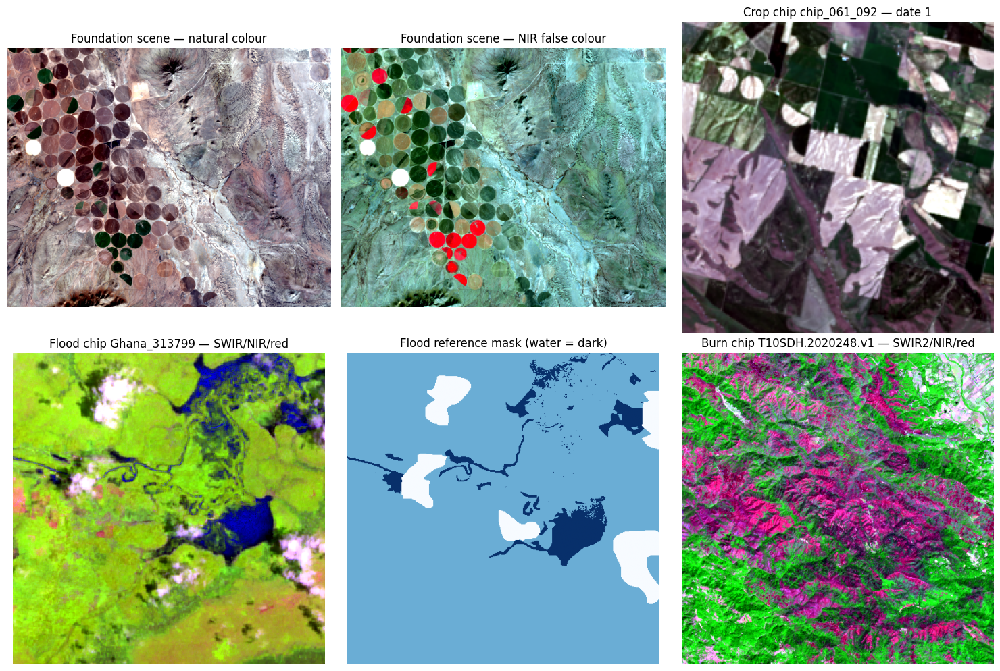

                           input       band       min      mean       max
          foundation date 1 (DN)       BLUE -113.0000  772.2126 3056.0000
          foundation date 1 (DN)      GREEN  -46.0000 1129.0518 3761.0000
          foundation date 1 (DN)        RED   14.0000 1618.6709 4518.0000
          foundation date 1 (DN) NIR_NARROW   72.0000 2385.0425 5513.0000
          foundation date 1 (DN)     SWIR_1  194.0000 3080.0100 6124.0000
          foundation date 1 (DN)     SWIR_2  125.0000 2464.9578 5654.0000
flood Ghana_313799 (reflectance)       BLUE    0.0936    0.1130    0.2992
flood Ghana_313799 (reflectance)      GREEN    0.0775    0.1103    0.2979
flood Ghana_313799 (reflectance)        RED    0.0499    0.0799    0.3033
flood Ghana_313799 (reflectance) NIR_NARROW    0.0938    0.3442    0.5372
flood Ghana_313799 (reflectance)     SWIR_1    0.0391    0.1802    0.4515
flood Ghana_313799 (reflectance)     SWIR_2    0.0186    0.0811    0.3522


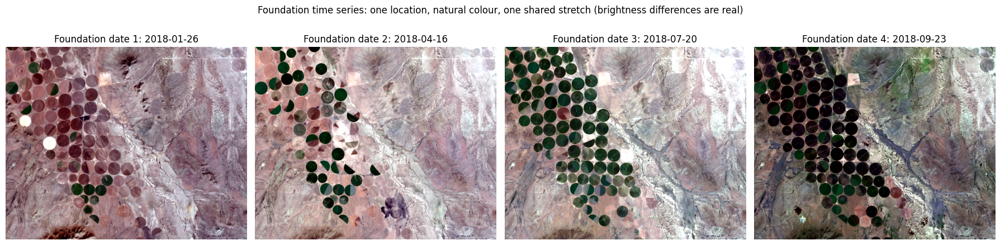

  date   acquired
date 1 2018-01-26
date 2 2018-04-16
date 3 2018-07-20
date 4 2018-09-23


In [28]:
import datetime
import re

flood_example = EVAL_DATA["flood"][0]
burn_example = EVAL_DATA["burnscar"][0]
crop_example = EVAL_DATA["crop"][0]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(percentile_rgb(foundation_stack[0]))
axes[0, 0].set_title("Foundation scene — natural colour")
axes[0, 1].imshow(false_color(foundation_stack[0]))
axes[0, 1].set_title("Foundation scene — NIR false colour")
axes[0, 2].imshow(percentile_rgb(crop_example["image"][:6]))
axes[0, 2].set_title(f"Crop chip {crop_example['id']} — date 1")
axes[1, 0].imshow(false_color(flood_example["image"], (4, 3, 2)))
axes[1, 0].set_title(f"Flood chip {flood_example['id']} — SWIR/NIR/red")
axes[1, 1].imshow(flood_example["label"], vmin=-1, vmax=1, cmap="Blues")
axes[1, 1].set_title("Flood reference mask (water = dark)")
axes[1, 2].imshow(false_color(burn_example["image"], (5, 3, 2)))
axes[1, 2].set_title(f"Burn chip {burn_example['id']} — SWIR2/NIR/red")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
save_figure(OUTPUT_ROOT / "figures" / "eo_inputs_overview.png", dpi=150, bbox_inches="tight")
plt.show()

band_stats = pd.DataFrame(
    [
        {"input": name, "band": band, "min": float(img[i].min()), "mean": float(img[i].mean()), "max": float(img[i].max())}
        for name, img in (("foundation date 1 (DN)", foundation_stack[0]), (f"flood {flood_example['id']} (reflectance)", flood_example["image"]))
        for i, band in enumerate(BANDS)
    ]
).round(4)
print(band_stats.to_string(index=False))


# The foundation time series: one location on four dates. HLS file names carry the acquisition as YYYYDDD
# (year and day of year), e.g. ...2018026T173609 -> 2018-01-26.
def acquisition_date(stem):
    match = re.search(r"\.(\d{4})(\d{3})T\d{6}", stem)
    if match is None:
        return stem
    return (datetime.date(int(match[1]), 1, 1) + datetime.timedelta(days=int(match[2]) - 1)).isoformat()


FOUNDATION_DATES = [acquisition_date(p.stem) for p in SCENE_PATHS["foundation"]]
dates_limits = rgb_limits(foundation_stack)
fig, axes = plt.subplots(1, len(foundation_stack), figsize=(4.5 * len(foundation_stack), 4.8))
for i, (ax, scene) in enumerate(zip(axes, foundation_stack)):
    ax.imshow(percentile_rgb(scene, limits=dates_limits))
    ax.set_title(f"Foundation date {i + 1}: {FOUNDATION_DATES[i]}")
    ax.axis("off")
fig.suptitle("Foundation time series: one location, natural colour, one shared stretch (brightness differences are real)")
plt.tight_layout()
save_figure(OUTPUT_ROOT / "figures" / "foundation_dates.png", dpi=130, bbox_inches="tight")
plt.show()
print(pd.DataFrame({"date": [f"date {i + 1}" for i in range(len(FOUNDATION_DATES))], "acquired": FOUNDATION_DATES}).to_string(index=False))

# 7. Capability A — Prithvi EO foundation representations

A foundation model does not inherently answer "is this flooded?" or "what crop is this?" Its encoder first produces a representation of the observation.

We will inspect two things:

1. **Embeddings** — 1024-dimensional representations from the final Prithvi encoder layer: the CLS token and the mean over all patch tokens.
2. **Masked reconstruction** — hide 75% of image patches and ask the pretrained model to reconstruct them.

The reconstruction score is compared with a simple **mean-fill baseline** that fills every hidden patch with the mean of the visible pixels of the same band and date. This is a check on the pretraining objective, not a measure of downstream environmental skill. An embedding has no intrinsic accuracy: judging whether it is useful for, say, flood mapping needs labelled chips and a downstream probe, which the Prithvi feature-extraction DIMER E2E tutorial demonstrates.

**Prediction:** Look at the four dated foundation images at the end of §6. Before running the next cells, which two dates do you expect to have the most similar embeddings, and why?

In [29]:
# Foundation-model loader and inference helpers.
from terratorch.models.backbones.prithvi_mae import PrithviMAE

FOUNDATION_CONFIG = {
    "img_size": 224, "patch_size": (1, 16, 16), "num_frames": 4, "in_chans": 6, "embed_dim": 1024, "depth": 24,
    "num_heads": 16, "decoder_embed_dim": 512, "decoder_depth": 8, "decoder_num_heads": 16, "mlp_ratio": 4.0,
    "coords_encoding": [], "coords_scale_learn": False, "mask_ratio": 0.75, "norm_pix_loss": False,
}
FOUNDATION_MEANS = (1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0)
FOUNDATION_STDS = (2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0)


def build_foundation_model():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return PrithviMAE(**FOUNDATION_CONFIG)


def normalise_foundation(frames, *, name="frames"):
    """(6, T, H, W) HLS digital numbers from `validate_foundation_scene` -> standardised; -9999 no-data -> 0.0001 as the
    upstream inference script. Units were decided once, at validation: this function never rescales its input."""
    x = np.asarray(frames, dtype=np.float32)
    if x.ndim != 4 or x.shape[0] != 6:
        raise ValueError(f"{name}: expected (6, T, H, W), got {x.shape}")
    if not 1 <= x.shape[1] <= 4:
        raise ValueError(f"{name}: the checkpoint was pretrained on up to 4 dates; got {x.shape[1]}")
    mean = np.asarray(FOUNDATION_MEANS, dtype=np.float32)[:, None, None, None]
    std = np.asarray(FOUNDATION_STDS, dtype=np.float32)[:, None, None, None]
    x = np.where(x == NODATA, 0.0001, (x - mean) / std)
    return np.ascontiguousarray(x.astype(np.float32))

def load_foundation_model():
    ckpt, audit = fetch_checkpoint("foundation")
    state = torch.load(ckpt, map_location="cpu", weights_only=True)
    if not isinstance(state, dict) or any(not isinstance(v, torch.Tensor) for v in state.values()):
        raise ValueError("foundation checkpoint did not unpickle to a state dict of tensors")
    model = build_foundation_model()
    model.load_state_dict(state, strict=True)  # every key must match: no silently random weights
    del state
    fresh, converted = convert_and_reload("foundation", model, build_foundation_model)
    del model
    gc.collect()
    return fresh, audit, converted


def foundation_embedding(model, frames, *, name="frames"):
    batch = torch.from_numpy(normalise_foundation(frames, name=name)[None]).to(DEVICE)
    with torch.inference_mode():
        features = model.encoder.forward_features(batch)
    final = features[-1]
    dim = FOUNDATION_CONFIG["embed_dim"]
    if final.ndim != 3 or final.shape[0] != 1 or final.shape[1] < 2 or final.shape[-1] != dim:
        raise InvalidModelOutput(f"{name}: unexpected encoder output shape {tuple(final.shape)}")
    cls = final[:, 0].float().cpu().numpy()[0]
    mean_patch = final[:, 1:].float().mean(dim=1).cpu().numpy()[0]
    check_embedding(cls, name=f"{name} CLS embedding", dim=dim)
    check_embedding(mean_patch, name=f"{name} mean-patch embedding", dim=dim)
    return cls, mean_patch

def foundation_reconstruction(model, frames, mask_ratio=0.75, seed=42):
    """Seeded masked-patch reconstruction. TerraTorch returns the prediction and the (B, T, H, W) pixel mask
    already un-patchified (1 = masked). MSE over masked patches in standardised units vs a mean-fill baseline."""
    torch.manual_seed(seed)
    batch = torch.from_numpy(normalise_foundation(frames)[None]).to(DEVICE)
    with torch.inference_mode():
        loss, pred, mask = model(batch, None, None, mask_ratio)
    loss_value = float(loss["loss"] if isinstance(loss, Mapping) else loss)
    if mask.ndim != 4 or pred.shape != batch.shape:
        raise InvalidModelOutput(f"unexpected PrithviMAE output shapes: pred {tuple(pred.shape)}, mask {tuple(mask.shape)}")
    if not np.isfinite(loss_value) or not bool(torch.isfinite(pred).all()):
        raise InvalidModelOutput("masked reconstruction returned a non-finite loss or prediction; no result is recorded")
    mask_b = mask[:, None].expand(-1, batch.shape[1], -1, -1, -1).to(batch.dtype)  # (1, 6, T, H, W)
    visible = mask_b == 0
    baseline = batch.clone()
    for band in range(batch.shape[1]):
        for frame in range(batch.shape[2]):
            plane, keep = batch[0, band, frame], visible[0, band, frame]
            baseline[0, band, frame][~keep] = plane[keep].mean() if bool(keep.any()) else 0.0
    target = model.patchify(batch)
    patch_mask = model.patchify(mask_b).mean(-1)
    baseline_loss = (((model.patchify(baseline) - target) ** 2).mean(-1) * patch_mask).sum() / patch_mask.sum()
    merged = torch.where(mask_b.bool(), pred.to(batch.dtype), batch)
    return {
        "masked_mse": round(loss_value, 6),
        "baseline_mean_fill_mse": round(float(baseline_loss), 6),
        "masked_fraction": round(float(mask.float().mean()), 4),
        "masked_pixel_positions": int(mask.sum()),
        "mask_ratio": mask_ratio,
        "seed": seed,
        "units": "standardised (the pretraining loss)",
        "reconstruction_standardised": merged[0].float().cpu().numpy(),
        "mask": mask[0].float().cpu().numpy(),
    }


def reconstruction_record(result, scene_id):
    """The JSON-serialisable part of a reconstruction result (arrays dropped)."""
    return {"scene_id": scene_id, **{k: v for k, v in result.items() if not isinstance(v, np.ndarray)}}


def reconstruction_panels(ax_masked, ax_rec, frames, result, *, date=0, limits=None):
    """One date as the model saw it (hidden patches grey) and with the hidden patches reconstructed, both on the
    observed image's display stretch, so observed and reconstructed pixels can be told apart."""
    mean = np.asarray(FOUNDATION_MEANS, dtype=np.float32)[:, None, None, None]
    std = np.asarray(FOUNDATION_STDS, dtype=np.float32)[:, None, None, None]
    observed = np.asarray(frames, dtype=np.float32)[:, date]
    limits = limits or rgb_limits([observed])
    shown = percentile_rgb(observed, limits=limits)
    shown[result["mask"][date] > 0] = 0.5
    ax_masked.imshow(shown)
    ax_masked.set_title(f"Date {date + 1} as the model saw it: {result['mask_ratio']:.0%} of patches hidden (grey)")
    reconstructed = (result["reconstruction_standardised"] * std + mean)[:, date]
    ax_rec.imshow(percentile_rgb(reconstructed, limits=limits))
    ax_rec.set_title(
        f"Visible patches + reconstruction of the {result['mask_ratio']:.0%} hidden\n"
        f"masked MSE={result['masked_mse']:.4f}; mean-fill={result['baseline_mean_fill_mse']:.4f}"
    )

/content/dimer_eo_env/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


GPU MiB still allocated after release: 8.1


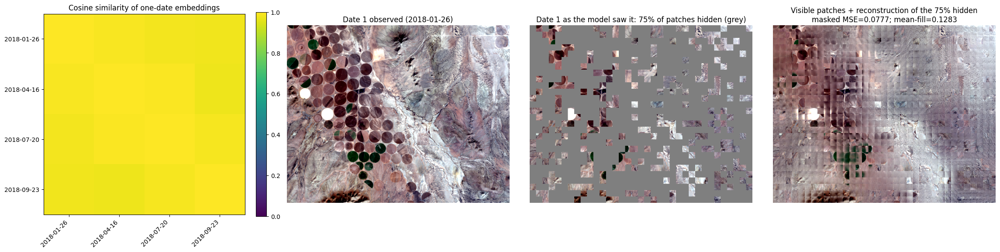

                     date 1 (2018-01-26)  date 2 (2018-04-16)  date 3 (2018-07-20)  date 4 (2018-09-23)
date 1 (2018-01-26)                1.000                0.992                0.982                0.978
date 2 (2018-04-16)                0.992                1.000                0.995                0.976
date 3 (2018-07-20)                0.982                0.995                1.000                0.985
date 4 (2018-09-23)                0.978                0.976                0.985                1.000
{'embedding_dim': 1024, 'token_semantics': 'final normalised encoder layer; CLS token and mean over all patch tokens', 'reconstruction': {'mask_ratio': 0.75, 'masked_mse': 0.077686, 'mean_fill_mse': 0.128289}}


In [30]:
foundation_model, foundation_audit, foundation_converted = load_foundation_model()

# Four chronological images of the same location -> (6, T, H, W)
foundation_frames = np.stack(foundation_stack, axis=1)
date_ids = [p.stem for p in SCENE_PATHS["foundation"]]
date_labels = [f"date {i + 1} ({d})" for i, d in enumerate(FOUNDATION_DATES)]
FOUNDATION_SCENE_ID = "+".join(date_ids)
# The canonical ratio is the pretraining ratio. Do not edit it here: the controlled-change activity (§14) runs its own
# ratio in a separate cell, with separate state and output files.
CANONICAL_MASK_RATIO = FOUNDATION_CONFIG["mask_ratio"]

scene_cls, scene_mean = foundation_embedding(foundation_model, foundation_frames, name="foundation stack")
date_cls, date_mean = [], []
for i in range(foundation_frames.shape[1]):
    c, m = foundation_embedding(foundation_model, foundation_frames[:, i:i + 1], name=date_ids[i])
    date_cls.append(c)
    date_mean.append(m)
date_mean = np.stack(date_mean)
normed = date_mean / np.linalg.norm(date_mean, axis=1, keepdims=True)
similarity = normed @ normed.T

save_npz(
    OUTPUT_ROOT / "embeddings" / "prithvi_embeddings.npz",
    scene_id=np.array([FOUNDATION_SCENE_ID]),
    scene_cls=scene_cls[None],
    scene_mean_patch=scene_mean[None],
    date_ids=np.array(date_ids),
    date_acquired=np.array(FOUNDATION_DATES),
    date_cls=np.stack(date_cls),
    date_mean_patch=date_mean,
    date_cosine_similarity=similarity,
)

reconstruction_result = None
if RUN_RECONSTRUCTION:
    reconstruction_result = foundation_reconstruction(foundation_model, foundation_frames, mask_ratio=CANONICAL_MASK_RATIO, seed=SEED)
    save_json(OUTPUT_ROOT / "metrics" / "reconstruction.json", reconstruction_record(reconstruction_result, FOUNDATION_SCENE_ID))

del foundation_model
print("GPU MiB still allocated after release:", free_accelerator())

fig, axes = plt.subplots(1, 4, figsize=(23, 5.5))
im = axes[0].imshow(similarity, vmin=0, vmax=1)
axes[0].set_title("Cosine similarity of one-date embeddings")
axes[0].set_xticks(range(len(FOUNDATION_DATES)), FOUNDATION_DATES, rotation=45, ha="right")
axes[0].set_yticks(range(len(FOUNDATION_DATES)), FOUNDATION_DATES)
plt.colorbar(im, ax=axes[0], fraction=0.046)
date1_limits = rgb_limits([foundation_stack[0]])
axes[1].imshow(percentile_rgb(foundation_stack[0], limits=date1_limits))
axes[1].set_title(f"Date 1 observed ({FOUNDATION_DATES[0]})")
if reconstruction_result is not None:
    reconstruction_panels(axes[2], axes[3], foundation_frames, reconstruction_result, date=0, limits=date1_limits)
else:
    axes[2].text(0.5, 0.5, "Reconstruction disabled", ha="center", va="center")
for ax in axes[1:]:
    ax.axis("off")
plt.tight_layout()
save_figure(OUTPUT_ROOT / "figures" / "foundation_representation.png", dpi=150, bbox_inches="tight")
plt.show()

print(pd.DataFrame(similarity, index=date_labels, columns=date_labels).round(3).to_string())
print({
    "embedding_dim": int(scene_mean.shape[0]),
    "token_semantics": "final normalised encoder layer; CLS token and mean over all patch tokens",
    "reconstruction": None if reconstruction_result is None else {
        "mask_ratio": reconstruction_result["mask_ratio"],
        "masked_mse": reconstruction_result["masked_mse"],
        "mean_fill_mse": reconstruction_result["baseline_mean_fill_mse"],
    },
})

### What did we learn?

The 1024-dimensional vectors are **representations**, not climate labels. A similarity score only says two scenes are close under the model's representation; it is not a calibrated probability that the landscapes are "the same."

Masked reconstruction is also not a hazard metric. It asks whether the pretrained encoder-decoder can recover deliberately hidden patches under the pretraining objective.

The next sections move from general representation learning to **task-specific environmental maps**.

# 8. Capability B — flood mapping

**Input:** six-band Sentinel-2 chip, 512×512 (a 13-band L1C stack is reduced to the six Prithvi bands)
**Output:** one class per pixel: water versus no water, plus the model's water score
**Decision rule:** argmax over the two class scores (no threshold)

The live DIMER profile is a Prithvi-EO-2.0 model fine-tuned on Sen1Floods11. The notebook builds the same architecture (UPerNet decoder over four encoder depths) and loads the converted weights.

**Evaluation:** 12 hand-labelled chips from the official Sen1Floods11 **test** split, which the checkpoint did not train on. Metrics are pooled over all labelled pixels (cloud / no-data pixels excluded). The baseline predicts **no water everywhere**: it shows how much pixel accuracy a useless map can score when water is the minority class.

A predicted flood mask is **not a flood forecast**. It describes what the model detects in the supplied observation.

In [31]:
from terratorch.models import EncoderDecoderFactory

_NECKS = (
    {"name": "SelectIndices", "indices": [5, 11, 17, 23]},
    {"name": "ReshapeTokensToImage"},
    {"name": "LearnedInterpolateToPyramidal"},
)
SEG_SPECS = {
    "flood": {
        "backbone": "prithvi_eo_v2_300_tl", "decoder": "UperNetDecoder",
        "decoder_args": {"decoder_channels": 256}, "head_args": {"head_dropout": 0.1},
        "means": (0.1412956, 0.13795798, 0.12353792, 0.30902815, 0.2044958, 0.11912015),
        "stds": (0.07406382, 0.07370365, 0.08692279, 0.11798815, 0.09772074, 0.07659938),
        "class_names": ("no water", "water"),
    },
    "burnscar": {
        "backbone": "prithvi_eo_v2_300", "decoder": "UNetDecoder",
        "decoder_args": {"decoder_channels": [512, 256, 128, 64]}, "head_args": {},
        "means": (0.033349706741586264, 0.05701185520536176, 0.05889748132001316, 0.2323245113436119, 0.1972854853760658, 0.11944914225186566),
        "stds": (0.02269135568823774, 0.026807560223070237, 0.04004109844362779, 0.07791732423672691, 0.08708738838140137, 0.07241979477437814),
        "class_names": ("not burned", "burn scar"),
    },
}


def build_segmentation_model(capability):
    spec = SEG_SPECS[capability]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return EncoderDecoderFactory().build_model(
            task="segmentation", backbone=spec["backbone"], backbone_pretrained=False, backbone_bands=list(BANDS),
            decoder=spec["decoder"], num_classes=2, rescale=True, necks=[dict(n) for n in _NECKS],
            **spec["decoder_args"], **spec["head_args"],
        )


def load_segmentation_model(capability):
    """Audited checkpoint -> weights-only unpickle -> strict load -> SafeTensors (pinned digest) -> fresh strict load."""
    ckpt, audit = fetch_checkpoint(capability)
    payload = torch.load(ckpt, map_location="cpu", weights_only=True)
    if not isinstance(payload, dict) or "state_dict" not in payload:
        raise ValueError(f"{capability}: checkpoint is not a Lightning checkpoint with a state_dict")
    state = {}
    for key, value in payload["state_dict"].items():
        if not key.startswith("model."):
            raise ValueError(f"{capability}: unexpected state-dict key {key!r}")
        state[key[len("model."):]] = value
    del payload
    model = build_segmentation_model(capability)
    model.load_state_dict(state, strict=True)
    del state
    fresh, converted = convert_and_reload(capability, model, lambda: build_segmentation_model(capability))
    del model
    gc.collect()
    return fresh, audit, converted


def segment(model, capability, images, batch_size=2):
    """(N, 6, 512, 512) reflectance -> masks (N, H, W) uint8 and positive-class scores (N, H, W) float32. The class
    scores are checked (shape, finite values, probabilities, label domain) before any mask is formed: an invalid
    output raises InvalidModelOutput instead of becoming an ordinary-looking map."""
    spec = SEG_SPECS[capability]
    n_classes = len(spec["class_names"])
    mean = np.asarray(spec["means"], dtype=np.float32)[None, :, None, None]
    std = np.asarray(spec["stds"], dtype=np.float32)[None, :, None, None]
    masks, scores = [], []
    for start in range(0, len(images), batch_size):
        batch = torch.from_numpy(((np.asarray(images[start:start + batch_size]) - mean) / std).astype(np.float32)).to(DEVICE)
        with torch.inference_mode(), torch.autocast(device_type=DEVICE.split(":")[0], dtype=torch.float16, enabled=USE_AMP):
            out = model(batch)
        logits = (out.output if hasattr(out, "output") else out).float()
        name = f"{capability} model output (images {start}..{start + batch.shape[0] - 1})"
        if logits.ndim == 4 and tuple(logits.shape[-2:]) != tuple(batch.shape[-2:]):
            note(name, f"class scores resized {tuple(logits.shape[-2:])} -> {tuple(batch.shape[-2:])} (bilinear) before argmax")
            logits = torch.nn.functional.interpolate(logits, size=batch.shape[-2:], mode="bilinear", align_corners=False)
        check_class_scores(logits, name=name, batch=batch.shape[0], num_classes=n_classes, spatial=batch.shape[-2:])
        prob = torch.softmax(logits, dim=1)
        check_probabilities(prob, name=name)
        mask = prob.argmax(dim=1).to(torch.uint8).cpu().numpy()
        check_class_map(mask, name=name, num_classes=n_classes)
        masks.append(mask)
        scores.append(prob[:, 1].cpu().numpy().astype(np.float32))
    return np.concatenate(masks), np.concatenate(scores)

def run_binary_capability(capability, title):
    """Load, evaluate on the labelled test chips against the all-negative baseline, infer the new scene, export."""
    positive = SEG_SPECS[capability]["class_names"][1]
    model, audit, converted = load_segmentation_model(capability)
    records = EVAL_DATA[capability]
    masks, scores = segment(model, capability, [r["image"] for r in records])
    new_mask, new_score = segment(model, capability, [NEW_SCENES[capability]["image"]])
    del model
    freed = free_accelerator()

    labels = [r["label"] for r in records]
    metrics = binary_metrics(masks, labels, positive)
    baseline = binary_metrics([np.zeros_like(l) for l in labels], labels, positive)
    per_chip = [
        {"id": r["id"], **{k: v for k, v in binary_metrics([m], [r["label"]], positive).items() if k != "confusion_rows_truth_cols_pred"}}
        for r, m in zip(records, masks)
    ]
    report = {
        "capability": capability,
        "model": {"id": MODEL_SPECS[capability]["model_id"], "revision": MODEL_SPECS[capability]["revision"]},
        "evaluation": {
            "dataset": EVAL_SETS[capability]["dataset"], "n_chips": len(records),
            "procedure": "held-out test chips; pixel-pooled over labelled pixels, ignore index excluded; no model selection in this notebook",
            "evidence": "tutorial sample metrics (12 chips), not a benchmark or operational estimate",
        },
        "decision_rule": "argmax over the two class scores (no threshold)",
        "scores_are_calibrated_probabilities": False,
        "precision": PRECISION[capability],
        "model_metrics": metrics,
        "baseline_all_negative": baseline,
        "per_chip": per_chip,
        "new_scene": {"id": NEW_SCENES[capability]["id"], "predicted_positive_fraction": round(float(new_mask[0].mean()), 4)},
        "pickle_audit": audit,
        "converted_weights": str(converted),
    }
    save_json(OUTPUT_ROOT / "metrics" / f"{capability}_metrics.json", report)
    pred_dir = OUTPUT_ROOT / "predictions" / capability
    pred_dir.mkdir(parents=True, exist_ok=True)
    save_npz(pred_dir / "evaluation_predictions.npz", ids=np.array([r["id"] for r in records]),
                        mask=masks, positive_score=scores.astype(np.float16), class_names=np.array(SEG_SPECS[capability]["class_names"]))
    save_npz(pred_dir / "new_scene_prediction.npz", ids=np.array([NEW_SCENES[capability]["id"]]),
                        mask=new_mask, positive_score=new_score.astype(np.float16), class_names=np.array(SEG_SPECS[capability]["class_names"]))

    rgb_idx = (2, 1, 0) if capability == "flood" else (5, 3, 2)
    fig, axes = plt.subplots(3, 4, figsize=(18, 13))
    for row, i in enumerate((0, 1)):
        r = records[i]
        axes[row, 0].imshow(percentile_rgb(r["image"], rgb_idx))
        axes[row, 0].set_title(f"{r['id']} — input")
        axes[row, 1].imshow(np.where(r["label"] < 0, np.nan, r["label"]), vmin=0, vmax=1)
        axes[row, 1].set_title("Reference")
        axes[row, 2].imshow(masks[i], vmin=0, vmax=1)
        axes[row, 2].set_title(f"Prediction (chip IoU {per_chip[i]['positive_iou']:.2f})")
        axes[row, 3].imshow(disagreement_map(masks[i], r["label"]), cmap=DISAGREE_CMAP, vmin=0, vmax=3)
        axes[row, 3].set_title("Disagreement: red = false +, blue = missed, grey = unlabelled")
    axes[2, 0].imshow(percentile_rgb(NEW_SCENES[capability]["image"], rgb_idx))
    axes[2, 0].set_title(f"New scene {NEW_SCENES[capability]['id'][:28]}")
    axes[2, 1].imshow(new_mask[0], vmin=0, vmax=1)
    axes[2, 1].set_title("New-scene prediction")
    im = axes[2, 2].imshow(new_score[0], vmin=0, vmax=1)
    axes[2, 2].set_title("New-scene positive score\n(not a calibrated probability)")
    plt.colorbar(im, ax=axes[2, 2], fraction=0.046)
    axes[2, 3].axis("off")
    for ax in axes.ravel():
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    save_figure(OUTPUT_ROOT / "figures" / f"{capability}_mapping.png", dpi=130, bbox_inches="tight")
    plt.show()

    table = pd.DataFrame(
        {"model": {k: metrics[k] for k in ("positive_iou", "f1", "precision", "recall", "pixel_accuracy", "predicted_positive_fraction")},
         f"baseline (all '{SEG_SPECS[capability]['class_names'][0]}')": {k: baseline[k] for k in ("positive_iou", "f1", "precision", "recall", "pixel_accuracy", "predicted_positive_fraction")}}
    )
    print(table)
    print({"reference_positive_fraction": metrics["reference_positive_fraction"], "labelled_pixels": metrics["labelled_pixels"],
           "GPU MiB still allocated after release": freed})
    return report

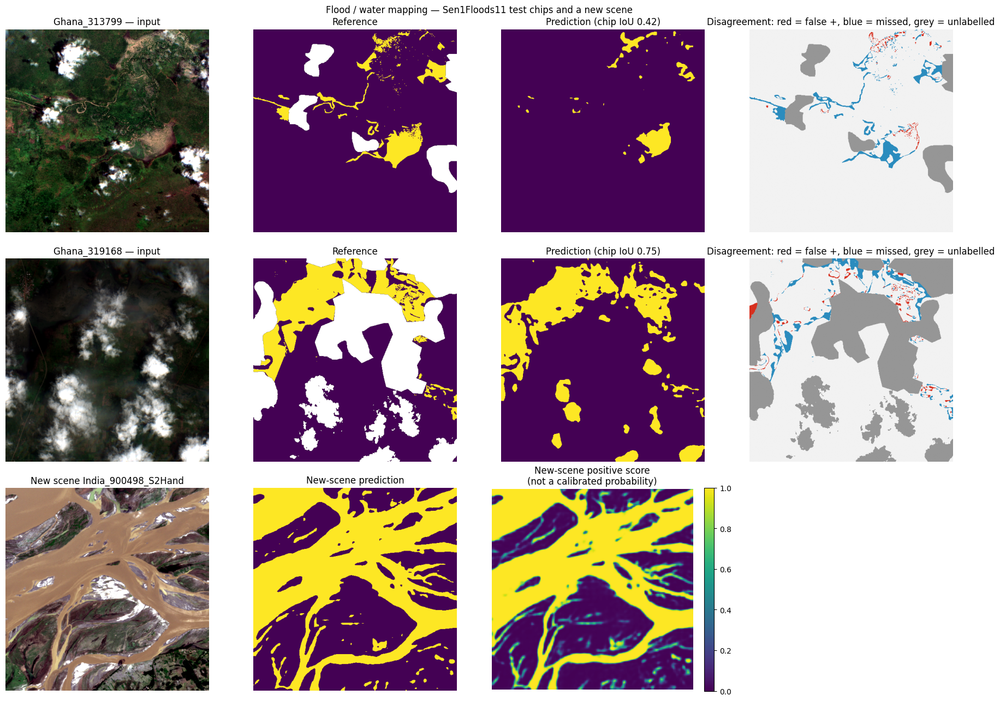

                              model  baseline (all 'no water')
positive_iou                 0.7301                     0.0000
f1                           0.8440                     0.0000
precision                    0.9251                     0.0000
recall                       0.7760                     0.0000
pixel_accuracy               0.9440                     0.8049
predicted_positive_fraction  0.1637                     0.0000
{'reference_positive_fraction': 0.1951, 'labelled_pixels': 2859426, 'GPU MiB still allocated after release': 8.1}


In [32]:
flood_report = None
if RUN_FLOOD_MAPPING:
    flood_report = run_binary_capability("flood", "Flood / water mapping — Sen1Floods11 test chips and a new scene")
else:
    print("Flood mapping disabled.")

### Interpretation checkpoint

Compare the model row with the baseline row. The baseline's pixel accuracy is simply the share of labelled pixels that are not water, yet its water IoU and F1 are zero. That gap is why this notebook reports IoU and F1 first.

A pixel map can look convincing even when it is wrong. Twelve chips from a public test split say little about skill in another region, season or sensor. Before operational use, a flood-mapping model must be evaluated against representative local reference data across different flood types, land covers, cloud conditions, seasons, and sensors.

The positive-class score shown above is a model score. It is **not** presented as a calibrated probability of flooding.

# 9. Capability C — burn-scar mapping

**Input:** six-band HLS scene, 512×512
**Output:** burned versus not-burned class per pixel, plus the model's burn score
**Decision rule:** argmax over the two class scores (no threshold)

The live DIMER profile is the upstream Prithvi-EO-2.0 burn-scar fine-tune (UNet decoder), loaded here from the converted weights.

**Evaluation:** 12 labelled scenes from the test role of the burn-scar model repository's splits, streamed from the HLS Burn Scars archive. The baseline predicts **not burned everywhere**.

Burned-area mapping benefits from near-infrared and short-wave infrared information that is absent from ordinary RGB imagery; the inputs below are shown as SWIR 2 / NIR / red false colour.

**Exercise:** Before running the cell, predict: will the not-burned baseline have high or low pixel accuracy? What will its burn-scar IoU be?

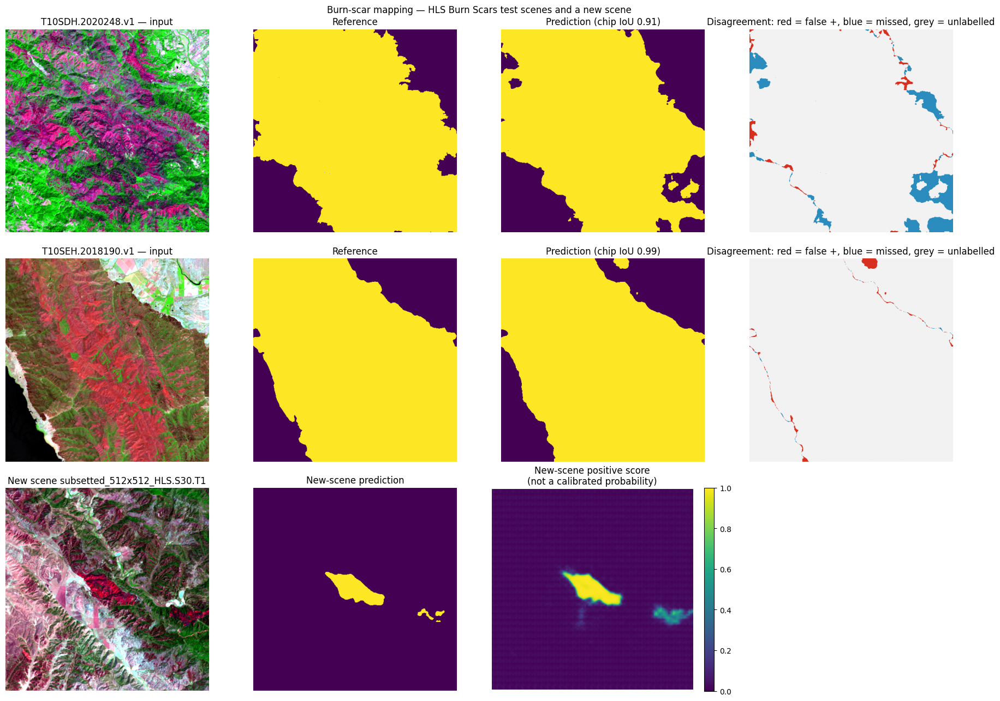

                              model  baseline (all 'not burned')
positive_iou                 0.9250                       0.0000
f1                           0.9611                       0.0000
precision                    0.9528                       0.0000
recall                       0.9695                       0.0000
pixel_accuracy               0.9833                       0.7869
predicted_positive_fraction  0.2169                       0.0000
{'reference_positive_fraction': 0.2131, 'labelled_pixels': 3145652, 'GPU MiB still allocated after release': 8.1}


In [33]:
burn_report = None
if RUN_BURNSCAR_MAPPING:
    burn_report = run_binary_capability("burnscar", "Burn-scar mapping — HLS Burn Scars test scenes and a new scene")
else:
    print("Burn-scar mapping disabled.")

### What to notice

Overall accuracy can be dominated by the background class when the environmental phenomenon occupies only a small fraction of pixels. The baseline row above shows this directly: a map with no burn scars at all scores high pixel accuracy and zero burn-scar IoU. Positive-class IoU and F1, together with precision (how many predicted burn pixels are real) and recall (how many real burn pixels were found), describe the minority class that matters.

This notebook does not infer "fire severity" or "cause." It demonstrates the checkpoint's burned/not-burned mapping capability.

# 10. Capability D — multi-temporal crop / land-cover mapping

The crop model demonstrates why **time** matters in Earth observation.

Its input is one 224×224 site observed at **three dates**, with six HLS bands per date. The model predicts one of 13 crop/land-cover classes for every pixel (decision rule: argmax over the 13 class scores).

The legacy upstream checkpoint was trained with mmsegmentation. To keep the notebook compatible with the current hosted runtime and avoid the legacy mmcv stack, this notebook carries the small plain-PyTorch architecture used by the live DIMER profile, verifies the upstream checkpoint digest, performs a restricted one-time conversion to SafeTensors, and reloads the resulting inference network.

**Evaluation:** 12 labelled chips from spatially blocked test cells of the upstream **validation** archive, scored with mean IoU, mean class accuracy, per-class IoU and recall, against the **majority-class** constant map. The upstream authors may have used this validation split to select their checkpoint, so these numbers can be optimistic; they are tutorial evidence only.

The model's classes are specific to this checkpoint (a US cropland taxonomy); they are not a universal land-cover taxonomy.

In [34]:
# Plain-PyTorch Prithvi-EO-1.0 crop model, aligned to the live DIMER profile.

from torch import nn

CROP_CLASS_NAMES = (
    "Natural Vegetation", "Forest", "Corn", "Soybeans", "Wetlands",
    "Developed/Barren", "Open Water", "Winter Wheat", "Alfalfa",
    "Fallow/Idle Cropland", "Cotton", "Sorghum", "Other",
)
CROP_MEANS = (494.905781, 815.239594, 924.335066, 2968.881459, 2634.621962, 1739.579917)
CROP_STDS = (284.925432, 357.84876, 575.566823, 896.601013, 951.900334, 921.407808)

def _sincos_1d(embed_dim, positions):
    omega = torch.arange(embed_dim // 2, dtype=torch.float64) / (embed_dim / 2.0)
    omega = 1.0 / torch.pow(10000.0, omega)
    out = positions.to(torch.float64).reshape(-1, 1) * omega.reshape(1, -1)
    return torch.cat([torch.sin(out), torch.cos(out)], dim=1)

def sincos_pos_embed_3d(embed_dim, grid_size, cls_token=True):
    if embed_dim % 16:
        raise ValueError("embed_dim must be a multiple of 16")
    t, h, w = grid_size
    wd = hd = embed_dim // 16 * 6
    td = embed_dim // 16 * 4
    wp = _sincos_1d(wd, torch.arange(w)).repeat(t * h, 1)
    hp = _sincos_1d(hd, torch.arange(h)).repeat_interleave(w, dim=0).repeat(t, 1)
    tp = _sincos_1d(td, torch.arange(t)).repeat_interleave(h * w, dim=0)
    pos = torch.cat([wp, hp, tp], dim=1)
    if cls_token:
        pos = torch.cat([torch.zeros(1, embed_dim, dtype=pos.dtype), pos], dim=0)
    return pos.float()

class CropPatchEmbed(nn.Module):
    def __init__(self):
        super().__init__()
        self.grid_size = (3, 14, 14)
        self.proj = nn.Conv3d(6, 768, kernel_size=(1,16,16), stride=(1,16,16))
    def forward(self, x):
        x = self.proj(x)
        return x.flatten(2).transpose(1, 2)

class CropAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.num_heads = 8
        self.head_dim = 96
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(768, 2304)
        self.proj = nn.Linear(768, 768)
    def forward(self, x):
        b, n, d = x.shape
        qkv = self.qkv(x).reshape(b,n,3,8,96).permute(2,0,3,1,4)
        q,k,v = qkv.unbind(0)
        a = (q @ k.transpose(-2,-1)) * self.scale
        a = a.softmax(dim=-1)
        return self.proj((a @ v).transpose(1,2).reshape(b,n,d))

class CropMlp(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(768, 3072)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(3072, 768)
    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

class CropBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = nn.LayerNorm(768)
        self.attn = CropAttention()
        self.norm2 = nn.LayerNorm(768)
        self.mlp = CropMlp()
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))

class CropEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = CropPatchEmbed()
        self.cls_token = nn.Parameter(torch.zeros(1,1,768))
        self.pos_embed = nn.Parameter(
            sincos_pos_embed_3d(768, self.patch_embed.grid_size, True).unsqueeze(0),
            requires_grad=False
        )
        self.blocks = nn.ModuleList([CropBlock() for _ in range(6)])
        self.norm = nn.LayerNorm(768)
    def forward(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed[:,1:,:]
        cls = (self.cls_token + self.pos_embed[:,:1,:]).expand(x.shape[0], -1, -1)
        x = torch.cat([cls,x], dim=1)
        for block in self.blocks:
            x = block(x)
        return self.norm(x)

class CropNorm2d(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ln = nn.LayerNorm(channels, eps=1e-6)
    def forward(self, x):
        return self.ln(x.permute(0,2,3,1)).permute(0,3,1,2).contiguous()

class CropNeck(nn.Module):
    def __init__(self):
        super().__init__()
        c = 2304
        self.fpn1 = nn.Sequential(
            nn.ConvTranspose2d(c,c,2,2), CropNorm2d(c), nn.GELU(),
            nn.ConvTranspose2d(c,c,2,2),
        )
        self.fpn2 = nn.Sequential(
            nn.ConvTranspose2d(c,c,2,2), CropNorm2d(c), nn.GELU(),
            nn.ConvTranspose2d(c,c,2,2),
        )
    def forward(self, tokens):
        x = tokens[:,1:,:].permute(0,2,1).reshape(tokens.shape[0], -1, 14, 14)
        return self.fpn2(self.fpn1(x)).reshape(-1,2304,224,224)

class CropConvModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2304,256,3,padding=1,bias=False)
        self.bn = nn.BatchNorm2d(256)
        self.activate = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.activate(self.bn(self.conv(x)))

class CropHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.convs = nn.Sequential(CropConvModule())
        self.dropout = nn.Dropout2d(0.1)
        self.conv_seg = nn.Conv2d(256,13,1)
    def forward(self, x):
        return self.conv_seg(self.dropout(self.convs(x)))

class PrithviCropSegmenter(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CropEncoder()
        self.neck = CropNeck()
        self.decode_head = CropHead()
    def forward(self, x):
        return self.decode_head(self.neck(self.backbone(x)))

# Inert stand-ins for the three NumPy metadata globals in the legacy mmseg checkpoint.
class _MetaValue:
    def __init__(self, kind, *args):
        self.kind, self.args = kind, args
    def __setstate__(self, state):
        self.state = state

def _meta_scalar(dtype, payload):
    return _MetaValue("numpy.core.multiarray.scalar", dtype, payload)

def _meta_dtype(*args):
    return _MetaValue("numpy.dtype", *args)

def _meta_encode(text, encoding="latin1", *_):
    return text.encode(encoding)

def crop_normalise(scene_dn):
    """(18, 224, 224) HLS digital numbers returned by validate_crop_scene -> standardised (1, 6, 3, 224, 224). The
    units are declared as digital numbers, so already-converted data is never rescaled."""
    x = validate_crop_scene(scene_dn, name="crop model input", units="dn", log=False).reshape(1,18,224,224)
    mean = np.asarray(CROP_MEANS * 3, dtype=np.float32)[None,:,None,None]
    std = np.asarray(CROP_STDS * 3, dtype=np.float32)[None,:,None,None]
    flat = (x - mean) / std
    # Reproduce the historical training layout exactly.
    return np.ascontiguousarray(flat.reshape(1,6,3,224,224))

def load_crop_model():
    """Audited checkpoint -> weights-only unpickle (three data-only NumPy metadata globals bound to inert stand-ins)
    -> drop the training-only auxiliary head -> strict load -> SafeTensors (pinned digest) -> fresh strict load."""
    ckpt, audit = fetch_checkpoint("crop")
    bindings = [
        (_meta_scalar, "numpy.core.multiarray.scalar"),
        (_meta_dtype, "numpy.dtype"),
        (_meta_encode, "_codecs.encode"),
        _MetaValue,
    ]
    with torch.serialization.safe_globals(bindings):
        payload = torch.load(ckpt, map_location="cpu", weights_only=True)
    kept = {k: v for k, v in payload["state_dict"].items() if not k.startswith("auxiliary_head.")}
    del payload
    model = PrithviCropSegmenter()
    model.load_state_dict(kept, strict=True)
    del kept
    fresh, converted = convert_and_reload("crop", model, PrithviCropSegmenter)
    del model
    gc.collect()
    return fresh, ckpt, converted, audit


def predict_crop(model, scene_dn):
    """(18, 224, 224) validated HLS digital numbers -> class map (224, 224) uint8, softmax scores (13, 224, 224) and
    class fractions. The class scores are checked (shape, finite values, probabilities, label domain) before any map
    is formed: an invalid output raises InvalidModelOutput."""
    x = torch.from_numpy(crop_normalise(scene_dn)).to(DEVICE)
    with torch.inference_mode(), torch.autocast(
        device_type=DEVICE.split(":")[0],
        dtype=torch.float16,
        enabled=DEVICE.startswith("cuda")
    ):
        logits = model(x)
    logits = logits.float()
    n_classes = len(CROP_CLASS_NAMES)
    check_class_scores(logits, name="crop model output", batch=1, num_classes=n_classes, spatial=(224, 224))
    prob = torch.softmax(logits, dim=1)
    check_probabilities(prob, name="crop model output")
    scores = prob[0].cpu().numpy()
    mask = scores.argmax(axis=0).astype(np.uint8)
    check_class_map(mask, name="crop model output", num_classes=n_classes)
    fractions = {CROP_CLASS_NAMES[i]: float((mask == i).mean()) for i in range(n_classes)}
    return mask, scores, fractions

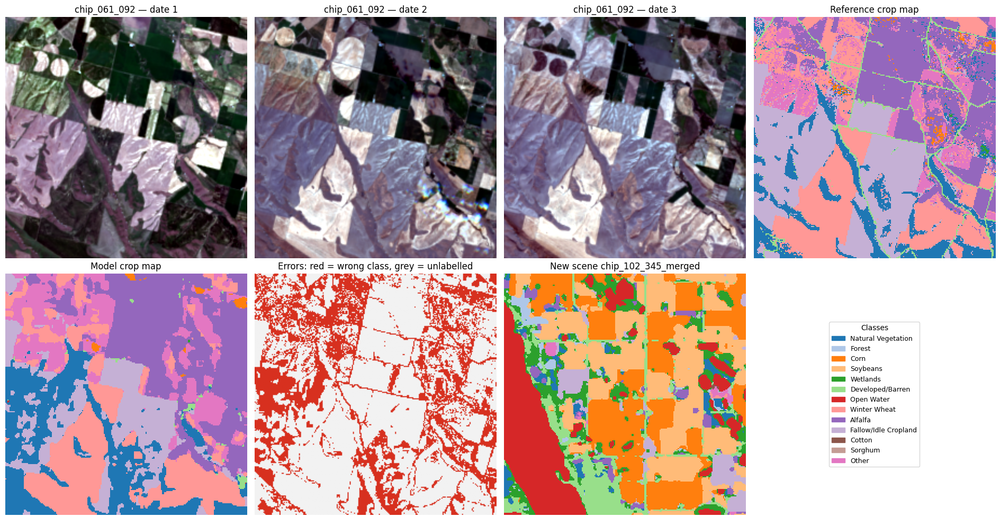

                      model  baseline (all 'Natural Vegetation')
mean_iou             0.4379                               0.0105
mean_class_accuracy  0.6239                               0.0769
pixel_accuracy       0.5905                               0.1371
                         IoU  recall  reference fraction
Natural Vegetation    0.2494  0.3070              0.1371
Forest                0.4288  0.6053              0.1091
Corn                  0.5000  0.5776              0.0968
Soybeans              0.5295  0.7010              0.0852
Wetlands              0.4026  0.5847              0.1034
Developed/Barren      0.3855  0.5851              0.1020
Open Water            0.8090  0.9778              0.0470
Winter Wheat          0.5502  0.6855              0.0629
Alfalfa               0.3857  0.7114              0.0472
Fallow/Idle Cropland  0.3230  0.3890              0.0537
Cotton                0.4321  0.7559              0.0483
Sorghum               0.4158  0.8020              0.0549

In [35]:
crop_report = None
if RUN_CROP_MAPPING:
    crop_model, crop_ckpt, crop_converted, crop_audit = load_crop_model()
    records = EVAL_DATA["crop"]
    predicted = [predict_crop(crop_model, r["image"]) for r in records]
    new_mask, new_scores, new_fractions = predict_crop(crop_model, NEW_SCENES["crop"]["image"])
    del crop_model
    freed = free_accelerator()

    masks = [p[0] for p in predicted]
    labels = [r["label"] for r in records]
    metrics = multiclass_metrics(masks, labels, CROP_CLASS_NAMES)
    counts = np.bincount(np.concatenate([l[l != IGNORE_INDEX] for l in labels]), minlength=13)
    majority = int(counts.argmax())
    baseline = multiclass_metrics([np.full_like(l, majority) for l in labels], labels, CROP_CLASS_NAMES)
    baseline["majority_class"] = CROP_CLASS_NAMES[majority]
    baseline["note"] = "the most frequent class of the scored labels: the best any constant map can do on these pixels"

    crop_report = {
        "capability": "crop",
        "model": {"id": MODEL_SPECS["crop"]["model_id"], "revision": MODEL_SPECS["crop"]["revision"]},
        "classes": list(CROP_CLASS_NAMES),
        "evaluation": {
            "dataset": EVAL_SETS["crop"]["dataset"], "n_chips": len(records),
            "procedure": "spatially blocked chips of the upstream validation archive; pixel-pooled, ignore index excluded",
            "caveat": "the upstream checkpoint may have been selected on this split; numbers can be optimistic",
            "evidence": "tutorial sample metrics (12 chips), not a benchmark or operational estimate",
        },
        "decision_rule": "argmax over 13 softmax scores",
        "scores_are_calibrated_probabilities": False,
        "precision": PRECISION["crop"],
        "model_metrics": metrics,
        "baseline_majority_class": baseline,
        "new_scene": {"id": NEW_SCENES["crop"]["id"], "class_fractions": {k: round(v, 4) for k, v in new_fractions.items()}},
        "pickle_audit": crop_audit,
        "converted_weights": str(crop_converted),
    }
    save_json(OUTPUT_ROOT / "metrics" / "crop_metrics.json", crop_report)
    pred_dir = OUTPUT_ROOT / "predictions" / "crop"
    pred_dir.mkdir(parents=True, exist_ok=True)
    save_npz(pred_dir / "evaluation_predictions.npz", ids=np.array([r["id"] for r in records]),
                        mask=np.stack(masks), scores=np.stack([p[1] for p in predicted]).astype(np.float16),
                        class_names=np.array(CROP_CLASS_NAMES))
    save_npz(pred_dir / "new_scene_prediction.npz", ids=np.array([NEW_SCENES["crop"]["id"]]),
                        mask=new_mask[None], scores=new_scores[None].astype(np.float16), class_names=np.array(CROP_CLASS_NAMES))

    cmap = matplotlib.colors.ListedColormap(plt.get_cmap("tab20").colors[:13])
    r0 = records[0]
    fig, axes = plt.subplots(2, 4, figsize=(19, 10))
    for date in range(3):
        axes[0, date].imshow(percentile_rgb(r0["image"][date * 6:(date + 1) * 6]))
        axes[0, date].set_title(f"{r0['id']} — date {date + 1}")
    axes[0, 3].imshow(np.ma.masked_less(r0["label"], 0), cmap=cmap, vmin=0, vmax=12, interpolation="nearest")
    axes[0, 3].set_title("Reference crop map")
    axes[1, 0].imshow(masks[0], cmap=cmap, vmin=0, vmax=12, interpolation="nearest")
    axes[1, 0].set_title("Model crop map")
    error = np.where(r0["label"] < 0, 2, (masks[0] != r0["label"]).astype(int))
    axes[1, 1].imshow(error, cmap=matplotlib.colors.ListedColormap(["#f2f2f2", "#d7301f", "#969696"]), vmin=0, vmax=2)
    axes[1, 1].set_title("Errors: red = wrong class, grey = unlabelled")
    axes[1, 2].imshow(new_mask, cmap=cmap, vmin=0, vmax=12, interpolation="nearest")
    axes[1, 2].set_title(f"New scene {NEW_SCENES['crop']['id']}")
    axes[1, 3].legend(
        handles=[matplotlib.patches.Patch(color=cmap(i), label=n) for i, n in enumerate(CROP_CLASS_NAMES)],
        loc="center", fontsize=9, title="Classes",
    )
    for ax in axes.ravel():
        ax.axis("off")
    plt.tight_layout()
    save_figure(OUTPUT_ROOT / "figures" / "crop_mapping.png", dpi=130, bbox_inches="tight")
    plt.show()

    print(pd.DataFrame({
        "model": {k: metrics[k] for k in ("mean_iou", "mean_class_accuracy", "pixel_accuracy")},
        f"baseline (all '{CROP_CLASS_NAMES[majority]}')": {k: baseline[k] for k in ("mean_iou", "mean_class_accuracy", "pixel_accuracy")},
    }))
    print(pd.DataFrame({"IoU": metrics["per_class_iou"], "recall": metrics["per_class_recall"],
                        "reference fraction": metrics["reference_class_fraction"]}).to_string())
    print({"GPU MiB still allocated after release": freed})
else:
    print("Crop mapping disabled.")

### What did the three dates add?

The crop checkpoint was designed around multi-temporal HLS observations. Crop and vegetation classes can be difficult to distinguish from a single image because their spectral signatures overlap. Seasonal trajectories provide an additional signal.

The model's output classes are derived from its training taxonomy. A deployment with a different crop calendar, geographic region, label system, or sensor requires its own representative validation.

# 11. Cross-capability synthesis

These capabilities should **not** be placed on one leaderboard. They solve different problems with different outputs and different notions of error, and **the metrics are not comparable across tasks**. The comparison is between capabilities and problem formulations.

| Capability | Input | Output | Main information used | Primary tutorial measure | Baseline |
|---|---|---|---|---|---|
| EO foundation representation | 1–4 dates × six bands | embeddings + reconstruction | spectral, spatial, temporal | masked reconstruction MSE | mean fill |
| Flood mapping | six-band 512×512 chip | binary pixel map | spectral + spatial | water IoU / F1 | no water |
| Burn-scar mapping | six-band 512×512 HLS scene | binary pixel map | spectral + spatial | burn-scar IoU / F1 | not burned |
| Crop mapping | three dates × six bands | 13-class pixel map | spectral + spatial + temporal | mean IoU | majority class |

In [36]:
summary_rows = []
if reconstruction_result is not None:
    summary_rows.append({
        "capability": "EO representation / reconstruction", "model": MODEL_SPECS["foundation"]["model_id"],
        "primary_measure": "masked MSE (standardised)", "model_value": reconstruction_result["masked_mse"],
        "baseline": "mean fill", "baseline_value": reconstruction_result["baseline_mean_fill_mse"],
    })
for report in (flood_report, burn_report):
    if report is not None:
        summary_rows.append({
            "capability": report["capability"], "model": report["model"]["id"], "primary_measure": f"{report['model_metrics']['positive_class']} IoU",
            "model_value": report["model_metrics"]["positive_iou"], "baseline": "all negative",
            "baseline_value": report["baseline_all_negative"]["positive_iou"],
        })
if crop_report is not None:
    summary_rows.append({
        "capability": "crop", "model": crop_report["model"]["id"], "primary_measure": "mean IoU",
        "model_value": crop_report["model_metrics"]["mean_iou"],
        "baseline": f"majority class ({crop_report['baseline_majority_class']['majority_class']})",
        "baseline_value": crop_report["baseline_majority_class"]["mean_iou"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
save_json(OUTPUT_ROOT / "workshop_summary.json", {"note": "tutorial sample measures; not comparable across capabilities", "rows": summary_rows})

,capability,model,primary_measure,model_value,baseline,baseline_value
0,EO representation / reconstruction,ibm-nasa-geospatial/Prithvi-EO-2.0-300M,masked MSE (standardised),0.077686,mean fill,0.128289
1,flood,ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen...,water IoU,0.730100,all negative,0.000000
2,burnscar,ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars,burn scar IoU,0.925000,all negative,0.000000
3,crop,ibm-nasa-geospatial/Prithvi-EO-1.0-100M-multi-...,mean IoU,0.437900,majority class (Natural Vegetation),0.010500


PosixPath('outputs/workshop_summary.json')

# 12. Bring Your Own Data — optional

BYOD is deliberately outside the automatic sample path.

### Supported first-release input contracts

- **embedding** — one six-band HLS-style GeoTIFF (HLS digital numbers or reflectance in [0, 1]); height and width multiples of 16; the notebook treats it as one time step;
- **flood** — one 512×512 GeoTIFF with either the six Prithvi bands in HLS order or a 13-band Sentinel-2 L1C stack (bands `[1,2,3,8,11,12]` are selected);
- **burnscar** — one six-band, 512×512 HLS-style GeoTIFF (a 13-band Sentinel-2 L1C stack is also accepted and reduced the same way);
- **crop** — one 18-band, 224×224 GeoTIFF: three dates × six bands, date-major.

The notebook does not silently insert missing bands, reorder ambiguous inputs, or resize, crop or pad incompatible data. Unit conversions (reflectance ↔ digital numbers) are applied only in the documented direction and are reported. BYOD runs inference only; for evaluation or adaptation on your own labelled chips, use the corresponding model's DIMER E2E notebook.

### Units and no-data

`BYOD_UNITS = "auto"` decides once, from the valid pixels, whether the file holds reflectance or HLS digital numbers (reflectance × 10 000). For the embedding and crop inputs, `-9999` is treated as no-data and excluded from that decision; a file whose valid values are ambiguous (a maximum between 1.5 and 100) is rejected, and you declare the units with `BYOD_UNITS = "reflectance"` or `"dn"`. Flood and burn-scar inputs follow their pipelines' rule (values above 2 are read as reflectance × 10 000; 0 and `-9999` are no-data). The crop checkpoint has no documented no-data handling, so crop input containing `-9999` is rejected.

### Outputs and their limits

Each BYOD run writes, before any model is loaded, its own directory `outputs/byod/<capability>/<file>-<sha256 prefix>-<RUN_ID>/` containing the prediction (or embedding) and `receipt.json`. The receipt binds the input file's size and SHA-256, the capability, the effective unit decision and preprocessing, the model identity, and the SHA-256 of every output.

The outputs are **pixel arrays** (NPZ). CRS, affine transform, extent, resolution and no-data metadata are **not** carried over from a GeoTIFF input, so the outputs are not georeferenced GIS products. Keep the input file to recover the spatial reference, and validate alignment before overlaying a prediction on a map.

### Data movement and privacy

The standalone BYOD path processes your file **inside the selected notebook runtime**. It is not submitted to a DIMER worker or DIMER API. A hosted notebook is still a third-party compute environment: do not upload confidential, restricted, sensitive, personal, regulated, export-controlled, or commercially licensed imagery unless you are authorized to process it there.

In [37]:
# @title Optional BYOD inference
import datetime

BYOD_RECEIPT = None
if not USE_BYOD:
    print("BYOD disabled — canonical Run all path complete.")
else:
    if BYOD_CAPABILITY not in {"embedding", "flood", "burnscar", "crop"}:
        raise ValueError(f"Unsupported BYOD_CAPABILITY: {BYOD_CAPABILITY}")
    if BYOD_PATH:
        byod_path = Path(BYOD_PATH)
    else:
        # Interactive fallback is reachable only when USE_BYOD=True and no path is set.
        try:
            from google.colab import files
        except ImportError as exc:
            raise ValueError("Set BYOD_PATH to a compatible local GeoTIFF.") from exc
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload exactly one compatible GeoTIFF.")
        name, payload = next(iter(uploaded.items()))
        byod_path = Path("byod") / Path(name).name
        byod_path.parent.mkdir(parents=True, exist_ok=True)
        byod_path.write_bytes(payload)

    if not byod_path.is_file():
        raise FileNotFoundError(f"BYOD file not found: {byod_path}")
    byod_id = byod_path.stem
    byod_sha256 = sha256_file(byod_path)
    raw = load_tiff(byod_path)
    _log_start = len(PREPROCESSING_LOG)
    input_name = f"BYOD {BYOD_CAPABILITY} scene {byod_id}"

    # 1. Validate against the capability's contract before any model is loaded.
    if BYOD_CAPABILITY == "embedding":
        scene = validate_foundation_scene(raw, name=input_name, units=BYOD_UNITS)
    elif BYOD_CAPABILITY in {"flood", "burnscar"}:
        scene = validate_segmentation_chip(raw, name=input_name, units=BYOD_UNITS)
    else:
        scene = validate_crop_scene(raw, name=input_name, units=BYOD_UNITS)

    # 2. Create and check the output destination before any model is loaded; it does not depend on the sample stages.
    byod_dir = OUTPUT_ROOT / "byod" / BYOD_CAPABILITY / f"{byod_id}-{byod_sha256[:12]}-{RUN_ID}"
    byod_dir.mkdir(parents=True, exist_ok=True)
    (byod_dir / ".write_check").write_bytes(b"")
    (byod_dir / ".write_check").unlink()

    # 3. Inference (the model is released even if inference fails).
    spec_key = "foundation" if BYOD_CAPABILITY == "embedding" else BYOD_CAPABILITY
    if BYOD_CAPABILITY == "embedding":
        model, _, _ = load_foundation_model()
        try:
            cls, emb = foundation_embedding(model, scene[:, None], name=input_name)
        finally:
            del model
            free_accelerator()
        out = save_npz(byod_dir / "embedding.npz", role="byod", ids=np.array([byod_id]), cls=cls[None], mean_patch=emb[None])
        summary = {"embedding_dim": len(emb)}
    elif BYOD_CAPABILITY in {"flood", "burnscar"}:
        model, _, _ = load_segmentation_model(BYOD_CAPABILITY)
        try:
            mask, score = segment(model, BYOD_CAPABILITY, [scene])
        finally:
            del model
            free_accelerator()
        out = save_npz(byod_dir / "prediction.npz", role="byod", ids=np.array([byod_id]), mask=mask,
                       positive_score=score.astype(np.float16), class_names=np.array(SEG_SPECS[BYOD_CAPABILITY]["class_names"]))
        summary = {"predicted_positive_fraction": round(float(mask.mean()), 4)}
    else:
        model, _, _, _ = load_crop_model()
        try:
            mask, scores, fractions = predict_crop(model, scene)
        finally:
            del model
            free_accelerator()
        out = save_npz(byod_dir / "prediction.npz", role="byod", ids=np.array([byod_id]), mask=mask[None],
                       scores=scores[None].astype(np.float16), class_names=np.array(CROP_CLASS_NAMES))
        summary = {"top_classes": sorted(fractions.items(), key=lambda kv: -kv[1])[:5]}

    # 4. A durable receipt binding the input bytes, the settings actually applied and the outputs.
    receipt = {
        "run_id": RUN_ID,
        "timestamp_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "capability": BYOD_CAPABILITY,
        "input": {"file_name": byod_path.name, "bytes": byod_path.stat().st_size, "sha256": byod_sha256,
                  "pixel_array_shape": list(raw.shape), "dtype": str(raw.dtype)},
        "units": {"requested": BYOD_UNITS, **UNIT_DECISIONS.get(input_name, {})},
        "preprocessing": PREPROCESSING_LOG[_log_start:],
        "model": {"id": MODEL_SPECS[spec_key]["model_id"], "revision": MODEL_SPECS[spec_key]["revision"],
                  "converted_safetensors_sha256": MODEL_SPECS[spec_key]["converted_sha256"], "precision": PRECISION[spec_key]},
        "outputs": {out.name: {"bytes": out.stat().st_size, "sha256": sha256_file(out)}},
        "georeferencing": "not preserved: pixel arrays without CRS, affine transform, extent, resolution or no-data metadata",
        "evidence": "inference only on user data without reference labels; no accuracy is implied",
    }
    receipt_path = save_json(byod_dir / "receipt.json", receipt, role="byod")
    BYOD_RECEIPT = {**receipt, "receipt_file": receipt_path.relative_to(OUTPUT_ROOT).as_posix()}
    print({"capability": BYOD_CAPABILITY, "id": byod_id, **summary, "output": str(out), "receipt": str(receipt_path)})
    report_preprocessing(_log_start)

BYOD disabled — canonical Run all path complete.


# 13. Interpretation, limits, and climate-science context

## What the evidence establishes

This notebook demonstrates that the pinned upstream model assets can be acquired, verified, converted to the same SafeTensors weights DIMER serves, and executed locally in a standalone runtime; and it measures each task model on a small labelled sample against a naive baseline.

- The masked-reconstruction score is measurable because the notebook deliberately hides pixels whose truth is known.
- The flood, burn-scar and crop metrics are measured on 12 labelled chips each. They are **tutorial sample metrics**: no cross-validation, no confidence intervals, no region-stratified estimate.
- The flood chips come from the official test split and the burn-scar chips from the model repository's test role; the crop chips come from the upstream validation archive and may have influenced checkpoint selection.
- Public samples may overlap the data the foundation model was pretrained on; that cannot be ruled out here.

## What it does not establish

The notebook does not establish:

- model skill in the Philippines;
- robustness across tropical cloud regimes;
- cross-sensor equivalence;
- performance under different atmospheric-correction pipelines;
- operational flood, fire, agricultural, or land-use accuracy;
- calibrated per-pixel uncertainty;
- georeferenced map products: predictions are exported as pixel arrays (NPZ) without CRS, affine transform or extent, and must be re-aligned with their source scene before GIS use;
- causal attribution to climate change; or
- suitability for safety-critical decisions.

## Important mechanisms of domain shift

Earth-observation models can degrade when any of these change:

- sensor or spectral-response functions;
- band ordering;
- surface-reflectance processing;
- cloud, haze, smoke, snow, or shadow;
- spatial resolution;
- season and acquisition timing;
- geographic region and biome;
- crop calendar;
- terrain;
- label taxonomy or annotation procedure.

## Climate-science distinction

**Earth-observation AI** measures conditions or impacts visible in remotely sensed data.

**Earth-system models** such as Aurora forecast atmospheric/environmental states through time.

Both are useful to climate science, but they are different problem classes and require different data contracts and evaluation designs.

## Operational-use boundary

Do not treat these tutorial maps or metrics as sufficient evidence for emergency response, insurance, compensation, enforcement, environmental compliance, agricultural policy, or other consequential decisions. Such uses require locally representative reference data, appropriate uncertainty analysis, and human review.

# 14. Exercises and transfer prompts

### Exercise A — spectral reasoning

Which parts of the spectrum would you expect to help distinguish:

- vegetation;
- open water;
- dry or burned vegetation; and
- built-up or bare surfaces?

Compare your expectation with the natural-colour and false-colour views earlier in the notebook.

### Exercise B — metrics

Suppose a flood occupies only 3% of a scene. A model that predicts "not flooded" everywhere gets 97% pixel accuracy.

Would you call that model useful?

What would IoU, recall, and F1 reveal that accuracy hides?

### Exercise C — domain transfer

Identify at least four reasons a model trained on one region might fail when applied to another.

### Transfer prompt — Philippine applications

If you were adapting this workflow to Philippine flood, wildfire, agricultural, coastal, or land-use monitoring:

1. What sensor/product would you use?
2. What local reference labels would you need?
3. What geographic and seasonal split would prevent leakage?
4. What error would matter most operationally?
5. Who should review the model output before action is taken?

## 15. Export provenance and package the report

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [38]:
import datetime
import zipfile

model_manifest = {
    capability: {
        "model_id": spec["model_id"],
        "revision": spec["revision"],
        "source_checkpoint_sha256": spec["checkpoint_sha256"],
        "converted_safetensors_sha256": spec["converted_sha256"],
        "license": spec["license"],
        "precision": PRECISION[capability],
    }
    for capability, spec in MODEL_SPECS.items()
}

output_root = OUTPUT_ROOT.resolve()
manifest_rel = "provenance/experiment_manifest.json"
activity = globals().get("MASK_RATIO_ACTIVITY")  # set only by the optional controlled-change activity (§14)
byod = globals().get("BYOD_RECEIPT")


def produced_inventory():
    """The files this run wrote (registered in §4), with role, size and SHA-256; paths relative to OUTPUT_DIR."""
    rows = {}
    for path, role in sorted(PRODUCED_FILES.items()):
        p = Path(path)
        if p.is_file() and p.is_relative_to(output_root) and p.relative_to(output_root).as_posix() != manifest_rel:
            rows[p.relative_to(output_root).as_posix()] = {"role": role, "bytes": p.stat().st_size, "sha256": sha256_file(p)}
    return rows


produced = produced_inventory()
not_from_this_run = sorted(
    p.relative_to(output_root).as_posix() for p in output_root.rglob("*")
    if p.is_file() and str(p.resolve()) not in PRODUCED_FILES and p.relative_to(output_root).as_posix() != manifest_rel
)

experiment_manifest = {
    "notebook_spec": "2.1",
    "notebook_profile": "MULTI-CAPABILITY",
    "notebook_mode": "WORKSHOP",
    "workshop_revision": "0.2.2-candidate",
    "run_id": RUN_ID,
    "timestamp_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "random_seed": SEED,
    "runtime": {**RUNTIME, "device": DEVICE},
    "models": model_manifest,
    "datasets": {
        capability: {k: v for k, v in spec.items() if k != "records"} | {"record_ids": [r[0] for r in spec["records"]]}
        for capability, spec in EVAL_SETS.items()
    },
    "archive_verification": ARCHIVE_STATUS,
    "new_scenes": {k: v["id"] for k, v in NEW_SCENES.items()},
    "samples": "provenance/sample_manifest.json",
    "unit_decisions": UNIT_DECISIONS,
    "preprocessing_log": PREPROCESSING_LOG,
    "capabilities": {
        "foundation": {
            "executed": True, "reconstruction": reconstruction_result is not None, "baseline": "mean fill",
            "mask_ratio": None if reconstruction_result is None else reconstruction_result["mask_ratio"],
            "seed": None if reconstruction_result is None else reconstruction_result["seed"],
            "metrics": "metrics/reconstruction.json" if reconstruction_result is not None else None,
        },
        "flood": {"executed": flood_report is not None, "decision_rule": "argmax", "baseline": "all no water",
                  "metrics": "metrics/flood_metrics.json" if flood_report is not None else None},
        "burnscar": {"executed": burn_report is not None, "decision_rule": "argmax", "baseline": "all not burned",
                     "metrics": "metrics/burnscar_metrics.json" if burn_report is not None else None},
        "crop": {"executed": crop_report is not None, "decision_rule": "argmax", "baseline": "majority class",
                 "metrics": "metrics/crop_metrics.json" if crop_report is not None else None},
    },
    "activities": {} if activity is None else {"mask_ratio": activity},
    "byod": None if byod is None else {
        "capability": byod["capability"], "receipt": byod["receipt_file"], "input_sha256": byod["input"]["sha256"],
        "outputs": byod["outputs"],
    },
    "outputs": produced,
    "files_not_from_this_run": {
        "count": len(not_from_this_run), "paths": not_from_this_run[:100],
        "policy": "left in place, never deleted and not packaged; they belong to earlier runs",
    },
    "spatial_reference": "outputs are pixel arrays (NPZ); CRS, transform and extent are not preserved",
    "evidence_boundary": (
        "All metrics are tutorial sample metrics measured in this notebook on 12 labelled chips per task "
        "(masked reconstruction on one four-date scene). They are not benchmark or operational estimates. "
        "Optional activities and BYOD outputs are listed separately and are not canonical results."
    ),
    "standalone_contract": {
        "repository_clone_required": False,
        "dimer_source_runtime_fetch_required": False,
        "external_dimer_worker_required": False,
        "credential_required": False,
        "default_upload_required": False,
    },
}

manifest_path = save_json(OUTPUT_ROOT / manifest_rel, experiment_manifest)
bundle_path = Path(f"{output_root}_DIMER_EO_Workshop_Report_{RUN_ID}.zip")
with zipfile.ZipFile(bundle_path, "w", compression=zipfile.ZIP_DEFLATED) as bundle:
    for rel in [*produced, manifest_rel]:
        bundle.write(output_root / rel, arcname=rel)

print({
    "run_id": RUN_ID, "manifest": str(manifest_path), "report_bundle": str(bundle_path),
    "report_bundle_sha256": sha256_file(bundle_path), "files_packaged": len(produced) + 1,
    "optional_outputs": sorted({v["role"] for v in produced.values()} - {"canonical"}),
    "files_not_from_this_run": len(not_from_this_run),
})

{'run_id': '20261004T002831Z-868d2b', 'manifest': 'outputs/provenance/experiment_manifest.json', 'report_bundle': '/content/outputs_DIMER_EO_Workshop_Report_20261004T002831Z-868d2b.zip', 'report_bundle_sha256': '1d725dabecb783b737795a36d1e275caed2209571cb9f204939f6e2611ee549d', 'files_packaged': 20, 'optional_outputs': [], 'files_not_from_this_run': 0}


## Try it yourself — one controlled change

Use the masked-reconstruction capability because it gives you known truth for the deliberately hidden pixels.

**Predict → change one variable → run → observe → explain**

1. **Predict.** The canonical run hid 75% of the patches (`mask_ratio = 0.75`). If only 50% are hidden, should the masked-pixel reconstruction error go up or down? What about the mean-fill baseline?
2. **Change one variable.** In the cell below, set `RUN_MASK_RATIO_ACTIVITY = True` and keep `ACTIVITY_MASK_RATIO = 0.50`. Run **only that cell**. It loads its own copy of the foundation model (the §7 cell has already released its copy), uses the canonical seed, and writes to `outputs/activities/mask_ratio_0.50/`. It does not change the canonical result, `metrics/reconstruction.json`, or the §7 figure, and it checks this before finishing.
3. **Observe.** Compare the two rows of the table and the two pairs of images: hidden patches are grey on the left, reconstructed on the right.
4. **Explain** whether the direction of change matches your prediction.

**Read the comparison carefully.** The MSE is averaged over the hidden pixels only, so the two ratios score different pixel populations, and at 0.50 the model sees more context around each hidden patch. Compare each model score with **its own** mean-fill baseline (the `model / mean-fill` column), not only the two raw MSE values. This exercise probes the pretraining objective; it is not an estimate of downstream mapping skill.

To add the activity to the report bundle, rerun the §15 export cell afterwards. The bundle and manifest list it under `activities`, separately from the canonical results.

In [39]:
# @title Controlled change: reconstruction mask ratio (optional; canonical results are not modified)
RUN_MASK_RATIO_ACTIVITY = False  # @param {type:"boolean"}
ACTIVITY_MASK_RATIO = 0.50       # @param {type:"number"}
ACTIVITY_SEED = SEED             # the canonical seed, so that only the mask ratio changes

if not RUN_MASK_RATIO_ACTIVITY:
    print("Activity not run. Set RUN_MASK_RATIO_ACTIVITY = True and run this cell only.")
else:
    ratio = float(ACTIVITY_MASK_RATIO)
    if not 0.0 < ratio < 1.0:
        raise ValueError(f"ACTIVITY_MASK_RATIO must be strictly between 0 and 1; got {ACTIVITY_MASK_RATIO}")
    canonical_paths = [OUTPUT_ROOT / "metrics" / "reconstruction.json", OUTPUT_ROOT / "figures" / "foundation_representation.png"]
    canonical_digests = {str(p): sha256_file(p) for p in canonical_paths if p.is_file()}
    canonical_values = None if reconstruction_result is None else reconstruction_record(reconstruction_result, FOUNDATION_SCENE_ID)

    activity_dir = OUTPUT_ROOT / "activities" / f"mask_ratio_{ratio:.2f}"
    activity_model, _, _ = load_foundation_model()  # the §7 cell released its model; this copy is released below
    try:
        activity_result = foundation_reconstruction(activity_model, foundation_frames, mask_ratio=ratio, seed=ACTIVITY_SEED)
    finally:
        del activity_model
        free_accelerator()

    activity_json = save_json(activity_dir / "reconstruction.json", {
        "activity": "controlled change: masked-reconstruction mask ratio",
        "run_id": RUN_ID,
        "changed_variable": "mask_ratio",
        **reconstruction_record(activity_result, FOUNDATION_SCENE_ID),
        "canonical": canonical_values,
        "interpretation_note": (
            "MSE is averaged over hidden pixels only, so different mask ratios score different pixel populations; "
            "compare each score with its own mean-fill baseline. Not an estimate of downstream mapping skill."
        ),
    }, role="activity")

    rows = [(label, r) for label, r in (("canonical", reconstruction_result), ("activity", activity_result)) if r is not None]
    date1_limits = rgb_limits([foundation_stack[0]])
    fig, axes = plt.subplots(len(rows), 2, figsize=(13, 6.3 * len(rows)), squeeze=False)
    for (label, result), (ax_masked, ax_rec) in zip(rows, axes):
        reconstruction_panels(ax_masked, ax_rec, foundation_frames, result, date=0, limits=date1_limits)
        ax_masked.set_title(f"{label}: " + ax_masked.get_title())
    for ax in axes.ravel():
        ax.axis("off")
    plt.tight_layout()
    save_figure(activity_dir / "reconstruction_comparison.png", role="activity", dpi=130, bbox_inches="tight")
    plt.show()

    display(pd.DataFrame([
        {
            "run": label, "mask_ratio": r["mask_ratio"], "seed": r["seed"], "masked_fraction": r["masked_fraction"],
            "hidden_pixel_positions": r["masked_pixel_positions"], "masked_mse": r["masked_mse"],
            "mean_fill_mse": r["baseline_mean_fill_mse"], "model / mean-fill": round(r["masked_mse"] / r["baseline_mean_fill_mse"], 4),
        }
        for label, r in rows
    ]).set_index("run"))

    unchanged = {str(p): sha256_file(p) for p in canonical_paths if p.is_file()} == canonical_digests and (
        canonical_values is None or reconstruction_record(reconstruction_result, FOUNDATION_SCENE_ID) == canonical_values
    )
    if not unchanged:
        raise RuntimeError("the activity changed a canonical reconstruction output; restart and run the notebook from the top")
    MASK_RATIO_ACTIVITY = {
        "mask_ratio": activity_result["mask_ratio"], "seed": activity_result["seed"],
        "masked_mse": activity_result["masked_mse"], "baseline_mean_fill_mse": activity_result["baseline_mean_fill_mse"],
        "record": activity_json.relative_to(OUTPUT_ROOT).as_posix(), "canonical_outputs_unchanged": True,
    }
    print({"activity": MASK_RATIO_ACTIVITY["record"], "canonical_outputs_unchanged": True,
           "next": "rerun the §15 export cell to add this activity to the report bundle"})

Activity not run. Set RUN_MASK_RATIO_ACTIVITY = True and run this cell only.


## Self-paced checkpoint

Before opening the sample interpretation, answer:

1. How is an EO foundation representation different from a flood/burn/crop task output?
2. Why are IoU/F1-style positive-class measures more informative than pixel accuracy when the positive class is sparse?
3. Which sensor, place, season, resolution, or preprocessing changes could cause domain shift?
4. What additional local evidence would you require before using these maps in the Philippines?

<details>
<summary><b>Show a sample interpretation</b></summary>

The foundation model produces a reusable representation (and can be probed through masked reconstruction), while the task-specialized models produce semantic pixel maps. A high overall pixel accuracy can be misleading when most pixels are background, so class-aware overlap/precision/recall measures and naive baselines matter. None of the small labelled samples establishes Philippines performance; local sensor/preprocessing compatibility, geographically and seasonally representative labels, uncertainty analysis, and human review would be required.

</details>

## Write an evidence-based conclusion

Use the outputs from your run.

1. **State the question.** Which EO capability did you evaluate?
2. **Report the primary result against its baseline.** Use masked reconstruction MSE for the reconstruction probe, positive-class IoU/F1 for binary maps, or mean IoU for crop/land-cover mapping as appropriate.
3. **Add supporting evidence.** Mention a qualitative map pattern, precision/recall tradeoff, class behavior, or unseen-scene observation.
4. **Name the domain-shift risks.** Sensor, band order, surface-reflectance processing, geography, season, spatial resolution, and label taxonomy can all matter.
5. **State the limits.** These small samples demonstrate executable capability and tutorial-scale evaluation; they do not establish operational accuracy, climate attribution, or Philippines-specific performance.

# 16. Troubleshooting

| Symptom | Likely cause | Corrective action |
|---|---|---|
| `This notebook needs a Linux x86_64 runtime` | macOS, Windows or an ARM machine | use Google Colab, Kaggle or a Linux x86_64 Jupyter server; the locked environment has no wheels for other platforms |
| `dimer_eo_env holds Python …, not 3.12.12` | an environment folder left by an older revision of this notebook | delete `dimer_eo_env/` (or start a fresh runtime) and run the first cell again |
| `The pinned uv wheel failed its size/SHA-256 check` | an interrupted or altered download | run the first cell again; if it repeats, the download is being altered — do not bypass the check |
| `The isolated environment's Python process exited` | the worker process in `dimer_eo_env/` crashed, usually out of host memory | restart the session and choose **Run all** again; the variables of the crashed process are gone |
| CUDA is unavailable | CPU runtime selected | Change to a T4 GPU runtime before running from the top |
| Size / SHA-256 mismatch on a checkpoint, scene or chip | interrupted or changed asset | delete the cached file (`workshop_cache/` or the Hugging Face cache) and rerun; do not bypass the integrity check |
| Archive stream reports "retries exhausted" | the network dropped more than 20 times during one archive | rerun the acquisition cell on a steadier connection; the archive stream then starts from the beginning |
| Archive digest mismatch after streaming | a changed upstream archive | stop: the pinned archive changed upstream; do not update the pin without reviewing the new data |
| Converted SafeTensors digest mismatch | TerraTorch/PyTorch version drift changed the rebuilt architecture | confirm the pinned environment and rerun from a fresh runtime |
| Pickle audit refuses a checkpoint | serialized globals differ from the reviewed asset | stop; do not add globals to the allow-list without reviewing the changed asset |
| Out of GPU memory | runtime has less VRAM, or an earlier model is still referenced | restart fresh and use the canonical top-to-bottom path; each stage deletes its model and prints the GPU memory still allocated |
| BYOD band-count or size error | wrong sensor/product, band layout or chip size | provide the exact documented capability input; the notebook does not resize |
| Crop input rejected | not 18 bands or not 224×224 | provide three dates × six bands at the checkpoint's expected size |
| Units reported as ambiguous | valid values fall between reflectance (≤ 1.5) and HLS digital numbers (≥ 100) | check the product's scaling and set `BYOD_UNITS` to `"reflectance"` or `"dn"` |
| Crop input rejected for `-9999` no-data | the crop checkpoint has no documented no-data handling | fill or crop the no-data pixels before inference |
| `InvalidModelOutput` (NaN/Inf or wrong-shaped class scores) | a numerical failure or an unexpected model output; no map, metric or export was produced from it | rerun the capability in a fresh runtime; if it persists, record the input, runtime and precision and report it |
| Archive re-streamed although its members are cached | no whole-archive verification receipt for the cached members (for example after an earlier digest failure) | let the stream finish; the cache is reused only after the whole archive has verified |
| Results look plausible but unexpected | domain shift or preprocessing mismatch | inspect sensor, units, band order, season, resolution, and local reference data before interpreting the map |

An explicit error is preferable to silently changing a user's Earth-observation data contract.

# Glossary

| Term | Meaning in this notebook |
|---|---|
| **Band** | A measured wavelength range, such as red, NIR, or SWIR |
| **HLS** | Harmonized Landsat Sentinel-2 surface-reflectance product family |
| **Multispectral** | Imagery with multiple spectral bands beyond ordinary RGB |
| **Multi-temporal** | Repeated observations of the same location at different dates |
| **Foundation model** | A broadly pretrained model intended to provide reusable representations |
| **Embedding** | A numerical representation; not a direct environmental prediction |
| **Masked reconstruction** | Hide image patches and train/evaluate a model by reconstructing them |
| **Segmentation** | Assign a class to each pixel |
| **IoU** | Intersection over Union; overlap between predicted and reference regions |
| **F1** | Harmonic mean of precision and recall |
| **Domain shift** | A change between training and deployment conditions |
| **Model score** | A model-produced score; not necessarily a calibrated probability |
| **BYOD** | Bring Your Own Data |
| **SafeTensors** | A tensor-only serialization format that avoids pickle code execution |
| **Tutorial evidence** | Evidence that a bounded workflow executes; not a production benchmark |

In [40]:
# @title Run-all completion summary
completion = {
    "notebook_spec": "2.1",
    "profile": "MULTI-CAPABILITY",
    "mode": "WORKSHOP",
    "device": DEVICE,
    "foundation_reconstruction": None if reconstruction_result is None else reconstruction_result["masked_mse"],
    "flood_water_iou": None if flood_report is None else flood_report["model_metrics"]["positive_iou"],
    "burnscar_iou": None if burn_report is None else burn_report["model_metrics"]["positive_iou"],
    "crop_mean_iou": None if crop_report is None else crop_report["model_metrics"]["mean_iou"],
    "byod_enabled": bool(USE_BYOD),
    "byod_receipt": None if BYOD_RECEIPT is None else BYOD_RECEIPT["receipt_file"],
    "run_id": RUN_ID,
    "output_directory": str(OUTPUT_ROOT.resolve()),
    "report_bundle": str(bundle_path),
}
display(pd.Series(completion, name="value").to_frame())
print(
    "Canonical notebook path complete. Metrics are tutorial sample measures on 12 labelled chips per task; "
    "use labelled, representative local data before making performance claims."
)

,value
notebook_spec,2.1
profile,MULTI-CAPABILITY
mode,WORKSHOP
device,cuda
foundation_reconstruction,0.077686
flood_water_iou,0.7301
burnscar_iou,0.925
crop_mean_iou,0.4379
byod_enabled,False
byod_receipt,None


Canonical notebook path complete. Metrics are tutorial sample measures on 12 labelled chips per task; use labelled, representative local data before making performance claims.
